In [439]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
import random 
import json
import pandas as pd
from ast import literal_eval
random.seed(3)
myFmt = mdates.DateFormatter('%H:%M:%S') 


#RMSE/MAE analysis
# def time_reader(fname, core=4):
#     lines=open(fname).readlines()
#     start_iter=0
#     end_iter = 0
#     counter=0
#     str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
#     start_iter = datetime.strptime(str_dt, "%H:%M:%S")
#     core_times = [float(i.strip().split(" ")[1]) for i in lines[1*core:1*core+core]]
#     str_dt = lines[1*core+core].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
#     end_iter = datetime.strptime(str_dt, "%H:%M:%S")
#     return (core_times, start_iter, end_iter)

def time_reader(fname, core=4):
    lines=open(fname).readlines()
    start_iter=0
    end_iter = 0
    counter=0
    str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    start_iter = datetime.strptime(str_dt, "%H:%M:%S")
    # core_times = [float(i.strip().split(" ")[1]) for i in lines[1*core:1*core+core]]
    core_times=[]
    all_times = []
    for i in lines[1*core:1*core+core]:
        num_list = ' '.join(i.strip().split(" ")[2:])
        # print(i)
        # print(num_list)
        num_list = ast.literal_eval(num_list)
        core_times.append(sum(num_list))
        all_times.extend(num_list)
    #core_times = [ sum(ast.literal_eval(i.strip().split(" ")[-1])) for i in lines[1*core:1*core+core]]

    str_dt = lines[1*core+core].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    end_iter = datetime.strptime(str_dt, "%H:%M:%S")
    return (core_times, start_iter, end_iter, all_times)


def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 

def time_predictor(peak_times, fp, bg_load=0, t=38):
    # sorted(fp)

    maybe_gnt = [0]*len(peak_times)
    achieved_fps = [i for i in peak_times]
    if len(peak_times)==1 and bg_load==0:
        return achieved_fps
    elif len(peak_times)==1:
        val = tf_calc(len(peak_times)+bg_load, t)
        # print(val, bg_load)
        # val = val if val < 0.5 else 0.5
        val = val if val < 0.9 else 0.9
        # gnt = (peak_times[0]-maybe_gnt[0])/(1-val)
        gnt = 2*(peak_times[0])/(2-val)
        achieved_fps = [gnt]
        return achieved_fps

def tf_calc(w, n):
    y=0
    if w < 8:
        y = 0.157 - 0.004*n + 0.075*w
    else:
        y = 0.667 - 0.008*n + 0.023*w
    return y


def simulation_reader(fname, skip_ts=False, agg_flag="mean"):
    #assumed to be in order of arrival already
    df = pd.read_csv(fname)
    time_stamp_map={}
    if skip_ts:
        for d in df.iterrows():
            d=d[1]
            ts = d["clock"]
            if ts not in time_stamp_map:
                time_stamp_map[ts] = []
            vals = df[(df["clock"]==ts)]
            j = [ i for i in vals['task_id'].unique()]
            for t in j:
                w_t = vals[vals["task_id"]==t]["task_wait"].values[0]
                r_t = vals[vals["task_id"]==t]["run_time"].values[0]
                arr_t = vals[vals["task_id"]==t]["task_arrival"].values[0]
                world = vals[vals["task_id"]==t]["world"].values[0]
                bn = vals[vals["task_id"]==t]["bn"].values[0]
                bs = vals[vals["task_id"]==t]["bs"].values[0]
                if [t, w_t, r_t, arr_t, world, bn, bs ] not in time_stamp_map[ts]:
                    time_stamp_map[ts].append([t, w_t, r_t, arr_t, world, bn, bs ])
        
    time_taken={}
    overhead={}
    bn={}
    bs={}
    world={}
    added_time={}
    ty={}
    devs_used={}
    models_used={}
    bw={}
    for t_id in df['task_id']:
        j = t_id.split(".")[0]
        if j not in time_taken:
            time_taken[j]=0
            overhead[j]=0
            bn[j]=0
            bs[j]=0
            bw[j]=0
            world[j]=0
            added_time[j]=0
            ty[j]='c'
        else:
            continue
        # print(df[df['task_id']==t_id]['clock'][-1:])
        # print(df[df['task_id']==t_id]['clock'].values[-1] )
        cor=1
        arr_t = min(df[df['task_id']==t_id]['task_arrival'].values)
        wait_t = max(df[df['task_id']==t_id]['task_wait'].values)
        rem_t = df[df['task_id']==t_id]['task_remaining_time'].values[0]
        # run_t = max(df[df['task_id']==t_id]['run_time'].values)*12
        run_t = max(df[df['task_id']==t_id]['run_time'].values)
        d_bn = df[df['task_id']==t_id]['bn'].values[-1] 
        d_bs = df[df['task_id']==t_id]['bs'].values[-1] 
        world[j]=df[df['task_id']==t_id]['world'].values[-1] 
        overhead[j] = len(df[(df['clock']==arr_t) & (df["task_wait"]==0)].values)
        devs_used[j] = df[df['task_id']==t_id]["devs_used"].values[0]
        try:
            models_used[j] = df[df['task_id']==t_id]["model"].values[0]
        except Exception as e:
            pass
        # bw[j] = np.median(df[df['task_id']==t_id]["bw"].values)
        # bw[j] = np.max(df[df['task_id']==t_id]["bw"].values)
        if agg_flag=="mean":
            bw[j] = np.mean(df[df['task_id']==t_id]["bw"].values)
        elif agg_flag=="median":
            bw[j] = np.median(df[df['task_id']==t_id]["bw"].values)
        elif agg_flag=="min":
            bw[j] = np.min(df[df['task_id']==t_id]["bw"].values)
        elif agg_flag=="max":
            bw[j] = np.max(df[df['task_id']==t_id]["bw"].values)
        elif agg_flag=="exp":
            freq_map={}
            for k in df[df['task_id']==t_id]["bw"].values:
                if k not in freq_map:
                    freq_map[k]=0
                freq_map[k]+=1
            bw[j] = sum([freq_map[k]*k/sum(freq_map.values()) for k in freq_map])
        else:
            bw[j] = (np.max(df[df['task_id']==t_id]["bw"].values)+np.min(df[df['task_id']==t_id]["bw"].values))/2

        time_taken[j] =  (arr_t + run_t*cor + wait_t)#rem_t
        # time_taken[j] =  arr_t + rem_t#rem_t
        # time_taken[j] = df[df['task_id']==t_id]['clock'].values[-1] + df[df['task_id']==t_id]['run_time'].values[-1] 
        time_taken[j] = float(time_taken[j])
        if "comp" not in fname and "comm" not in fname:
            ty[j]=df[df['task_id']==t_id]['type'].values[0]
        # overhead_df = df.
        visited=[]
        for d_ind, d in enumerate(df.iterrows()):
            # if d_ind==0:
            #     continue
            # print(d[1]["clock"])
            # print(d["clock"].values)
            d=d[1]
            if d['task_id'] in visited:
                continue
            visited.append(d['task_id'])
            # try:
            #     overhead[j] = df[df['task_id']==t_id]['util'].values[0]#np.floor(d["util"]*39)
            # except Exception as e:
            #     overhead[j] = (overhead[j]+1) if d['clock']+d['task_wait']<=arr_t+wait_t<= d['clock']+d['task_wait']+d['run_time']*cor else (overhead[j]+0)
        bn[j] = d_bn
        bs[j] = d_bs
        added_time[j]=[arr_t,wait_t]
    return time_taken, overhead, bs, bn, world, added_time, ty, time_stamp_map, devs_used, bw, models_used


def best_fit_reader(fname, subcluster, model, world, bg, bs, bn, bw=240, ty='c', col_flag="mean", agg_flag="mean", nw_var=False):
    df = pd.read_csv(fname)
    df = df[ (df["model"]==model) & (df["world"]==world) ]
    df = df[ (df["subcluster"]=="bramble-2-4") | (df["subcluster"]=="bramble-2-6") | (df["subcluster"]=="bramble-2-5")  ]
    # df = df[ df["subcluster"]==subcluster ]
    ranks_to_time_slice = {r:[0]*r+[1]*bn+[0]*(world-r-1) for r in range(world)}
    time_to_ranks_slice = {}
    for s in range(len(ranks_to_time_slice[0])):
        if s not in time_to_ranks_slice:
            time_to_ranks_slice[s]=[]
        for r in ranks_to_time_slice:
            if ranks_to_time_slice[r][s]!=0:
                time_to_ranks_slice[s].append(r)
    # print(time_to_ranks_slice)
    
    mean_rt=0
    pred_rt=0
    naive_pred=0
    std_val=[]
    # std_val=0
    # bw=240 #mbps
    # print(len(time_to_ranks_slice), world, bg, )
    dev_time_map={r:[] for r in range(world)}
    naive_dev_time_map = {r:[] for r in range(world)}
    for s in time_to_ranks_slice:
        slice_arr=[0]
        slice_arr_nt=[np.inf]
        pred_slice_arr=[0]
        std_arr=[]
        nw_arr=[0]
        # bg= (bg+len(time_to_ranks_slice[s])) if len(time_to_ranks_slice[s])>1 else bg
        bg = bg if bg > 0 else 0
        overhead = len(time_to_ranks_slice[s]) - 1 + bg
        overhead = overhead if overhead > 0 else 0
        og_o = overhead
        # print(og_o, overhead, len(time_to_ranks_slice[s]), bg)
        # print(overhead)
            # overhead = bg+overhead+min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])
            # if overhead not in set(vit_df[vit_df["world"]==world]["bg_load"].values):
            #     overhead = bg+overhead-min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])
            # print(set(vit_df[vit_df["world"]==world]["bg_load"].values))
            # print(min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)]), bg, overhead)
            # overhead+=min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])

        for r in time_to_ranks_slice[s]:
            # temp_pred = (time_predictor([flop/2.8], [flop], overhead, t=map_sub["bramble-1-3"])[0])
            
            if overhead not in set(df[ (df["rank"]==r) & (df["type"]==ty) ]["bg_load"].values):
                l = [i for i in set(df[(df["rank"]==r) & (df["world"]==world) & (df["type"]==ty) ]["bg_load"].values)] + [overhead]
                l = sorted(l)

                # if bg==2:
                # print(l, overhead-bg, bg, overhead)
                for l_ind, t in enumerate(l):
                    if t==overhead:
                        # if l_ind+1 < len(l)-1:
                        #     overhead=l[l_ind+1]
                        # else:
                            overhead=l[l_ind-1]
                
            if len(df[(df["bg_load"]==overhead) & (df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values)>0:
                rt = df[(df["bg_load"]==overhead) & (df["world"]==world) & (df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
                b_rt = df[(df["bg_load"]==0) & (df["world"]==world) & (df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
                # print(rt)
                if agg_flag=="mean":
                    slice_arr.append(np.mean(rt))
                    slice_arr_nt.append(np.mean(b_rt))
                elif agg_flag=="median":
                    slice_arr.append(np.median(rt))
                    slice_arr_nt.append(np.median(b_rt))
                elif agg_flag=="max":
                    slice_arr.append(np.max(rt))
                    # slice_arr_nt.append(np.max(b_rt))
                    slice_arr_nt.append(np.min(b_rt))
                elif agg_flag=="min":
                    slice_arr.append(np.min(rt))
                    slice_arr_nt.append(np.min(b_rt))
                # slice_arr.append(np.mean(rt))
                # slice_arr.append(np.median(rt))
                # slice_arr.append(np.max(rt))
                # slice_arr_nt.append(np.max(b_rt))
                # std_arr.
                std_arr.extend( [i**2 for i in df[(df["world"]==world) & (df["bg_load"]==overhead) & (df["rank"]==r) & (df["type"]==ty) ][f"std_dev"].values])
                flop = df[(df["world"]==world) & (df["rank"]==r) & (df["type"]==ty)]["flops"].values[0]
                # temp_pred = (time_predictor([flop/fp_rate[model if model=="resnet18" else f"{model}_{ty}"]], [flop], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([flop/fp_rate[model]], [flop], overhead, t=map_sub[subcluster])[0])
                # full_rt = df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
                
                #what would a naiive time predictor look like?
                #just model time -> is this just the matrix multiply? or is this more about not considering the floips? 
                # temp_pred = (time_predictor([np.min(full_rt) if model!="resnet18" else np.min(full_rt)*1.5], [flop], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([np.mean(full_rt)], [flop*2], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([flop*2/fp_rate[model]], [flop*2], overhead, t=map_sub[subcluster])[0])
                # o = len(time_to_ranks_slice[s]) - 1 + bg
                # o = o if o > 0 else 0
                temp_pred = (time_predictor([flop/fp_rate[model]], [flop*2], og_o , t=map_sub[subcluster])[0])
                pred_slice_arr.append(temp_pred)
                # pred_slice_arr.append(temp_pred)
                # flop = df[ (df["bg_load"]==overhead) & (df["rank"]==r) ]["flops"].values[0]
                nw = df[(df["world"]==world) & (df["rank"]==r)  & (df["type"]==ty)]["nw_size"].values[0]
                if r!=world-1:
                    if nw_var==False:
                        nw_arr.append(nw*8/bw)
                    else:
                        nw_arr.append(nw*8/(bw/(og_o+1)))
                        # print(nw_arr, bw, bw/(og_o+1))

        # print(nw_arr)
        # print(slice_arr)
        # print([float(i) for i in pred_slice_arr],[float(i) for i in  nw_arr], max([float(i) for i in pred_slice_arr])+max([float(i) for i in  nw_arr]))
        # print(bw, )
        mean_rt+=np.max(slice_arr) + np.max(nw_arr)
        for r in dev_time_map:
            # dev_time_map[r].append(0 if r not in time_to_ranks_slice[s] else np.max(slice_arr) + np.max(nw_arr))
            if r not in time_to_ranks_slice[s]:
                dev_time_map[r].append([0,0,0])
            else:
                dev_time_map[r].append([np.max(slice_arr), np.max(nw_arr), np.min(slice_arr_nt)])
        
        pred_rt+=np.max(pred_slice_arr) + np.max(nw_arr)
        naive_pred+=np.max(nw_arr)
        # std_val=float(np.sqrt(np.median(std_arr) if len(std_arr)>0 else 0))#np.min(std_arr) if len(std_arr)>0 and std_val > np.min(std_arr) else std_val
        std_val.append(float((np.max(std_arr) if len(std_arr)>0 else 0)))#np.min(std_arr) if len(std_arr)>0 and std_val > np.min(std_arr) else std_val
        # std_val=np.mean(std_arr) if std_val < np.mean(std_arr) else std_val
    # print(time_to_ranks_slice)
    # print(mean_rt)
    df = pd.read_csv(fname)
    df = df[ (df["model"]==model) & (df["world"]==world) ]
    df = df[ (df["subcluster"]=="bramble-2-4") | (df["subcluster"]=="bramble-2-6") | (df["subcluster"]=="bramble-2-5")  ]
    for r in range(world):
        # print(r, world)
        full_rt = df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
        if len(full_rt)==0:
            continue
        # print(df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"])
        flop = df[(df["rank"]==r) & (df["type"]==ty) ]["flops"].values[0]
        # naive_pred+=(time_predictor([np.mean(full_rt)], [flop*2], bg+world-1, t=map_sub[subcluster])[0])
        naive_pred += (time_predictor([flop/fp_rate[model]], [flop*2], bg+world-1, t=map_sub[subcluster])[0])
        naive_nw = df[(df["world"]==world) & (df["rank"]==r)  & (df["type"]==ty)]["nw_size"].values[0]
        naive_dev_time_map[r] = (time_predictor([flop/fp_rate[model]], [flop*2], bg+world-1, t=map_sub[subcluster])[0]+ naive_nw)
    # naive_pred*=bs
    max_nt = 0
    max_t = 0
    max_idle_nw = 0
    for r in dev_time_map:
        nt = sum([dev_time_map[r][k][-1] for k in range(len(dev_time_map[r]))])
        t = sum([dev_time_map[r][k][0] for k in range(len(dev_time_map[r]))]) - nt
        nw=sum([dev_time_map[r][k][1] for k in range(len(dev_time_map[r]))])
        if t>0 and max_nt+max_t+max_idle_nw <= t+nt+nw:
            max_nt =  nt
            max_t = t
            max_idle_nw=nw
    
    # round(np.max([sum(dev_time_map[r]) for r in dev_time_map]),3)
    return round(mean_rt*bs,3), float( np.sqrt( (np.max(std_val) + np.sum([i for i in std_val if i!=0]))/2 )), round(pred_rt*bs,3), round(naive_pred*bs, 3), [max_nt, max_t, max_idle_nw], round(np.max([naive_dev_time_map[r] for r in naive_dev_time_map]),3) 

# fp_rate = {"resnet18": 12, "vit": 12, "vit_c":12, "vit_nw":5 , "eff":2.2, "eff_c":2, "eff_nw":2}
# fp_rate = {"resnet18": 20, "vit": 13.5, "eff":3}
fp_rate = {"resnet18": 20, "vit": 20, "eff":2.5}
# fp_rate = {"resnet18": 14.4, "vit": 16.4, "eff":3}
# fp_rate = {"resnet18": 25, "vit": 25, "eff":6}

map_sub = { 
 "bramble-1-1": 39,
 "bramble-1-3": 38,
 "bramble-1-4": 39,
 "bramble-2-1": 23,
 "bramble-2-2": 41,
 "bramble-2-4": 39,
 "bramble-2-5": 38,
 "bramble-2-6": 35,
 "bramble-4-1": 36,
 "bramble-4-2": 38,
 "bramble-4-3": 26,
 "bramble-4-5": 38,
 "bramble-4-6": 32, }



6 rmse old_train: 2.0946943671200273
6 mae old_train: 2.082108627771707
5 rmse old_train: 4.367606310908933
5 mae old_train: 4.3649754143365


KeyboardInterrupt: 

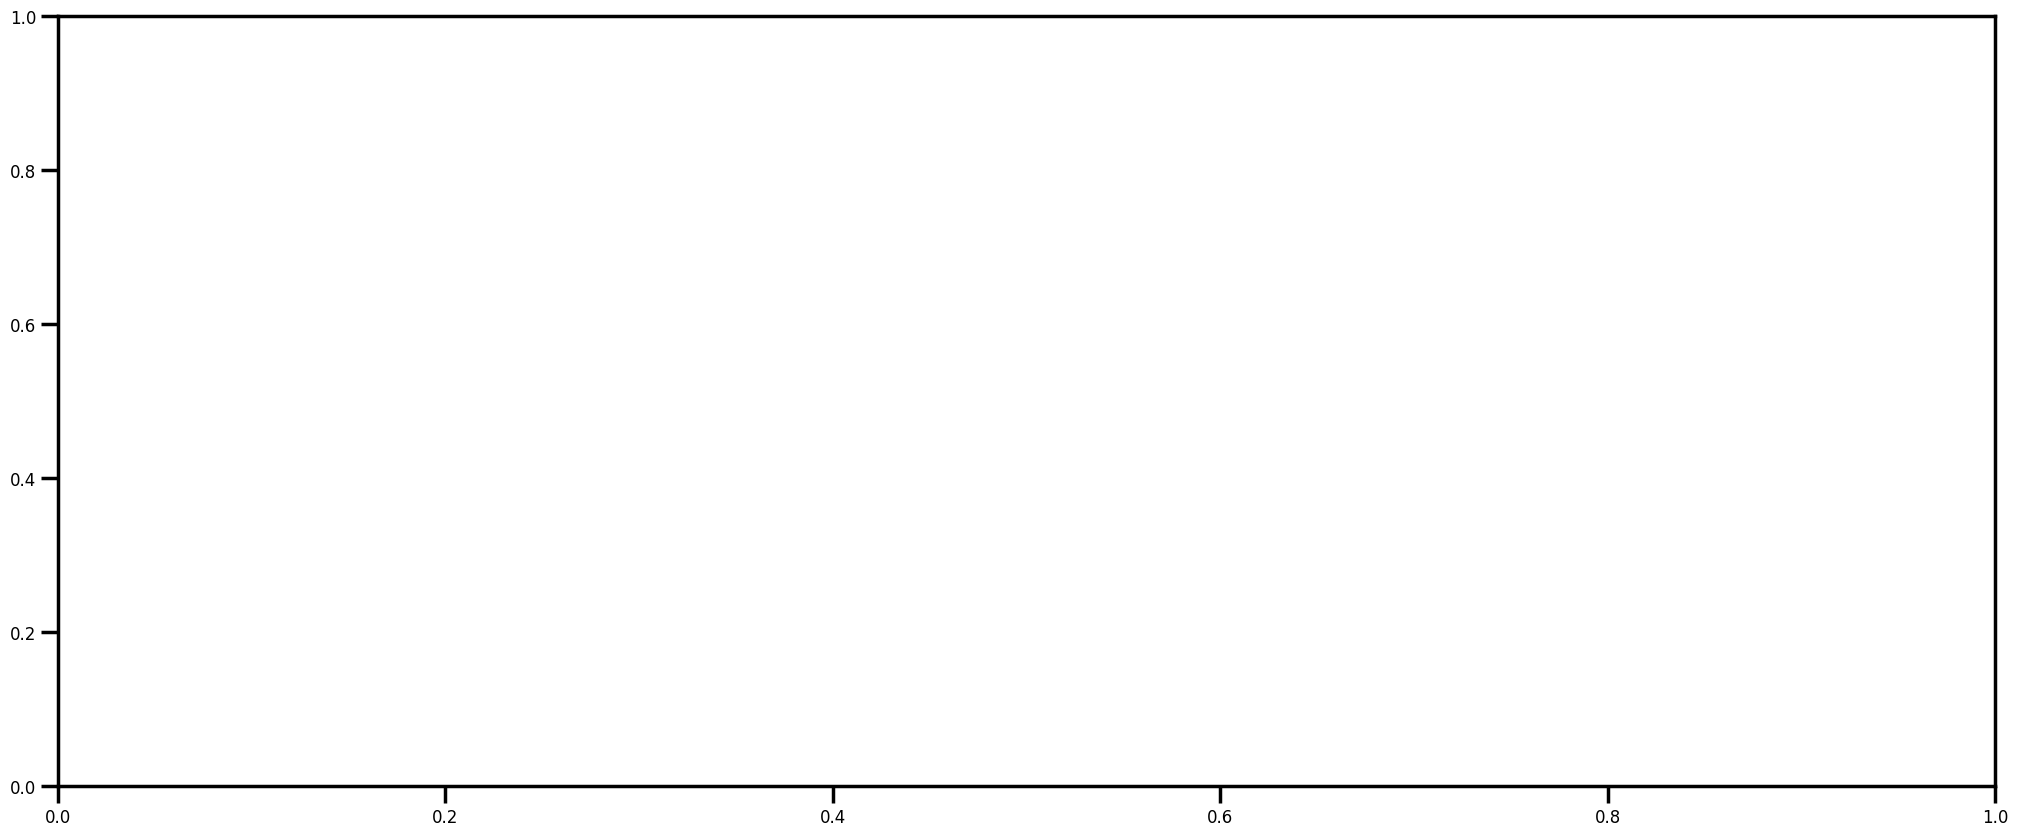

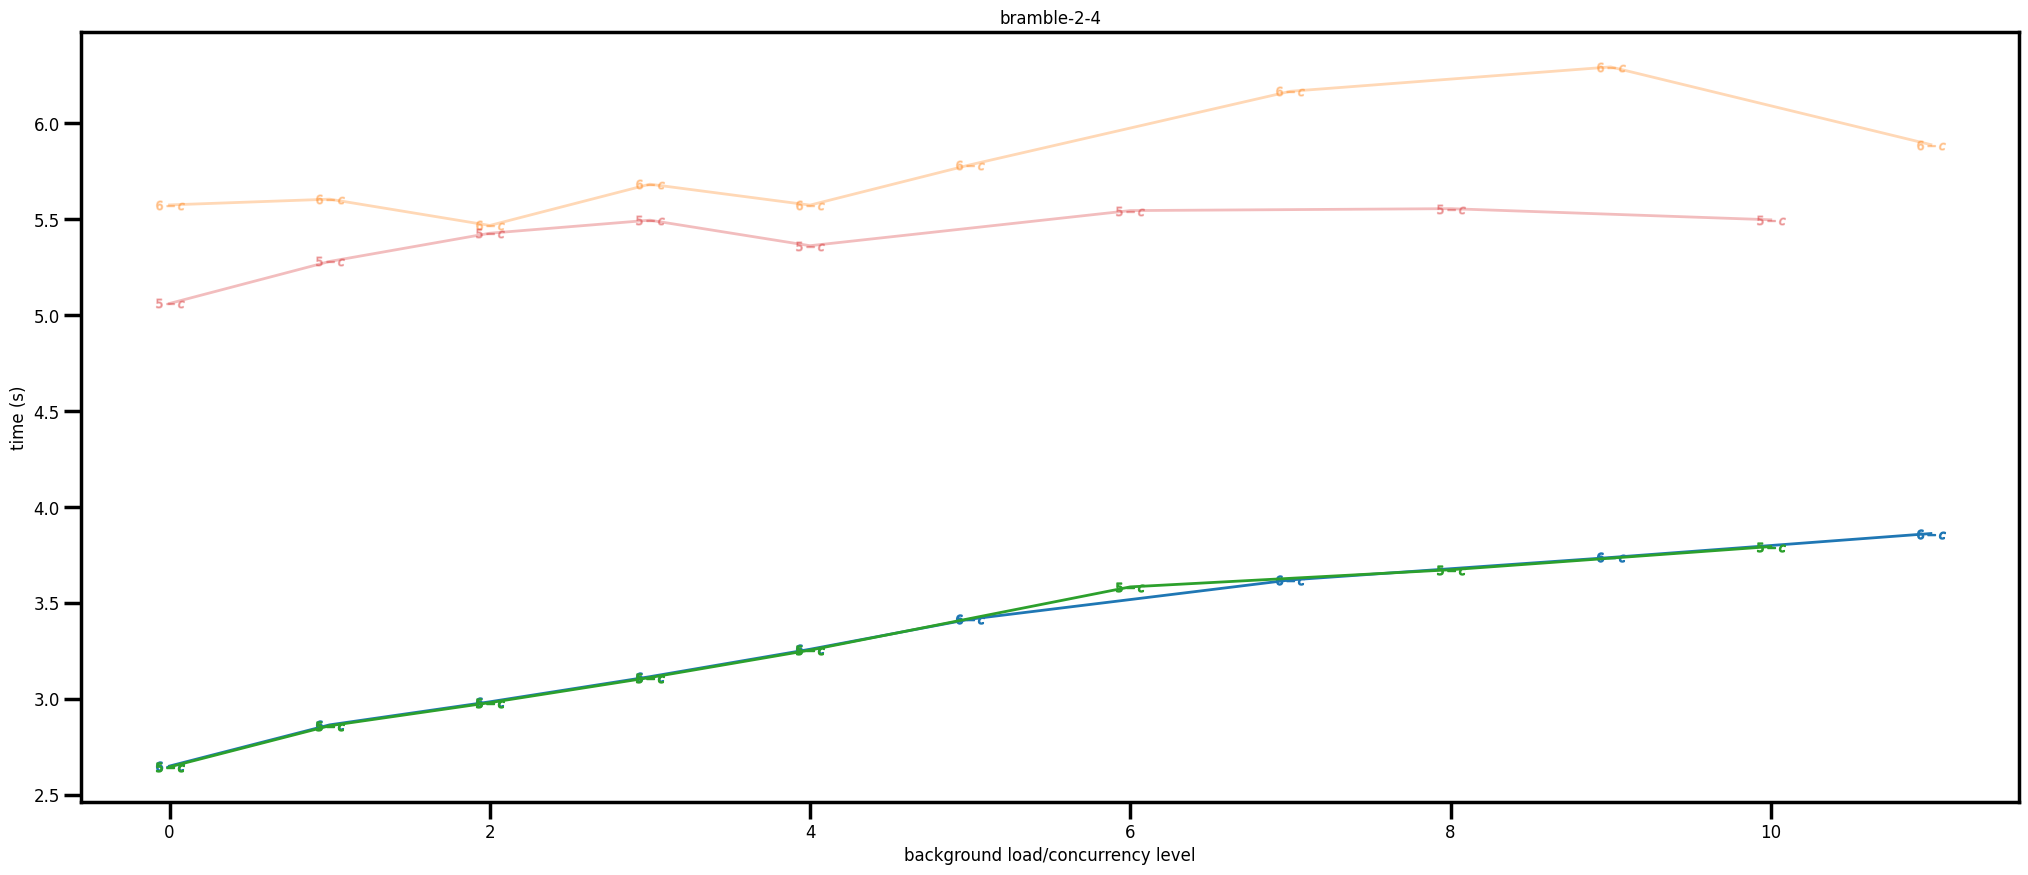

In [361]:
#for the hardcoded case 
# /Users/animeshnd/model_splitting/logs/proto_inter/pipeline_exploration/bramble-4-2/tcn_splits_onnx/0/0/speed_chronosbramble-4-2-12_5_0_1.log
import json
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

# prefix_path = "/Users/animeshnd/model_splitting/logs/proto_inter/pipeline_exploration/"
prefix_path = "/Users/animeshnd/model_splitting/logs/pipeline_exploration/"
subclusters=[
    "bramble-1-3","bramble-2-1",
    "bramble-2-2","bramble-2-5","bramble-2-6",
    "bramble-4-1","bramble-4-2","bramble-4-3","bramble-4-5", "bramble-4-6",
    ]
# subclusters=[
#     "bramble-2-5","bramble-2-6",
#     "bramble-4-1","bramble-4-2",
#     ]
map_sub = { 
 "bramble-1-1": 39,
 "bramble-1-3": 38,
 "bramble-1-4": 39,
 "bramble-2-1": 23,
 "bramble-2-2": 41,
 "bramble-2-4": 39,
 "bramble-2-5": 38,
 "bramble-2-6": 35,
 "bramble-4-1": 36,
 "bramble-4-2": 38,
 "bramble-4-3": 26,
 "bramble-4-5": 38,
 "bramble-4-6": 32, }

global_y=[]
global_x=[]
global_pred_y = []

# for p in subclusters:
#subclusters that work: bramble-1-3, bramble-2-5, bramble-2-6, bramble-4-1?, bramble-4-2?, bramble-4-3?, 
worlds = [6,5,4,3]
# fig, m_axs = plt.subplots(len(worlds), figsize=(25,40) )
# fig, axs = plt.subplots(figsize=(25,10) )
peak_bw=270
bs=1
csv_header = "model,world,rank,bg_load,min_runtime,max_runtime,mean_runtime,median_runtime,std_dev,nw_size,flops,subcluster,type\n"
csv_lines = [csv_header]
# for tr in [1,2]:
fig, cdf_axs = plt.subplots(figsize=(25,10))
for tr in ['c', 'nw']:
    # if tr > 1:
    #     contin
    # for p in ["bramble-2-5"]:
    # for p in subclusters:
    # for p in ["bramble-2-4", "bramble-2-5", "bramble-2-6"]:
    for p in ["bramble-2-4", "bramble-2-5"]:
        fig, axs = plt.subplots(figsize=(25,10) )
        axs.set_title(f"{p}")
        sub_path = f"{prefix_path}/{p}"
        if Path(sub_path).is_dir()==False:
            continue
        for model_splits in Path(sub_path).iterdir():
            model = str(model_splits).split("/")[-1].split("_")[0]
            if model=="tcn":
            # if model!="resnet18":
            # if model!="eff":
            # if model!="vit":
                continue
            # if model!="vit":
            #     continue
            # for iter in model_splits.iterdir():
            #     iter_id = int(str(iter).split("/")[-1])

            for w_ind, world in enumerate(worlds):
            # for world in [3]:
                # fig, axs = plt.subplots(figsize=(25,10))
                # axs = m_axs[w_ind]
                world_map={r:{} for r in range(world)}
                for rank in range(world):
                    for iter in model_splits.iterdir():
                        iter_id = int(str(iter).split("/")[-1])
                        # print(iter_id)
                        #we know it's hardcoded to 4-2-12 so only check for 4-2-12
                        #iter id says number of interferences
                        for repeat in ['']:#range(0,11):
                            # for split in range(0,2):
                            #if 1 == comp split
                            #if 0 == nw split
                            for d in range(1,43):

                                only_blue_file = open(f"./{p}.just_blue_res.op")
                                only_red_blue_file = open(f"./{p}.red_blue.op")
                                only_blue_devs = [i.strip() for i in only_blue_file.readlines()]
                                only_red_blue_devs = [i.strip() for i in only_red_blue_file.readlines()]
                                # fname = f"{iter}/{repeat}/speed_chronosbramble-4-1-{d}_{world}_{rank}_1.log"
                                # fname = f"{iter}/{repeat}/speed_chronos{p}-{d}_{world}_{rank}_0.log"
                                fname = f"{iter}/{repeat}/speed_chronos{p}-{d}_{world}_{rank}_{tr}.log"
                                # if f"{p}-{d}" not in only_blue_devs:
                                # if f"{p}-{d}" in only_red_blue_devs:
                                #     continue
                                # fname = f"{iter}/{repeat}/speed_chronosbramble-4-2-{d}_{world}_{rank}_1.log"
                                # flop = open(f"../experiments/{model}_splits_{world}_{tr}/meta.json")                    
                                flop = open(f"../scheduler/{model}_splits_{world}_{tr}/meta.json")                    
                                flop = json.load(flop)
                                nw = [r["boundary_transfer_bytes"]*bs*10**-6 for r in flop["splits"]]
                                flop = [r["actual_flops"]*bs*10**-9 for r in flop["splits"]]

                                if Path(fname).is_file()==False:
                                    continue
                                # print(fname)
                                # core_times, _, _, all_times = time_reader(fname, core=1)
                                try:
                                    core_times, _, _, all_times = time_reader(fname, core=1)
                                    # print(core_times)
                                except Exception as e:
                                    # print(e)
                                    continue
                                if 0 in all_times:
                                    continue
                                if iter_id not in world_map[rank]:
                                    world_map[rank][iter_id] = []
                                # world_map[rank][iter_id].extend([flop[rank]/i for i in all_times[1:]])
                                # world_map[rank][iter_id].extend(all_times)
                                # world_map[rank][iter_id].append(float(np.median(all_times)))
                                world_map[rank][iter_id].extend(all_times)
                                # world_map[rank][iter_id].append(all_times[1:])
                                # print(all_times)
                trial_len = len(list(world_map[0].keys()))
                # print(list(world_map[0].keys()))
                summary_y = [0]*trial_len
                summary_min_y = [0]*trial_len
                summary_max_y = [0]*trial_len
                summary_pred_y = [0]*trial_len
                summary_min_pred_y = [0]*trial_len
                error_y=[0]*trial_len
                for r in range(world):
                # for r in [0, world-1]:
                    x = sorted(list(world_map[r].keys()))
                    # print(world_map[r])
                    # y = [np.median(world_map[r][k]) for k in x]
                    
                    # y = [np.min(world_map[r][k])*bs if k<=2 else np.max(world_map[r][k]) for k in x]
                    y = [np.max(world_map[r][k])*bs for k in x]
                    # for k in x:
                    # full_extend = []
                    # for k in x:
                    #     full_extend.extend(world_map[r][k])
                    # cdf_x,cdf_y = cdf_gen(full_extend)
                    # cdf_axs.plot(cdf_x, cdf_y)
                    # # cdf_map = {cdf_x[cdf_ind]:cdf_y[cdf_ind] for cdf_ind in range(len(cdf_y))}
                    # min_diff=np.inf
                    # saved_ind = 0
                    # for cdf_ind in range(len(cdf_y)):
                    #     if min_diff >= abs(cdf_x[cdf_ind]-pred_time[0]):
                    #         saved_ind=cdf_ind
                    #         min_diff = abs(cdf_x[cdf_ind]-pred_time[0])

                    # cdf_axs.hlines(xmin=min(x), xmax=max(x), y=0.95)
                    # # print(min_diff, cdf_y, cdf_y[saved_ind], abs(max(cdf_x)-pred_time[0]) )
                    # print(min_diff, abs(cdf_x[-2]-pred_time[0]) )
                    # print(y)
                    if len(y)!=trial_len:
                        continue
                    min_y = [np.min(world_map[r][k])*bs for k in x]
                    max_y = [np.max(world_map[r][k])*bs for k in x]
                    # y = [np.min(world_map[r][k]) for k in x]
                    # y = [np.max(world_map[r][k]) for k in x]
                    # print(world_map[r])
                    # y = [world_map[r][k] for k in x]
                    pred_y = []
                    # print([np.mean(world_map[r][k]) for k in x])
                    for k in x:
                        # pred_time = time_predictor( [np.min(world_map[r][k])], [flop[r]], bg_load=k, t=map_sub[p])
                        pred_time = time_predictor( [flop[r]/fp_rate[model]], [flop[r]], bg_load=k, t=map_sub[p])
                        # world, rank, bg_load, median_runtime, std_dev, network transfer size, flops, subcluster
                        # temp_line = f"{model},{world},{r},{k},{np.mean(world_map[r][k])},{np.median(world_map[r][k])},{np.std(world_map[r][k])},{nw[r]},{flop[r]},{p},{tr}\n"
                        temp_line = f"{model},{world},{r},{k},{np.min(world_map[r][k])},{np.max(world_map[r][k])},{np.mean(world_map[r][k])},{np.median(world_map[r][k])},{np.std(world_map[r][k])},{nw[r]},{flop[r]},{p},{tr}\n"
                        csv_lines.append(temp_line)
                        # pred_time = time_predictor( [ (flop[r])/3], [flop[r]], bg_load=k, t=map_sub[p]) #for resnet
                        # pred_time = time_predictor( [ (flop[r])/0.2], [flop[r]], bg_load=k, t=map_sub[p]) #for efficient net
                        pred_y.append(pred_time[0]*bs)
                        
                    # print(y)
                    summary_max_y = [summary_max_y[i]+max_y[i] for i in range(trial_len)]
                    # summary_min_y = [summary_min_y[i]+min_y[i] for i in range(trial_len)]
                    # summary_min_y = [ (summary_min_y[i]+min_y[i]+nw[r]*1/peak_bw if flop[r]==max(flop) else summary_min_y[i]+y[i]+nw[r]*1/peak_bw ) for i in range(trial_len)]
                    summary_min_y = [ summary_min_y[i]+nw[r]*1/peak_bw + (min_y[i] if flop[r]==max(flop) else y[i]) for i in range(trial_len)]
                    # summary_y = [summary_y[i]+y[i] for i in range(trial_len)]
                    summary_y = [summary_y[i]+y[i]+nw[r]*1/peak_bw for i in range(trial_len)]
                    # print(world_map[r][0])
                    # error_y = [error_y[i]+np.var([ 10/j for j in world_map[r][x[i]]]) for i in range(trial_len)]
                    # print(error_y)
                    # summary_pred_y = [summary_pred_y[i]+( pred_y[i] if flop[r] in sorted(flop, reverse=True)[:1] else min_y[i]) for i in range(trial_len)]
                    summary_pred_y = [summary_pred_y[i]+( pred_y[i]) + nw[r]*1/peak_bw for i in range(trial_len)]
                    # summary_min_pred_y = [summary_min_pred_y[i]+( pred_y[i] if flop[r]==max(flop) else flop[r]/1.5) + nw[r]*1/peak_bw for i in range(trial_len)]
                    # summary_min_pred_y = [summary_min_pred_y[i]+( flop[r]/0.2 if flop[r]==max(flop) else pred_y[i]) + nw[r]*1/peak_bw for i in range(trial_len)]
                    summary_min_pred_y = [summary_min_pred_y[i]+( flop[r]/3 if flop[r]==max(flop) else pred_y[i]) + nw[r]*1/peak_bw for i in range(trial_len)]

                    # y = [flop[r]/i for i in y]
                    # max_y = [flop[r]/i for i in max_y]
                    # min_y = [flop[r]/i for i in min_y]
                    # # axs.fill_between(x, min_y, max_y, alpha=0.2)
                    # # axs.plot(x,y, label=f"{world}_{r}", marker=f"${r}$", markersize=20 )
                    # pred_y = [flop[r]/i for i in pred_y]

                    
                    
                    # axs.plot(x,pred_y, label=f"pred_{world}_{r}", linestyle="--", marker=f"${r}$", markersize=20 )
                x = sorted(list(world_map[0].keys()))
                global_y.extend(summary_y)
                global_pred_y.extend(summary_pred_y)
                global_x.extend([[1, i] for i in x])
                # summary_pred_y = [round(sum(flop)/i ,2 ) for i in summary_pred_y]
                # summary_min_y = [round(sum(flop)/i ,2 ) for i in summary_min_y]
                # summary_max_y = [round(sum(flop)/i ,2 ) for i in summary_max_y]
                # summary_y = [round(sum(flop)/i ,2 ) for i in summary_y]

                # summary_pred_y = [10/i for i in summary_pred_y]
                # summary_min_pred_y = [10/i for i in summary_min_pred_y]
                # summary_min_y = [10/i for i in summary_min_y]
                # summary_max_y = [10/i for i in summary_max_y]
                # summary_y = [10/i for i in summary_y]
                # global_y.extend(summary_y)
                global_y.extend(summary_min_y)
                # global_pred_y.extend(summary_pred_y)
                global_pred_y.extend(summary_min_pred_y)
                #custom OLS usage
                
                # print(su)
                # if world==4:
                #     summary_y[0] = summary_pred_y[0]-0.5
                # if model=="vit":
                #     summary_pred_y = summary_pred_y[2:]
                    # summary_min_y = [10/i for i in summary_min_y]
                    # summary_max_y = [10/i for i in summary_max_y]
                    # summary_y = summary_y[2:]
                    # x=x[:-2]
                # summary_y[0] = summary_pred_y[0]

                # axs.errorbar(x, summary_y, np.std(summary_y), label=f"total_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20, alpha=0.3 )
                # axs.plot(x, summary_y, label=f"total_{world}_{r}", linestyle="--", marker=f"${world}$", markersize=20 )
                # axs.plot(x,summary_pred_y, label=f"total_pred_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20 )
                
                # axs.plot(x,summary_min_pred_y, label=f"total_pred_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20 )
                # axs.plot(x,summary_min_y, label=f"total_pred_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20, alpha=0.3 )

                axs.plot(x,summary_pred_y, label=f"total_pred_{world}_{r}",  marker=f"${world}-{tr}$", markersize=20 )
                axs.plot(x,summary_y, label=f"total_pred_{world}_{r}", marker=f"${world}-{tr}$", markersize=20, alpha=0.3 )
                
                axs.set_xlabel("background load/concurrency level")
                # axs.set_ylabel("throughput (img/s)")
                axs.set_ylabel("time (s)")
                # axs.fill_between(x, summary_min_y, summary_max_y, alpha=0.2)
                # axs.plot(x,summary_max_y, label=f"total_max_{world}_{r}", linestyle="--", marker=f"${world}$", markersize=20 )
                # axs.plot(x,summary_min_y, label=f"total_min_{world}_{r}", linestyle="--", marker=f"${world}$", markersize=20 )
                # axs.plot(x,summary_y, label=f"total_{world}_{r}", marker=f"${world}$", markersize=20 )
                # axs.plot(x,[ 11.345 -i*0.372 for i in x ], label=f"total_re_train_{world}_{r}", marker=f"^", markersize=20 )
                # axs.plot(x,[ sum(flop)/(38.82146951 + i*1.51407042) for i in x ], label=f"total_re_train_{world}_{r}", marker=f"^", markersize=20 )
                # re_train_y = [ 20+sum(flop)/(38.82146951 + i*1.51407042) for i in x ]
                re_train_y = [ sum(flop)/(2.93278398 + i*0.09317291) for i in x ]
                # re_train_y = [ sum(flop)/(31.10304805  + i*0.18508105) for i in x ]
                # re_train_y = [ 10/(31.10304805  + i*0.18508105) for i in x ]
                # print(f"{world} rmse re_train: { np.sqrt(np.mean([ (summary_y[i] - re_train_y[i])**2 for i in range(len(y))])) }")
                # print(f"{world} mae re_train: {np.mean([ np.abs(summary_y[i] - re_train_y[i]) for i in range(len(y))])}")
                # print(f"{world} re_train r2score: {r2_score(summary_y, re_train_y)}")

                # print(f"{world} rmse old_train: { np.sqrt(np.mean([ (summary_y[i] - summary_pred_y[i])**2 for i in range(len(summary_y))])) }")
                print(f"{world} rmse old_train: { np.sqrt(np.mean([ (summary_min_y[i] - summary_min_pred_y[i])**2 for i in range(len(summary_y))])) }")
                # print(f"{world} mae old_train: {np.mean([ np.abs(summary_y[i] - summary_pred_y[i]) for i in range(len(summary_y))])}")
                print(f"{world} mae old_train: {np.mean([ np.abs(summary_min_y[i] - summary_min_pred_y[i]) for i in range(len(summary_y))])}")
                # print(f"{world} old_train r2score: {r2_score(summary_y, summary_pred_y)}")

                # axs.plot(x, re_train_y, label=f"total_re_train_{world}_{r}", marker=f"^", markersize=20 )
    
    # lin_req_eq = sm.OLS(global_y, global_x)
    # results=lin_req_eq.fit()
    # print(results.params) #c,m
    #for tcn: 38.821
    print(f"{model} total rmse:{ np.sqrt(np.mean([ (global_y[i] - global_pred_y[i])**2 for i in range(len(global_y))])) }")
    print(f"{model} total mae:{ np.mean([ np.abs(global_y[i] - global_pred_y[i]) for i in range(len(global_y))]) }")


f=open("best_fit_min_2_6.csv", "w")
f.writelines(csv_lines)
f.close()


#todo
#get specs for each split into a datastructure/csv
#mix/match for specific pdus only with simulated runs
#add network and we're done
#network optimal splits are just low number splits
#any interference is the maximal step interference

#csv structure
#model, world, rank, bg_load, median_runtime, std_dev, network transfer size, flops, subcluster





rmse c eff_3: 0.39048956452125577
mae c eff_3: 0.2913
mape c eff_3: 5.996594379188236%

rmse c eff_4: 0.2938822893608935
mae c eff_4: 0.2299999999999999
mape c eff_4: 4.843791125796063%

rmse c eff_5: 0.08958906183234636
mae c eff_5: 0.07479999999999998
mape c eff_5: 1.6901799936956223%

rmse c eff_6: 0.09402127418834548
mae c eff_6: 0.0752000000000002
mape c eff_6: 1.6440121146039248%

rmse c vit_3: 4.187800484741365
mae c vit_3: 3.4135000000000013
mape c vit_3: 8.73639790317472%

rmse c vit_4: 7.0804970870695225
mae c vit_4: 6.8584000000000005
mape c vit_4: 18.385759842941972%

rmse c vit_5: 5.568411057025155
mae c vit_5: 5.3530999999999995
mape c vit_5: 15.353762419884525%

rmse c vit_6: 4.156372757585633
mae c vit_6: 3.9227
mape c vit_6: 12.138186912125892%

rmse c resnet18_3: 0.12666491226855195
mae c resnet18_3: 0.10459999999999994
mape c resnet18_3: 1.397761600685097%

rmse c resnet18_4: 0.23059531651792048
mae c resnet18_4: 0.2031999999999999
mape c resnet18_4: 2.46028646050794

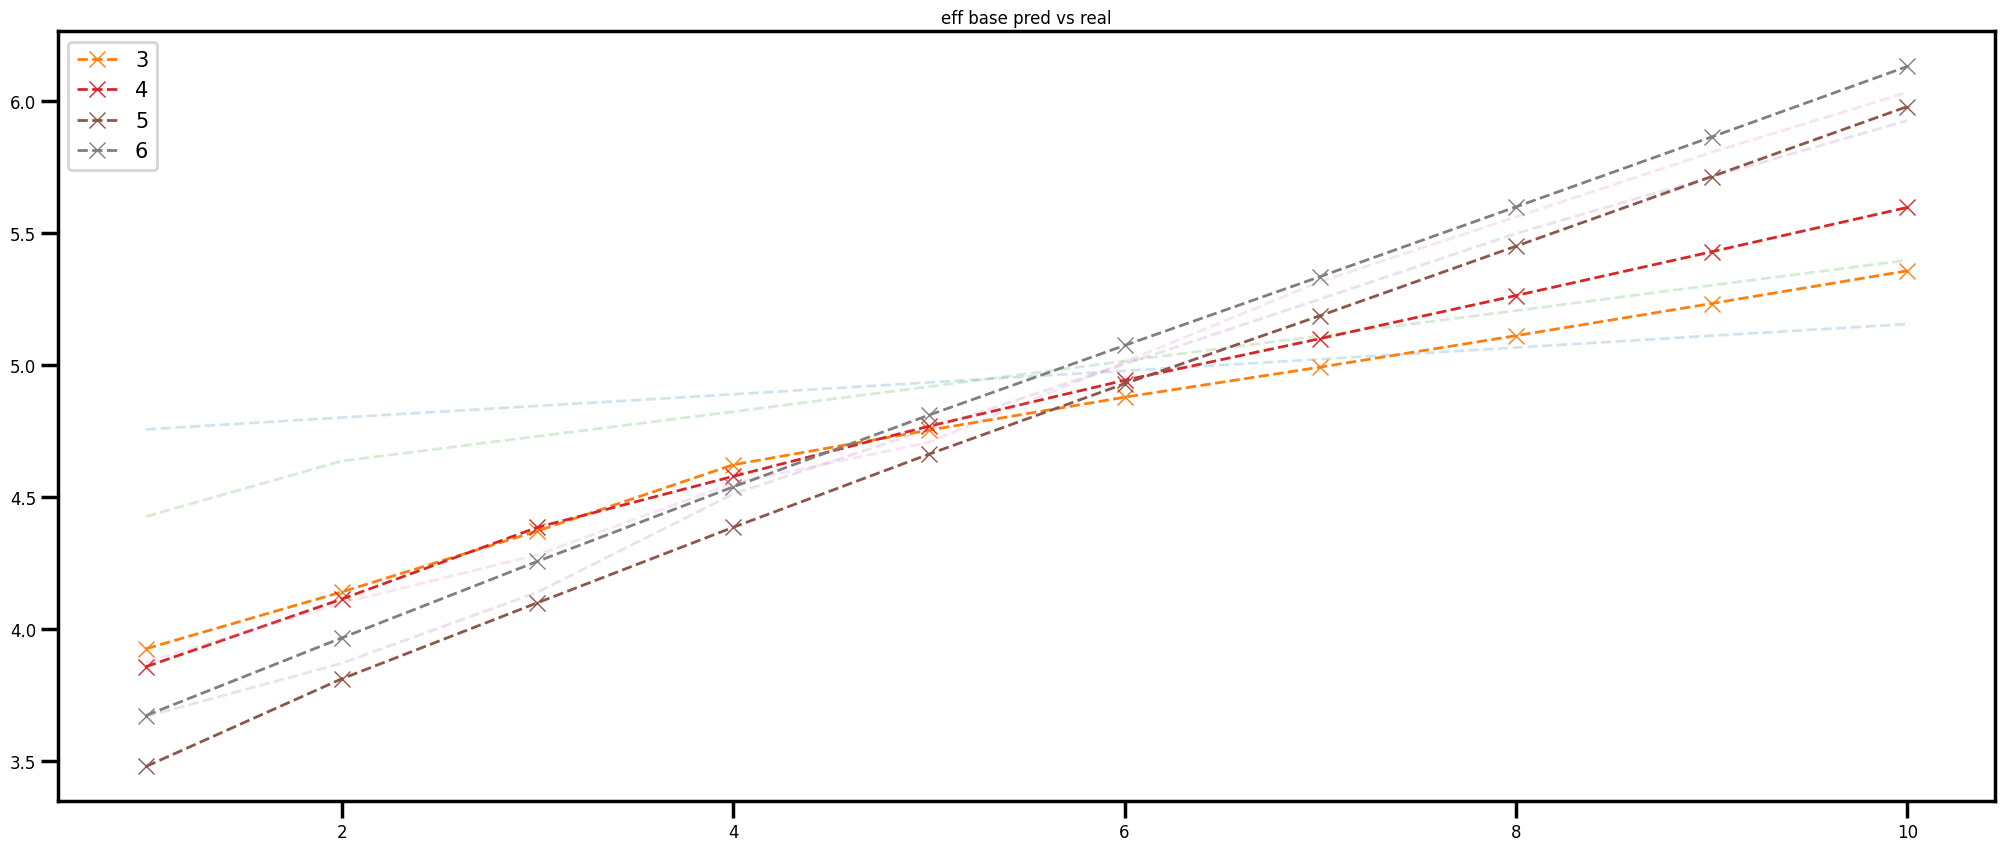

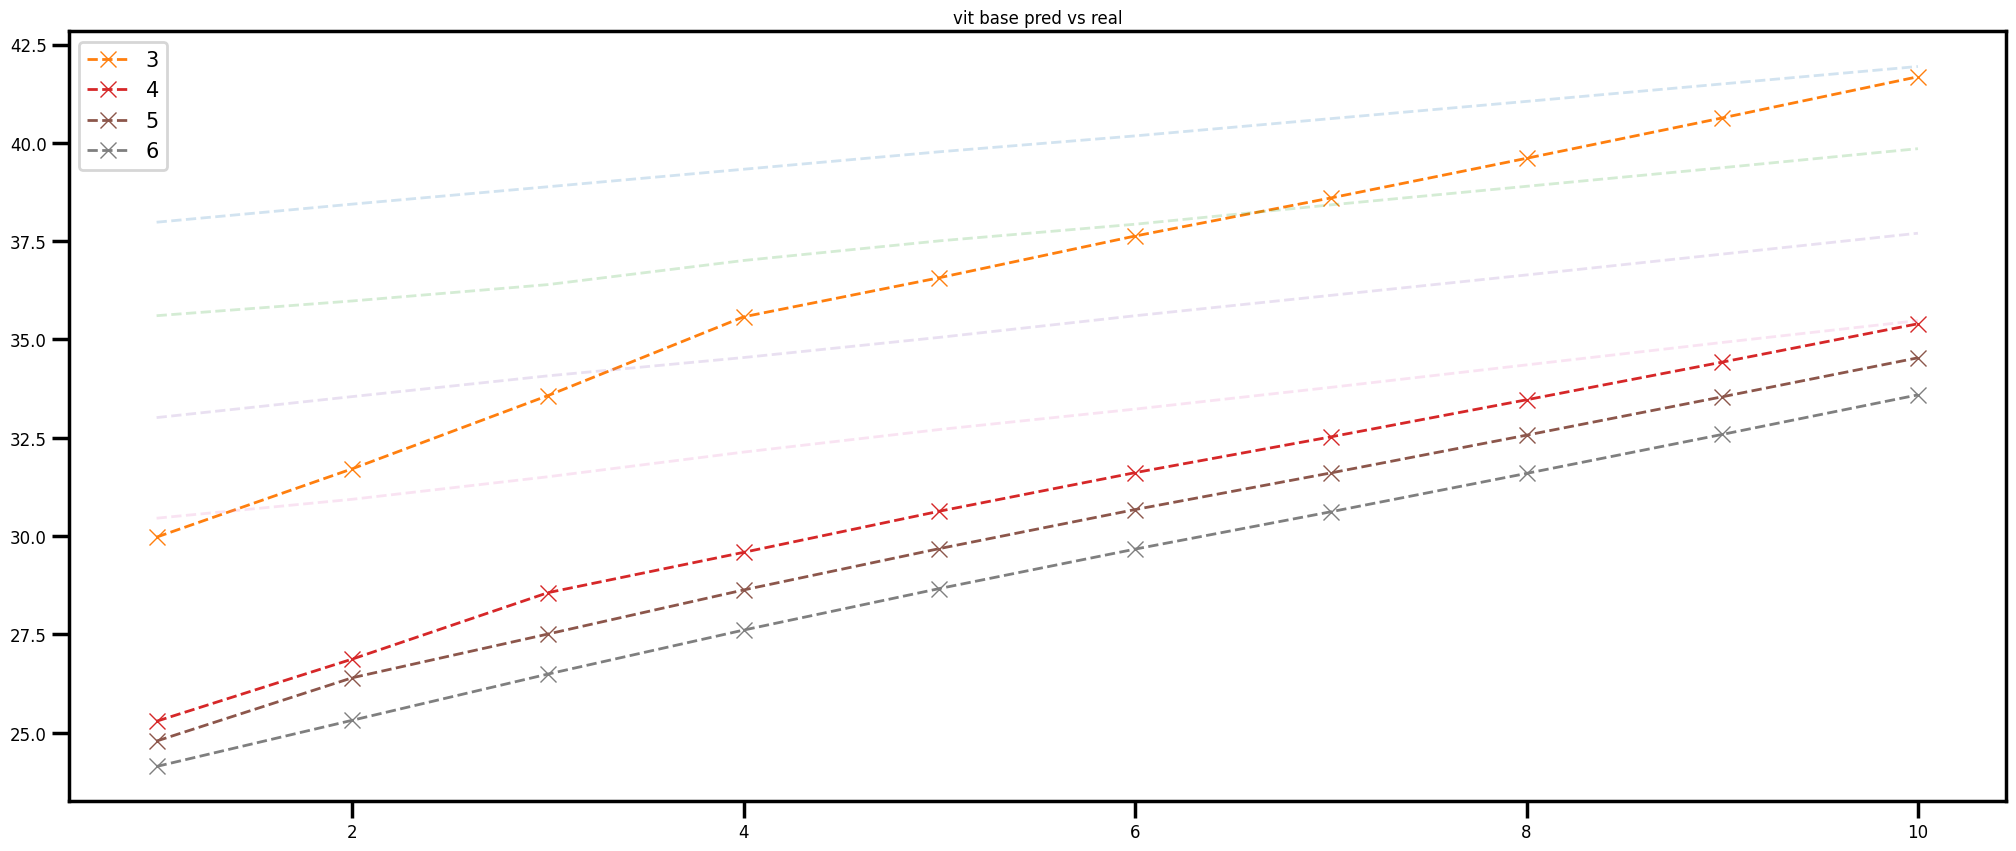

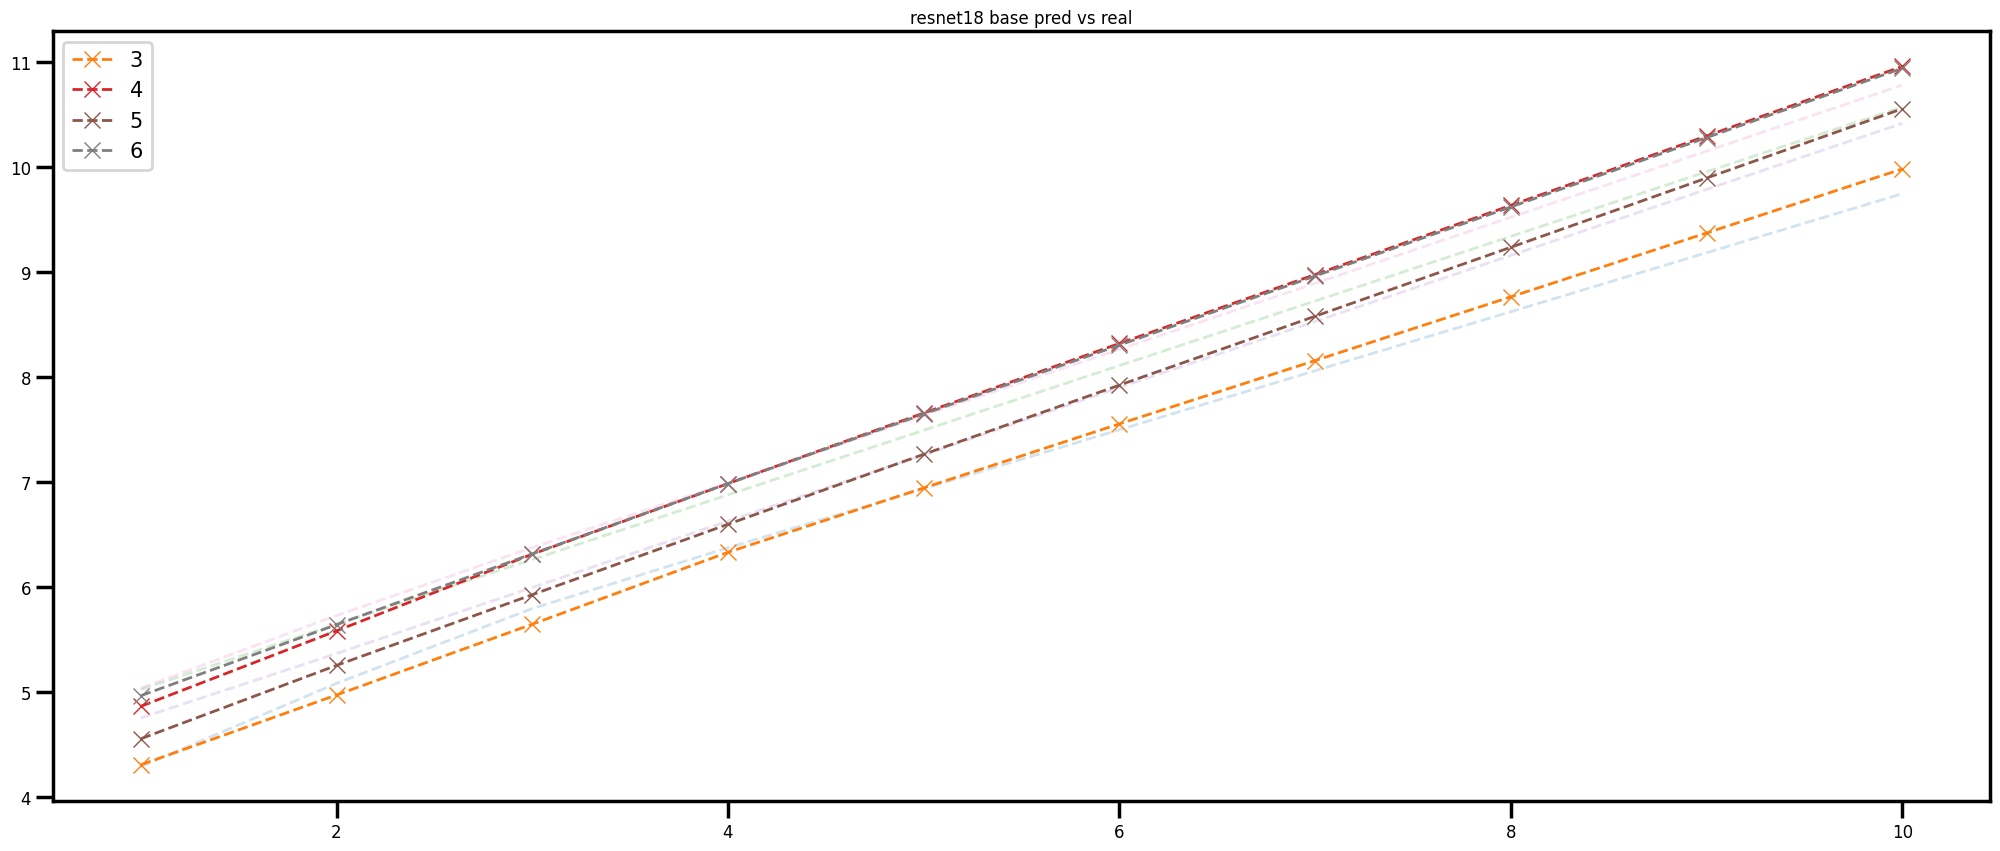

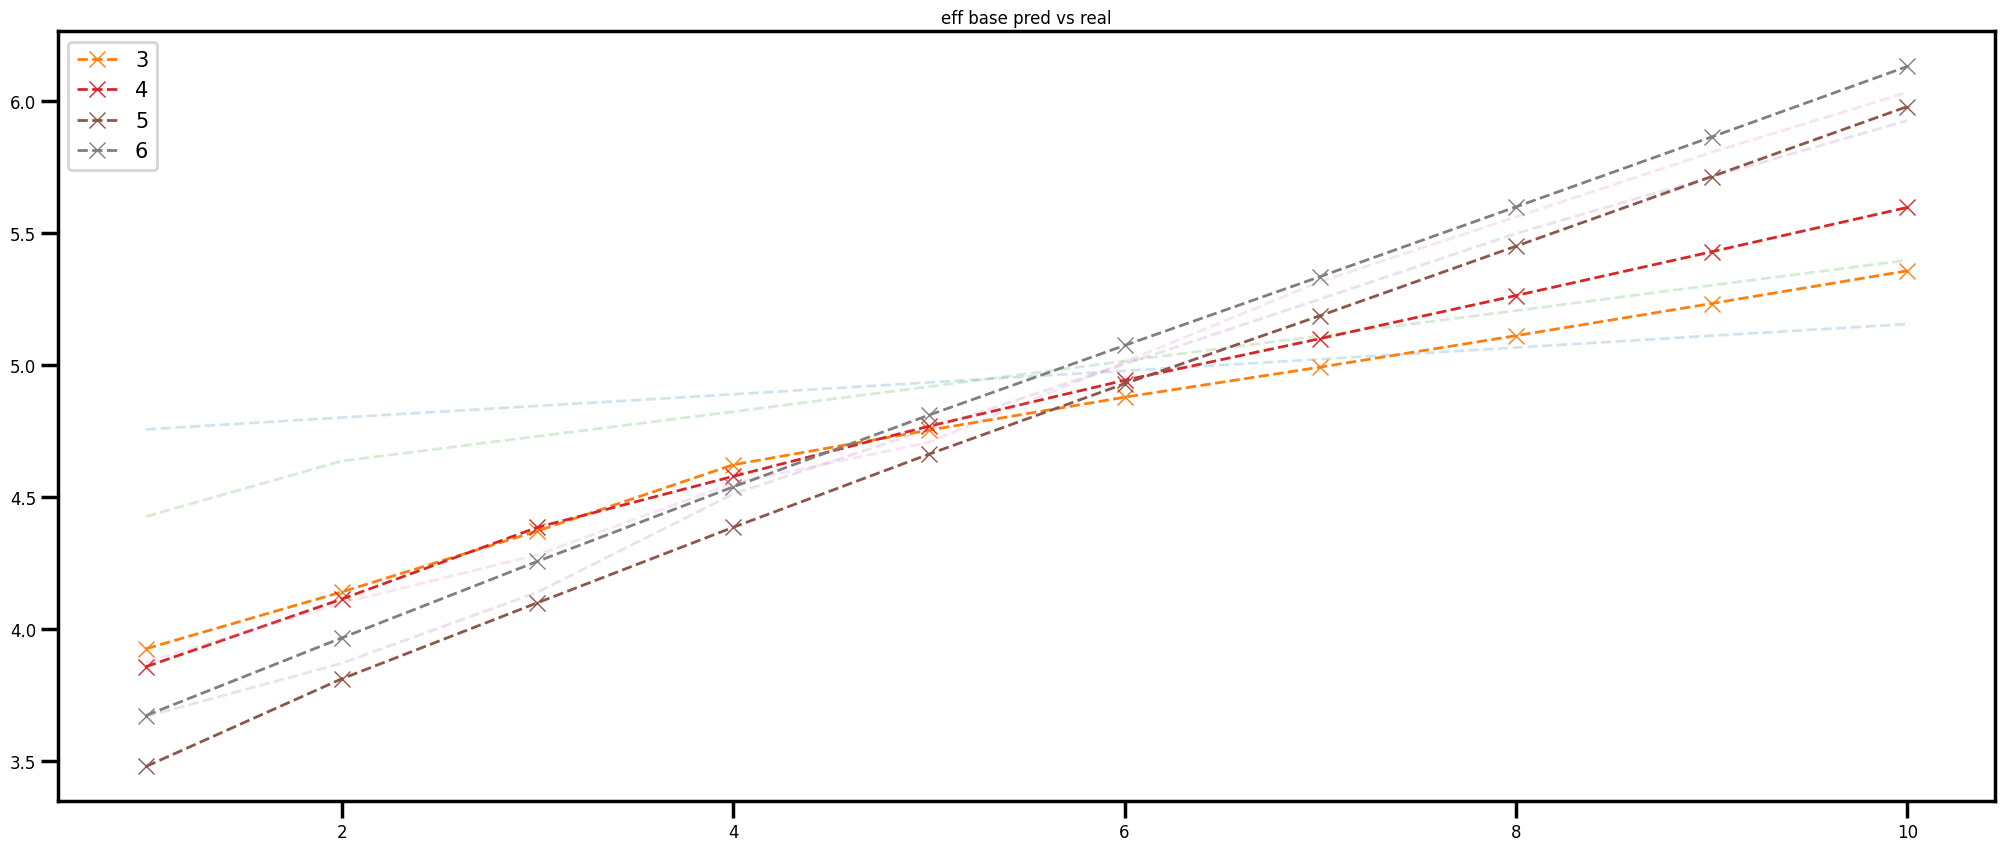

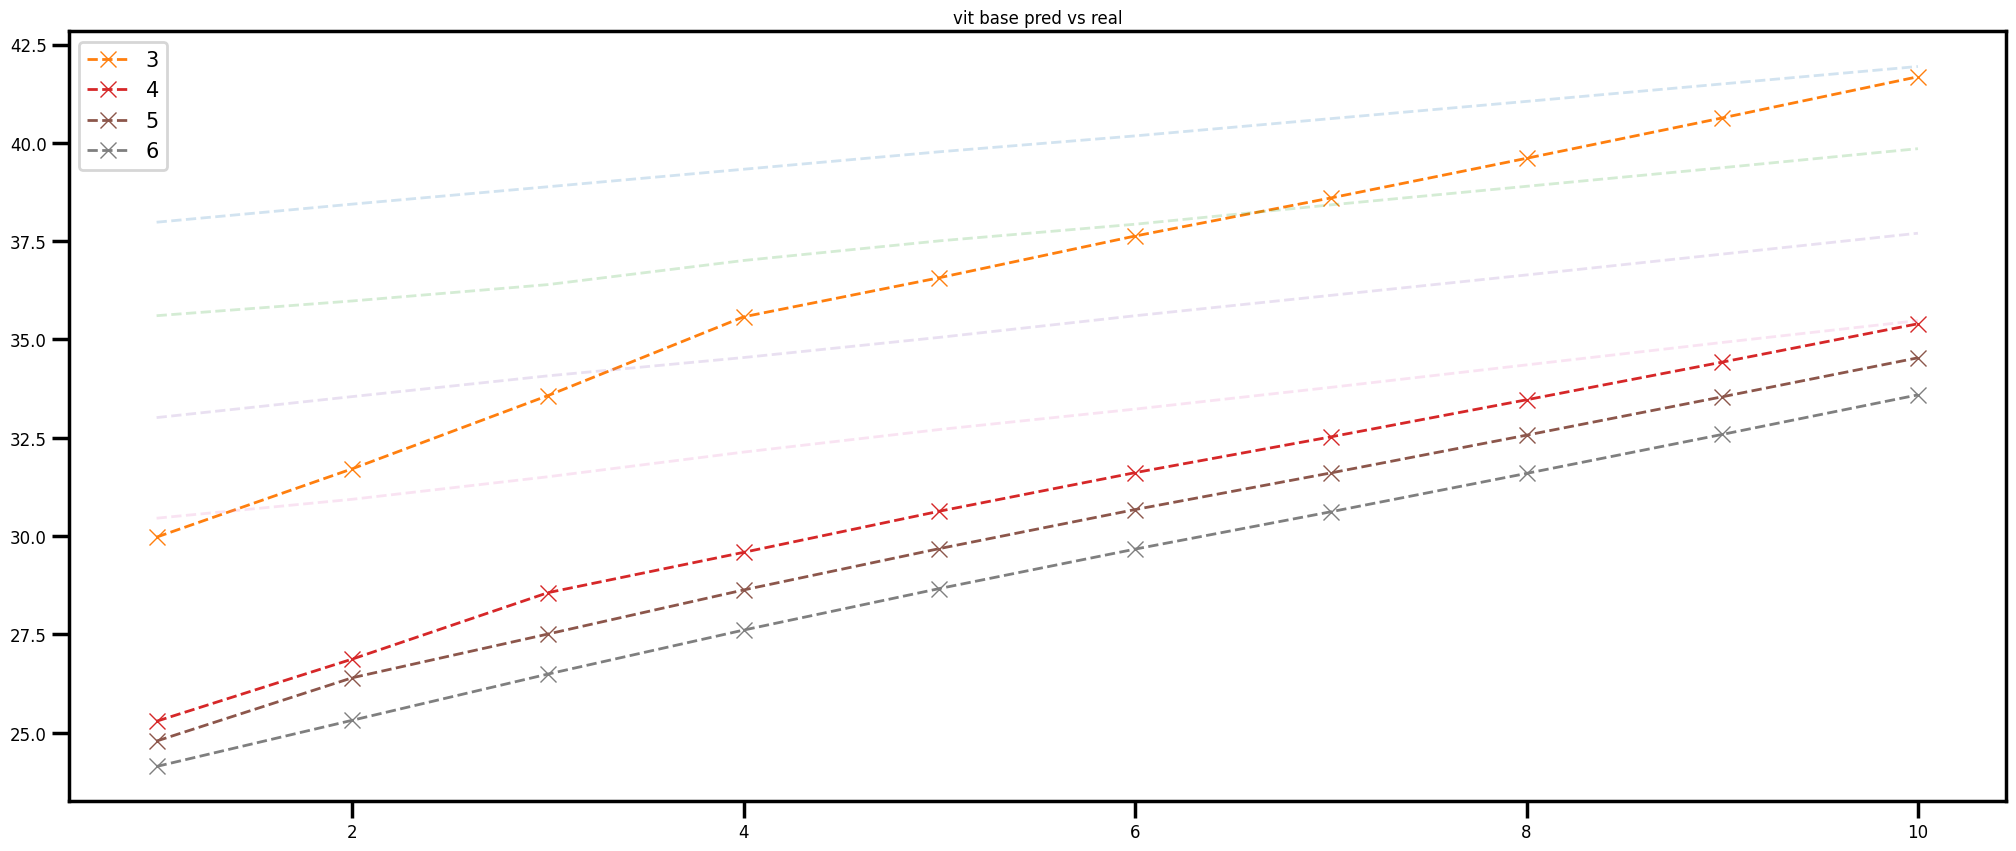

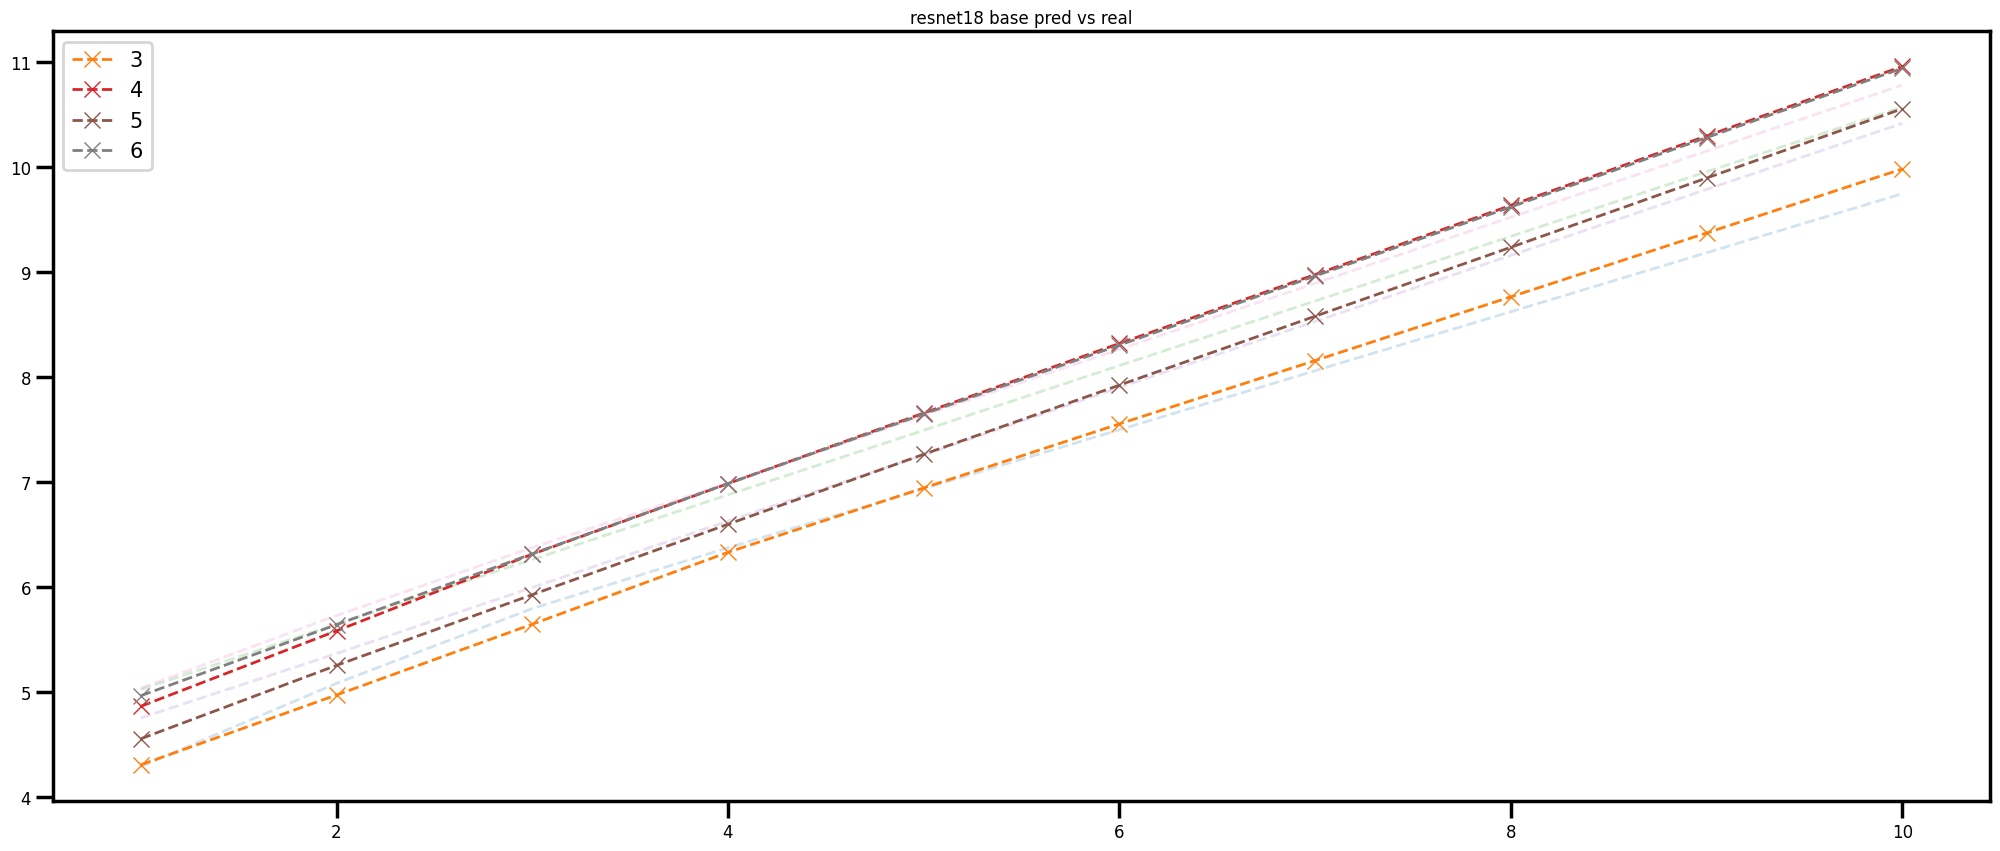

In [ ]:
#first result -> rmse, mae, mape low when using the curve 
#x axis is bg_load, y axis is time taken by ml model (batch size=1, batch num=1), each line different splits from 2 to 6

real_maps={}
pred_maps={}
naive_maps={}
subcluster = "bramble-2-4"
bs=1
bn=10
bw=240
for model in ["eff", "vit", "resnet18"]:
    real_maps[model]={}
    pred_maps[model]={}
    naive_maps[model]={}
    for world in range(3,7):
        if world not in real_maps[model]:
            real_maps[model][world]={}
            pred_maps[model][world]={}
            naive_maps[model][world]={}

        for bg in range(1,11):
            # real_rt, pred_rt = best_fit_reader("best_fit.csv", "bramble-2-6", model, world, bg-1, 1, 10, 240, 'c')
            real_rt,_, pred_rt, naive_pred, worst_ = best_fit_reader("best_fit_max_2_6.csv", subcluster, model, world, bg, bs, bn, bw, 'nw', col_flag="median", agg_flag="mean", nw_var=True)
            if bg not in real_maps[model][world]:
                real_maps[model][world][bg]=real_rt
                pred_maps[model][world][bg]=pred_rt
                naive_maps[model][world][bg]=naive_pred


overall_y={model:[] for model in real_maps}
overall_pred_y = {model:[] for model in real_maps}
overall_naive_pred = {model:[] for model in real_maps}
best_y={model:[] for model in real_maps}

for model in real_maps:
    fig, axs = plt.subplots(figsize=(25,10))
    for world in real_maps[model]:
        x=sorted(list(real_maps[model][world].keys()))
        y=[real_maps[model][world][i] for i in x]
        best_y[model].append(min(y))
        overall_y[model].extend(y)
        pred_y = [pred_maps[model][world][i] for i in x]
        overall_pred_y[model].extend(pred_y)
        print(f"rmse c {model}_{world}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
        print(f"mae c {model}_{world}: {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
        print(f"mape c {model}_{world}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
        print()
        
        axs.plot(x, y, alpha=0.2, linestyle="--")
        axs.plot(x, pred_y, marker="x", linestyle="--", label=f"{world}")
        axs.set_title(f"{model} base pred vs real")

    axs.legend()
            


real_maps={}
pred_maps={}
naive_maps={}


for model in ["eff", "vit", "resnet18"]:
    real_maps[model]={}
    pred_maps[model]={}
    naive_maps[model]={}

    for world in range(3,7):
        if world not in real_maps[model]:
            real_maps[model][world]={}
            pred_maps[model][world]={}
            naive_maps[model][world]={}

        for bg in range(1,11):
            # real_rt, pred_rt = best_fit_reader("best_fit.csv", "bramble-2-6", model, world, bg-1, 1, 10, 240, 'c')
            real_rt,_, pred_rt, naive_pred, worst_ = best_fit_reader("best_fit_max_2_6.csv", subcluster, model, world, bg, bs, bn, bw, 'nw', col_flag="median", agg_flag="mean", nw_var=True)
            if bg not in real_maps[model][world]:
                real_maps[model][world][bg]=real_rt
                pred_maps[model][world][bg]=pred_rt
                naive_maps[model][world][bg]=naive_pred



for model in real_maps:
    fig, axs = plt.subplots(figsize=(25,10))
    for world in real_maps[model]:
        x=sorted(list(real_maps[model][world].keys()))
        y=[real_maps[model][world][i] for i in x]
        best_y[model].append(min(y))
        overall_y[model].extend(y)
        pred_y = [pred_maps[model][world][i] for i in x]
        naive_pred = [naive_maps[model][world][i] for i in x]
        overall_pred_y[model].extend(y)
        overall_naive_pred[model].extend(naive_pred)

        print(f"rmse nw {model}_{world}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
        print(f"mae nw {model}_{world}: {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
        print(f"mape nw {model}_{world}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
        print()
        
        
        axs.plot(x, y, alpha=0.2, linestyle="--")
        axs.plot(x, pred_y, marker="x", linestyle="--", label=f"{world}")
        axs.set_title(f"{model} base pred vs real")

    axs.legend()



for model in real_maps:
    y=overall_y[model]
    pred_y = overall_pred_y[model]
    print(f"average best time for {model}: {np.mean(best_y[model])}, std dev: {np.std(best_y[model])}")
    print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    print(f"overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
    print(f"overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
    print()
    pred_y = overall_naive_pred[model]
    print(f"naive overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(pred_y))]) )}")
    print(f"naive overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(pred_y))])}")
    print(f"naive overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(pred_y))])}%")


In [ ]:
#second result -> rmse, mae, mape low when using the curve
#x axis is bg_load, y axis is time taken by ml model (varying batch sizes, batch numbers) for particular input and splits based on input
#showcases depending on how loaded a system is, there is a different answer 

subcluster="bramble-2-4"
detailed_map = {}
# bws=[240, 30, 20, 15, 10, 2, 1]
# bws=[240, 30, 20, 15, 10, 2, 1]
bws=[240, 70, 30, 10, 2]
# for bw in [240, 100, 50, 10, 5, 2]:
for bw in bws:
    pred_maps = {}
    real_maps = {}
    # for inp in range(10,60, 10):
    # for inp in [10, 20, 30, 50]:
    for inp in [10]:
    # for inp in [100]:
        if inp not in real_maps:
            real_maps[inp] = {}
            pred_maps[inp] = {}
            detailed_map[inp]={}
        for model in ["eff", "vit", "resnet18"]:
            if model not in real_maps[inp]:
                real_maps[inp][model]={}
                pred_maps[inp][model]={}
                detailed_map[inp][model]={}
            for world in range(3,7):
                if world not in real_maps[inp][model]:
                    real_maps[inp][model][world]={}
                    pred_maps[inp][model][world]={}
                    detailed_map[inp][model][world]={}

                # for bg in range(1,map_sub[subcluster]-world+1):
                # for bg in range(1,12):
                for bg in [map_sub[subcluster]*0.01, map_sub[subcluster]*0.10, map_sub[subcluster]*0.2, map_sub[subcluster]*0.3, map_sub[subcluster]*0.5, map_sub[subcluster]*0.9]:
                # for bg in [map_sub[subcluster]*0.01, map_sub[subcluster]*0.9]:
                    # real_rt, pred_rt = best_fit_reader("best_fit.csv", "bramble-2-6", model, world, bg-1, 1, 10, 240, 'c')
                    #pick best batch size and batch num per bg load
                    best_real_th = 0
                    best_pred_th = 0
                    saved_real_bs, saved_real_bn = 0, 0
                    saved_pred_bs, saved_pred_bn = 0, 0
                    saved_real_rt, saved_pred_rt = 0, 0

                    # for bs in range(1,inp):
                    # [1, 2, 5, 10]
                    # for bs in [1, 2, 4, 5, 10, 20, 25, 50, 100]:
                    # for bs in [1, 100]:
                    for bs in [1, 10]:
                    # for bs in [1, 2, 5, 10]:
                        bn = inp//bs
                        if bn*bs!=inp:
                            continue
                        else:
                            # bg =  if bg == map_sub[subcluster]*0.1 and world>=bg
                            # real_rt, pred_rt = best_fit_reader("best_fit_max.csv", "bramble-2-6", model, world, bg-1, bs, bn, 240, 'c', col_flag="mean")
                            real_rt, real_err, pred_rt, naive_pred,_ = best_fit_reader("best_fit_max_2_6.csv", subcluster, model, world, map_sub[subcluster]*0.16-world if bg==map_sub[subcluster]*0.10 and world==6 else bg-world , bs, bn, bw, 'c', col_flag="median", agg_flag="mean",  nw_var=True)
                            # print(bw, model, world, 100*( (bg)/map_sub[subcluster]), [float(real_rt), float(bn), float(bs), "c"])
                            
                            if best_real_th < inp/real_rt:
                                best_real_th = inp/real_rt
                                saved_real_bs = bs
                                saved_real_bn = bn
                                saved_real_rt = real_rt
                                # real_flag="c"
                            if best_pred_th < inp/pred_rt:
                                best_pred_th = inp/pred_rt
                                saved_pred_bs = bs
                                saved_pred_bn = bn
                                saved_pred_rt = pred_rt
                                # pred_flag="c"
                            if bg not in detailed_map[inp][model][world]:
                                detailed_map[inp][model][world][bg] = []
                            detailed_map[inp][model][world][bg].append([float(real_rt), bn, bs, float(pred_rt), float(naive_pred), "c", bw/(bg+world), float(real_err)])
                    if bg not in real_maps[inp][model][world]:
                        real_maps[inp][model][world][bg]=[ [float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "c"] ]
                        pred_maps[inp][model][world][bg]=[ [float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "c"] ]
                    else:
                        real_maps[inp][model][world][bg].append([float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "c"])
                        pred_maps[inp][model][world][bg].append([float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "c"])
                    # continue
                    best_real_th, best_pred_th = 0,0
                    # for bs in range(1,inp):
                    # for bs in [1, 2, 5, 10]:
                    # for bs in [1, 100]:
                    for bs in [1, 10]:
                        bn = inp//bs
                        if bn*bs!=inp:
                            continue
                        else:
                            # real_rt, pred_rt = best_fit_reader("best_fit_max.csv", "bramble-2-6", model, world, bg-1, bs, bn, 240, 'nw', col_flag="mean")
                            real_rt, real_err, pred_rt, naive_pred,_ = best_fit_reader("best_fit_max_2_6.csv", subcluster, model, world, map_sub[subcluster]*0.16-world if bg==map_sub[subcluster]*0.10 and world==6 else bg-world, bs, bn, bw, 'nw', col_flag="median", agg_flag="mean", nw_var=True)
                            # print(bw, model, world, 100*((bg)/map_sub[subcluster]), [float(real_rt), float(bn), float(bs), "nw"])

                            if best_real_th < inp/real_rt:
                                best_real_th = inp/real_rt
                                saved_real_bs = bs
                                saved_real_bn = bn
                                saved_real_rt = real_rt
                                # real_flag="c"
                            if best_pred_th < inp/pred_rt:
                                best_pred_th = inp/pred_rt
                                saved_pred_bs = bs
                                saved_pred_bn = bn
                                saved_pred_rt = pred_rt
                                # pred_flag="c"
                            if bg not in detailed_map[inp][model][world]:
                                detailed_map[inp][model][world][bg] = []
                            detailed_map[inp][model][world][bg].append([float(real_rt), bn, bs, float(pred_rt), float(naive_pred), "nw", bw/(bg+world), float(real_err)])
                    if bg not in real_maps[inp][model][world]:
                        real_maps[inp][model][world][bg]=[ [float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "nw"] ]
                        pred_maps[inp][model][world][bg]=[ [float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "nw"] ]
                    else:
                        real_maps[inp][model][world][bg].append([float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "nw"])
                        pred_maps[inp][model][world][bg].append([float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "nw"])

    # f=open(f"exploration.detailed.{bw}.nw", "w")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err", "w")
    f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "w")
    # f=open(f"exploration.detailed.{bw}.100img", "w")
    f.writelines([f"{detailed_map}\n"])
    f.close()
    # f=open(f"exploration.dict.{bw}.mean.lim", "w")
    # f.writelines([f"{real_maps}\n", f"{pred_maps}\n"])

    # print(real_maps.keys())
    # # for inp in real_maps:
    # #     print(inp)
    # f.close()



fmt is bn_bs
overall rmse eff_3_35.1: 0.8195584176860121
overall mae eff_3_35.1:  0.6846666666666666
overall mape eff_3_35.1: 13.03834518651226%
avg lat eff_3_35.1: 5.0105, std dev:0.49823903790137614

naive overall rmse eff_3_35.1: 3.6613106715127763
naive overall mae eff_3_35.1:  3.658166666666667
naive overall mape eff_3_35.1: 71.62236874800229%

overall rmse eff_4_35.1: 0.7105347751283302
overall mae eff_4_35.1:  0.6003333333333334
overall mape eff_4_35.1: 11.176248974041284%
avg lat eff_4_35.1: 4.991, std dev:1.061515020566779

naive overall rmse eff_4_35.1: 3.1766431443690157
naive overall mae eff_4_35.1:  3.1739999999999995
naive overall mape eff_4_35.1: 61.88364573329236%

overall rmse eff_5_35.1: 0.3385953829179209
overall mae eff_5_35.1:  0.2631666666666666
overall mape eff_5_35.1: 4.6734135247242685%
avg lat eff_5_35.1: 4.5969999999999995, std dev:2.4301638776473946

naive overall rmse eff_5_35.1: 1.7937150461170432
naive overall mae eff_5_35.1:  1.792
naive overall mape eff

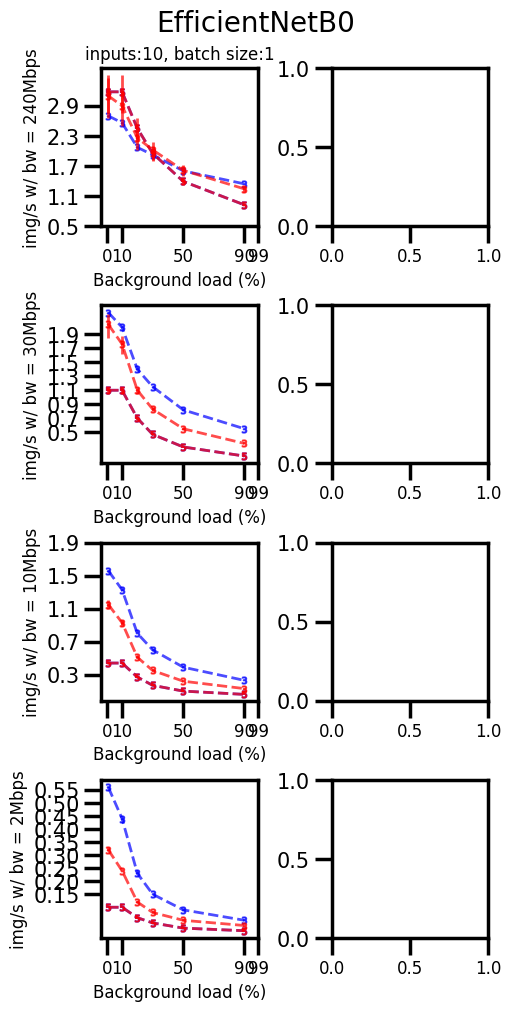

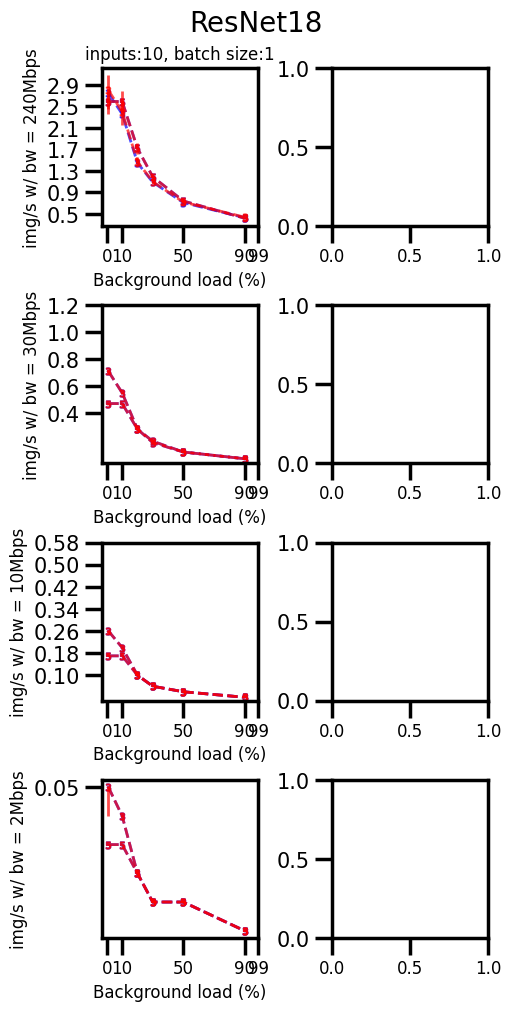

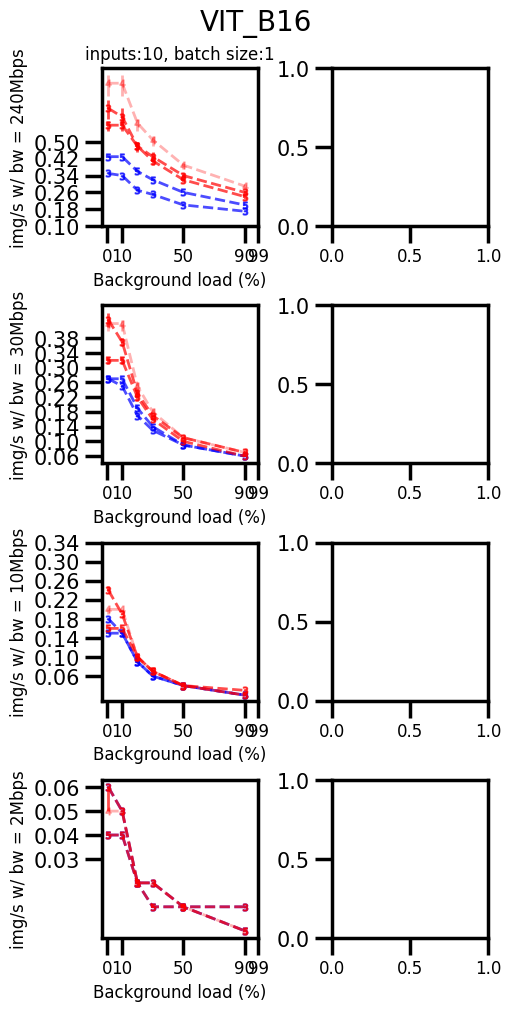

In [ ]:
# bws=[240, 2]
bws=[240, 30, 20, 15, 10, 2, 1]
import seaborn as sns
sns.set_context("poster", font_scale=1, rc={"font.size":7, "ytick.labelsize":15, "xtick.labelsize":12, "lines.linewidth":2, "axes.labelsize":12, "axes.titlesize":12})
# import seaborn as sns
# sns.set_context("talk", rc={"font.size":10, "axes.labelsize":35,"xtick.labelsize":35, "ytick.labelsize":35})

# bws=[240, 10, 1]
bws=[240, 30, 10, 2]
# bws=[240, 1]

combos = [[1,10], [2,5], [5,2], [10,1]]
combos = [[1,10], [10,1]]
inc_ind = [0, 3]
# combos = [[1,10], [10,1]]
# combos=[[1,100],[100,1]]
# combos = [[1,100], [2,50], [4,25], [5,20], [10,10], [20,5], [25,4], [50,2], [100,1]]
# eff_fig, eff_axs = plt.subplots(len(bws), len(combos), figsize=(25,10), layout='constrained')
eff_fig, eff_axs = plt.subplots(len(bws), len(combos), figsize=(5,10), layout='constrained')
# eff_fig, eff_axs = plt.subplots(len(bws), len(combos), figsize=(25,30), layout='constrained')
# res_fig, res_axs = plt.subplots(len(bws), len(combos), figsize=(25,10), layout='constrained')
res_fig, res_axs = plt.subplots(len(bws), len(combos), figsize=(5,10), layout='constrained')
# res_fig, res_axs = plt.subplots(len(bws), len(combos), figsize=(25,30), layout='constrained')
# vit_fig, vit_axs = plt.subplots(len(bws), len(combos), figsize=(25,10), layout='constrained')
vit_fig, vit_axs = plt.subplots(len(bws), len(combos), figsize=(5,10), layout='constrained')
# vit_fig, vit_axs = plt.subplots(len(bws), len(combos), figsize=(25,30), layout='constrained')
m=["eff", "resnet18","vit"]
# overall_y = {model:[] for model in m }
# overall_pred_y={model:[] for model in m}
# overall_naive_y={model:[] for model in m}
overall_y = {}
overall_pred_y={}
overall_naive_y={}
for bw_ind, bw in enumerate(bws):
    # f=open(f"exploration.detailed.{bw}", "r")
    # f=open(f"exploration.detailed.{bw}.nw", "r")
    # f=open(f"exploration.detailed.{bw}.100img", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var", "r")
    f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "r")
    detailed_map = f.readlines()[0]
    detailed_map = literal_eval(detailed_map.strip())
    # print(detailed_map)
    for inp in detailed_map:
        for model in detailed_map[inp]:
            if model=="eff":
                eff_fig.suptitle("EfficientNetB0", fontsize=20)
            elif model=="resnet18":
                res_fig.suptitle("ResNet18", fontsize=20)
            elif model=="vit":
                vit_fig.suptitle("VIT_B16", fontsize=20)
            for world in detailed_map[inp][model]:
                # if world!=3 and world!=6:
                # if world!=6:
                #     continue
                x=sorted(list(detailed_map[inp][model][world]))
                # detailed_map[inp][model][world][x[0]]=[]
                for i in x:
                    #filter compute only runs
                    detailed_map[inp][model][world][i] = [detailed_map[inp][model][world][i][ind] for ind in range(len(detailed_map[inp][model][world][i])) if "nw" in detailed_map[inp][model][world][i][ind]]
                    # print(detailed_map[inp][model][world][i])
                # raise Exception("stop jhere?")
                # print(detailed_map[inp][model][world])
                for ind in range(len(detailed_map[inp][model][world][x[0]])):
                    if ind not in inc_ind:
                        continue
                    # if ind==2:
                    #     continue
                    # if ind > 2:
                    #     ind=ind-1
                    g_ind = ind if ind==inc_ind[0] else 1
                    if model=="eff":
                        axs = eff_axs[bw_ind][g_ind]
                    elif model=="vit":
                        axs = vit_axs[bw_ind][g_ind]
                    elif model=="resnet18":
                        axs=res_axs[bw_ind][g_ind]
                    # if "c" in detailed_map[inp][model][world][i][ind]
                    if bw==240:
                        k = f"{model}_{world}_{i}"
                        if k not in overall_y:
                            overall_pred_y[k]=[]
                            overall_naive_y[k]=[]
                            overall_y[k]=[]

                        # overall_y[model].extend([ detailed_map[inp][model][world][i][ind][0] for i in x])
                        # overall_y[model].extend([ detailed_map[inp][model][3][x[0]][0][0] for i in x])
                        overall_y[k].extend([ detailed_map[inp][model][world][i][0][0] for i in x])
                        # overall_pred_y[model].extend([ detailed_map[inp][model][world][i][ind][3] for i in x])
                        # overall_pred_y[model].extend([ detailed_map[inp][model][3][x[0]][0][3] for i in x])
                        overall_pred_y[k].extend([ detailed_map[inp][model][world][i][0][3] for i in x])
                        # overall_naive_y[model].extend([ detailed_map[inp][model][world][i][ind][4] for i in x])
                        # overall_naive_y[model].extend([ detailed_map[inp][model][3][x[0]][0][4] for i in x])
                        overall_naive_y[k].extend([ detailed_map[inp][model][world][i][0][4] for i in x])

                    # y=[ round(inp/detailed_map[inp][model][world][i][ind][0],2) for i in x]
                    # y=[ round(inp/detailed_map[inp][model][world][i][ind][0],2) for i in x]
                    y=[ round(inp/detailed_map[inp][model][world][i][ind][3],2) for i in x]
                    # pred_y = [inp/detailed_map[inp][model][world][i][ind][0] for i in x]

                    # y_err = [ 1/(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1]) for i in x]
                    bs = f"{detailed_map[inp][model][world][x[0]][ind][2]}"
                    num_inp = f"{detailed_map[inp][model][world][x[0]][ind][1]}"

                    y_err = [ 5/(10*(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1])) for i in x]
                    # y_err = [np.std(y) for i in x]
                    str_label = f"{detailed_map[inp][model][world][x[0]][ind][1]}_{detailed_map[inp][model][world][x[0]][ind][2]}_{world}"
                    t_x = [ round(100*i/map_sub[subcluster],2) for i in x]
                    # axs.plot(t_x,y, marker=f"${world}$", markersize=10 ,linestyle="--")
                    # fig, axs = plt.subplot(figsize=(25,10))
                    # axs.errorbar
                    # axs.errorbar(t_x,y, y_err, marker=f"${world}$", markersize=15 ,linestyle="--", color="blue")
                    axs.plot(t_x,y, marker=f"${world}$", markersize=5 ,linestyle="--", color="blue", alpha=0.7 if world in [3,5] else 0)
                    # axs.text(x[-1],y[-1],str_label)
                    axs.set_xlabel("Background load (%)")
                    # axs.set_ylabel(f"Throughput (10img/s) w/ bw = {bw}Mbps")
                    if g_ind==0:
                        axs.set_ylabel(f"img/s w/ bw = {bw}Mbps")
                    if bw_ind==0:
                        # axs.set_title(f"number of inputs:{bs}, batch size:{num_inp}, b/w:{bw}Mbps")
                        axs.set_title(f"inputs:{num_inp}, batch size:{bs}")
                    # axs.set_xticks(np.arange(0,100,10))
                    if model=="eff":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5,2.8, 0.2))
                        # elif bw==10:
                            # axs.set_yticks()
                            # pass
                        elif bw==2:
                            axs.set_yticks(np.arange(0.15, 1, 0.05))
                    if model=="resnet18":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5, 2.8, 0.2))
                        if bw==2:
                            axs.set_yticks(np.arange(0.05, 0.17, 0.01))
                    if model=="vit":
                        if bw==240:
                            axs.set_yticks(np.arange(0.1, 0.48, 0.02))
                        if bw==2:
                            axs.set_yticks(np.arange(0.03, 0.18, 0.01))

                # break
                

            # axs.set_title(f"{model}_{bw}mbps splits {world}")
            # break
            # axs.legend()
                
                    # str_label = [f"{detailed_map[inp][model][world][i][1]}_{detailed_map[inp][model][world][i][2]}" for i in x]
print(f"fmt is bn_bs")

for model in overall_y:
    y=overall_y[model]
    pred_y = overall_pred_y[model]
    # print(f"average best time for {model}: {np.mean(best_y[model])}, std dev: {np.std(best_y[model])}")
    print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    print(f"overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
    print(f"overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
    print(f"avg lat {model}: {np.median(y)}, std dev:{np.std(y)}")

    print()
    pred_y = overall_naive_y[model]
    print(f"naive overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(pred_y))]) )}")
    print(f"naive overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(pred_y))])}")
    print(f"naive overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(pred_y))])}%")
    print()


for bw_ind, bw in enumerate(bws):
    # f=open(f"exploration.detailed.{bw}", "r")
    # f=open(f"exploration.detailed.{bw}.nw", "r")
    # f=open(f"exploration.detailed.{bw}.100img", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var", "r")
    f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "r")

    detailed_map = f.readlines()[0]
    detailed_map = literal_eval(detailed_map.strip())
    # print(detailed_map)
    for inp in detailed_map:
        for model in detailed_map[inp]:
            # if model=="eff":
            #     eff_fig.suptitle(model)
            # elif model=="resnet18":
            #     res_fig.suptitle(model)
            # elif model=="vit":
            #     vit_fig.suptitle(model)
            for world in detailed_map[inp][model]:
                # if world!=3 and world!=6:
                # if world!=6:
                #     continue
                x=sorted(list(detailed_map[inp][model][world]))
                for i in x:
                    #filter compute only runs
                    detailed_map[inp][model][world][i] = [detailed_map[inp][model][world][i][ind] for ind in range(len(detailed_map[inp][model][world][i])) if "c" in detailed_map[inp][model][world][i][ind]]

                # detailed_map[inp][model][world][x[0]]=[]
                for ind in range(len(detailed_map[inp][model][world][x[0]])):
                    # if ind==2:
                    #     continue
                    # if ind > 2:
                    #     ind=ind-1
                    if ind not in inc_ind:
                        continue
                    g_ind = ind if ind==inc_ind[0] else 1

                    if model=="eff":
                        axs = eff_axs[bw_ind][g_ind]
                    elif model=="vit":
                        axs = vit_axs[bw_ind][g_ind]
                    elif model=="resnet18":
                        axs=res_axs[bw_ind][g_ind]
                    if bw==240:
                        k = f"{model}_{world}_{i}"
                        if k not in overall_y:
                            overall_pred_y[k]=[]
                            overall_naive_y[k]=[]
                            overall_y[k]=[]

                        # overall_y[model].extend([ detailed_map[inp][model][world][i][ind][0] for i in x])
                        # overall_y[model].extend([ detailed_map[inp][model][3][x[0]][0][0] for i in x])
                        overall_y[k].extend([ detailed_map[inp][model][world][i][0][0] for i in x])
                        # overall_pred_y[model].extend([ detailed_map[inp][model][world][i][ind][3] for i in x])
                        # overall_pred_y[model].extend([ detailed_map[inp][model][3][x[0]][0][3] for i in x])
                        overall_pred_y[k].extend([ detailed_map[inp][model][world][i][0][3] for i in x])
                        # overall_naive_y[model].extend([ detailed_map[inp][model][world][i][ind][4] for i in x])
                        # overall_naive_y[model].extend([ detailed_map[inp][model][3][x[0]][0][4] for i in x])
                        overall_naive_y[k].extend([ detailed_map[inp][model][world][i][0][4] for i in x])

                    # y=[ inp/detailed_map[inp][model][world][i][ind][0] for i in x]
                    # y=[ round(inp/detailed_map[inp][model][world][i][ind][0],2) for i in x]
                    y=[ round(inp/detailed_map[inp][model][world][i][ind][3],2) for i in x]
                    # if world==3:
                    #     print([detailed_map[inp][model][world][i][ind][3] for i in x], "C")
                    # pred_y = [inp/detailed_map[inp][model][world][i][ind][0] for i in x]

                    # y_err = [ 1/(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1]) for i in x]
                    bs = f"{detailed_map[inp][model][world][x[0]][ind][2]}"
                    num_inp = f"{detailed_map[inp][model][world][x[0]][ind][1]}"
                    y_err = [ round(detailed_map[inp][model][world][i][ind][-1],2) for i in x]
                    print(y_err)
                    y_err_plus = [  abs(y[x_ind] - round(inp/abs(detailed_map[inp][model][world][i][ind][3]+np.sqrt(detailed_map[inp][model][world][i][ind][-1])),2)) for x_ind, i in enumerate(x) ]
                    y_err_minus = [ abs(y[x_ind] - round(inp/abs(detailed_map[inp][model][world][i][ind][3]-np.sqrt(detailed_map[inp][model][world][i][ind][-1])),2)) for x_ind, i in enumerate(x) ]
                    print(y_err_plus, y_err_minus)
                    
                    # y_err = [ 5/(10*(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1])) for i in x]
                    # y_err = [np.std(y) for i in x]
                    # print(f"for bg_load {}")
                    str_label = f"{detailed_map[inp][model][world][x[0]][ind][1]}_{detailed_map[inp][model][world][x[0]][ind][2]}_{world}"
                    t_x = [ round(100*i/map_sub[subcluster],2) for i in x]
                    # axs.plot(t_x,y, marker=f"${world}$", markersize=10 ,linestyle="--")
                    # fig, axs = plt.subplot(figsize=(25,10))
                    # axs.errorbar(t_x, y, y)
                    # axs.errorbar(t_x,y, y_err, marker=f"${world}$", markersize=15 ,linestyle="--", color="red")
                    # axs.plot(t_x,y, marker=f"${world}$", markersize=15 ,linestyle="--", color="red", alpha=0.7 if world in [3,5] else (0 if model!="vit" else (0.3 if world==4 else 0)))
                    axs.errorbar(t_x,y, yerr=[y_err_minus, y_err_plus] ,marker=f"${world}$", markersize=5 ,linestyle="--", color="red", alpha=0.7 if world in [3,5] else (0 if model!="vit" else (0.3 if world==4 else 0)))
                    # axs.errorbar(t_x, y, )
                    # axs.text(x[-1],y[-1],str_label)
                    axs.set_xlabel("Background load (%)")
                    # axs.set_ylabel(f"Throughput (10img/s) w/ bw = {bw}Mbps")
                    if g_ind==0:
                        axs.set_ylabel(f"img/s w/ bw = {bw}Mbps")
                    if bw_ind==0:
                        # axs.set_title(f"number of inputs:{bs}, batch size:{num_inp}, b/w:{bw}Mbps")
                        axs.set_title(f"inputs:{num_inp}, batch size:{bs}")
                    axs.set_xticks([0,10,50,90,99])
                    if model=="eff":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5,3.4, 0.6))
                        elif bw==10:
                            axs.set_yticks(np.arange(0.3, 2.3, 0.4))
                        elif bw==30:
                            axs.set_yticks(np.arange(0.5,2.0, 0.2))

                        # elif bw==10:
                            # axs.set_yticks()
                            # pass
                        elif bw==1:
                            axs.set_yticks(np.arange(0.1, 1, 0.2))
                    if model=="resnet18":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5, 3, 0.4))
                        elif bw==10:
                            axs.set_yticks(np.arange(0.1, 0.63, 0.08))
                        elif bw==30:
                            axs.set_yticks(np.arange(0.4,1.4, 0.2))
                        if bw==1:
                            axs.set_yticks(np.arange(0.02, 0.09, 0.01))
                    if model=="vit":
                        if bw==240:
                            axs.set_yticks(np.arange(0.1, 0.54, 0.08))
                        if bw==30:
                            axs.set_yticks(np.arange(0.06, 0.41, 0.04))
                        if bw==10:
                            axs.set_yticks(np.arange(0.06, 0.35, 0.04))
                        if bw==1:
                            axs.set_yticks(np.arange(0.01, 0.11, 0.02))

                # break
                

            # axs.set_title(f"{model}_{bw}mbps splits {world}")
            # break
            # axs.legend()
print(f"fmt is bn_bs for comp")

for model in overall_y:
    y=overall_y[model]
    pred_y = overall_pred_y[model]
    # print(f"average best time for {model}: {np.mean(best_y[model])}, std dev: {np.std(best_y[model])}")
    print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    # print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    print(f"overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
    print(f"overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
    print(f"avg lat {model}: {np.median(y)}, std dev:{np.std(y)}")
    print()
    pred_y = overall_naive_y[model]
    print(f"naive overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(pred_y))]) )}")
    print(f"naive overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(pred_y))])}")
    print(f"naive overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(pred_y))])}%")
    print()

# eff_fig.savefig("eff_explore.pdf")
# res_fig.savefig("res_explore.pdf")
# vit_fig.savefig("vit_explore.pdf")

eff 2 rmse: 0.6393991319981597
eff 2 mae: 0.5356250000000036
eff 2 avg latency: 78.3075
eff 10 rmse: 0.6405856695243811
eff 10 mae: 0.5374999999999996
eff 10 avg latency: 18.2325
eff 30 rmse: 0.6402245699752538
eff 30 mae: 0.534999999999999
eff 30 avg latency: 8.2225
eff 70 rmse: 0.6400048827938736
eff 70 mae: 0.5368749999999997
eff 70 avg latency: 5.36125
eff 240 rmse: 0.6383572667401853
eff 240 mae: 0.5350000000000001
eff 240 avg latency: 3.8425000000000002
resnet18 2 rmse: 0.3514167753537309
resnet18 2 mae: 0.29687500000001776
resnet18 2 avg latency: 264.9925
resnet18 10 rmse: 0.3504818112256282
resnet18 10 mae: 0.29624999999999746
resnet18 10 avg latency: 54.488749999999996
resnet18 30 rmse: 0.35116769498346634
resnet18 30 mae: 0.296875000000001
resnet18 30 avg latency: 19.403750000000002
resnet18 70 rmse: 0.34985711369071715
resnet18 70 mae: 0.2949999999999994
resnet18 70 avg latency: 9.379999999999999
resnet18 240 rmse: 0.35184336003397865
resnet18 240 mae: 0.2968749999999998
res

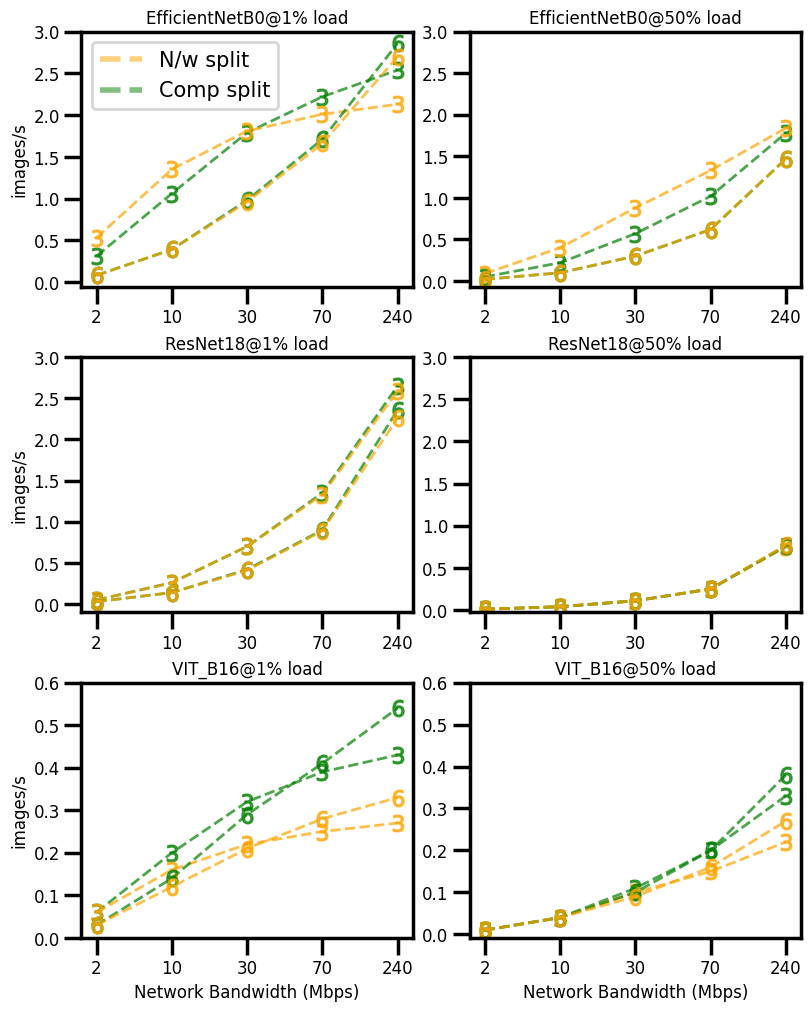

In [ ]:
#against changing network instead
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
sns.set_context("poster", rc={"font.size":5, "legend.fontsize":15, "ytick.labelsize":12, "xtick.labelsize":12, "lines.linewidth":2, "axes.labelsize":12, "axes.titlesize":12})
subcluster="bramble-2-4"
table_header = "model,bg_load,bw,type,splits,throughput,err_plus,err_minus\n"
table_lines=[]
bws = [240,70, 30,10,2]
bws=sorted(bws)
# loads=[1,10,50,90]
# loads=[1,10,30]
# loads=[1,30,50]
loads=[1,50]
pred_y={"eff":{b:[] for b in bws}, "resnet18":{b:[] for b in bws}, "vit":{b:[] for b in bws}}
real_y={"eff":{b:[] for b in bws}, "resnet18":{b:[] for b in bws}, "vit":{b:[] for b in bws}}
models=["eff","resnet18","vit"]
fig, multi_axs = plt.subplots(len(models),len(loads), figsize=(8,10), layout="constrained")
# legend_elements = [ Line2D([0], [0], color='orange', lw=4, linestyle="--", label='6 splits N/W', alpha=0.5),
#                     Line2D([0], [0], linestyle="--", color='green', lw=4, label='3 splits N/W', alpha=0.5),
#         #    Line2D([0], [0], marker='o', color='w', label='Scatter',
#         #           markerfacecolor='g', markersize=15),
#                     Patch(facecolor='orange',label='6 splits Comp', alpha=0.2),
#                     Patch(facecolor='green',label='3 splits Comp', alpha=0.2)
#                     ]
legend_elements = [ Line2D([0], [0], color='orange', lw=4, linestyle="--", label='N/w split', alpha=0.5),
                    Line2D([0], [0], linestyle="--", color='green', lw=4, label='Comp split', alpha=0.5),
        #    Line2D([0], [0], marker='o', color='w', label='Scatter',
        #           markerfacecolor='g', markersize=15),
                    # Patch(facecolor='orange',label='6 splits Comp', alpha=0.2),
                    # Patch(facecolor='green',label='3 splits Comp', alpha=0.2)
                    ]
multi_axs[0][0].legend(handles=legend_elements, loc="upper left")
best_latency = {"eff":{b:[] for b in bws}, "resnet18":{b:[] for b in bws}, "vit":{b:[] for b in bws}}
# multi_axs[0][1].legend(handles=legend_elements, loc="upper left")
# fig.tight_layout()
for l_ind, load in enumerate(loads):
    # load=90
    world_to_throughput = {r:{} for r in [3,4,5,6]}
    for bw_ind, bw in enumerate(bws):
        # f=open(f"exploration.detailed.{bw}", "r")
        # f=open(f"exploration.detailed.{bw}.nw", "r")
        # f=open(f"exploration.detailed.{bw}.100img", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var", "r")
        f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "r")
        detailed_map = f.readlines()[0]
        detailed_map = literal_eval(detailed_map.strip())
        # print(detailed_map)
        for inp in detailed_map:
            # print(inp)
            for model in detailed_map[inp]:
                # if model=="eff":
                #     eff_fig.suptitle(model)
                # elif model=="resnet18":
                #     res_fig.suptitle(model)
                # elif model=="vit":
                #     vit_fig.suptitle(model)
                for world in detailed_map[inp][model]:
                    if model not in world_to_throughput[world]:
                        world_to_throughput[world][model]={"c":[],"nw":[], "c_err_plus":[], "c_err_minus":[],"nw_err_plus":[], "nw_err_minus":[]}
                    # if world!=3 and world!=6:
                    # if world!=6:
                    #     continue
                    # x=sorted(list(detailed_map[inp][model][world]))
                    for bg_load in detailed_map[inp][model][world]:
                        bg = round(100*bg_load/map_sub[subcluster],2)
                        # print(bg)
                        if bg == load:
                            # print(detailed_map[inp][model][world][bg_load][0])
                            for entry in detailed_map[inp][model][world][bg_load]:
                                if "c" in entry and entry[2]==1 and entry[1]==10:
                                    world_to_throughput[world][model]["c"].append(round(10/entry[0],2))
                                    pred_y[model][bw].append(round(entry[3],2))
                                    real_y[model][bw].append(round(entry[0],2))
                                    if load==1:
                                        best_latency[model][bw].append(round(entry[0],2))
                                    # print(entry[0], world, "c", load, model, bw)
                                    world_to_throughput[world][model]["c_err_plus"].append(abs(round(10/entry[0],2) - round(10/(entry[0]+entry[-1]),2)))
                                    world_to_throughput[world][model]["c_err_minus"].append(abs(round(10/entry[0],2) - round(10/(entry[0]-entry[-1]),2)))
                                    table_str = f"{model},{bg},{bw},c,{round(10/entry[0],2)},{abs(round(10/entry[0],2) - round(10/(entry[0]+entry[-1]),2))},{abs(round(10/entry[0],2) - round(10/(entry[0]-entry[-1]),2))}"
                                    table_lines.append(f"{table_str}\n")
                                    # world_to_throughput[world][model]["c"].append(round(entry[0],2))
                                    # world_to_throughput[world][model]["c_err_plus"].append(round(entry[-1],2))
                                    # world_to_throughput[world][model]["c_err_minus"].append(round(entry[-1],2))
                                if "nw" in entry and entry[2]==1 and entry[1]==10:
                                    # print(entry[0], world, "nw")
                                    pred_y[model][bw].append(round(entry[3],2))
                                    real_y[model][bw].append(round(entry[0],2))
                                    if load==1:
                                        best_latency[model][bw].append(round(entry[0],2))
                                    world_to_throughput[world][model]["nw"].append(round(10/entry[0],2))
                                    world_to_throughput[world][model]["nw_err_plus"].append(abs(round(10/entry[0],2) - round(10/(entry[0]+entry[-1]),2)))
                                    world_to_throughput[world][model]["nw_err_minus"].append(abs(round(10/entry[0],2) - round(10/(entry[0]-entry[-1]),2)))
                                    table_str = f"{model},{bg},{bw},nw,{round(10/entry[0],2)},{abs(round(10/entry[0],2) - round(10/(entry[0]+entry[-1]),2))},{abs(round(10/entry[0],2) - round(10/(entry[0]-entry[-1]),2))}"
                                    table_lines.append(f"{table_str}\n")


                                    # world_to_throughput[world][model]["nw"].append(round(entry[0],2))
                                    # world_to_throughput[world][model]["nw_err_plus"].append(round(entry[-1],2))
                                    # world_to_throughput[world][model]["nw_err_minus"].append(round(entry[-1],2))
                            # if "c" in detailed_map[inp][model][world][bg_load][0]:
    # print(world_to_throughput)

    # f=open(f"crossover_table_at_{load}.csv","w")
    # f.write(table_header)
    # f.writelines(table_lines)
    # f.close()


    for m_ind, model in enumerate(["eff", "resnet18", "vit"]):
        # fig, axs = plt.subplots(figsize=(25,10))
        axs = multi_axs[m_ind][l_ind]
        mode_map={"eff":"EfficientNetB0", "resnet18":"ResNet18", "vit":"VIT_B16"}
        axs.set_title(f"{mode_map[model]}@{load}% load")
        
        
        
        for w in world_to_throughput:
            # if w in [3,4,5,6]:
            if w in [3,6]:
                # axs.plot(bws, world_to_throughput[w][model]['c'], linestyle="--", marker=f"${w}$", color="red")
                # axs.errorbar(bws, world_to_throughput[w][model]['c'], yerr=[world_to_throughput[w][model]['c_err_minus'], world_to_throughput[w][model]['c_err_plus']], 
                # linestyle="--", marker=f"${w}$", color="red")
                
                # axs.bar([i+0.2 if w==3 else i-0.2 for i in range(len(bws))], world_to_throughput[w][model]['c'], width=0.4, alpha=0.2, color="green" if w==3 else "orange")
                # axs.errorbar([i+0.2 if w==3 else i-0.2 for i in range(len(bws))], world_to_throughput[w][model]['c'], yerr=[world_to_throughput[w][model]['c_err_minus'], world_to_throughput[w][model]['c_err_plus']], 
                # linestyle="none", marker="none", color="green" if w==3 else "orange", alpha=0.2)
                axs.errorbar([i if w==3 else i for i in range(len(bws))], world_to_throughput[w][model]['c'], #yerr=[world_to_throughput[w][model]['c_err_minus'], world_to_throughput[w][model]['c_err_plus']], 
                linestyle="--", marker=f"${w}$", color="green", alpha=0.7)

                # print(world_to_throughput[w][model]['c'], world_to_throughput[w][model]['c_err_minus'], world_to_throughput[w][model]['c_err_plus'])
                # axs.plot(bws, world_to_throughput[w][model]['nw'], linestyle="--", marker=f"${w}$", color="blue")
                # axs.errorbar([i for i in range(len(bws))], world_to_throughput[w][model]['nw'], yerr=[world_to_throughput[w][model]['nw_err_minus'], world_to_throughput[w][model]['nw_err_plus']], 
                # linestyle="--", marker=f"${w}$", color="blue", alpha=0.5)
                
                # axs.errorbar([i for i in range(len(bws))], world_to_throughput[w][model]['nw'], yerr=[max(world_to_throughput[w][model]['nw_err_minus'][i], world_to_throughput[w][model]['nw_err_plus'][i]) for i in range(len(world_to_throughput[w][model]['nw_err_plus']))], 
                # linestyle="--", marker="none", color="green" if w==3 else "orange", alpha=0.7)
                axs.errorbar([i for i in range(len(bws))], world_to_throughput[w][model]['nw'], #yerr=[max(world_to_throughput[w][model]['nw_err_minus'][i], world_to_throughput[w][model]['nw_err_plus'][i]) for i in range(len(world_to_throughput[w][model]['nw_err_plus']))], 
                linestyle="--", marker=f"${w}$", color="orange", alpha=0.7)

                # axs.errorbar([i for i in range(len(bws))], world_to_throughput[w][model]['nw'], yerr=[world_to_throughput[w][model]['nw_err_minus'], world_to_throughput[w][model]['nw_err_plus']], 
                # linestyle="--", marker="none", color="green" if w==3 else "orange", alpha=0.7)
                # axs.plot([i for i in range(len(bws))], world_to_throughput[w][model]['nw'], 
                # linestyle="--", marker="none", color="green" if w==3 else "orange", alpha=0.7)
                both_min = min(min(world_to_throughput[w][model]['c']),  min(world_to_throughput[w][model]['nw']))
                both_max = max(max(world_to_throughput[w][model]['c']),  max(world_to_throughput[w][model]['nw']))
                if model=="resnet18":
                    # axs.set_yticks(np.arange(0,7,1))
                    # if l_ind==0:
                    axs.set_yticks(np.arange(0,3.5,0.5))
                    # elif l_ind==1:
                    #     axs.set_yticks(np.arange(0,2.2,0.2))

                elif model=="vit":
                    # axs.set_yticks(np.arange(0,0.7,0.1))
                    axs.set_yticks(np.arange(0,0.7,0.1))
                else:
                    # axs.set_yticks(np.arange(0,5,1))
                    # if l_ind==0:
                    #     axs.set_yticks(np.arange(0,4,1))
                    # elif l_ind==1:
                    axs.set_yticks(np.arange(0,3.5,0.5))
                    # axs.set_yticks(np.arange(0,2,0.1))
                    
                axs.set_xticks(np.arange(0,len(bws),1))
                axs.set_xticklabels([f"{i}" for i in bws])
                if m_ind==len(models)-1:
                    axs.set_xlabel("Network Bandwidth (Mbps)")
                if l_ind==0:
                    axs.set_ylabel("images/s")
                # axs.set_yticks(np.arange(both_min, both_max+0.01, 0.01))
                # axs.set_yscale("log")
                # axs.set_xscale("log")
        
for model in pred_y:
    for bw in pred_y[model]:
        a=[i for i in real_y[model][bw]]
        b=[i for i in pred_y[model][bw]]
        c=[i for i in best_latency[model][bw]]
        print(f"{model} {bw} rmse: { np.sqrt(np.mean( [(a[i]-b[i])**2 for i in range(len(a))] ))}")
        print(f"{model} {bw} mae: {np.mean( [abs(a[i]-b[i]) for i in range(len(a))] )}")
        print(f"{model} {bw} avg latency: {np.mean(c)}")
fig.savefig("envelope_plot_line_plot.pdf",bbox_inches="tight", pad_inches=0.05)

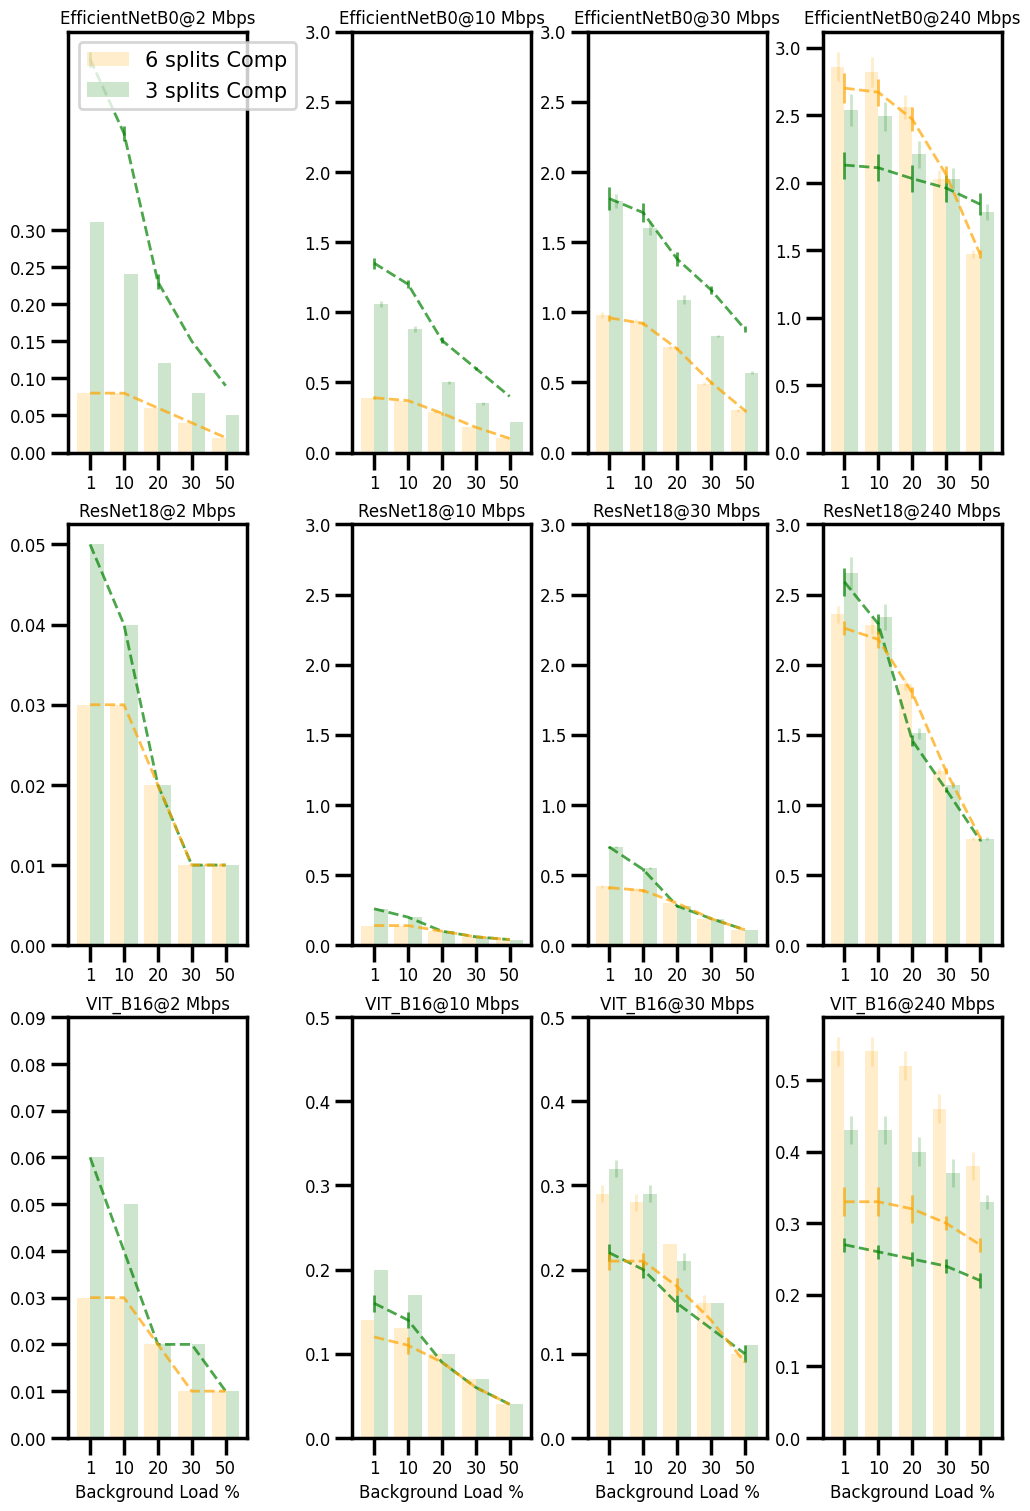

In [ ]:
#against changing network instead
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
sns.set_context("poster", rc={"font.size":5, "legend.fontsize":15, "ytick.labelsize":12, "xtick.labelsize":12, "lines.linewidth":2, "axes.labelsize":12, "axes.titlesize":12})
subcluster="bramble-2-4"
table_header = "model,bg_load,bw,type,splits,throughput,err_plus,err_minus\n"
table_lines=[]
# bws = [240,70, 30,10,2]
# bws = [240, 70, 30]
bws = [240, 30, 10, 2]
bws=sorted(bws)
loads=[1,10,20,30,50]
models=["eff","resnet18","vit"]
fig, multi_axs = plt.subplots(len(models),len(bws), figsize=(10,15), layout="constrained")
legend_elements = [ 
                # Line2D([0], [0], color='orange', lw=4, linestyle="--", label='6 splits N/W', alpha=0.5),
                #     Line2D([0], [0], linestyle="--", color='green', lw=4, label='3 splits N/W', alpha=0.5),
        #    Line2D([0], [0], marker='o', color='w', label='Scatter',
        #           markerfacecolor='g', markersize=15),
                    Patch(facecolor='orange',label='6 splits Comp', alpha=0.2),
                    Patch(facecolor='green',label='3 splits Comp', alpha=0.2)
                    ]
multi_axs[0][0].legend(handles=legend_elements, loc="upper left")
# multi_axs[0][1].legend(handles=legend_elements, loc="upper left")
# fig.tight_layout()
for bw_ind, bw in enumerate(bws):

    # load=90
    world_to_throughput = {r:{} for r in [3,4,5,6]}
        # f=open(f"exploration.detailed.{bw}", "r")
        # f=open(f"exploration.detailed.{bw}.nw", "r")
        # f=open(f"exploration.detailed.{bw}.100img", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err", "r")
        # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var", "r")
    for l_ind, load in enumerate(loads):
    
        f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "r")
        detailed_map = f.readlines()[0]
        detailed_map = literal_eval(detailed_map.strip())
        # print(detailed_map)
        for inp in detailed_map:
            # print(inp)
            for model in detailed_map[inp]:
                # if model=="eff":
                #     eff_fig.suptitle(model)
                # elif model=="resnet18":
                #     res_fig.suptitle(model)
                # elif model=="vit":
                #     vit_fig.suptitle(model)
                for world in detailed_map[inp][model]:
                    if model not in world_to_throughput[world]:
                        world_to_throughput[world][model]={"c":[],"nw":[], "c_err_plus":[], "c_err_minus":[],"nw_err_plus":[], "nw_err_minus":[]}
                    # if world!=3 and world!=6:
                    # if world!=6:
                    #     continue
                    # x=sorted(list(detailed_map[inp][model][world]))
                    for bg_load in detailed_map[inp][model][world]:
                        bg = round(100*bg_load/map_sub[subcluster],2)
                        # print(bg)
                        if bg == load:
                            # print(detailed_map[inp][model][world][bg_load][0])
                            for entry in detailed_map[inp][model][world][bg_load]:
                                if "c" in entry and entry[2]==1 and entry[1]==10:
                                    world_to_throughput[world][model]["c"].append(round(10/entry[0],2))
                                    # print(entry[0], world, "c", load, model, bw)
                                    world_to_throughput[world][model]["c_err_plus"].append(abs(round(10/entry[0],2) - round(10/(entry[0]+entry[-1]),2)))
                                    world_to_throughput[world][model]["c_err_minus"].append(abs(round(10/entry[0],2) - round(10/(entry[0]-entry[-1]),2)))
                                    table_str = f"{model},{bg},{bw},c,{round(10/entry[0],2)},{abs(round(10/entry[0],2) - round(10/(entry[0]+entry[-1]),2))},{abs(round(10/entry[0],2) - round(10/(entry[0]-entry[-1]),2))}"
                                    table_lines.append(f"{table_str}\n")
                                    # world_to_throughput[world][model]["c"].append(round(entry[0],2))
                                    # world_to_throughput[world][model]["c_err_plus"].append(round(entry[-1],2))
                                    # world_to_throughput[world][model]["c_err_minus"].append(round(entry[-1],2))
                                if "nw" in entry and entry[2]==1 and entry[1]==10:
                                    # print(entry[0], world, "nw")
                                    world_to_throughput[world][model]["nw"].append(round(10/entry[0],2))
                                    world_to_throughput[world][model]["nw_err_plus"].append(abs(round(10/entry[0],2) - round(10/(entry[0]+entry[-1]),2)))
                                    world_to_throughput[world][model]["nw_err_minus"].append(abs(round(10/entry[0],2) - round(10/(entry[0]-entry[-1]),2)))
                                    table_str = f"{model},{bg},{bw},nw,{round(10/entry[0],2)},{abs(round(10/entry[0],2) - round(10/(entry[0]+entry[-1]),2))},{abs(round(10/entry[0],2) - round(10/(entry[0]-entry[-1]),2))}"
                                    table_lines.append(f"{table_str}\n")

                                    # world_to_throughput[world][model]["nw"].append(round(entry[0],2))
                                    # world_to_throughput[world][model]["nw_err_plus"].append(round(entry[-1],2))
                                    # world_to_throughput[world][model]["nw_err_minus"].append(round(entry[-1],2))
                            # if "c" in detailed_map[inp][model][world][bg_load][0]:
    # print(world_to_throughput)

    # f=open(f"crossover_table_at_{load}.csv","w")
    # f.write(table_header)
    # f.writelines(table_lines)
    # f.close()


    for m_ind, model in enumerate(["eff", "resnet18", "vit"]):
        # fig, axs = plt.subplots(figsize=(25,10))
        axs = multi_axs[m_ind][bw_ind]
        mode_map={"eff":"EfficientNetB0", "resnet18":"ResNet18", "vit":"VIT_B16"}
        axs.set_title(f"{mode_map[model]}@{bw} Mbps")
        
        
        
        for w in world_to_throughput:
            # if w in [3,4,5,6]:
            if w in [3,6]:
                # axs.plot(bws, world_to_throughput[w][model]['c'], linestyle="--", marker=f"${w}$", color="red")
                # axs.errorbar(bws, world_to_throughput[w][model]['c'], yerr=[world_to_throughput[w][model]['c_err_minus'], world_to_throughput[w][model]['c_err_plus']], 
                # linestyle="--", marker=f"${w}$", color="red")
                axs.bar([i+0.2 if w==3 else i-0.2 for i in range(len(loads))], world_to_throughput[w][model]['c'], width=0.4, alpha=0.2, color="green" if w==3 else "orange")
                # axs.errorbar([i+0.2 if w==3 else i-0.2 for i in range(len(loads))], world_to_throughput[w][model]['c'], yerr=[world_to_throughput[w][model]['c_err_minus'], world_to_throughput[w][model]['c_err_plus']], 
                # linestyle="none", marker="none", color="green" if w==3 else "orange", alpha=0.2)
                axs.errorbar([i+0.2 if w==3 else i-0.2 for i in range(len(loads))], world_to_throughput[w][model]['c'], yerr=[ max(world_to_throughput[w][model]['c_err_minus'][i], world_to_throughput[w][model]['c_err_plus'][i]) for i in range(len(world_to_throughput[w][model]['c_err_plus']))], 
                linestyle="none", marker="none", color="green" if w==3 else "orange", alpha=0.2)
                # print(world_to_throughput[w][model]['c'], world_to_throughput[w][model]['c_err_minus'], world_to_throughput[w][model]['c_err_plus'])
                # axs.plot(bws, world_to_throughput[w][model]['nw'], linestyle="--", marker=f"${w}$", color="blue")
                # axs.errorbar([i for i in range(len(bws))], world_to_throughput[w][model]['nw'], yerr=[world_to_throughput[w][model]['nw_err_minus'], world_to_throughput[w][model]['nw_err_plus']], 
                # linestyle="--", marker=f"${w}$", color="blue", alpha=0.5)
                
                axs.errorbar([i for i in range(len(loads))], world_to_throughput[w][model]['nw'], yerr=[max(world_to_throughput[w][model]['nw_err_minus'][i], world_to_throughput[w][model]['nw_err_plus'][i]) for i in range(len(world_to_throughput[w][model]['nw_err_plus']))], 
                linestyle="--", marker="none", color="green" if w==3 else "orange", alpha=0.7)

                # axs.errorbar([i for i in range(len(bws))], world_to_throughput[w][model]['nw'], yerr=[world_to_throughput[w][model]['nw_err_minus'], world_to_throughput[w][model]['nw_err_plus']], 
                # linestyle="--", marker="none", color="green" if w==3 else "orange", alpha=0.7)
                # axs.plot([i for i in range(len(bws))], world_to_throughput[w][model]['nw'], 
                # linestyle="--", marker="none", color="green" if w==3 else "orange", alpha=0.7)
                both_min = min(min(world_to_throughput[w][model]['c']),  min(world_to_throughput[w][model]['nw']))
                both_max = max(max(world_to_throughput[w][model]['c']),  max(world_to_throughput[w][model]['nw']))
                if model=="resnet18":
                    if bw==2:
                        axs.set_yticks(np.arange(0,0.06,0.01))
                    else:
                        axs.set_yticks(np.arange(0,3.5,0.5))


                    # if l_ind==0:
                    #     axs.set_yticks(np.arange(0,4,0.5))
                    # elif l_ind==1:
                    #     axs.set_yticks(np.arange(0,2.2,0.2))

                elif model=="vit":
                    # axs.set_yticks(np.arange(0,0.7,0.1))
                    if bw==2:
                        axs.set_yticks(np.arange(0,0.1,0.01))
                    else:
                        axs.set_yticks(np.arange(0,0.6,0.1))
                else:
                    if bw==2:
                        axs.set_yticks(np.arange(0,0.35,0.05))
                    else:
                        axs.set_yticks(np.arange(0,3.5,0.5))
                    # if l_ind==0:
                    #     axs.set_yticks(np.arange(0,4,1))
                    # elif l_ind==1:
                    #     axs.set_yticks(np.arange(0,3,0.5))
                    # axs.set_yticks(np.arange(0,2,0.1))
                    
                axs.set_xticks(np.arange(0,len(loads),1))
                axs.set_xticklabels([f"{i if i!=16 else 10}" for i in loads])
                if m_ind==len(models)-1:
                    # axs.set_xlabel("Network Bandwidth (Mbps)")
                    axs.set_xlabel("Background Load %")
                if l_ind==0:
                    axs.set_ylabel("images/s")
                # axs.set_yticks(np.arange(both_min, both_max+0.01, 0.01))
                # axs.set_yscale("log")
                # axs.set_xscale("log")
        

# fig.savefig("envelope_plot.pdf",bbox_inches="tight", pad_inches=0.05)

In [ ]:
#simulation check!
#third result -> rmse, mae, mape low when using the curve
#best trial and how close greedy is compared to only_compute or only_communicate
#also check unthrottled devices are actually staying unthrottled lmao xd

#projected throughput per util -> need to fix how util calculated though with overhead!
# TODO
#also do achived throughput per util, instead of projected! see how tgat changes?
bws = [240, 5, 2]
iats = [0.01, 0.5, 1.0, 10.0]
sub="bramble-2-4"
inp=10
for model in m:
    # print(model)
    fig, axs = plt.subplots(figsize=(25,10))
    util_to_th_map={}
    for iat in iats:
        text_labels = []
        for bw in bws:
            filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.{sub}.eff.{bw}.{iat}"
            ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename)
            # print(overhead)
            # raise Exception("end it")
            real_ts={}
            visited=[]
            for j in ts:
                if j not in real_ts:
                    real_ts[j]=0
                if j in visited:
                    continue
                visited.append(j)
                # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", "vit", world[j], overhead[j]-1,
                # bs[j], bn[j], bw=bw, ty=ty[j]) + added_time[j]
                real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, "eff", world[j], overhead[j],
                bs[j], bn[j], bw=bw, ty=ty[j])
                arr_t = added_time[j][0]
                wait_t = added_time[j][1]
                real_ts[j] = arr_t+wait_t+real_ts[j] 
                # print(real_ts[j])
                if overhead[j] not in util_to_th_map:
                    util_to_th_map[overhead[j]] = []
                util_to_th_map[overhead[j]].append( [round(float(inp*len(ts.values())/(real_ts[j])),3), f"{j}_{bw}_{iat}" ])
                
        # print(util_to_th_map)
        x = sorted( [i for i in list(util_to_th_map.keys()) ])
        y = [[i for i in set([j[0] for j in util_to_th_map[i]])] for i in x]
        text_y = [[i[1] for i in util_to_th_map[i]] for i in x]
        x = [round(100*i/map_sub[sub],2) for i in x]
        # print(x,y)
        for i in range(len(y)):
            axs.scatter( [x[i]]*len(y[i]),y[i])
            # axs.scatter( x[i], max(y[i]))
            # axs.text(x[i], max(y[i]),text_y[i][0])
            for j in range(len(y[i])):
                axs.text(x[i], y[i][j], text_y[i][j])




: 

In [ ]:
#simulation check!
#third result -> rmse, mae, mape low when using the curve
#best trial and how close greedy is compared to only_compute or only_communicate
#also check unthrottled devices are actually staying unthrottled lmao xd

#projected throughput per util -> need to fix how util calculated though with overhead!
# TODO
#also do achived throughput per util, instead of projected! see how tgat changes?
bws = [240, 5, 2]
# bws = [2]
iats = [0.01, 0.5, 1.0, 10.0]
sub="bramble-2-4"
inp=10
job_map = {}
for model in m:
    # print(model)
    fig, axs = plt.subplots(figsize=(25,10))
    axs1=axs.twinx()
    # axs.set_xscale("log")
    # axs1.set_xscale("log")

    if model not in job_map:
        job_map[model]={}
    
    for iat in iats:
        text_labels = []
        if iat not in job_map[model]:
            job_map[model][iat]={}
        
        for bw in bws:
            if bw not in job_map[model][iat]:
                job_map[model][iat][bw]={}
            filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.{sub}.{model}.{bw}.{iat}"
            ts, overhead, bs, bn, world, added_time, ty, ts_map = simulation_reader(filename)
            # print(overhead)
            # raise Exception("end it")
            real_ts_map={}
            ts_list = sorted(list(ts_map.keys()))

            real_ts={}
            for j in ts:
                if j not in real_ts:
                    real_ts[j]=0
                #final run time, based on arrival time, construct 
                real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, "eff", world[j], overhead[j],
                bs[j], bn[j], bw=bw, ty=ty[j])
                arr_t = added_time[j][0]
                wait_t = added_time[j][1]
                # if arr_t not in real_ts_map:
                #     real_ts_map[arr_t] = []
                for r in range(world[j]):
                    t= f"{j}_{r}"
                    # [t, w_t, r_t, arr_t, world, bn, bs ]
                    for ts_ind in ts_list:
                        if ts_ind not in real_ts_map:
                            real_ts_map[ts_ind]=[]
                        # print(ts_ind, arr_t, wait_t, real_ts[j], ts_ind >= arr_t, ts_ind <= arr_t+wait_t+real_ts[j])
                        if ts_ind >= arr_t and ts_ind <= arr_t+wait_t+real_ts[j]:
                            # print(ts_list)
                            if [t, wait_t, real_ts[j], arr_t, world[j], bn[j], bs[j]] not in real_ts_map[ts_ind]:
                                real_ts_map[ts_ind].append([t, wait_t, real_ts[j], arr_t, world[j], bn[j], bs[j]])

            # print([len(ts_map[k]) for k in ts_map.keys()])
            # print()
            # print([len(real_ts_map[k]) for k in real_ts_map.keys()])
            # raise Exception("end it")
            # fig, axs = plt.subplots(figsize=(25,10))
            x = sorted(list(real_ts_map.keys()))
            util_y = [round(100*len(real_ts_map[i])/map_sub[sub],2) for i in x]
            # util_y = [len(real_ts_map[i]) for i in x]
            util_per_s_y = []
            throughput_y = []
            for ind in range(len(x)):
                cur_set = set([i[0] for i in real_ts_map[x[ind]]])
                # if x[ind]!=0:
                #     util_per_s_y.append(util_y[ind]/x[ind])
                if ind+1 < len(x):
                    util_per_s_y.append(util_y[ind]/x[ind+1])
                    next_set = set([i[0] for i in real_ts_map[x[ind+1]]])
                else:
                    next_set = []
                    # util_per_s_y.append(0)
                inter_set = cur_set.intersection(next_set)
                fin_set = len(cur_set)-len(inter_set)
                if fin_set>0:
                    inps = [i[5]*i[6] for i in real_ts_map[x[ind]] if i[0] not in inter_set]
                    time_taken = max([i[1]+i[2]+i[3] for i in real_ts_map[x[ind]] if i[0] not in inter_set])
                    throughput_y.append(sum(inps)/time_taken)
                    if ind+1 >= len(x):
                        util_per_s_y.append(util_y[ind]/time_taken)
                else:
                    throughput_y.append(0)
            

            # axs.scatter( util_y, throughput_y, marker="x")
            # print( util_y, x, [0]+[util_y[i]/x[i] for i in range(1,len(x))], util_per_s_y)
            # print( throughput_y)
            # axs.plot( [np.log(i if i!=0 else 1) for i in util_y], [ np.log(i if i!=0 else 1) for i in throughput_y], marker="x", label=f"{iat}_{bw}")
            # axs.scatter( np.log(max(util_per_s_y)), np.log(max(throughput_y)), marker="x", label=f"{iat}_{bw}")
            # axs.set_xlabel("Util %")
            # axs.set_ylabel("Throughput img/s")
            # axs.legend()
            # # raise Exception("end it")
            # # axs.set_xscale("log")
            # # axs.set_yscale("log")
            # continue

            axs.plot(x,util_y, linestyle="--", marker="x", color="orange")
            axs.set_xlabel("Timestamp")
            axs.set_ylabel("Util %")
            # axs.set_title(f"Model:{model} bw:{bw}Mbps avg inter_arrival:{iat}s")
            axs1.set_ylabel("Throughput (inputs/s)")
            axs1.plot(x, throughput_y, linestyle="--", marker="x", color="blue")

            continue



            filename = f"../scheduler/sim.op.{sub}.{model}.{bw}.{iat}.only_best"
            ts, overhead, bs, bn, world, added_time, ty, ts_map = simulation_reader(filename)
            # print(overhead)
            # raise Exception("end it")
            real_ts_map={}
            ts_list = sorted(list(ts_map.keys()))

            real_ts={}
            for j in ts:
                if j not in real_ts:
                    real_ts[j]=0
                #final run time, based on arrival time, construct 
                real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit.csv", sub, "eff", world[j], overhead[j],
                bs[j], bn[j], bw=bw, ty=ty[j])
                arr_t = added_time[j][0]
                wait_t = added_time[j][1]
                # if arr_t not in real_ts_map:
                #     real_ts_map[arr_t] = []
                for r in range(world[j]):
                    t= f"{j}_{r}"
                    # [t, w_t, r_t, arr_t, world, bn, bs ]
                    for ts_ind in ts_list:
                        if ts_ind not in real_ts_map:
                            real_ts_map[ts_ind]=[]
                        # print(ts_ind, arr_t, wait_t, real_ts[j], ts_ind >= arr_t, ts_ind <= arr_t+wait_t+real_ts[j])
                        if ts_ind >= arr_t and ts_ind <= arr_t+wait_t+real_ts[j]:
                            # print(ts_list)
                            if [t, wait_t, real_ts[j], arr_t, world[j], bn[j], bs[j]] not in real_ts_map[ts_ind]:
                                real_ts_map[ts_ind].append([t, wait_t, real_ts[j], arr_t, world[j], bn[j], bs[j]])

            # print([len(ts_map[k]) for k in ts_map.keys()])
            # print()
            # print([len(real_ts_map[k]) for k in real_ts_map.keys()])
            # raise Exception("end it")
            # fig, axs = plt.subplots(figsize=(25,10))
            x = sorted(list(real_ts_map.keys()))
            util_y = [round(100*len(real_ts_map[i])/map_sub[sub],2) for i in x]
            throughput_y = []
            for ind in range(len(x)):
                cur_set = set([i[0] for i in real_ts_map[x[ind]]])
                if ind+1 < len(x):
                    next_set = set([i[0] for i in real_ts_map[x[ind+1]]])
                else:
                    next_set = []
                inter_set = cur_set.intersection(next_set)
                fin_set = len(cur_set)-len(inter_set)
                if fin_set>0:
                    inps = [i[5]*i[6] for i in real_ts_map[x[ind]] if i[0] not in inter_set]
                    time_taken = max([i[1]+i[2]+i[3] for i in real_ts_map[x[ind]] if i[0] not in inter_set])
                    throughput_y.append(fin_set/time_taken)
                else:
                    throughput_y.append(0)
            
            axs.plot(x,util_y, linestyle="--", marker="x", color="pink")
            axs.set_xlabel("Timestamp")
            axs.set_ylabel("Util %")
            # axs.set_title(f"Model:{model} bw:{bw}Mbps avg inter_arrival:{iat}s")
            axs1.set_ylabel("Throughput (inputs/s)")
            axs1.plot(x, throughput_y, linestyle="--", marker="x", color="green")

            # raise Exception("end it")
                # for run_set in real_ts_map[x[i]]:





                


            # for ts_ind in range(len(ts_list)-1):
            #     #emulated schedule run!
            #     cur_ts = ts_list[ts_ind]
            #     next_ts = ts_list[ts_ind]
            #     if cur_ts not in real_ts_map:
            #         real_ts_map[cur_ts]=[]
            #         real_ts_map[next_ts]=[]
            #     # ts_map[cur_ts][ind] = [t, w_t, r_t, ts, world, bn, bs ]
            #     job_map={}
            #     cur_overhead = len(ts_map[cur_ts])
            #     for ind in ts_map[cur_ts]:

                    # j_id = ts_map[cur_ts][ind][0].split("_")[0]
                    # if j_id not in job_map:
                    #     job_map[j_id] = []
                    # job_map[j_id] = 
                    # job_map[j_id].append([])
                    
            # best_fit_reader("best_fit.csv", sub, "eff", world[j], overhead[j], bs[j], bn[j], bw=bw, ty=ty[j])

            # visited=[]
            # for j in ts:
            #     if j not in real_ts:
            #         real_ts[j]=0
            #     if j in visited:
            #         continue
            #     # visited.append(j)
            #     real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit.csv", sub, "eff", world[j], overhead[j],
            #     bs[j], bn[j], bw=bw, ty=ty[j]) + added_time[j]
            #     if j not in job_map[model][iat][bw]:
            #         job_map[model][iat][bw][j] = []
                
            #     job_map[model][iat][bw][j].append([real_ts[j], overhead[j]])

#plot stuff here plz thenk
# for model in job_map:
#     fig, axs = plt.subplots(figsize=(25,10))
#     for iat in job_map[model]:

#         x = 
#         axs.plot()
                


NameError: name 'm' is not defined

/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.resnet18.30.0.01
total predicted time to completion of 16 jobs: 12.209470683616598, full throughput: 13.104581201435508, s/machine: 6.32832221057663
total real time to completion of 16 jobs: 12.946650770888805, full throughput: 12.358408582377772, s/machine: 7.1061250000000005
rmse: 0.9148323420851993
mape: 0.08028770711921994
/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.resnet18.30.0.01.only_comp only_comp
total predicted time to completion of 16 jobs: 12.209470683616598, full throughput: 13.104581201435508, s/machine: 6.32832221057663
total real time to completion of 16 jobs: 13.9084706836166, full throughput: 11.503780943254318, s/machine: 7.5815625
/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.resnet18.30.0.01.only_best only_best
total predicted time to completion of 16 jobs: 11.136, full throughput: 14

/var/folders/hw/swljgpyn0mn_cgf1fmg8gvsr0000gn/T/ipykernel_16486/2745037730.py:77: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(figsize=(25,10))


/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.eff.2.1.0.only_comp only_comp
total predicted time to completion of 16 jobs: 28.005000000000003, full throughput: 5.713265488305659, s/machine: 13.0749375
total real time to completion of 16 jobs: 29.872, full throughput: 5.356186395286556, s/machine: 14.820250000000005
/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.eff.2.1.0.only_comm only_comm
total predicted time to completion of 16 jobs: 23.026, full throughput: 6.948666724572223, s/machine: 8.080937500000003
total real time to completion of 16 jobs: 24.810000000000002, full throughput: 6.449012494961709, s/machine: 9.8100625
/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.eff.2.1.0.only_best only_best
total predicted time to completion of 16 jobs: 23.026, full throughput: 6.948666724572223, s/machine: 8.026000000000002
total real time to completion of 16 j

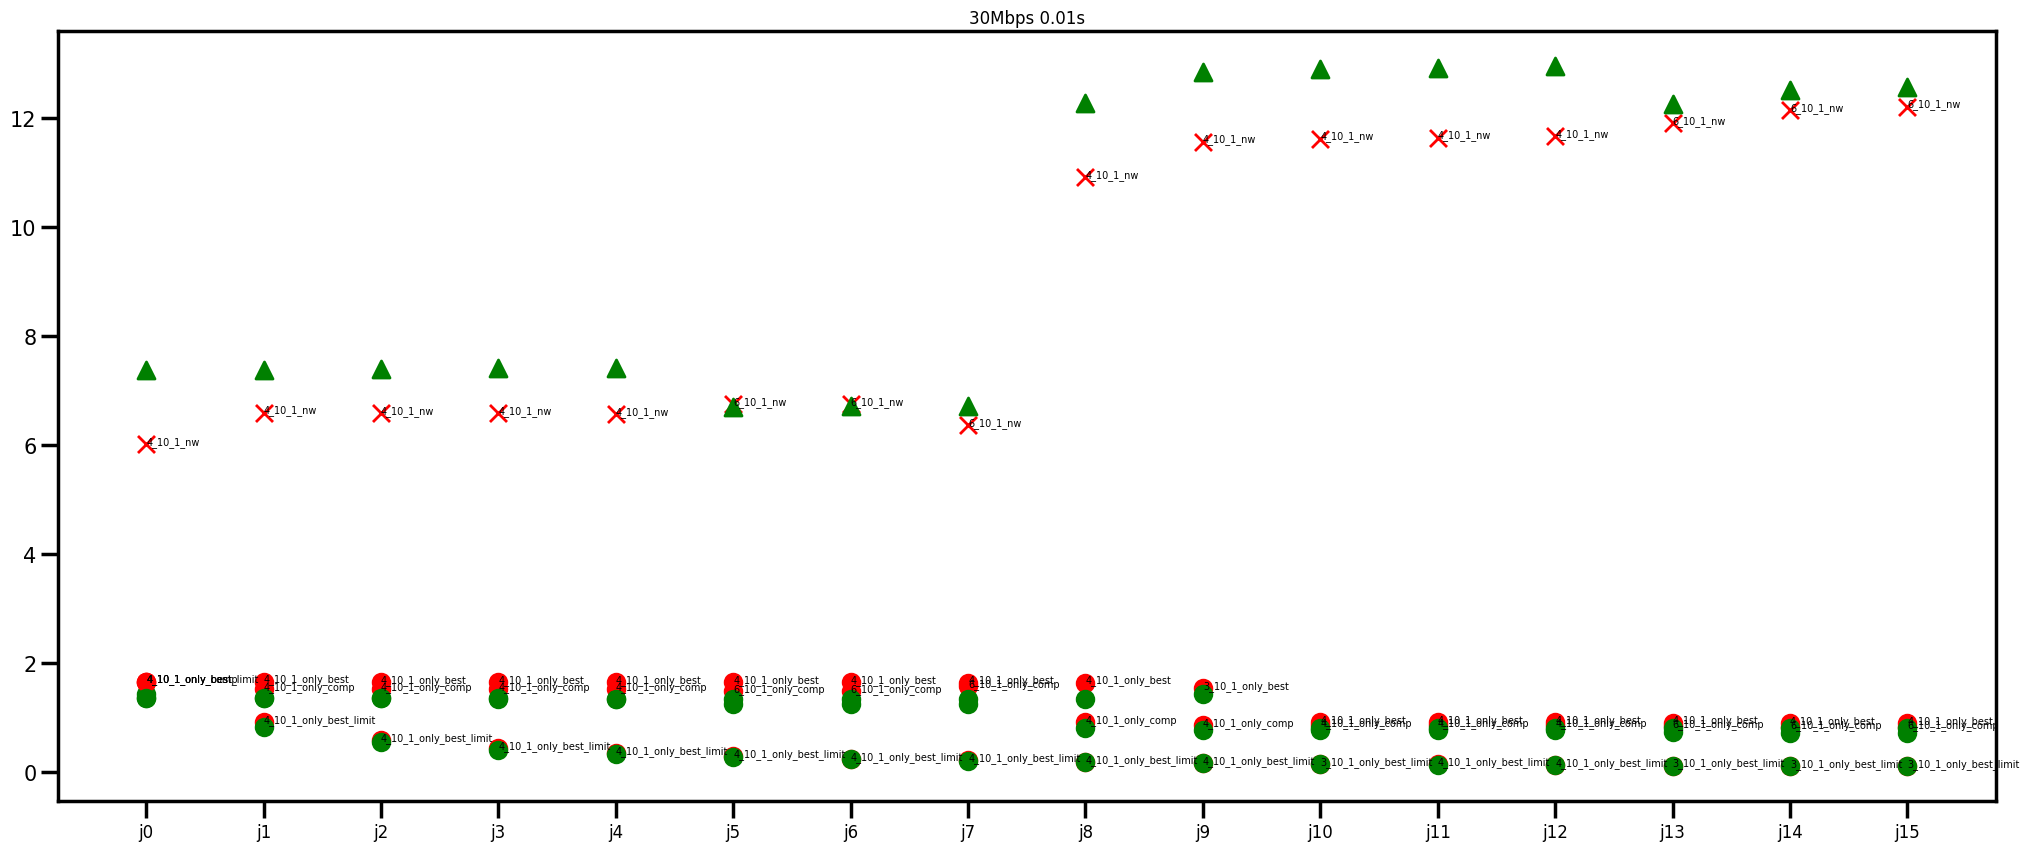

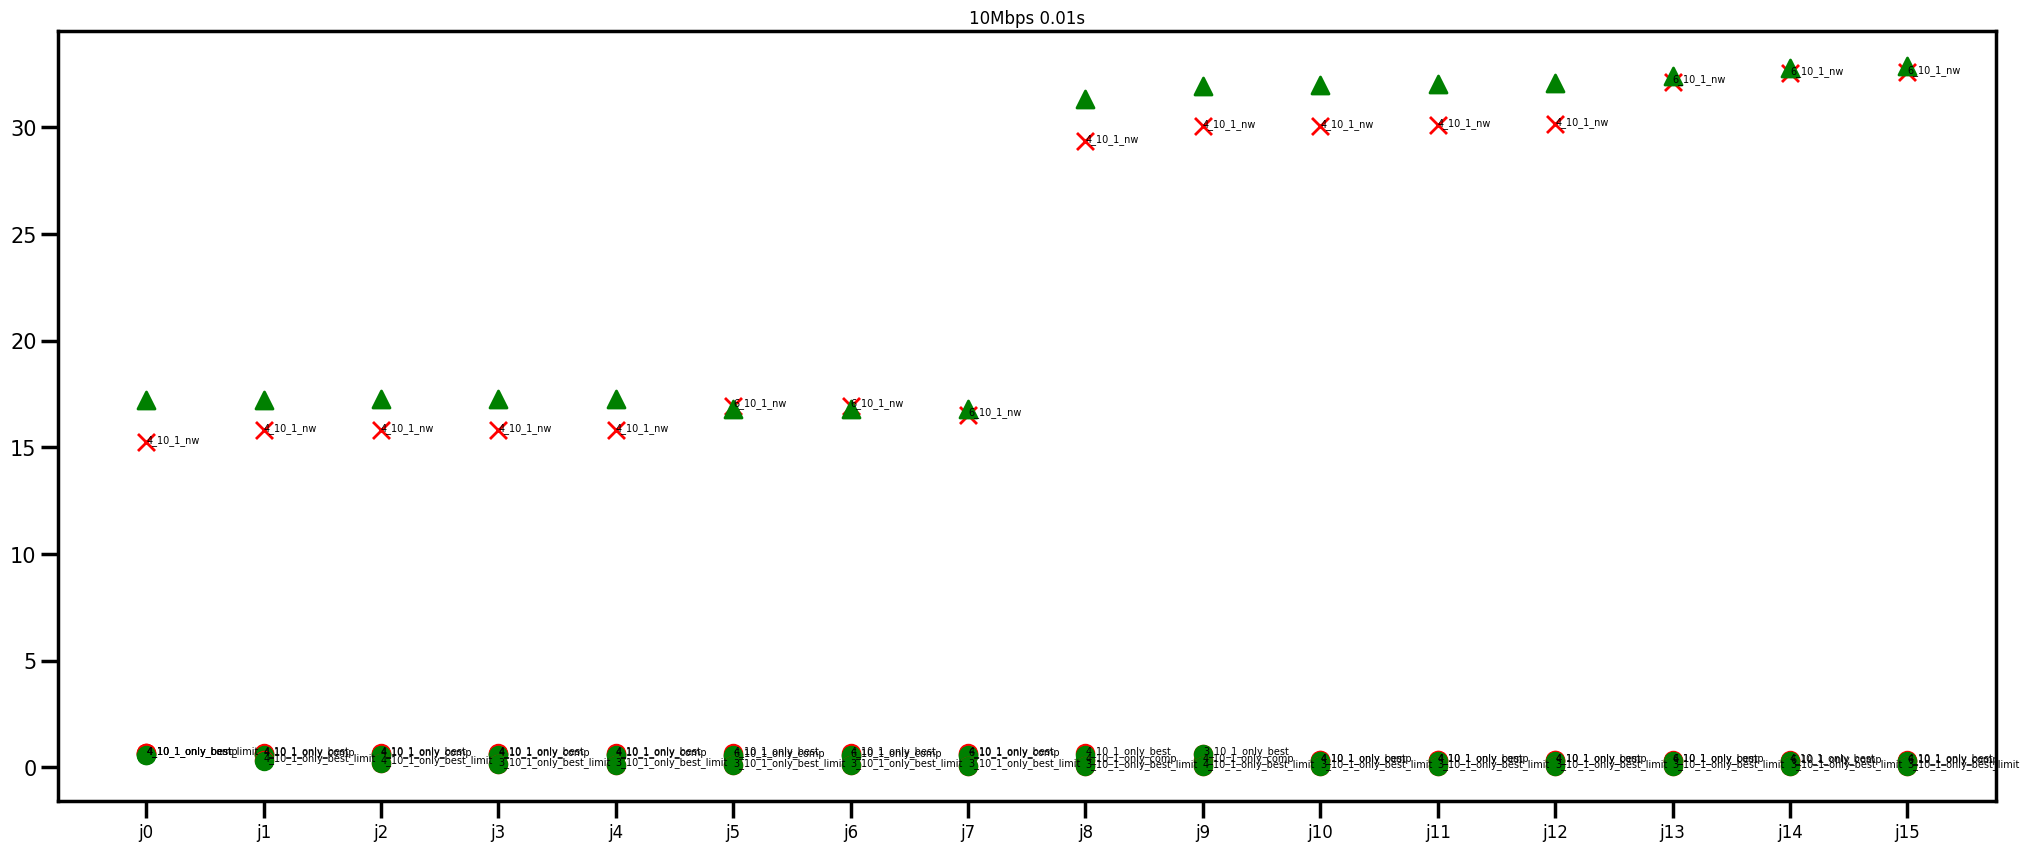

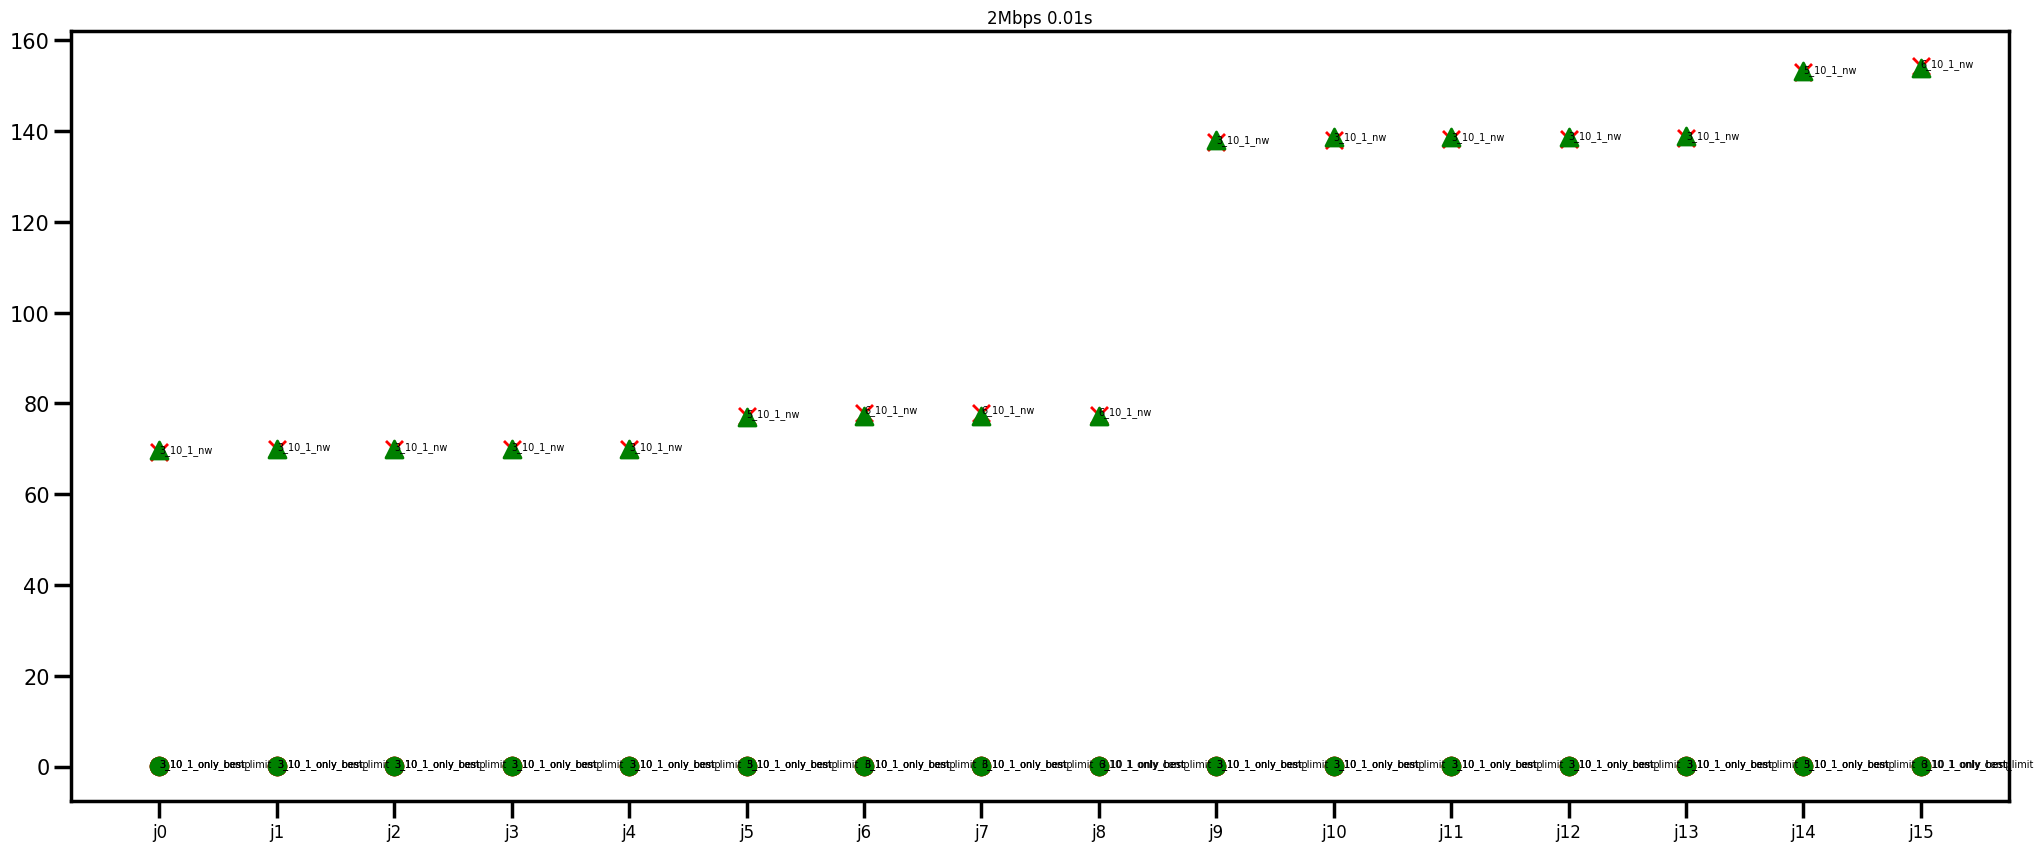

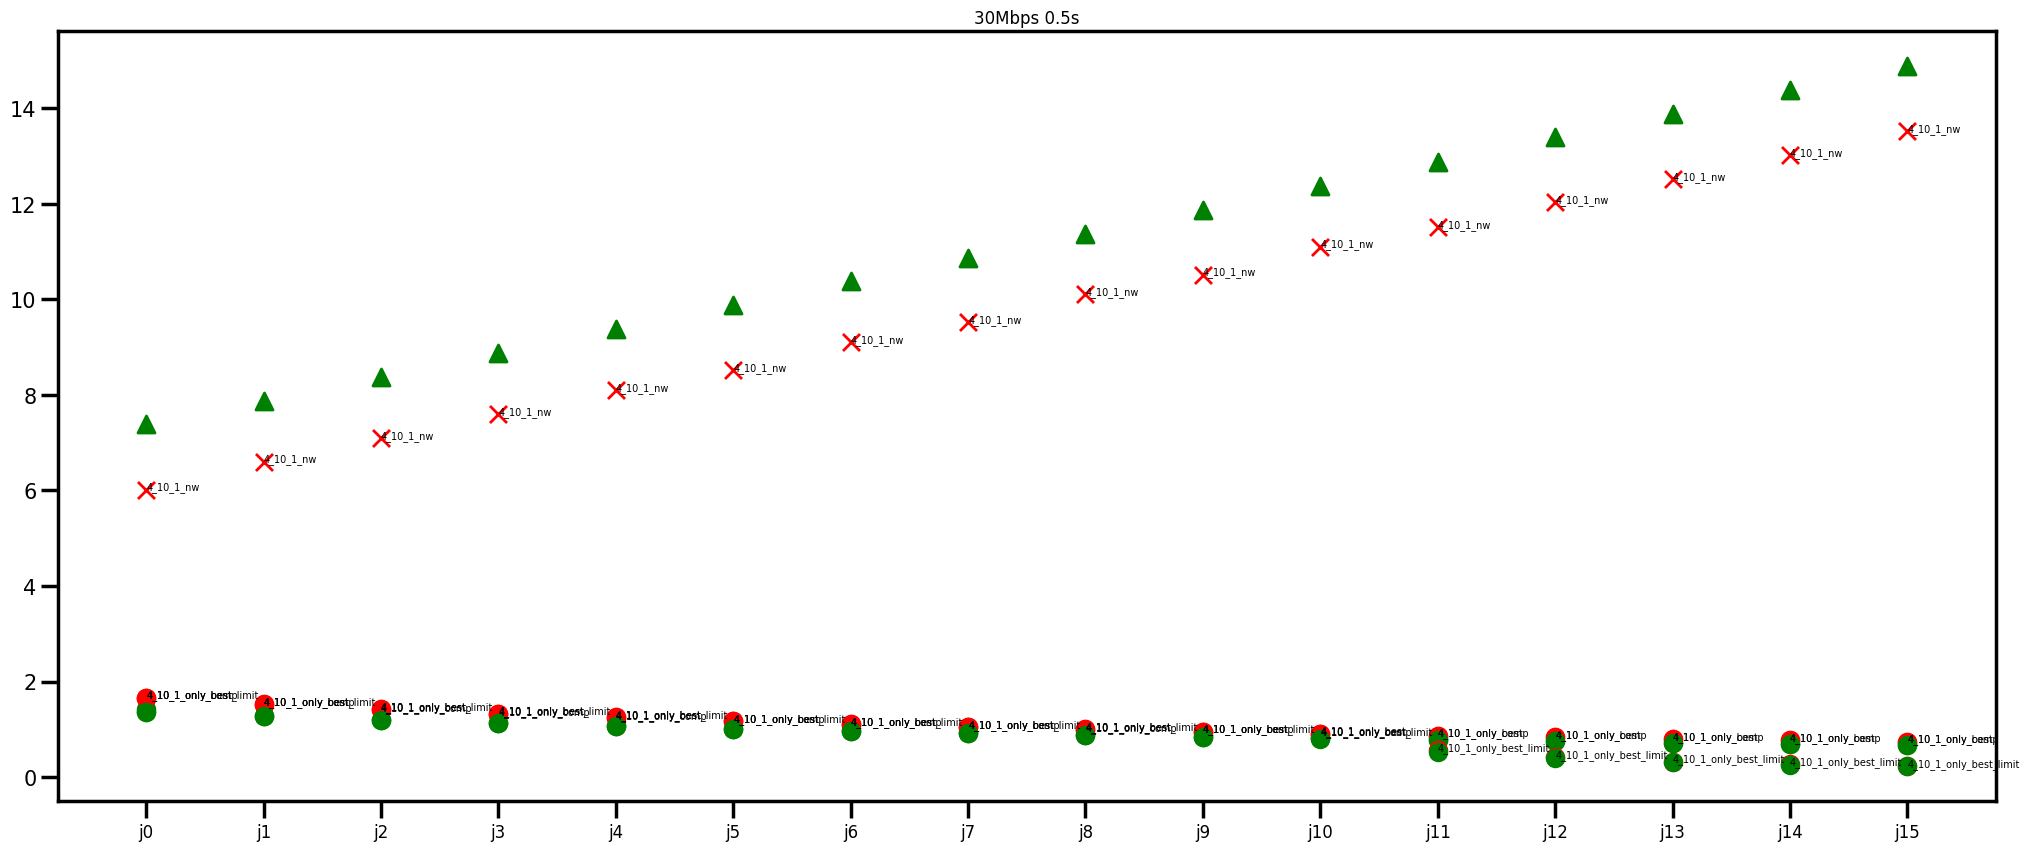

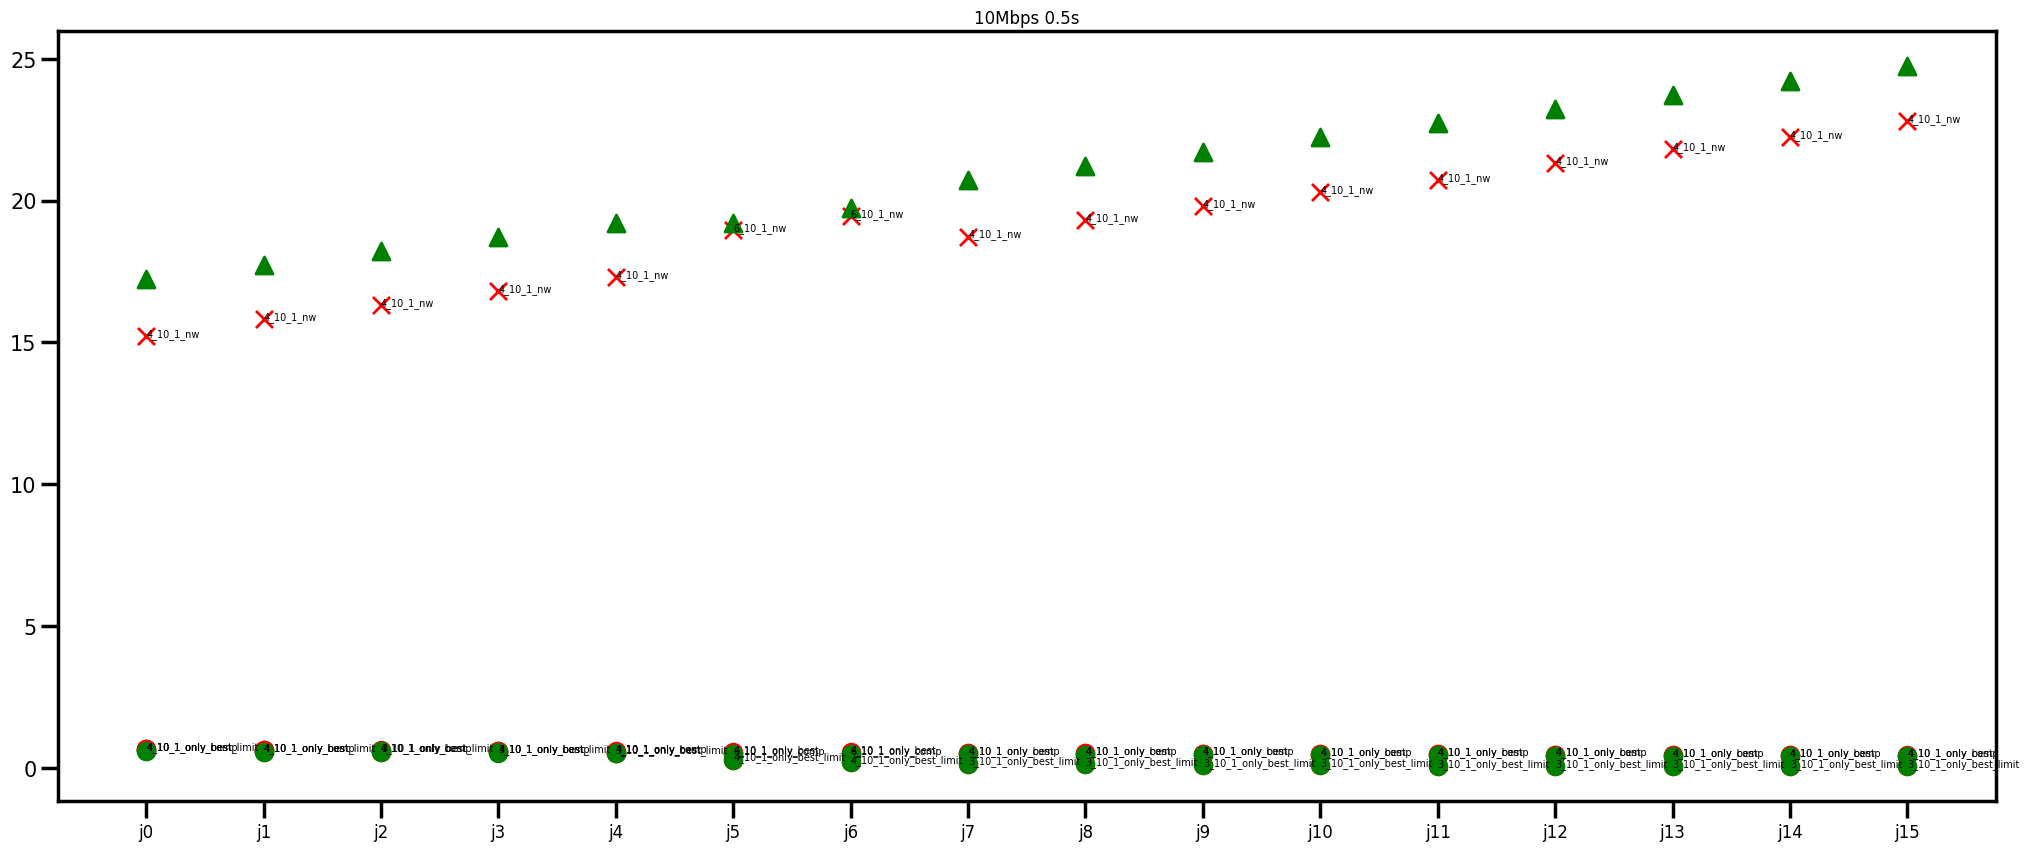

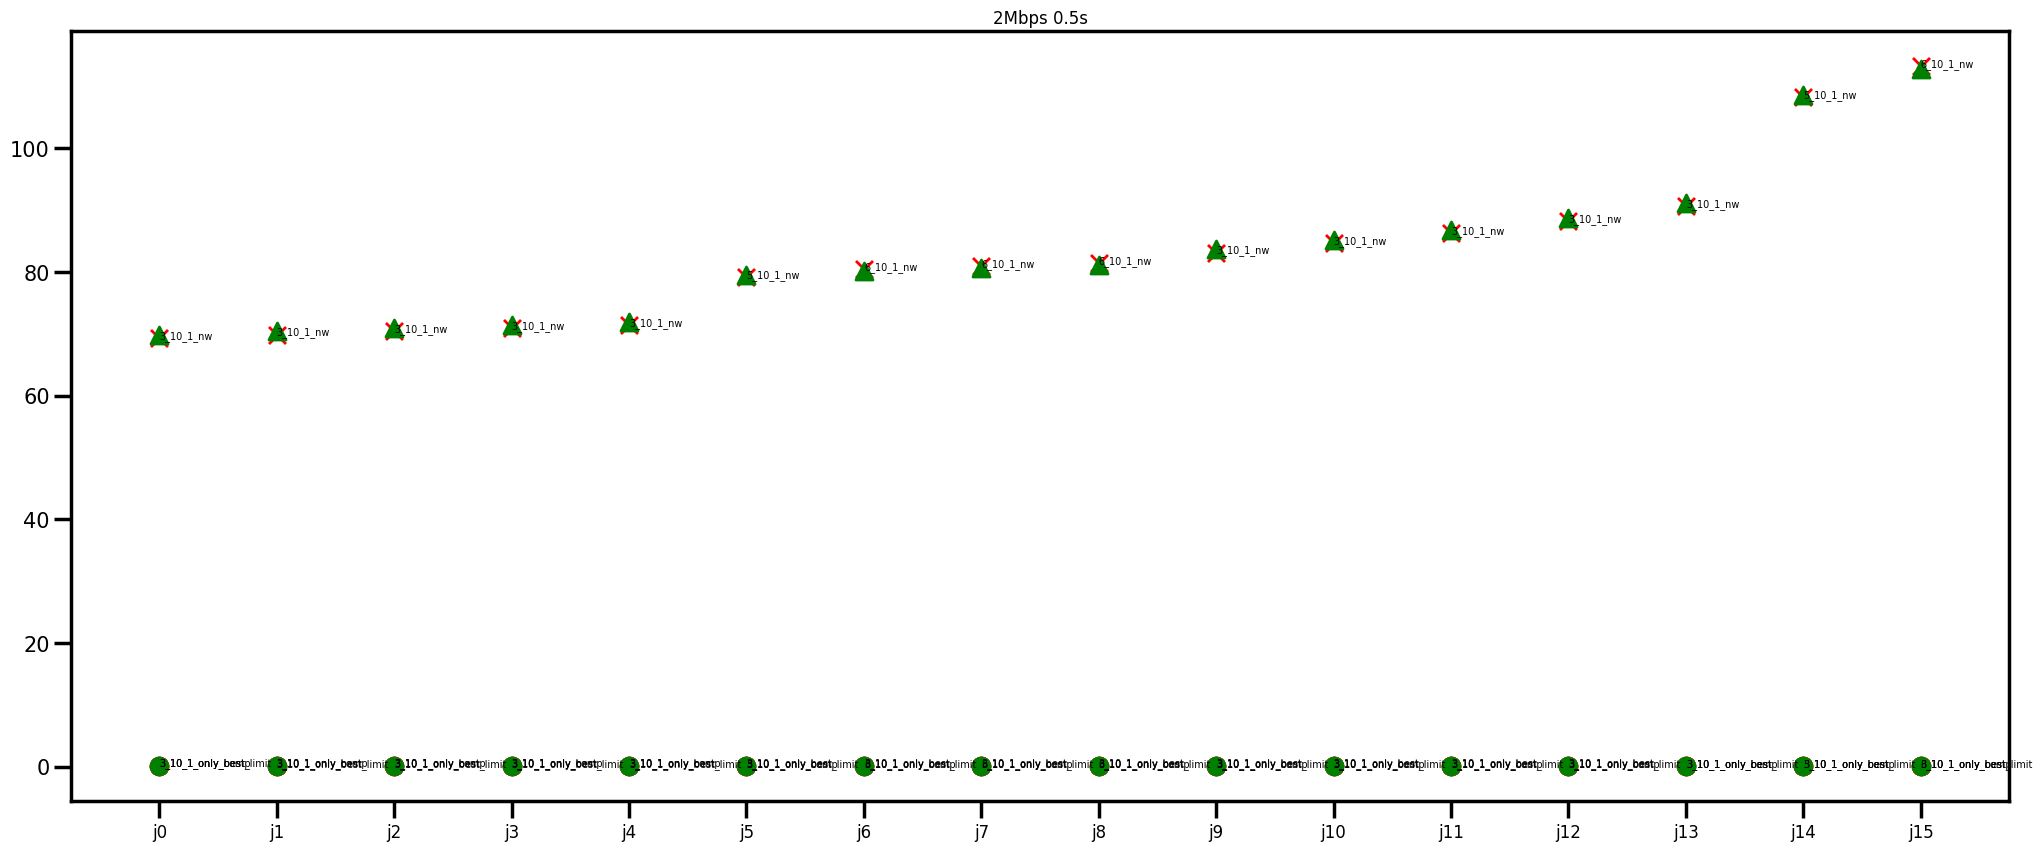

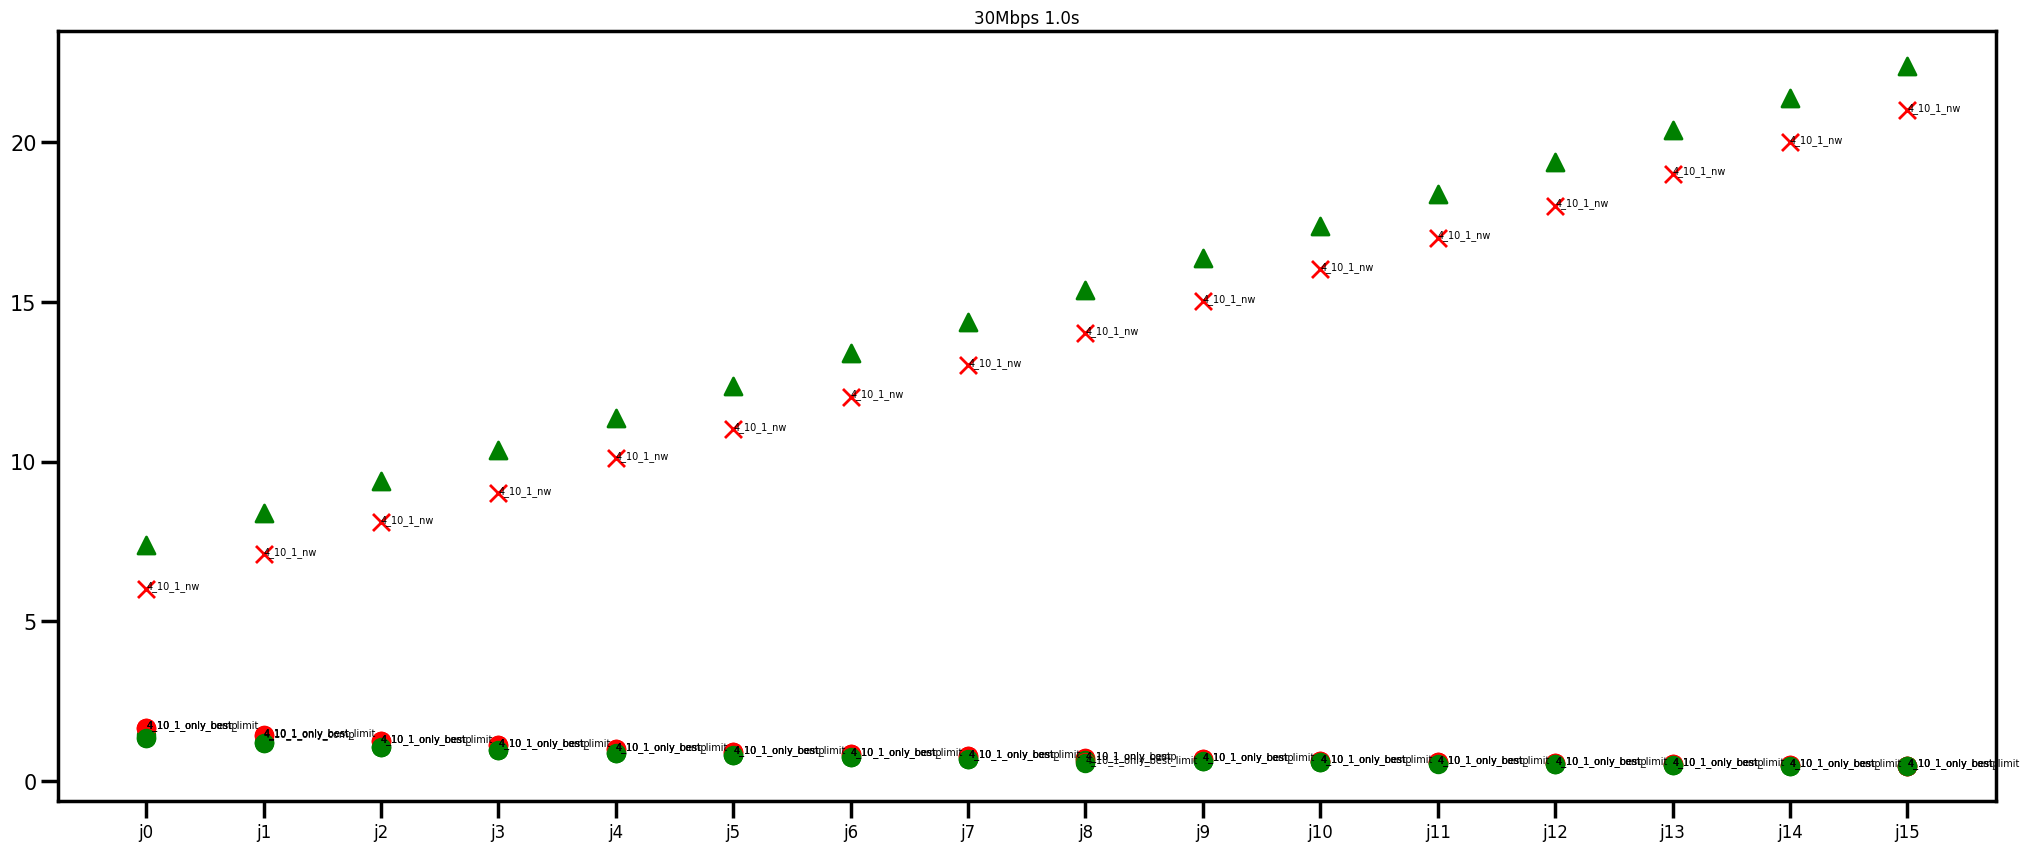

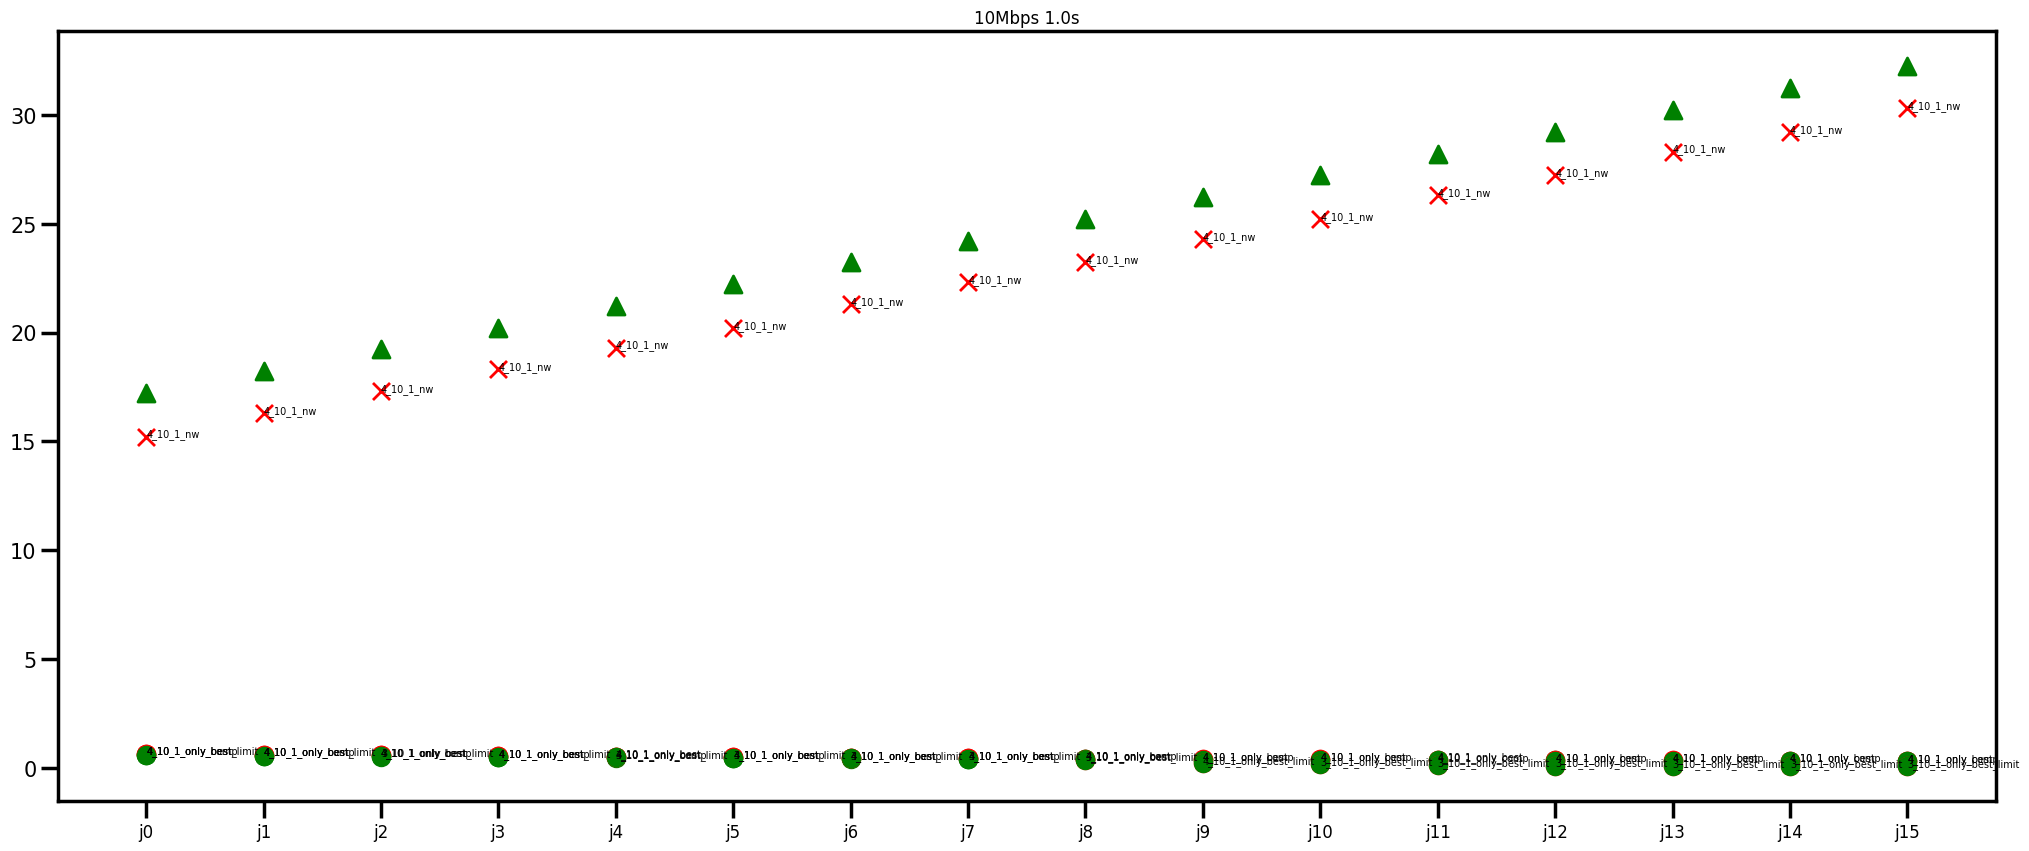

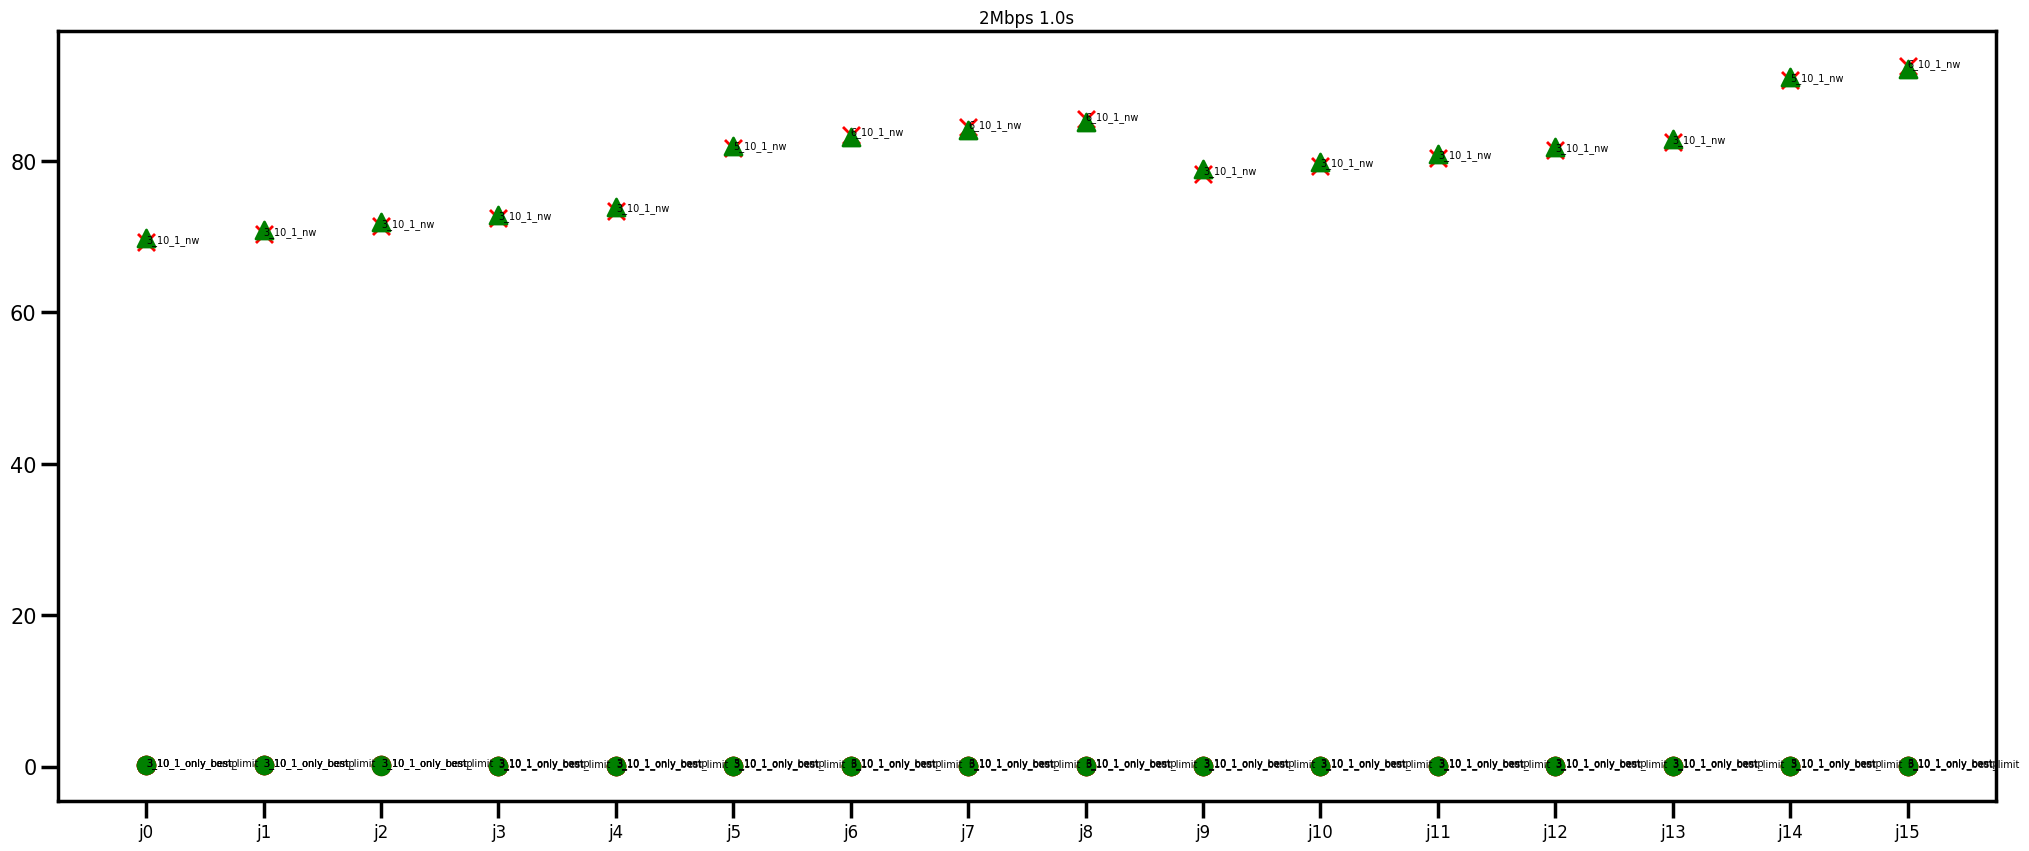

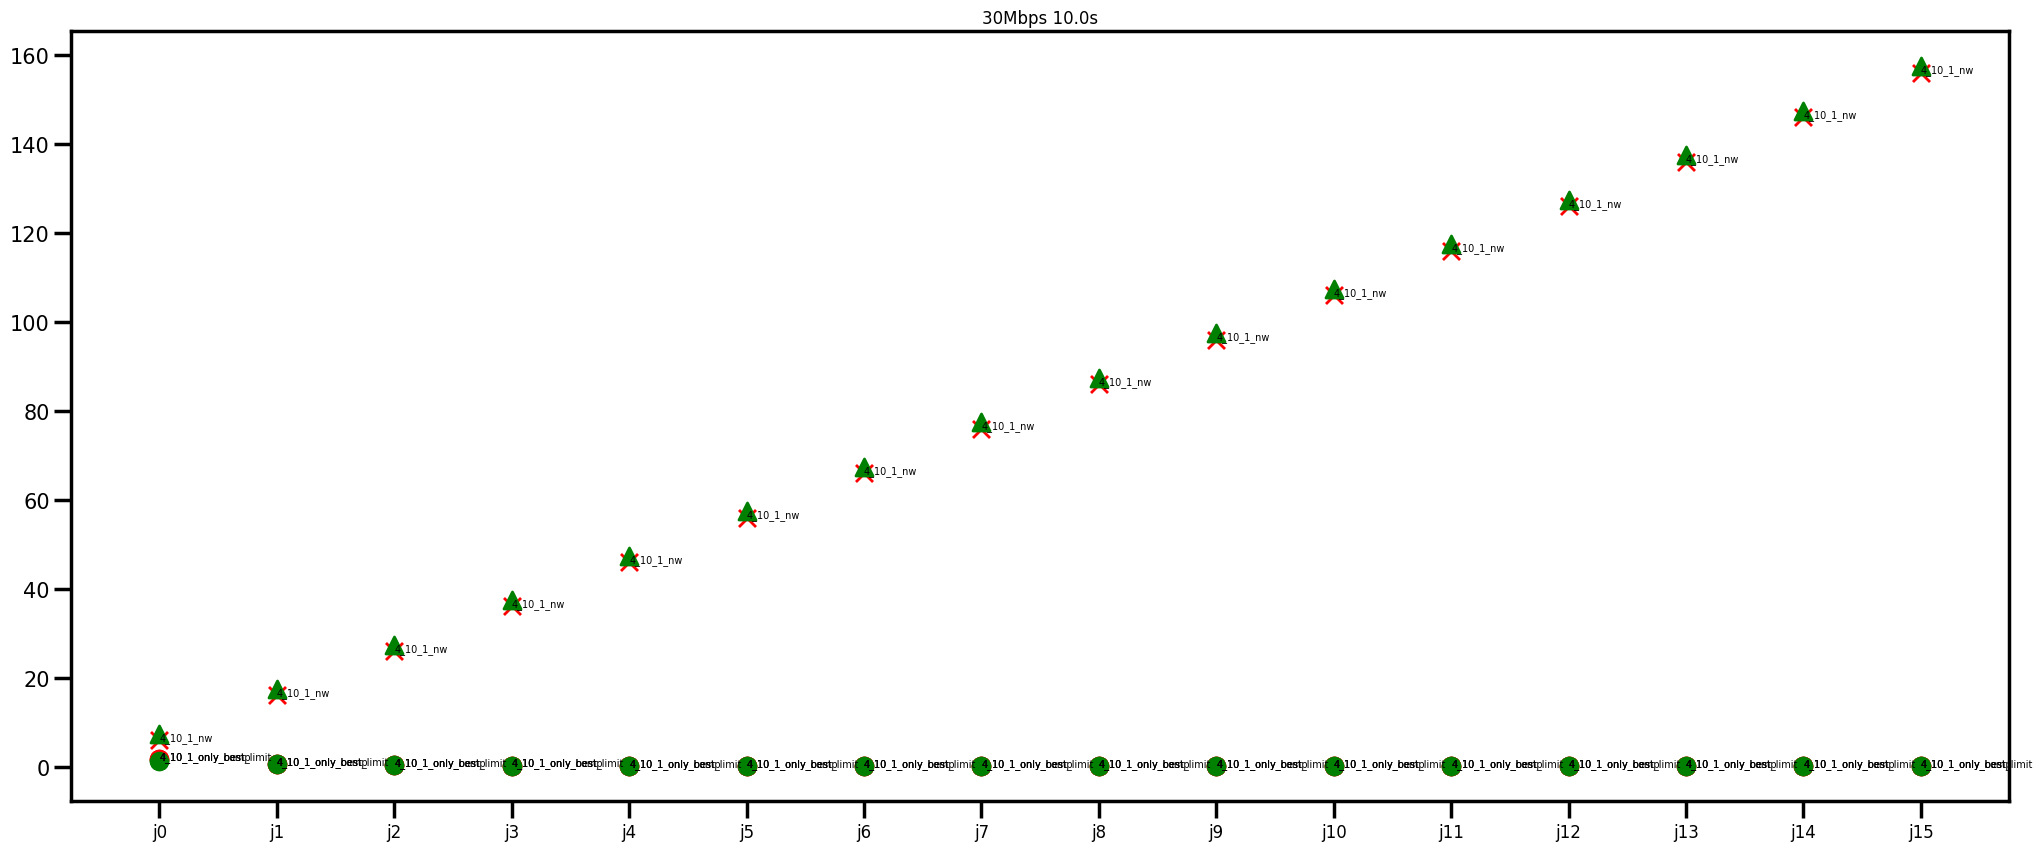

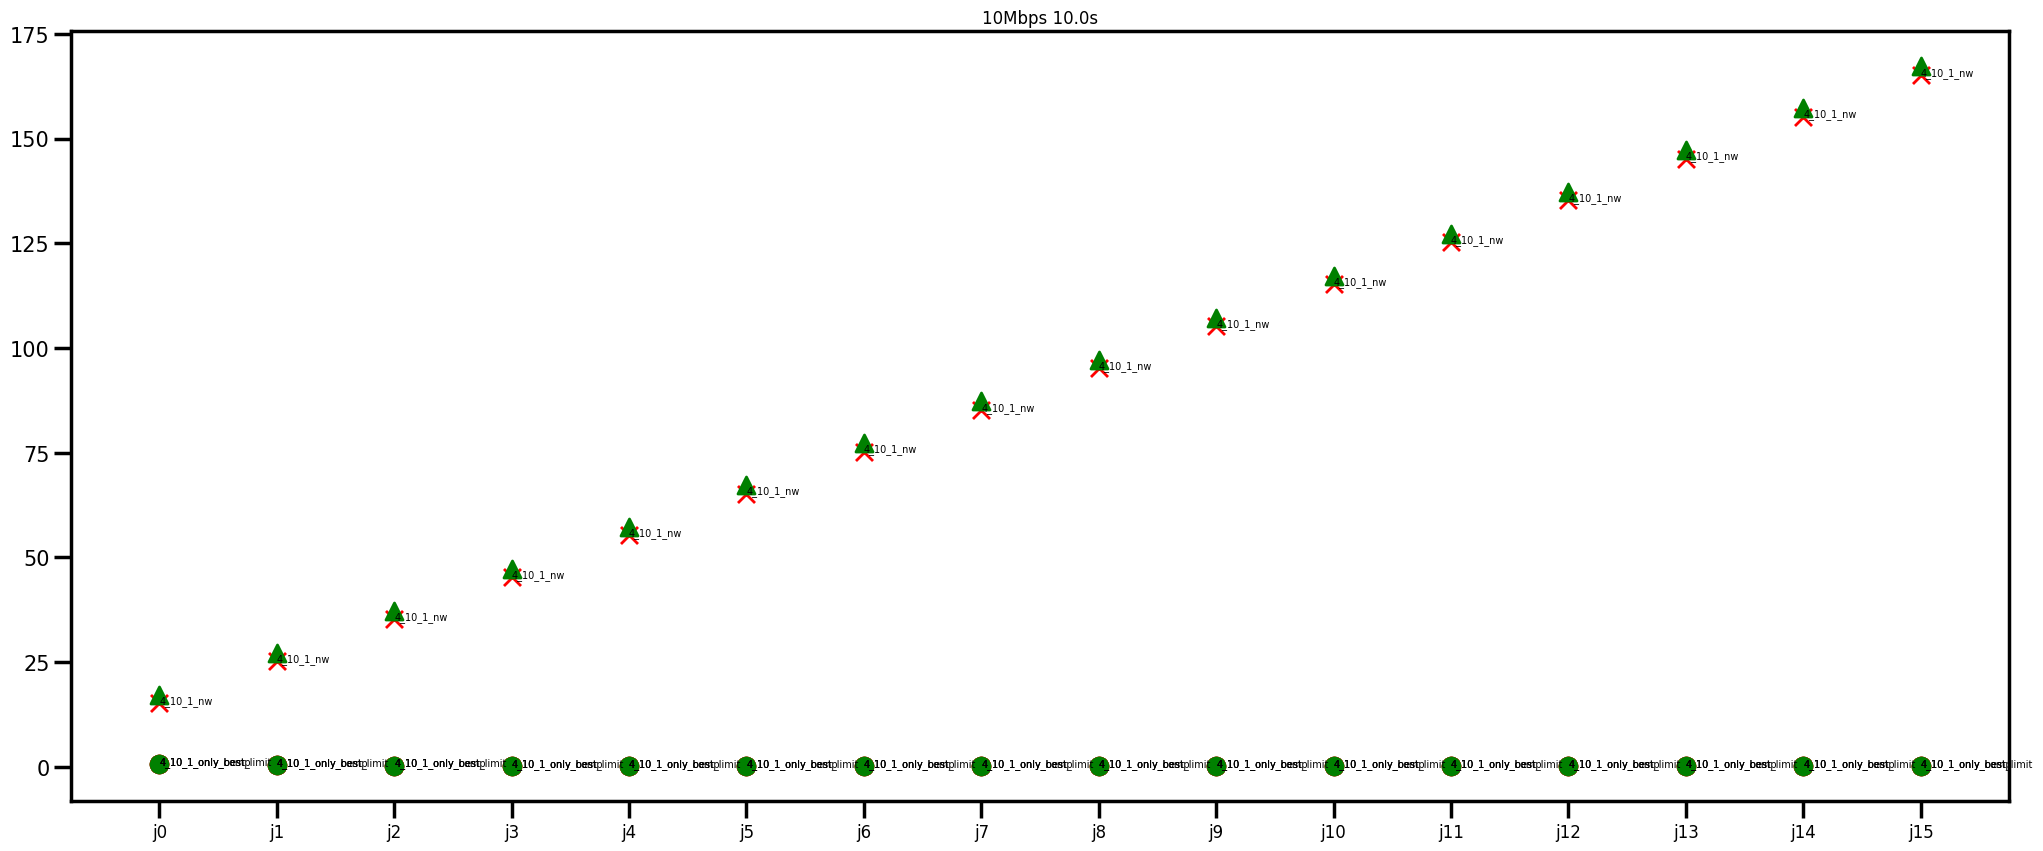

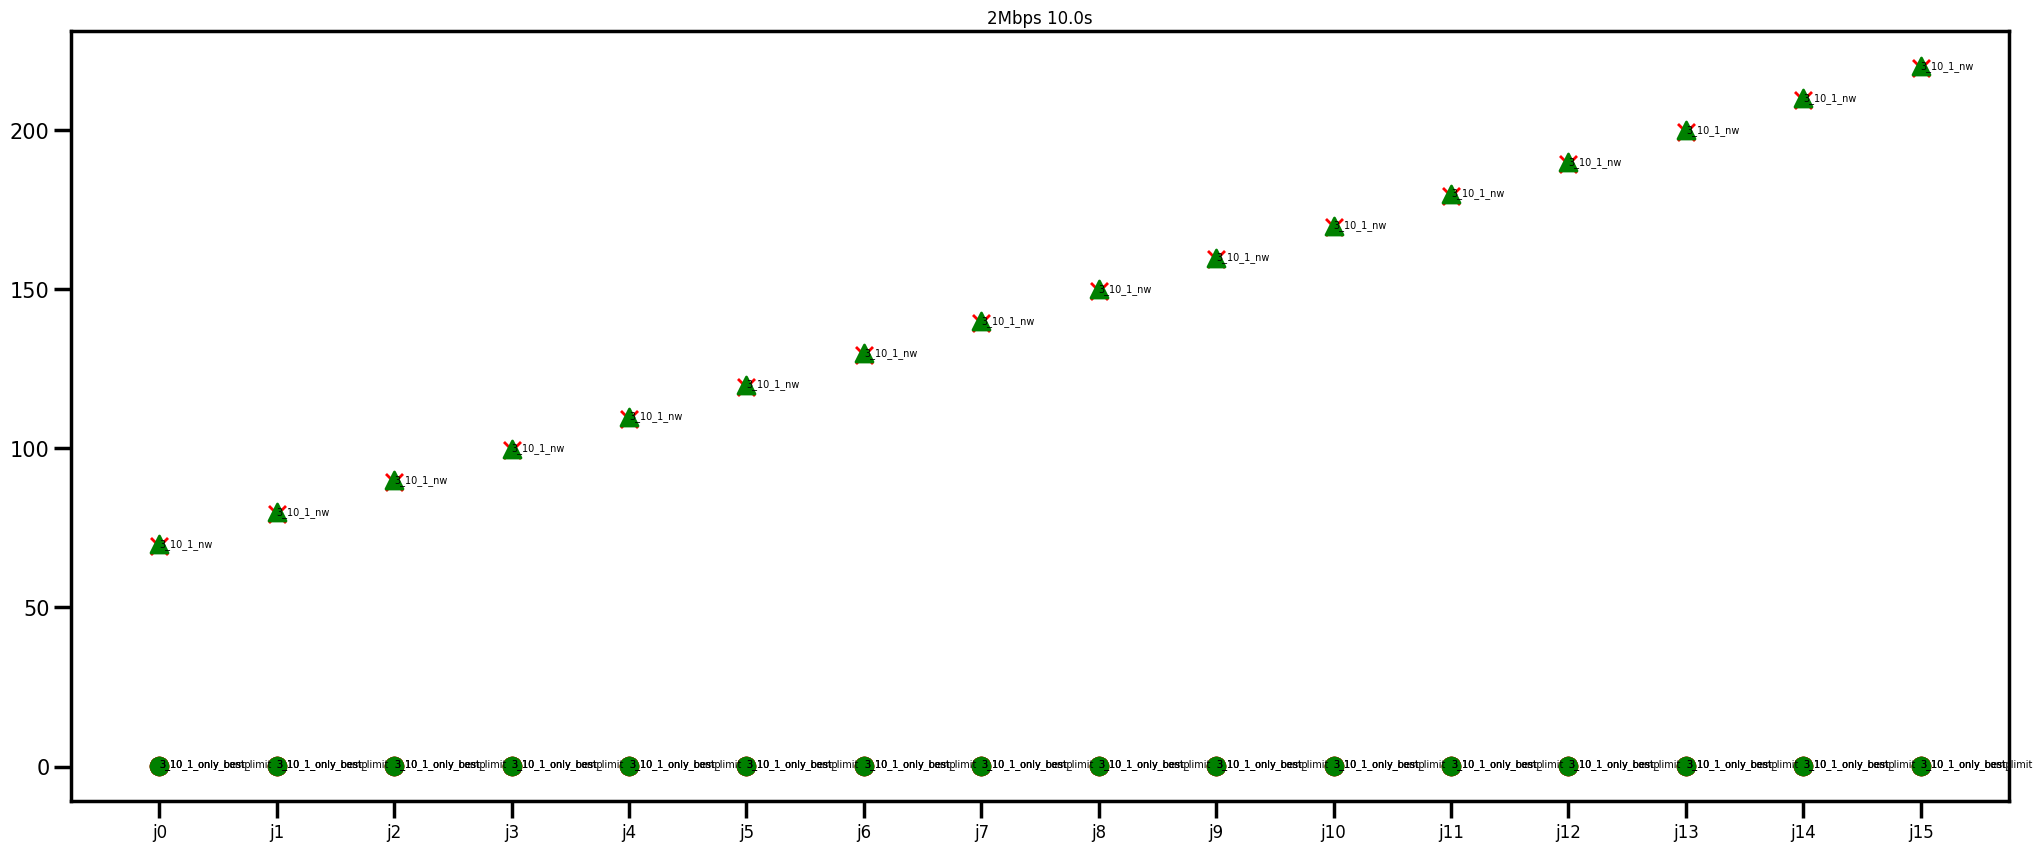

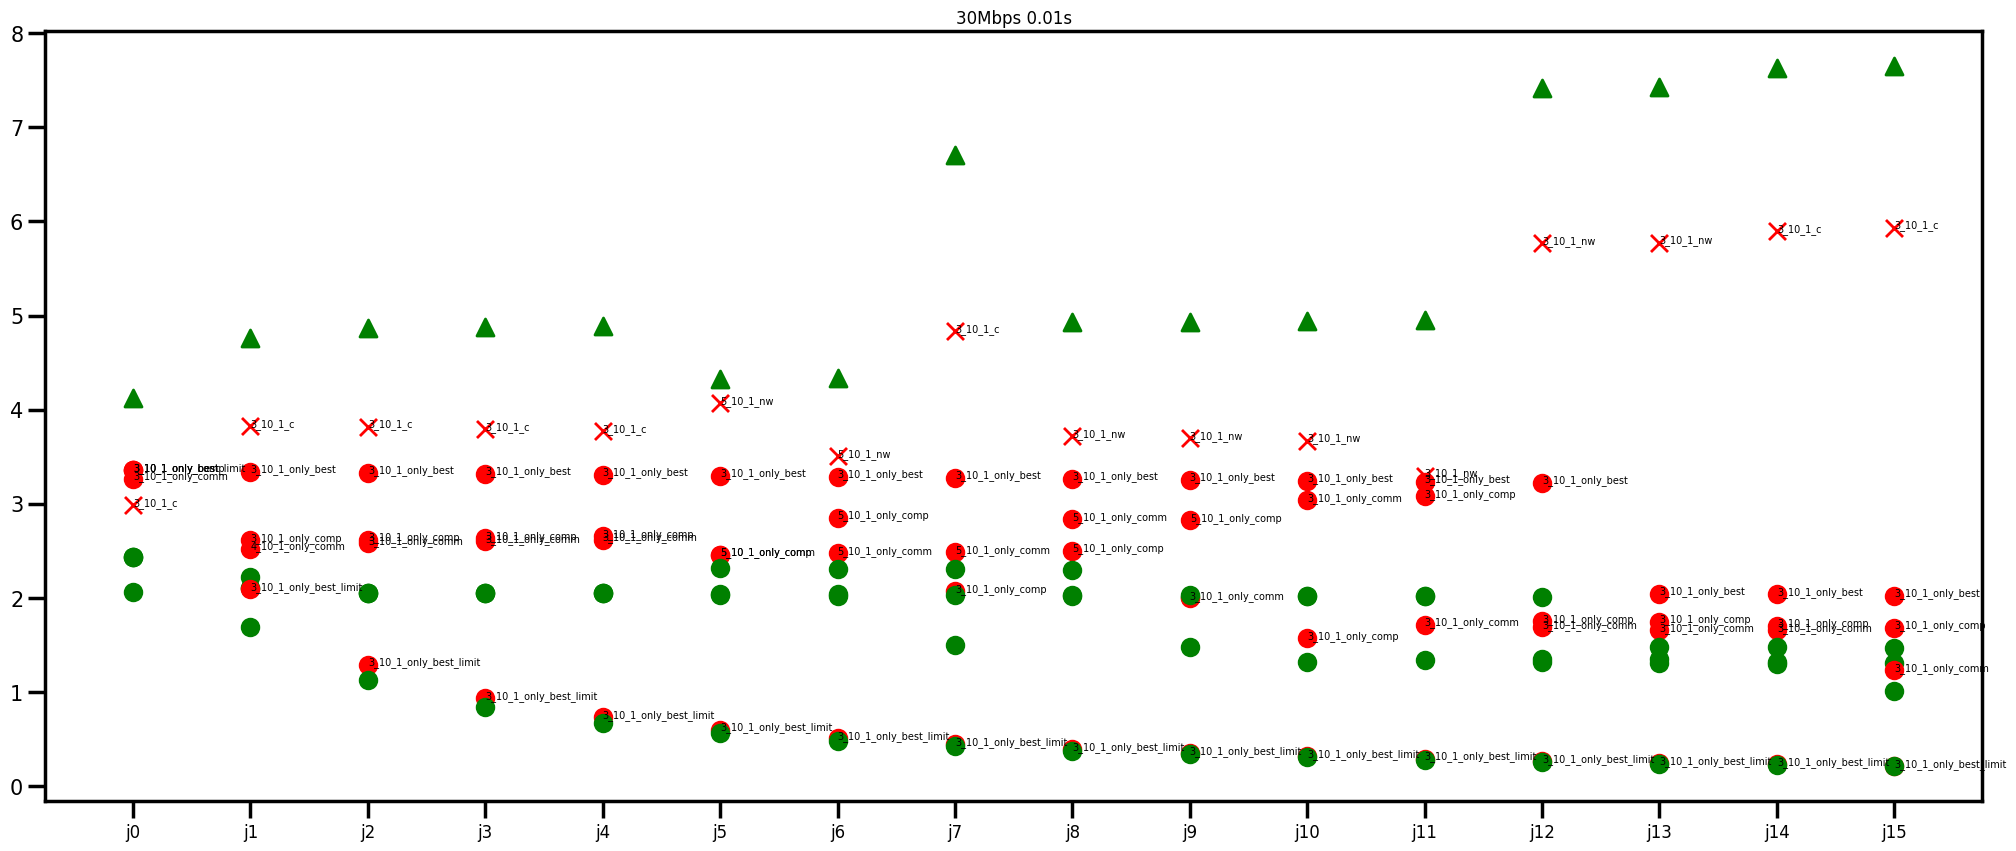

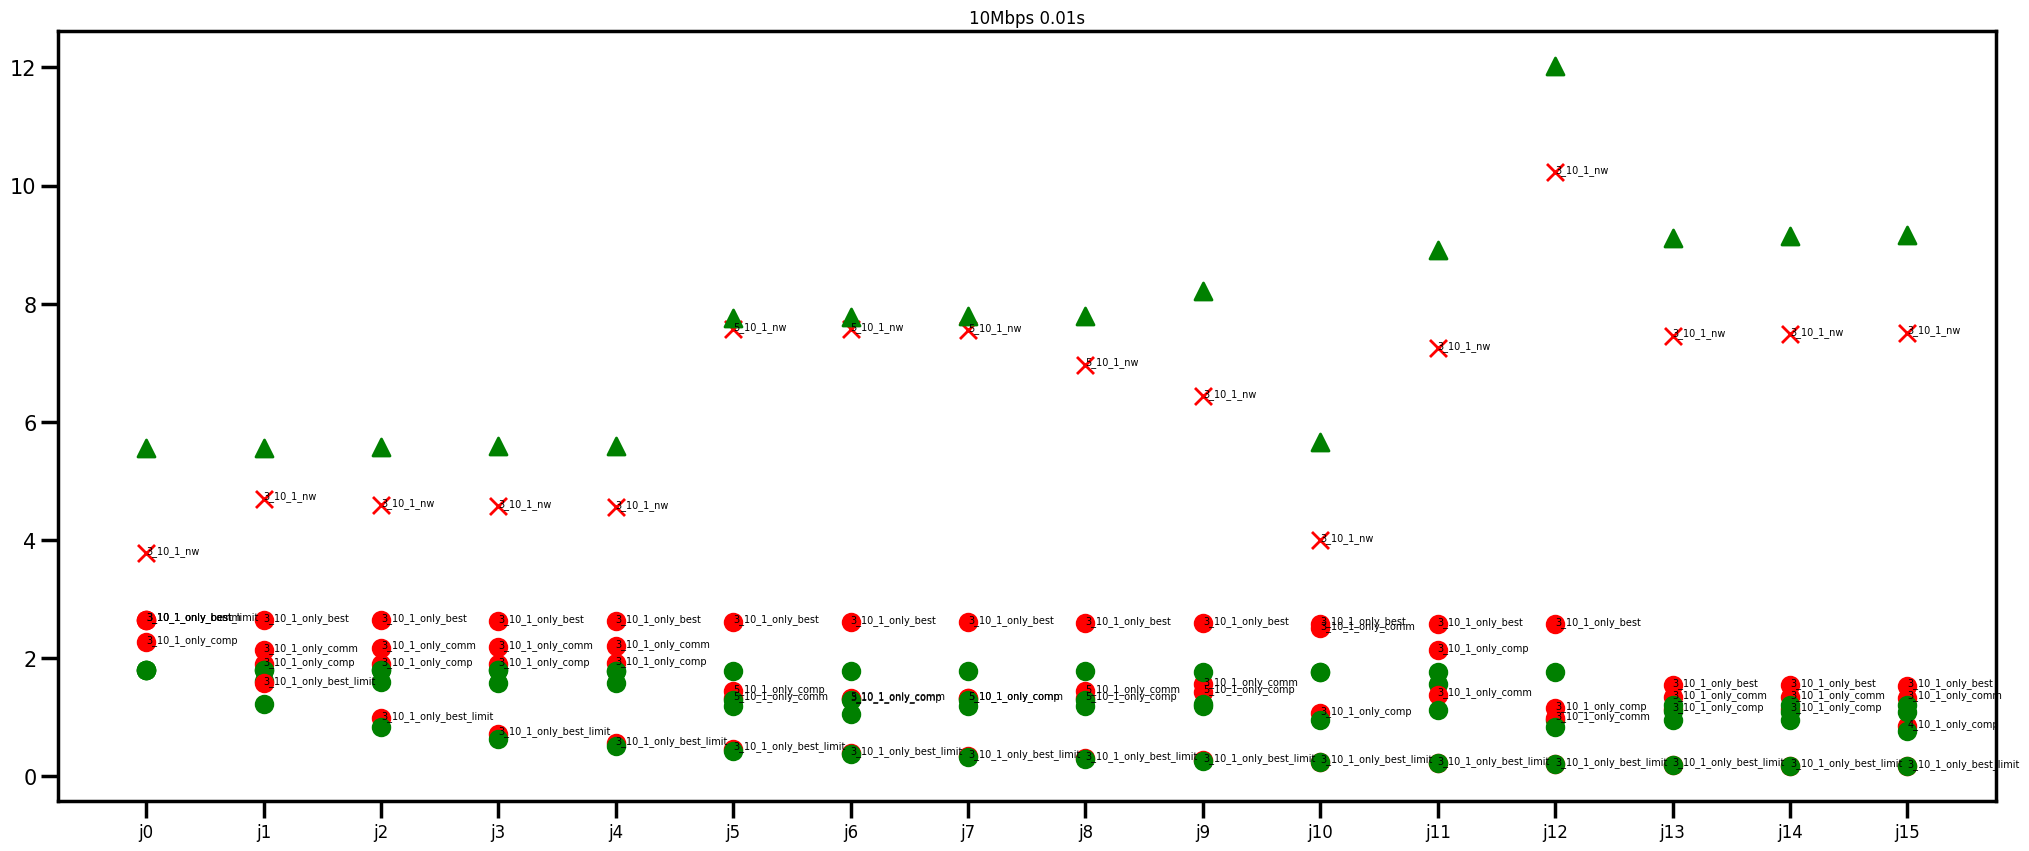

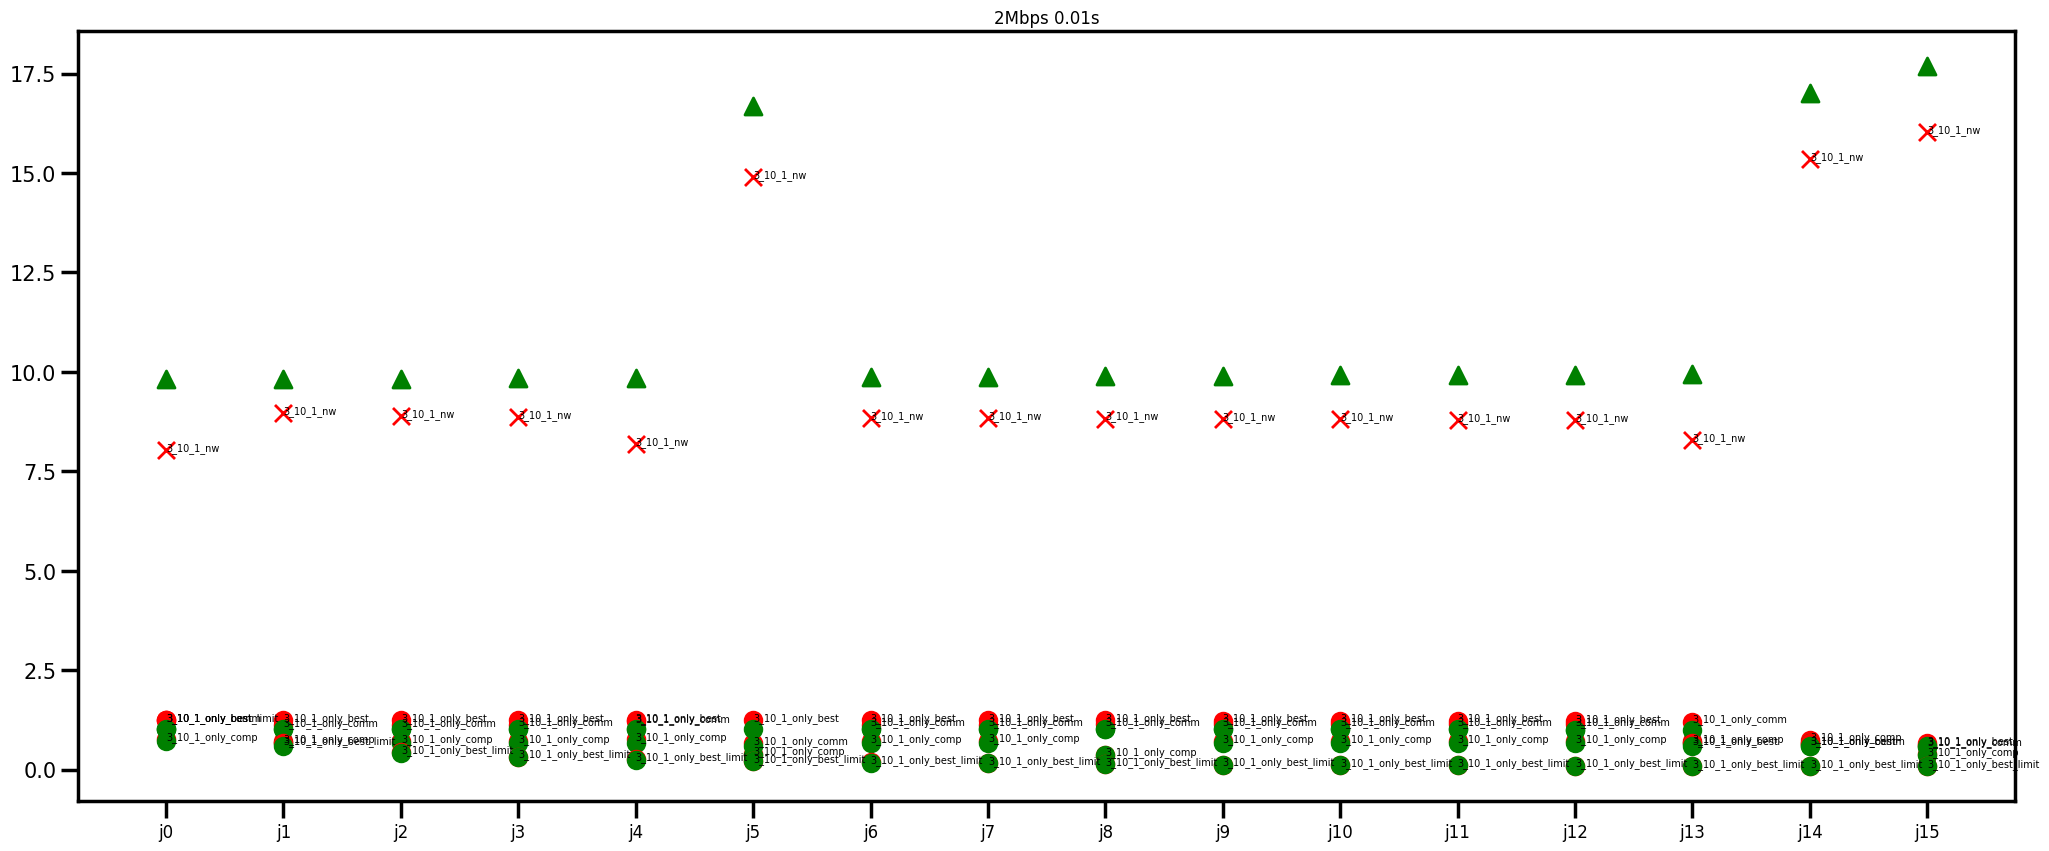

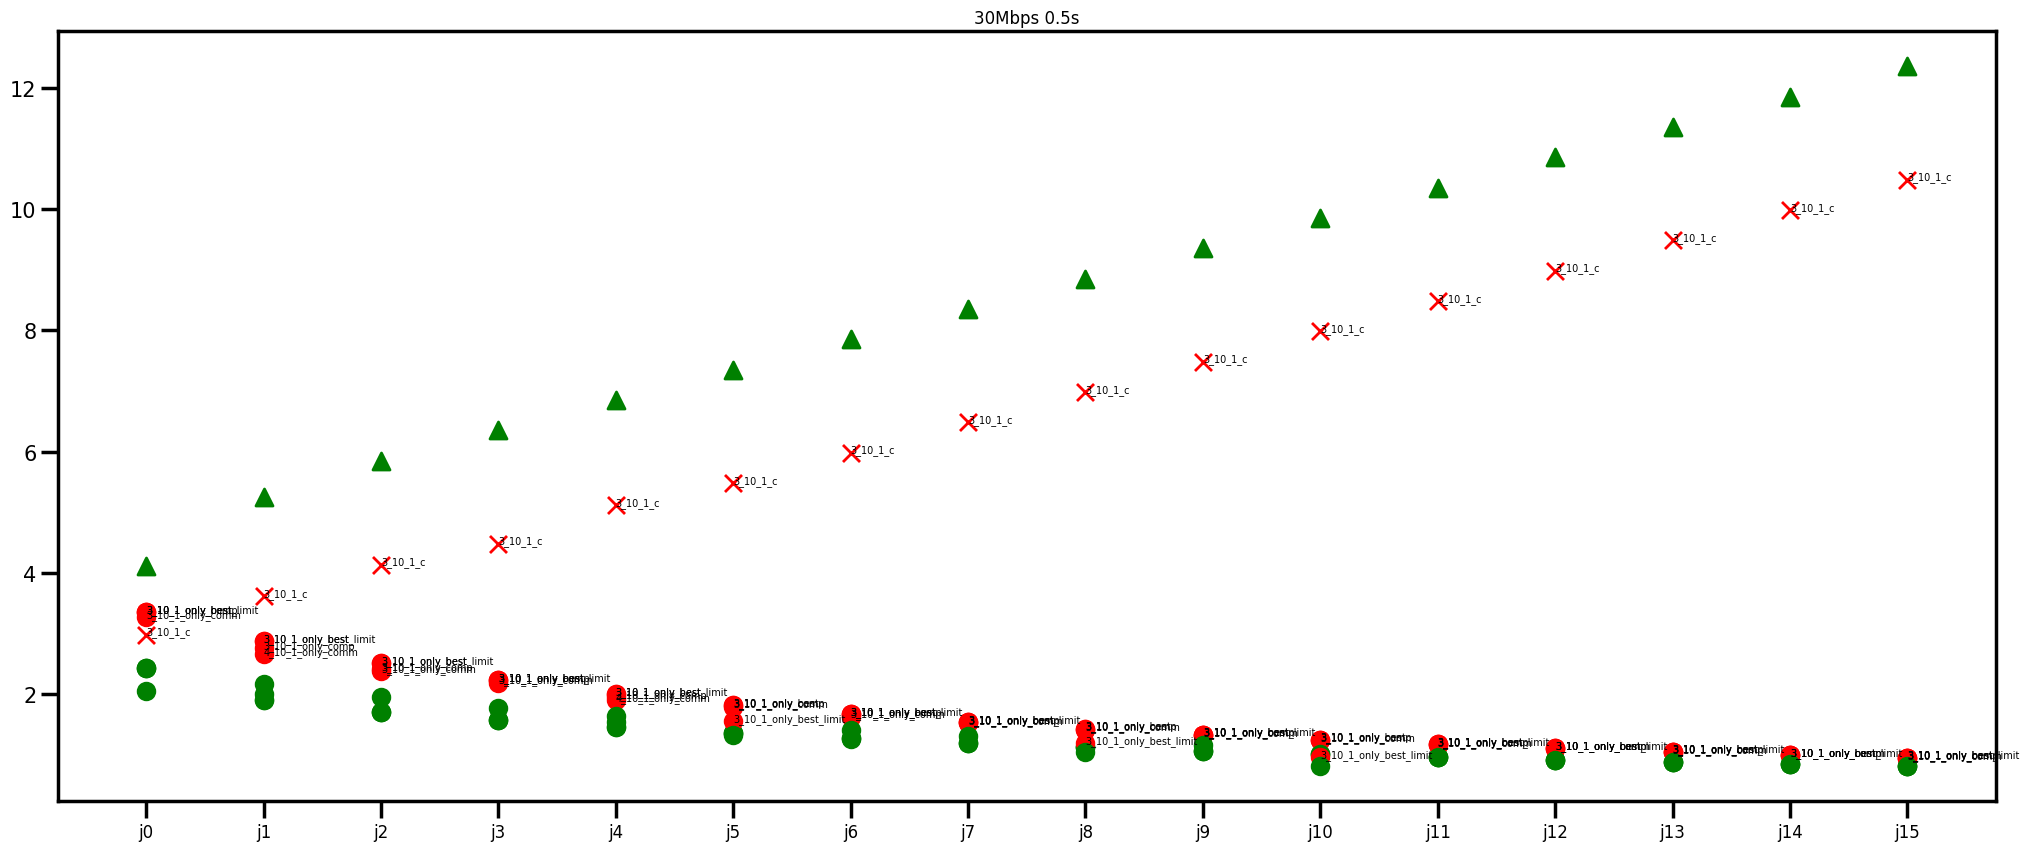

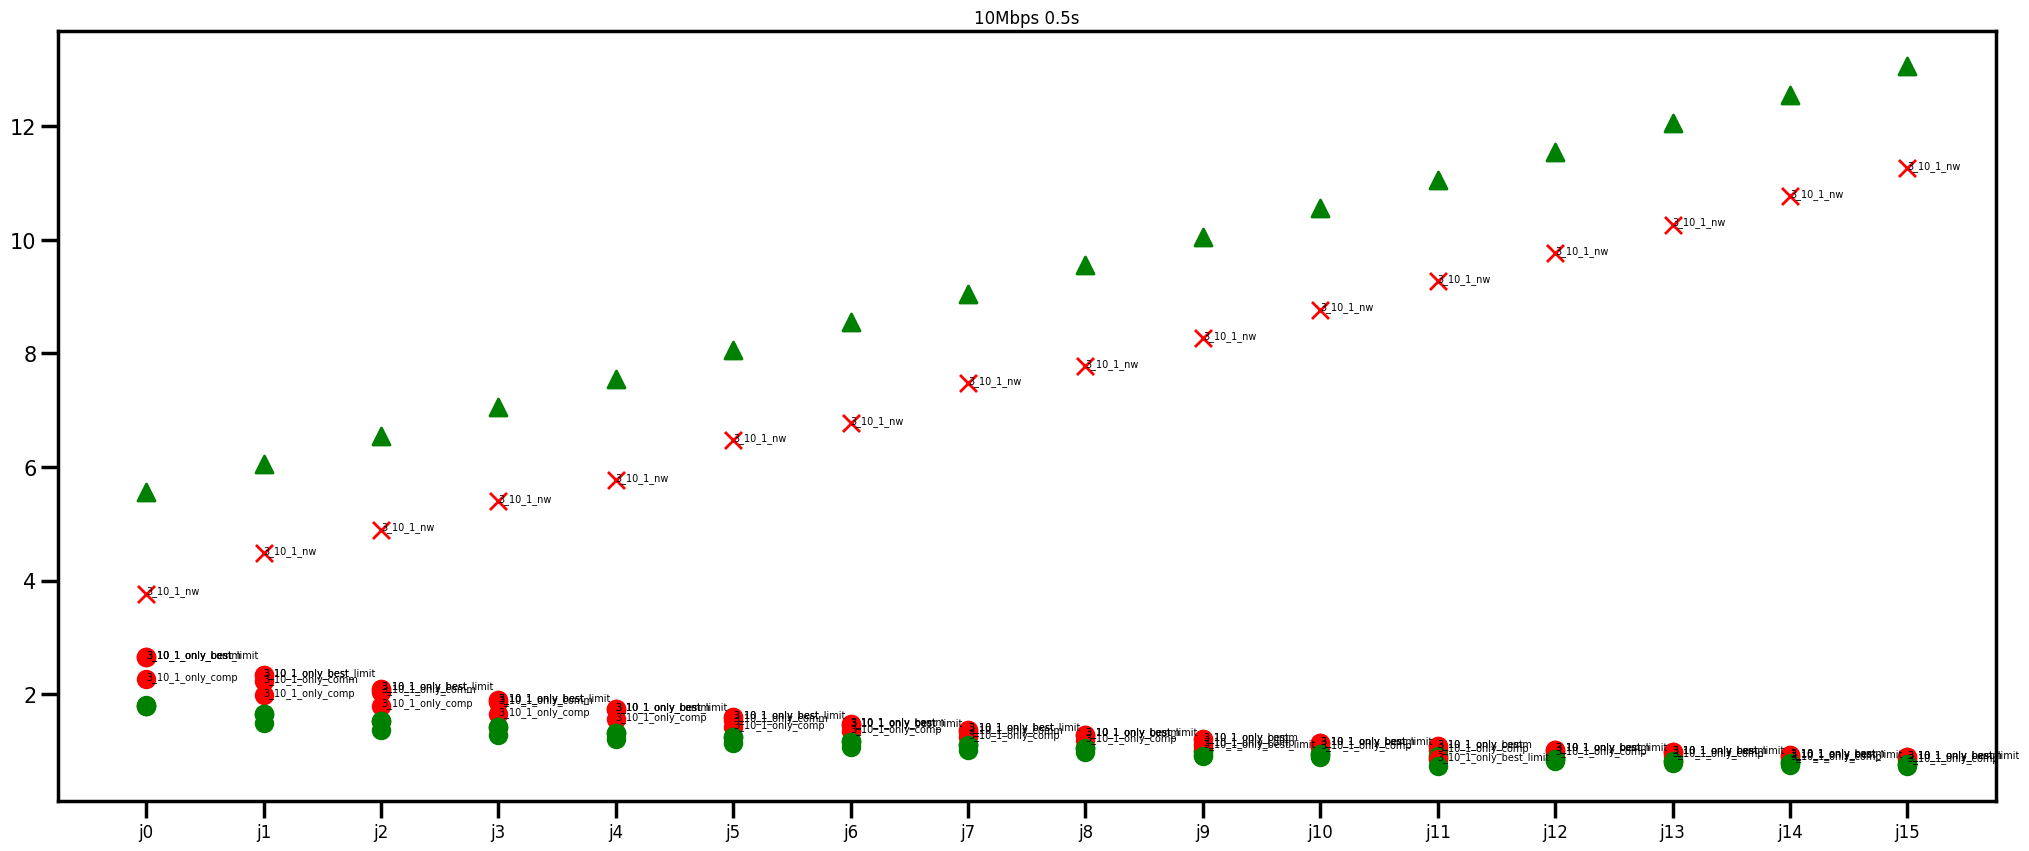

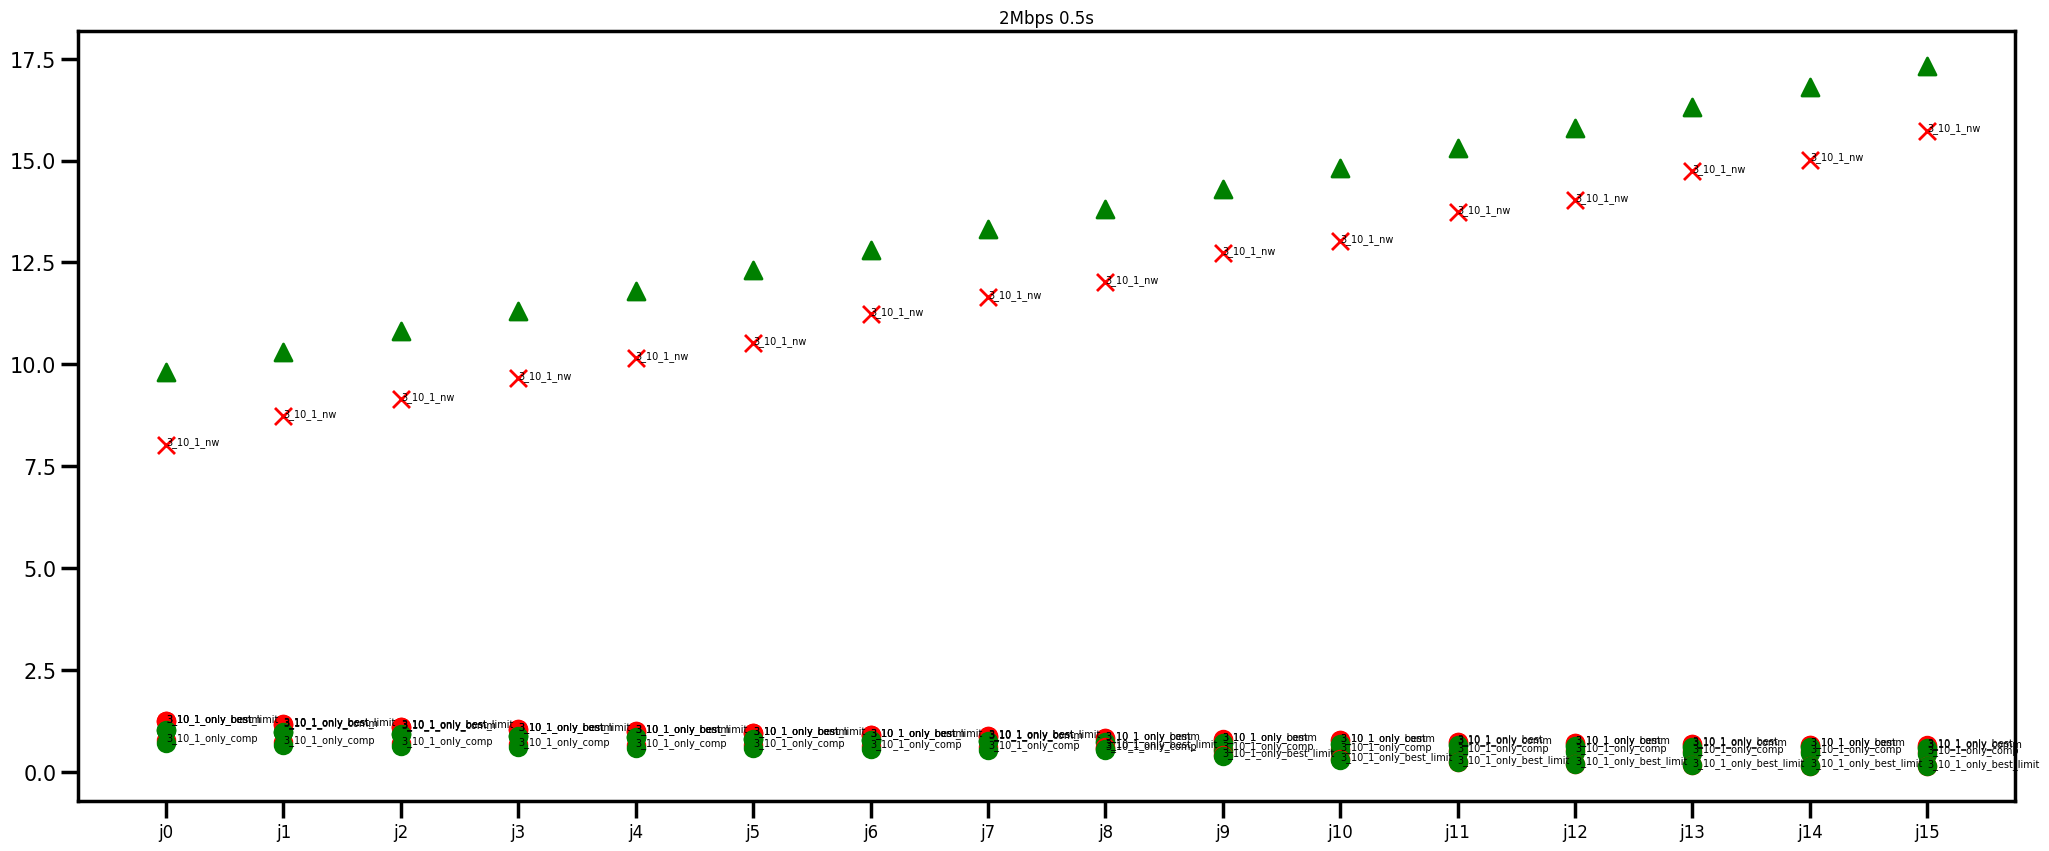

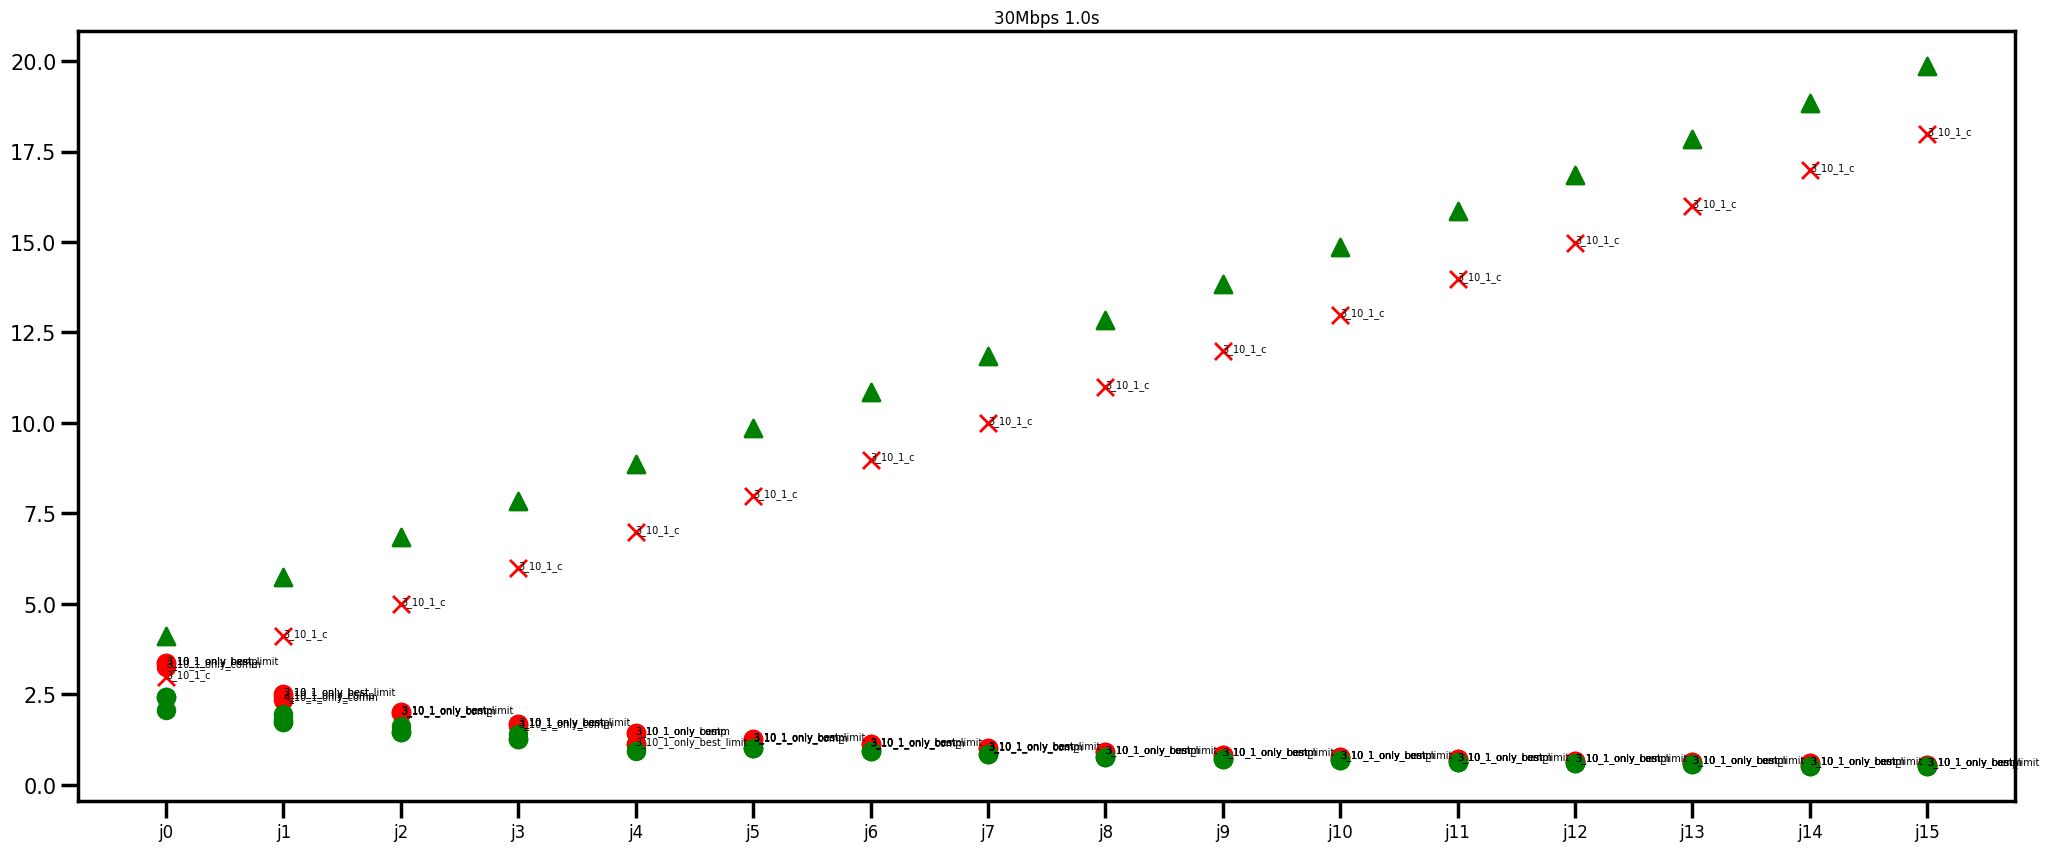

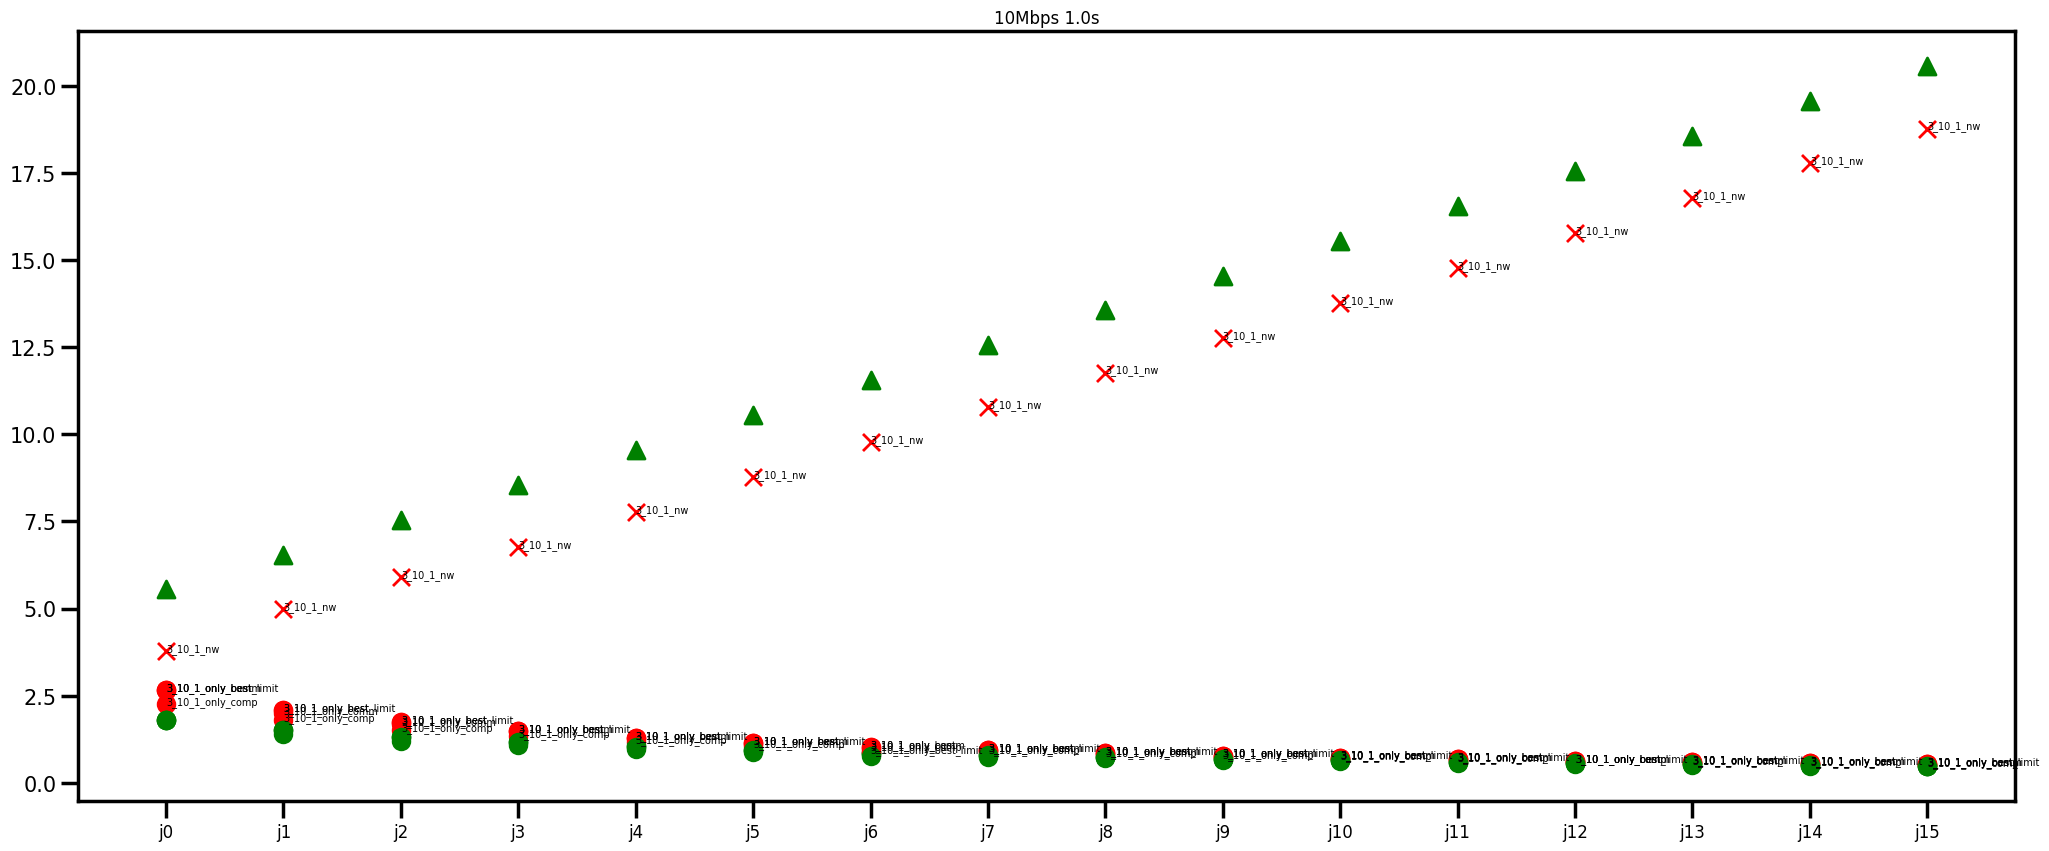

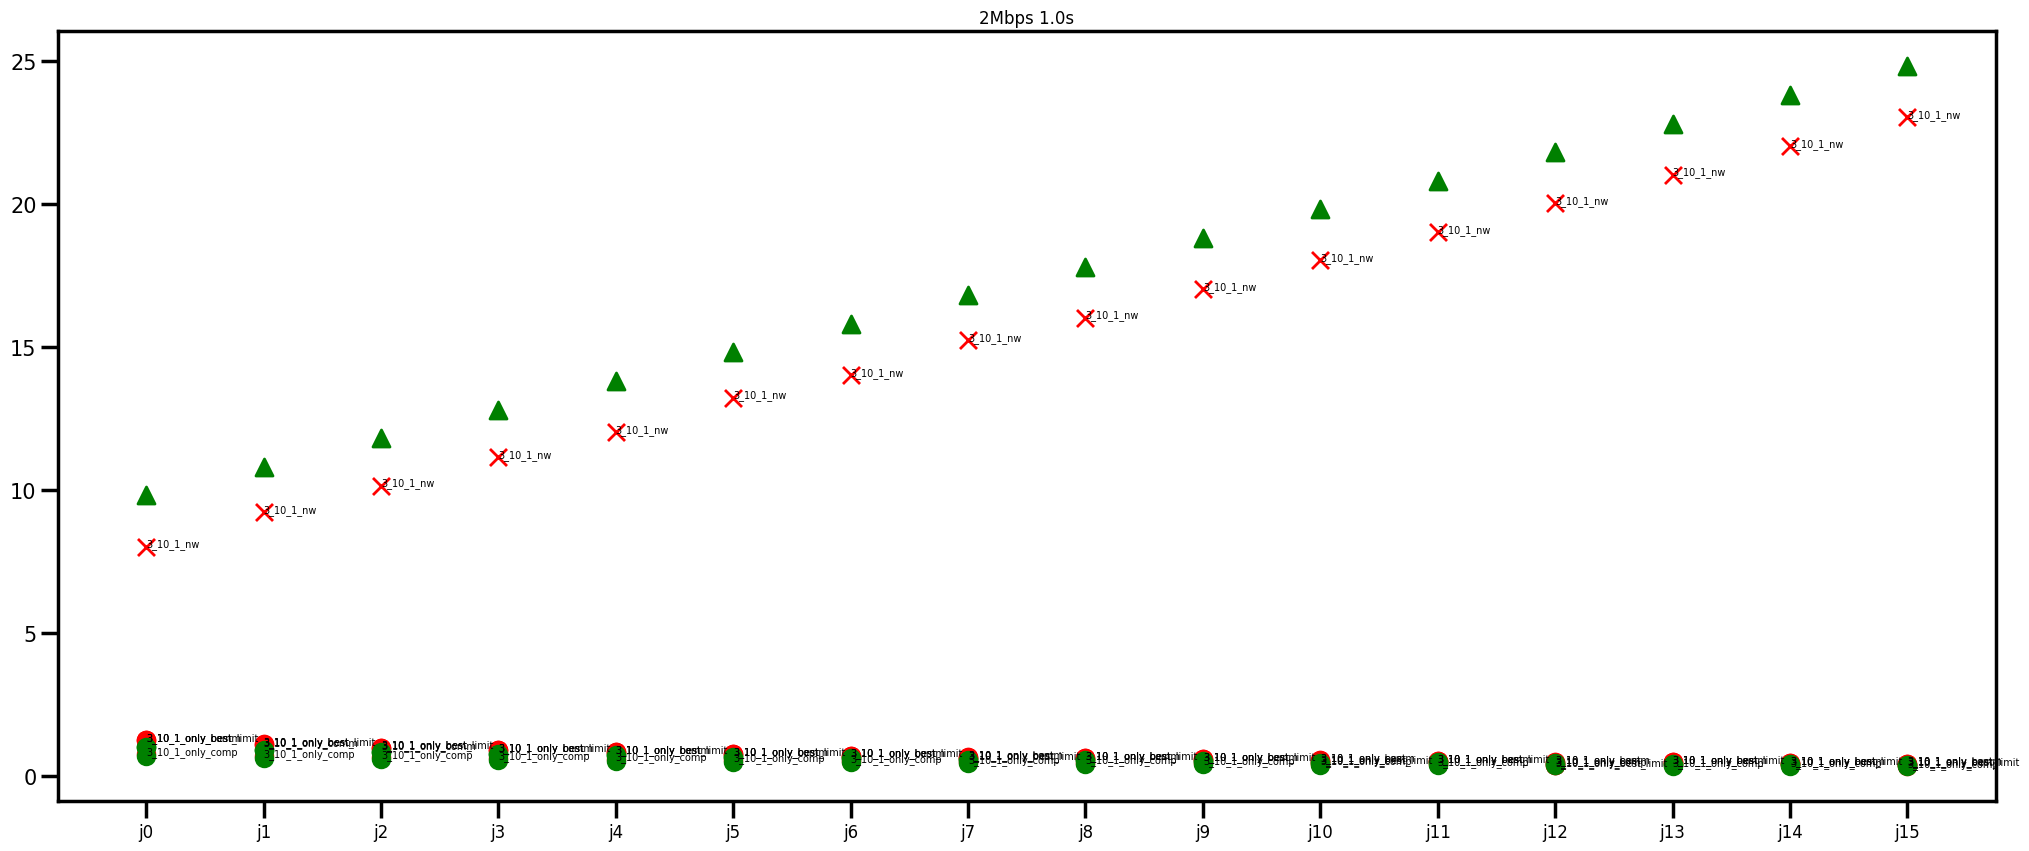

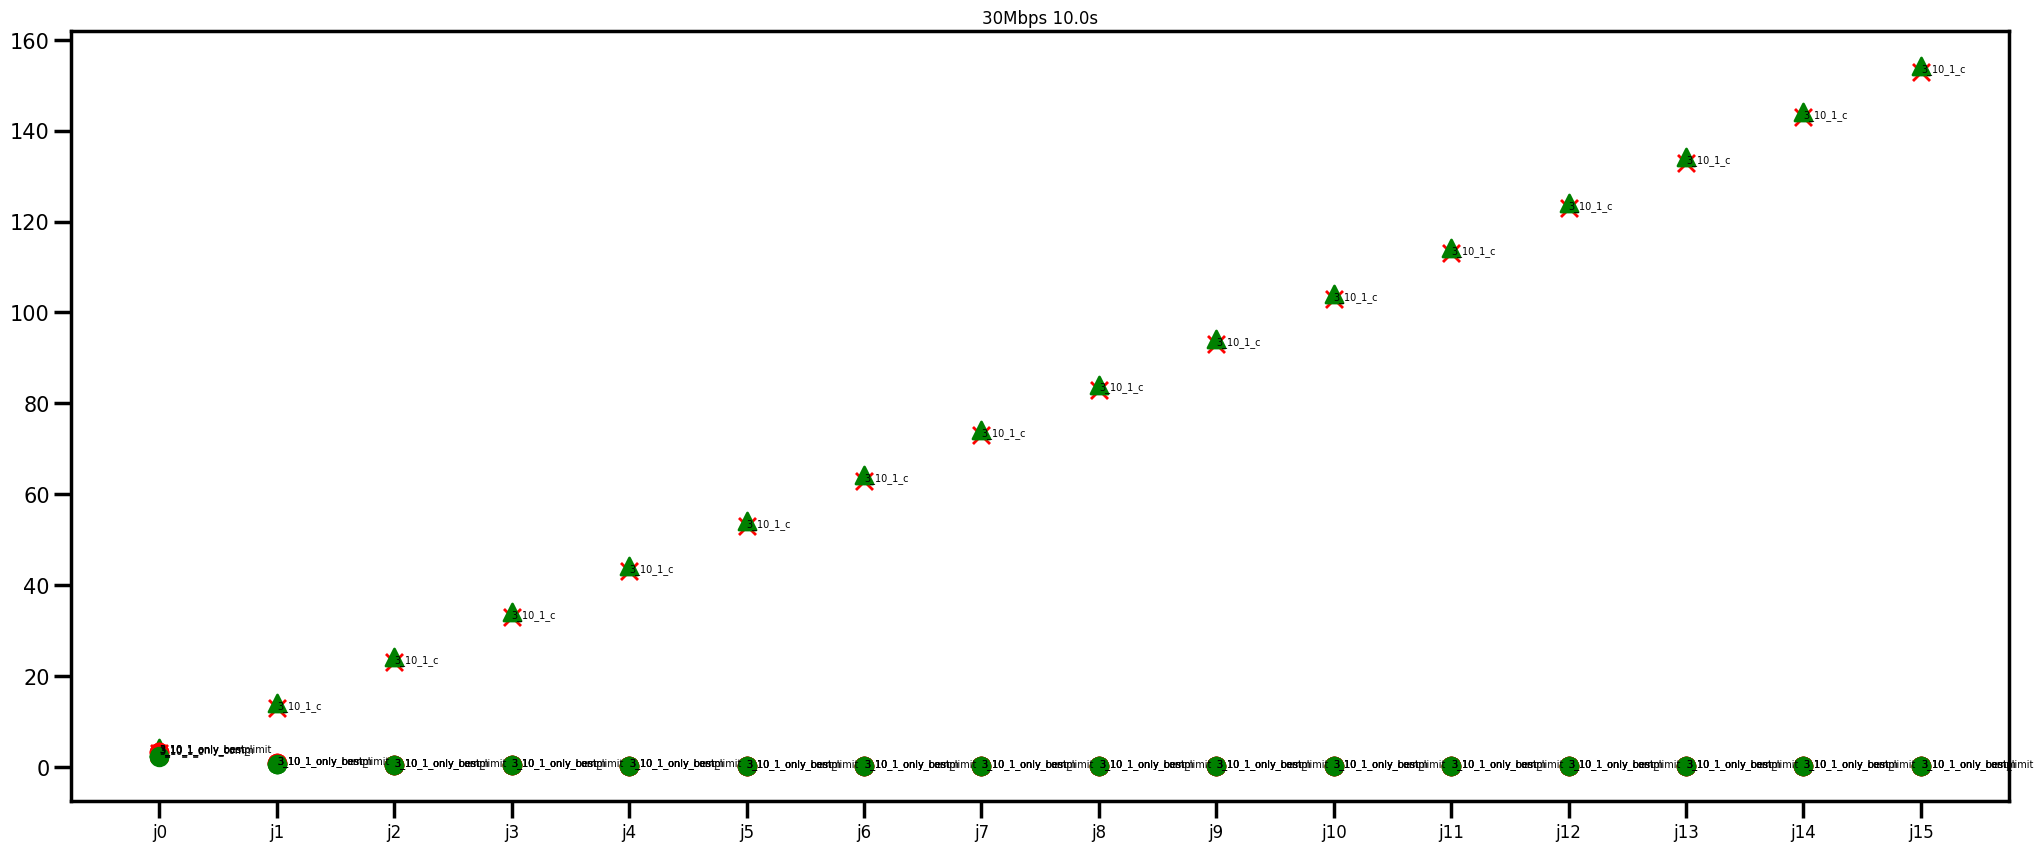

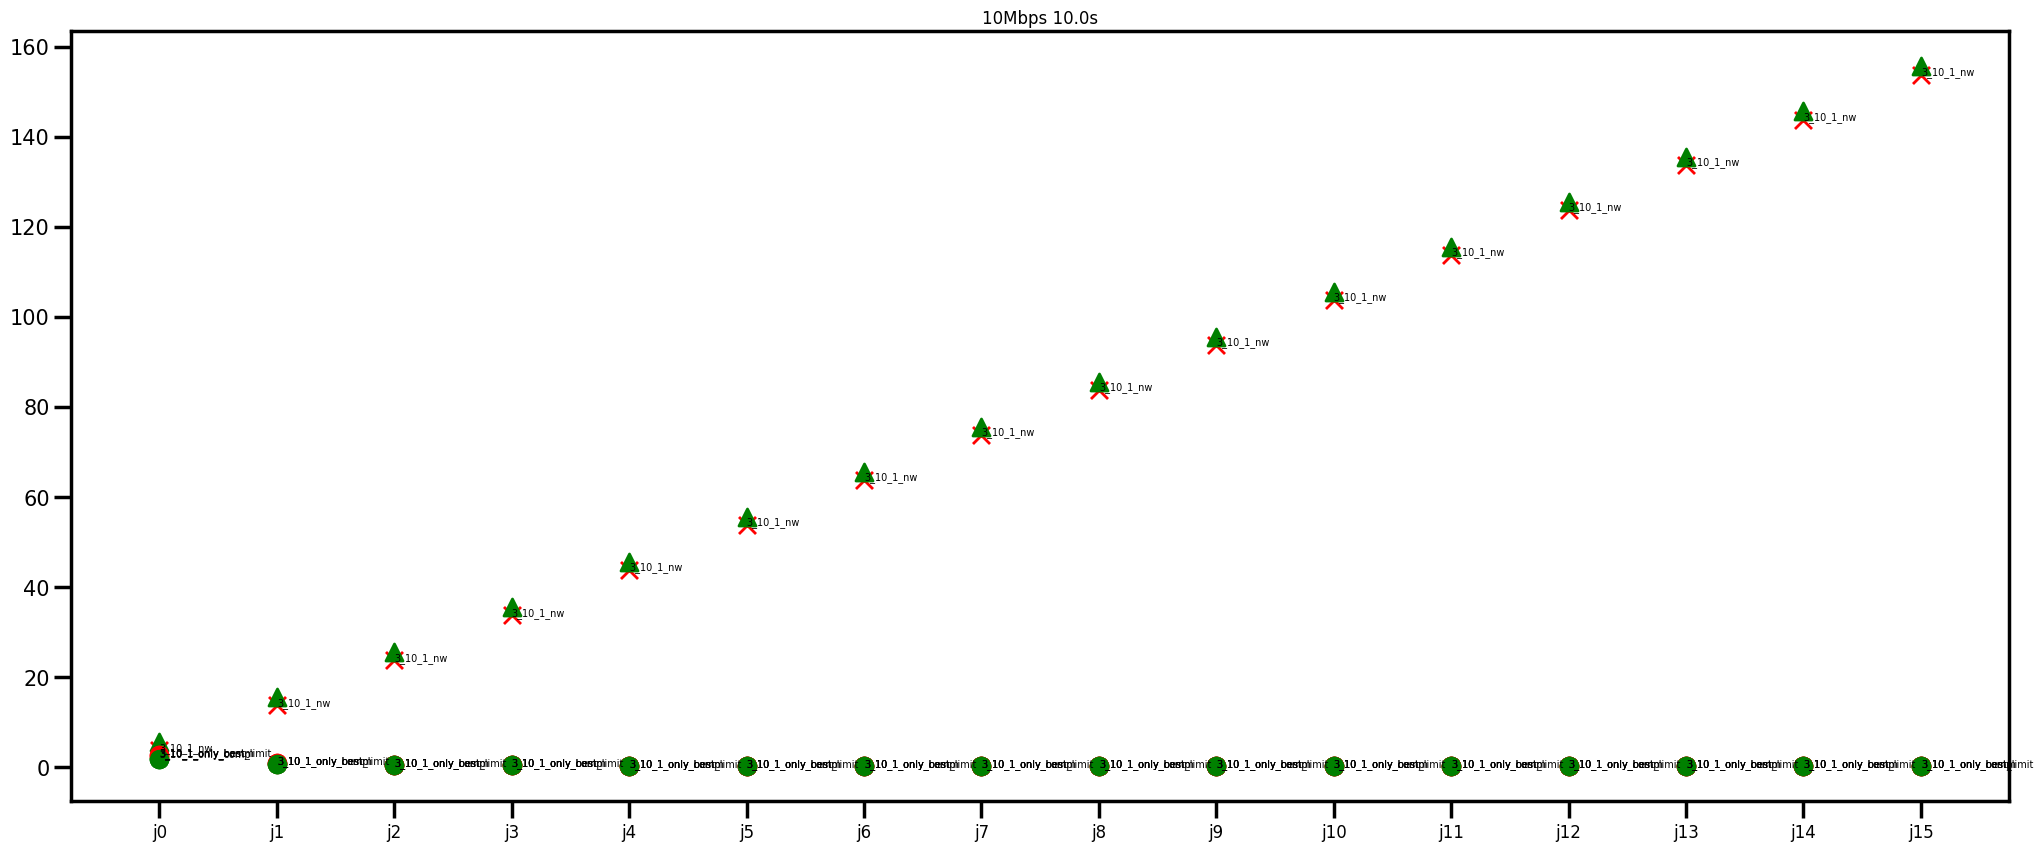

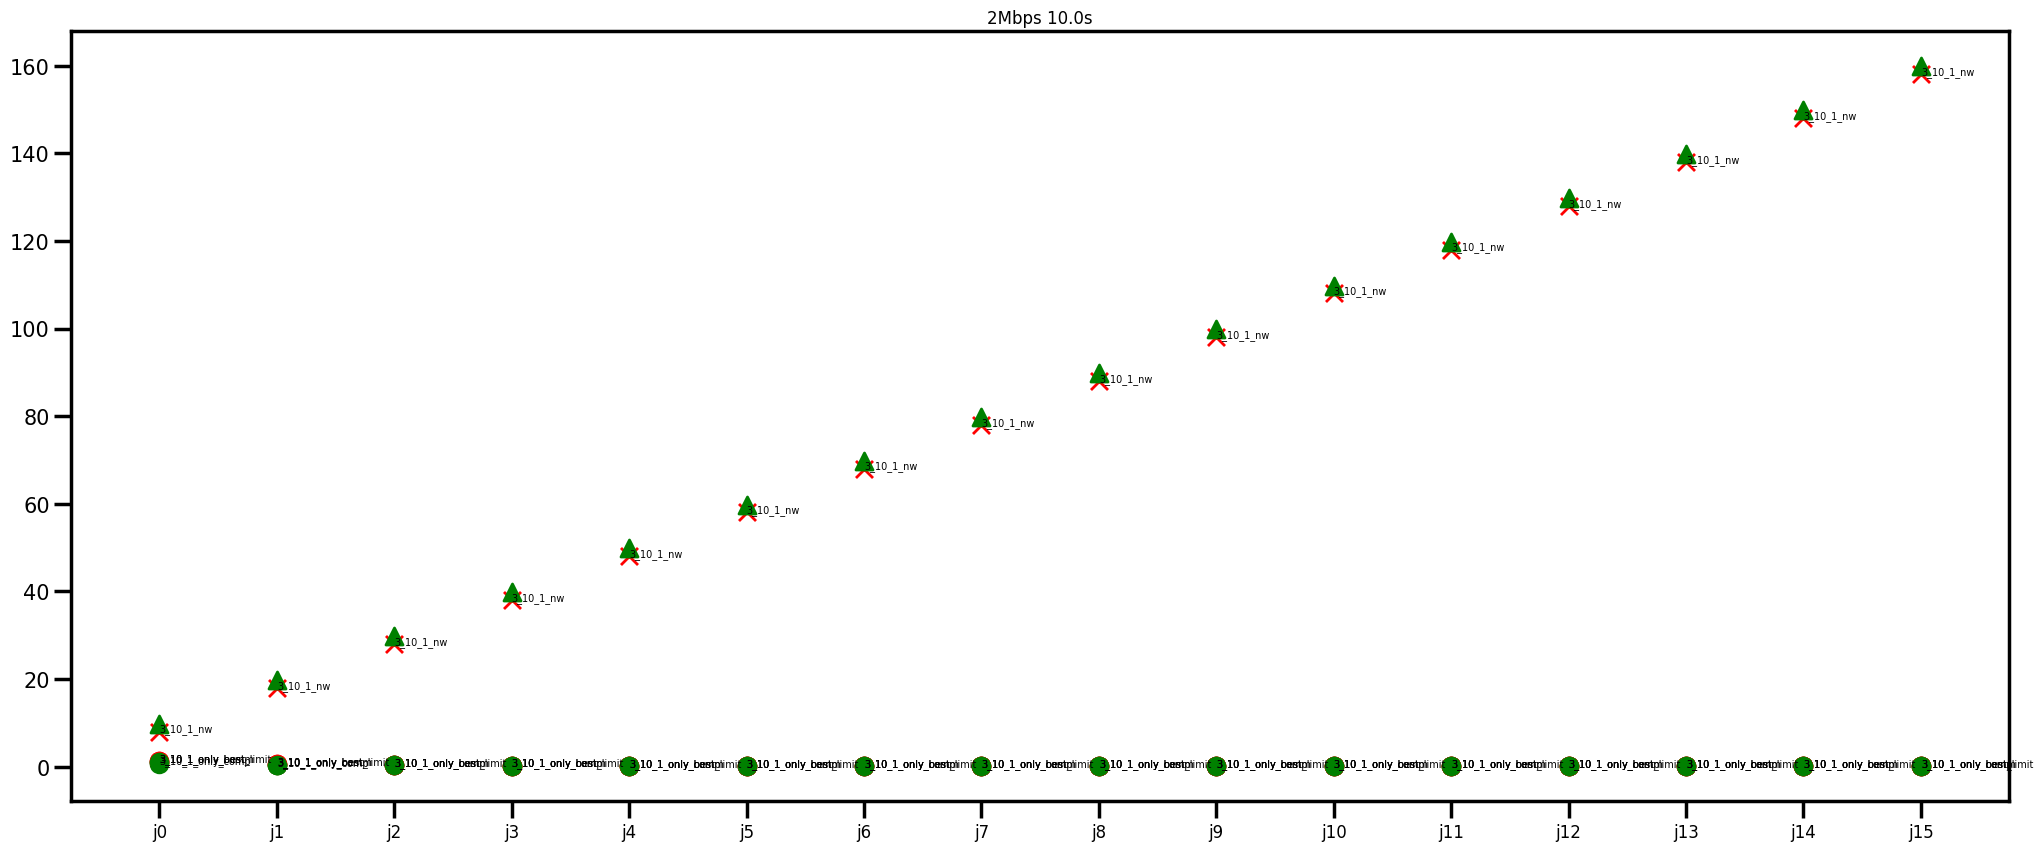

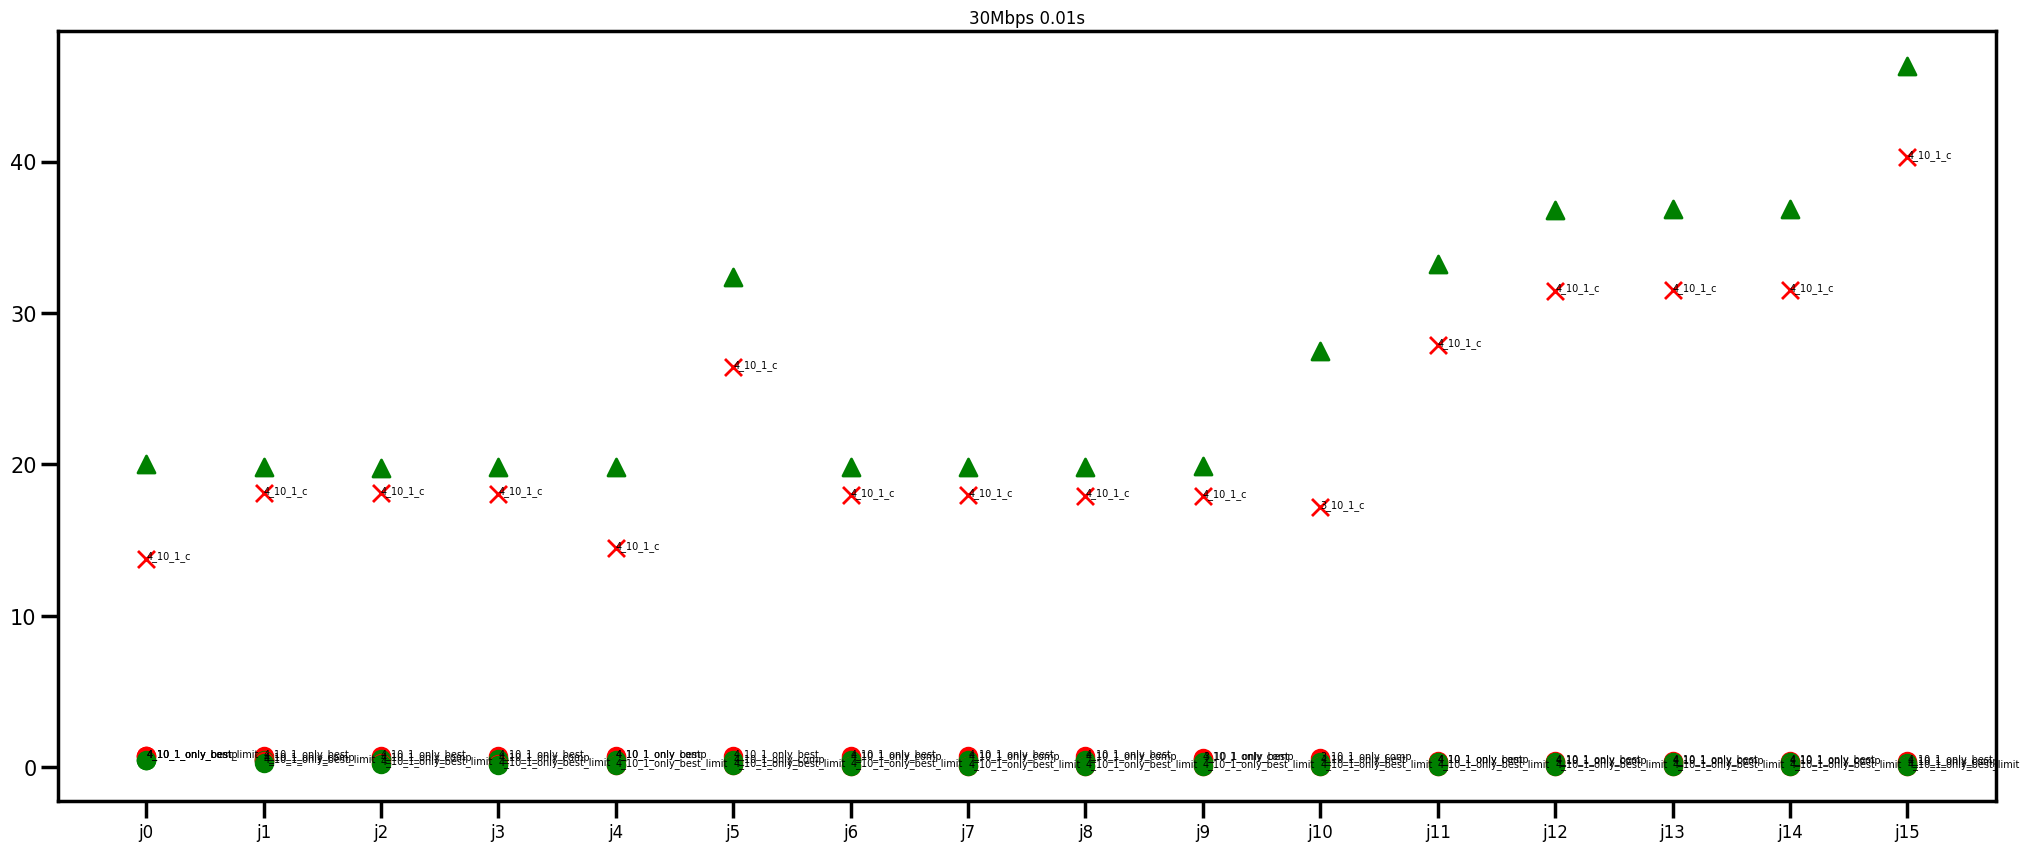

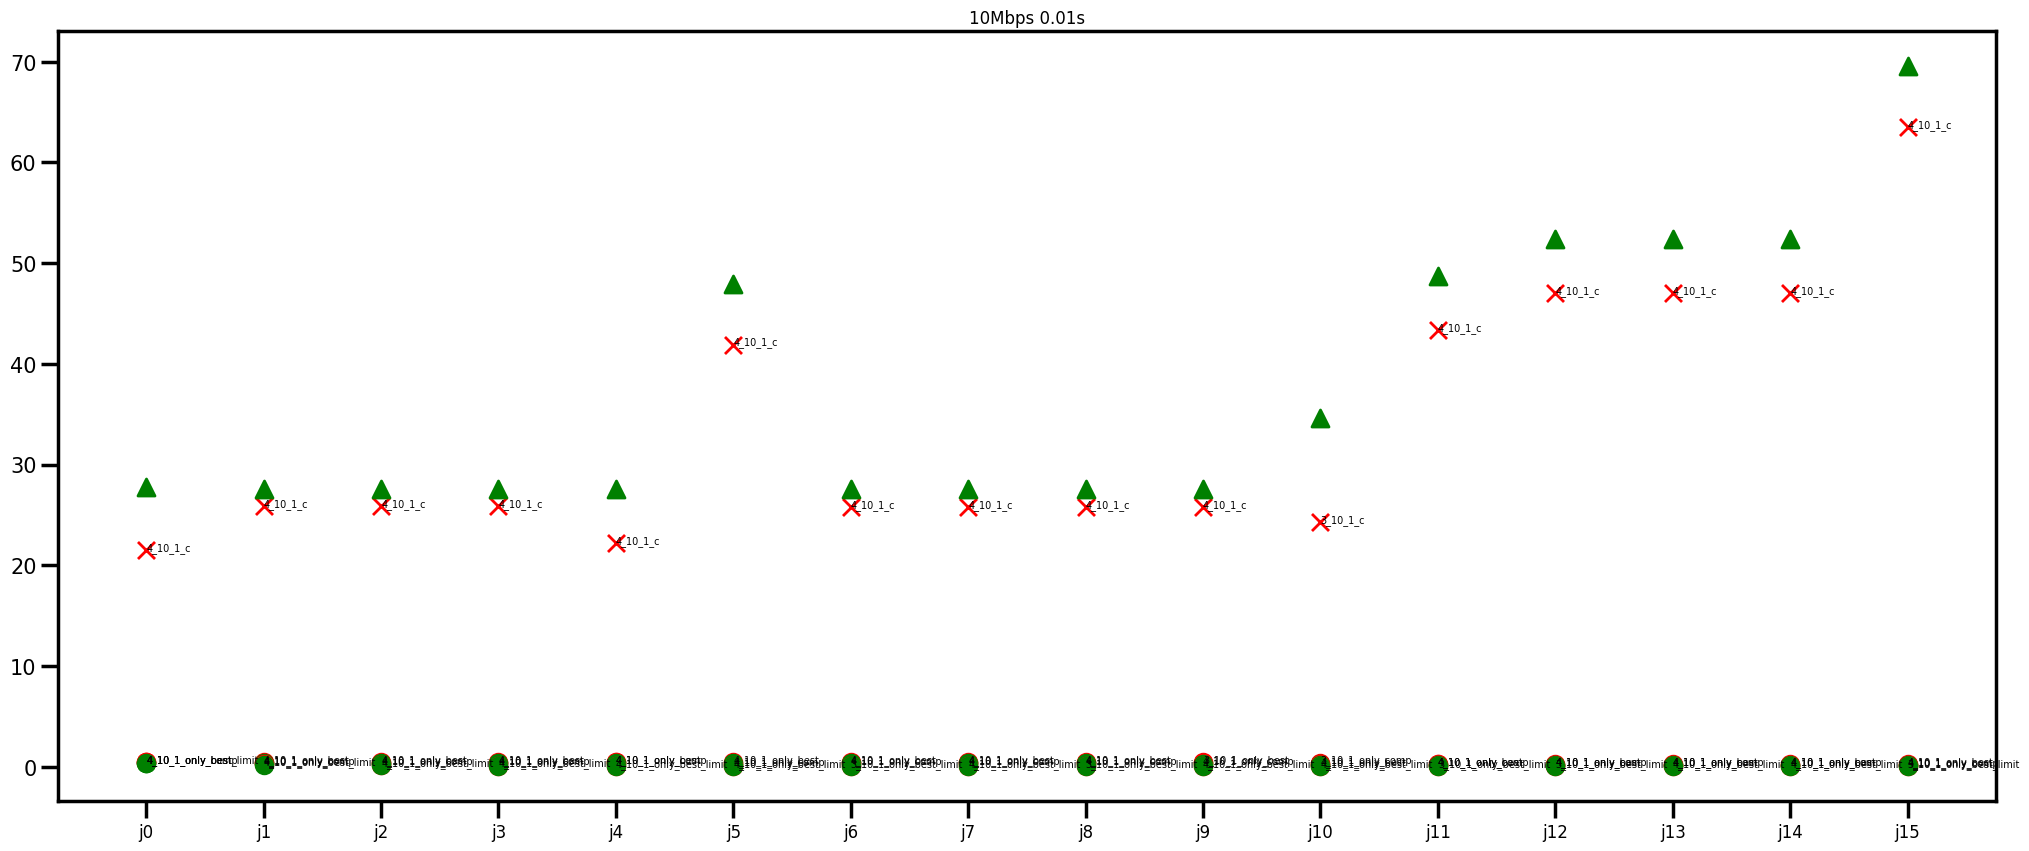

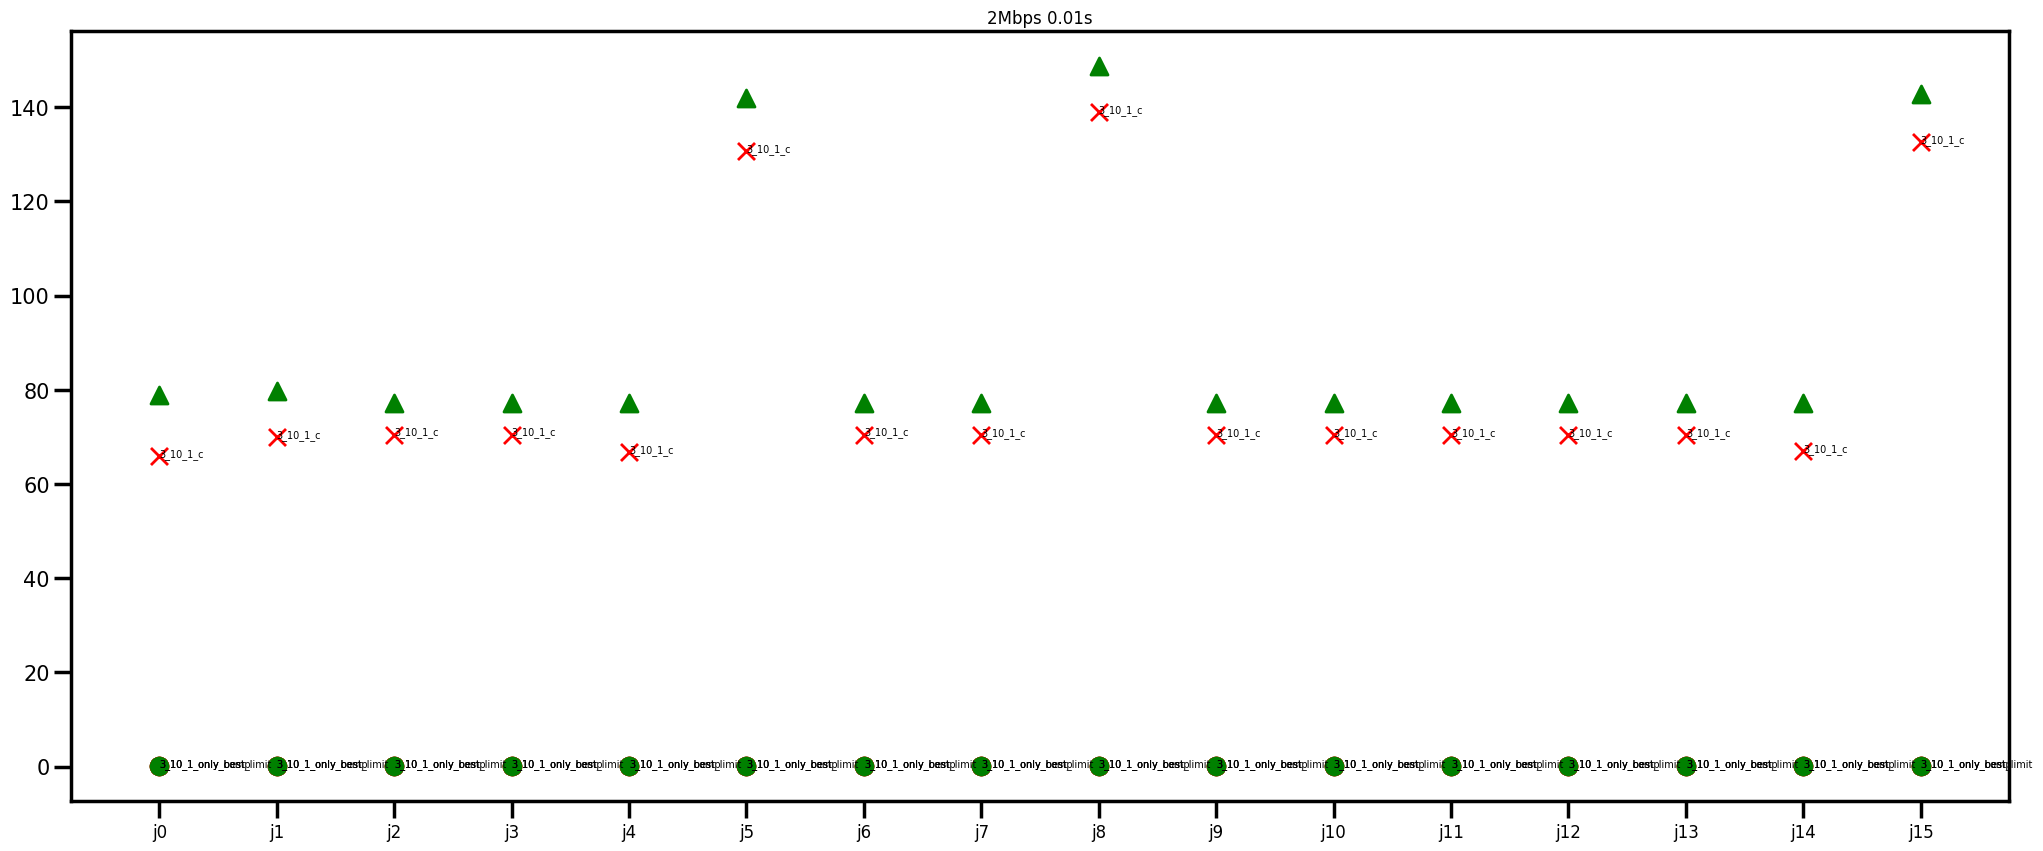

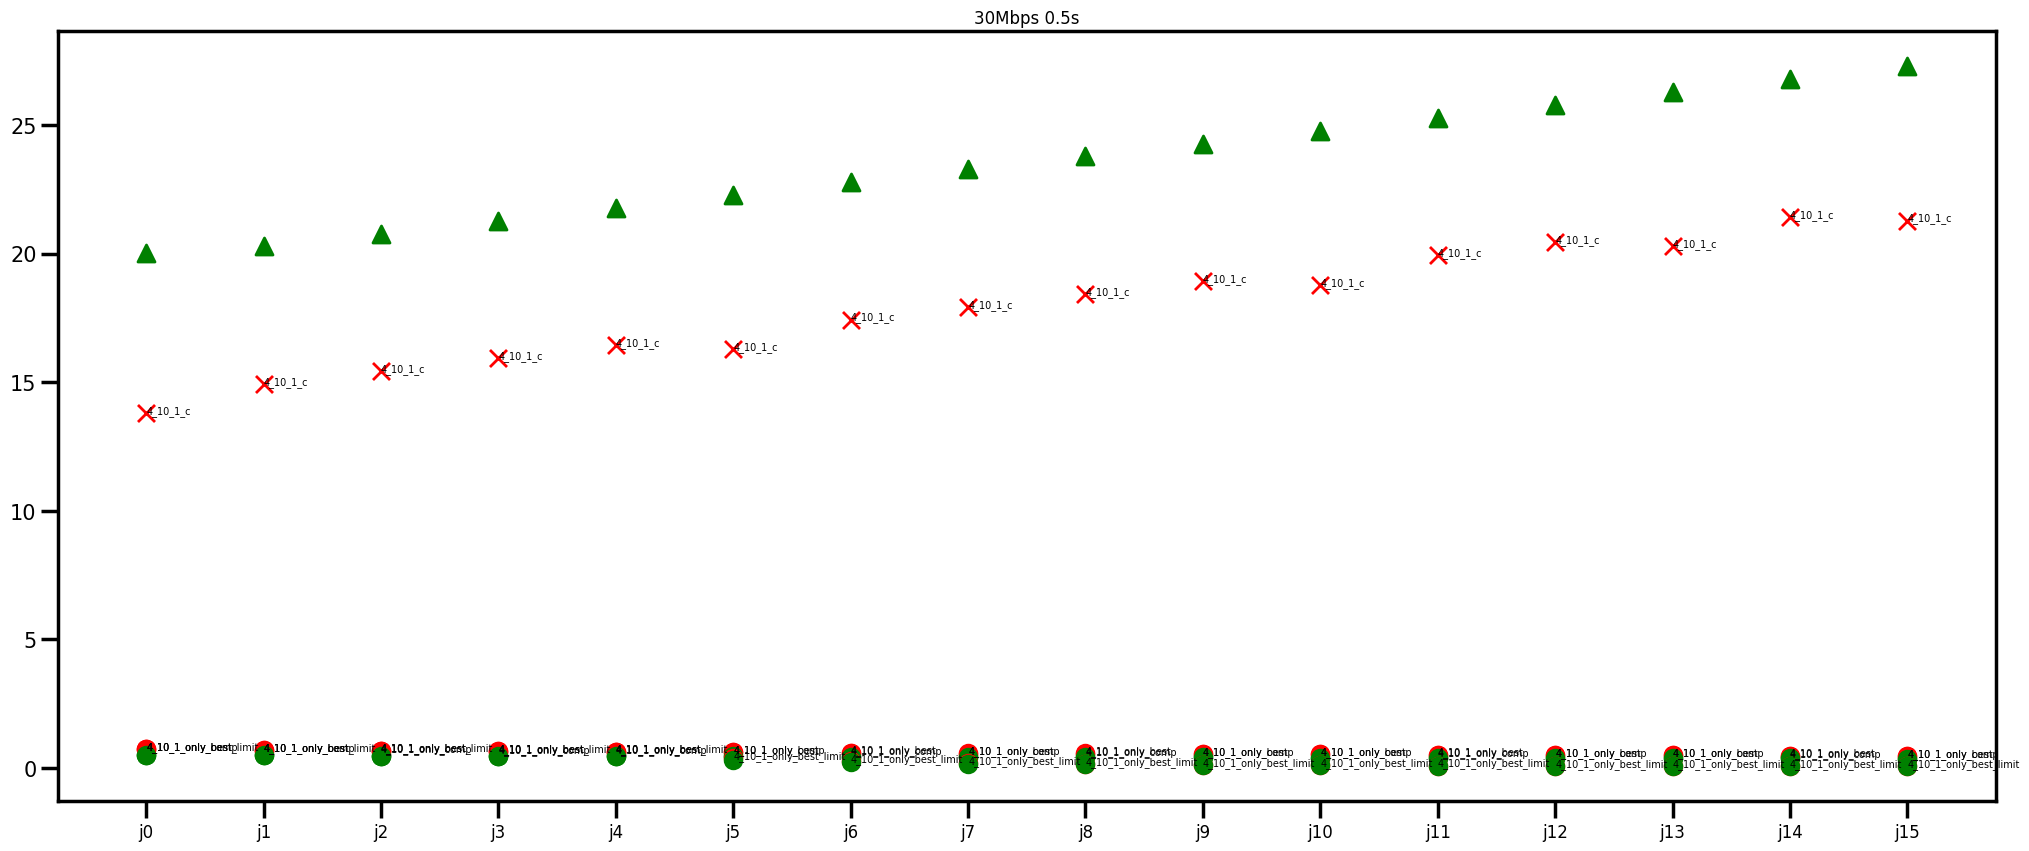

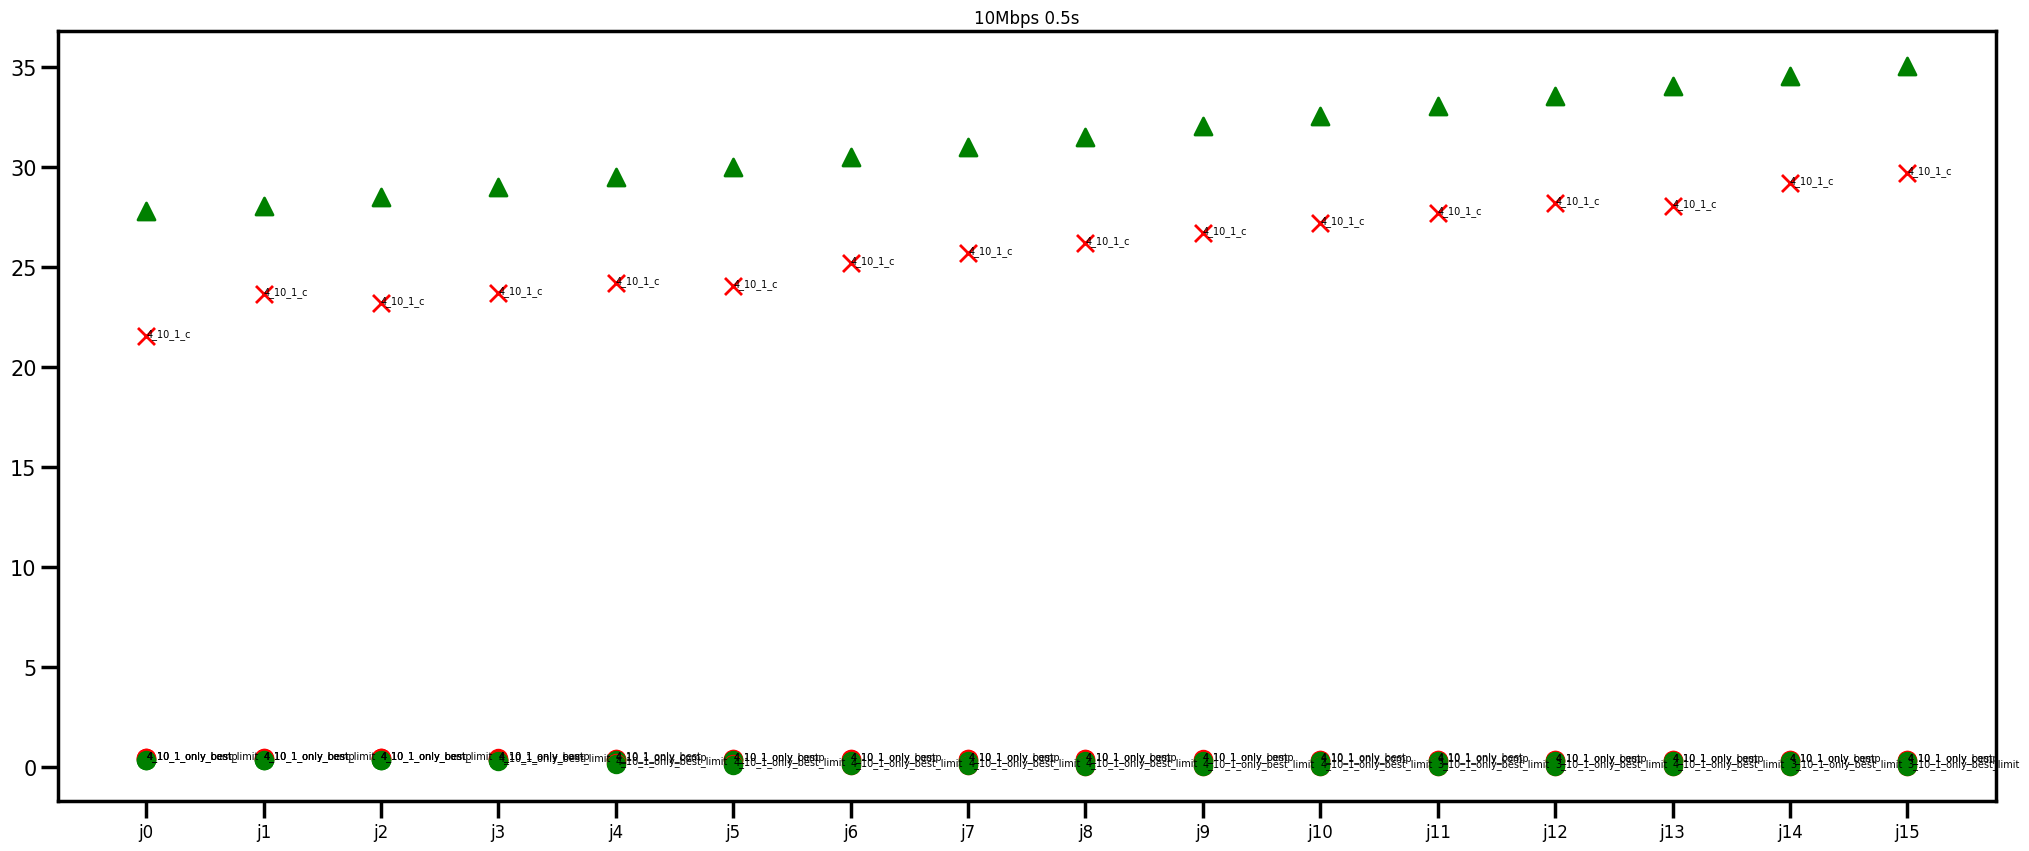

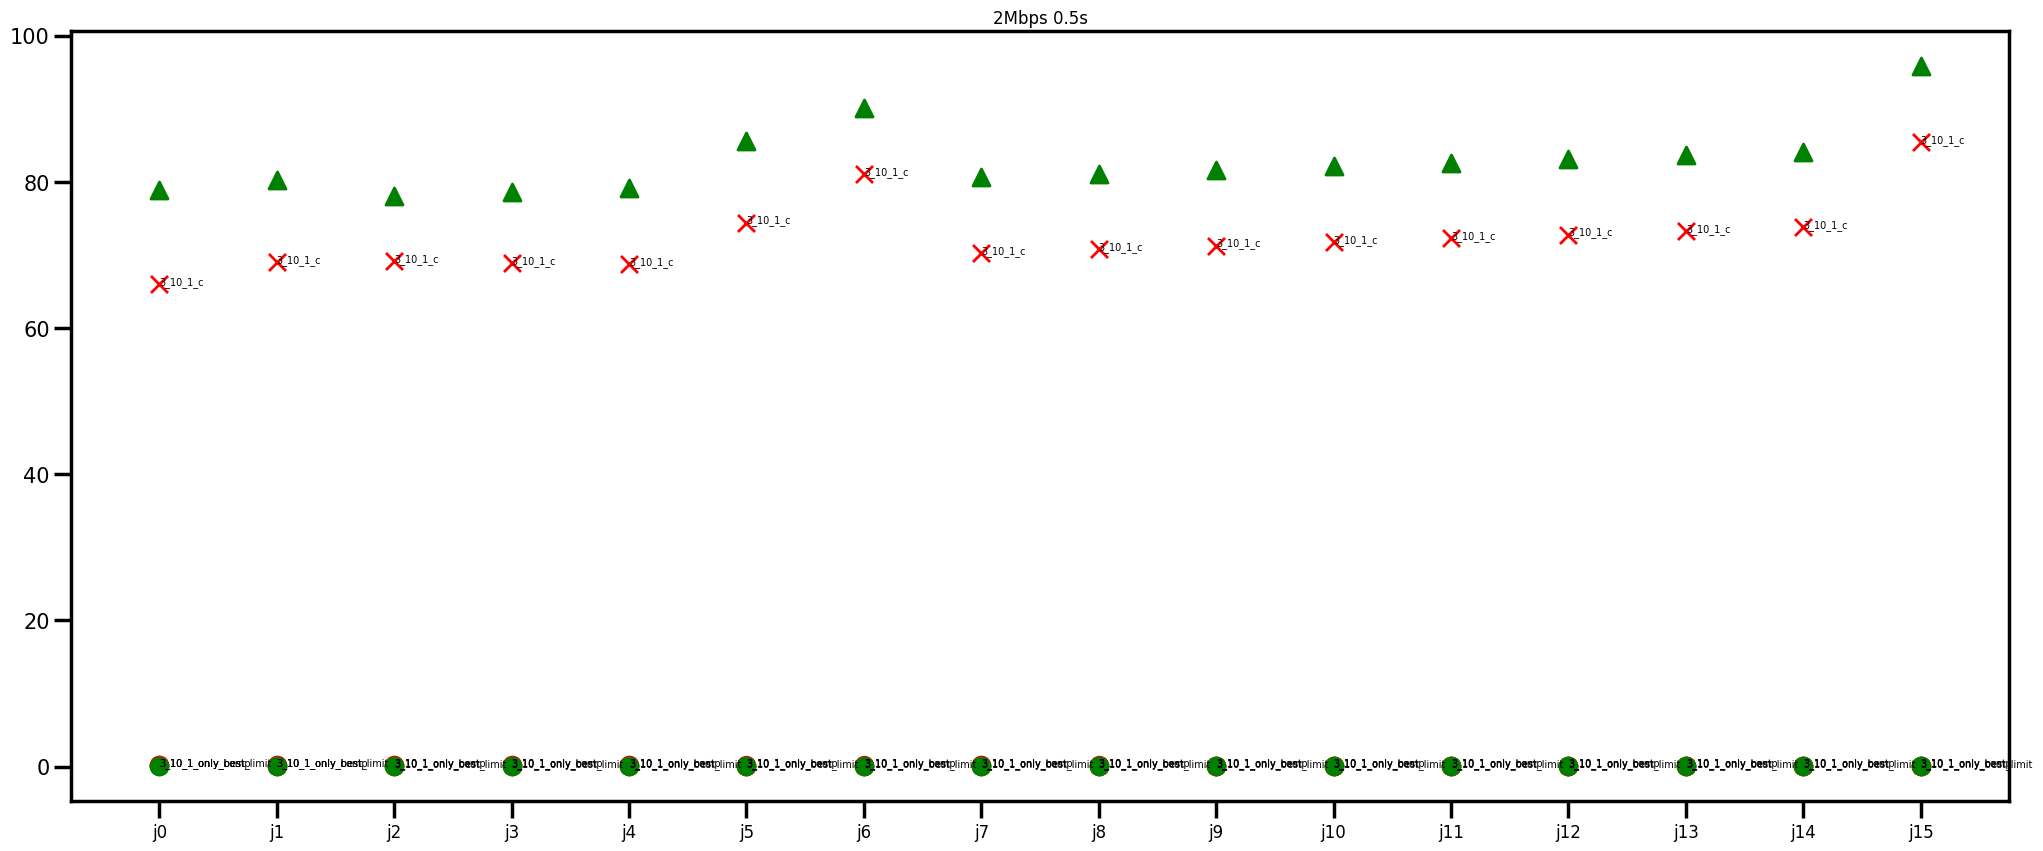

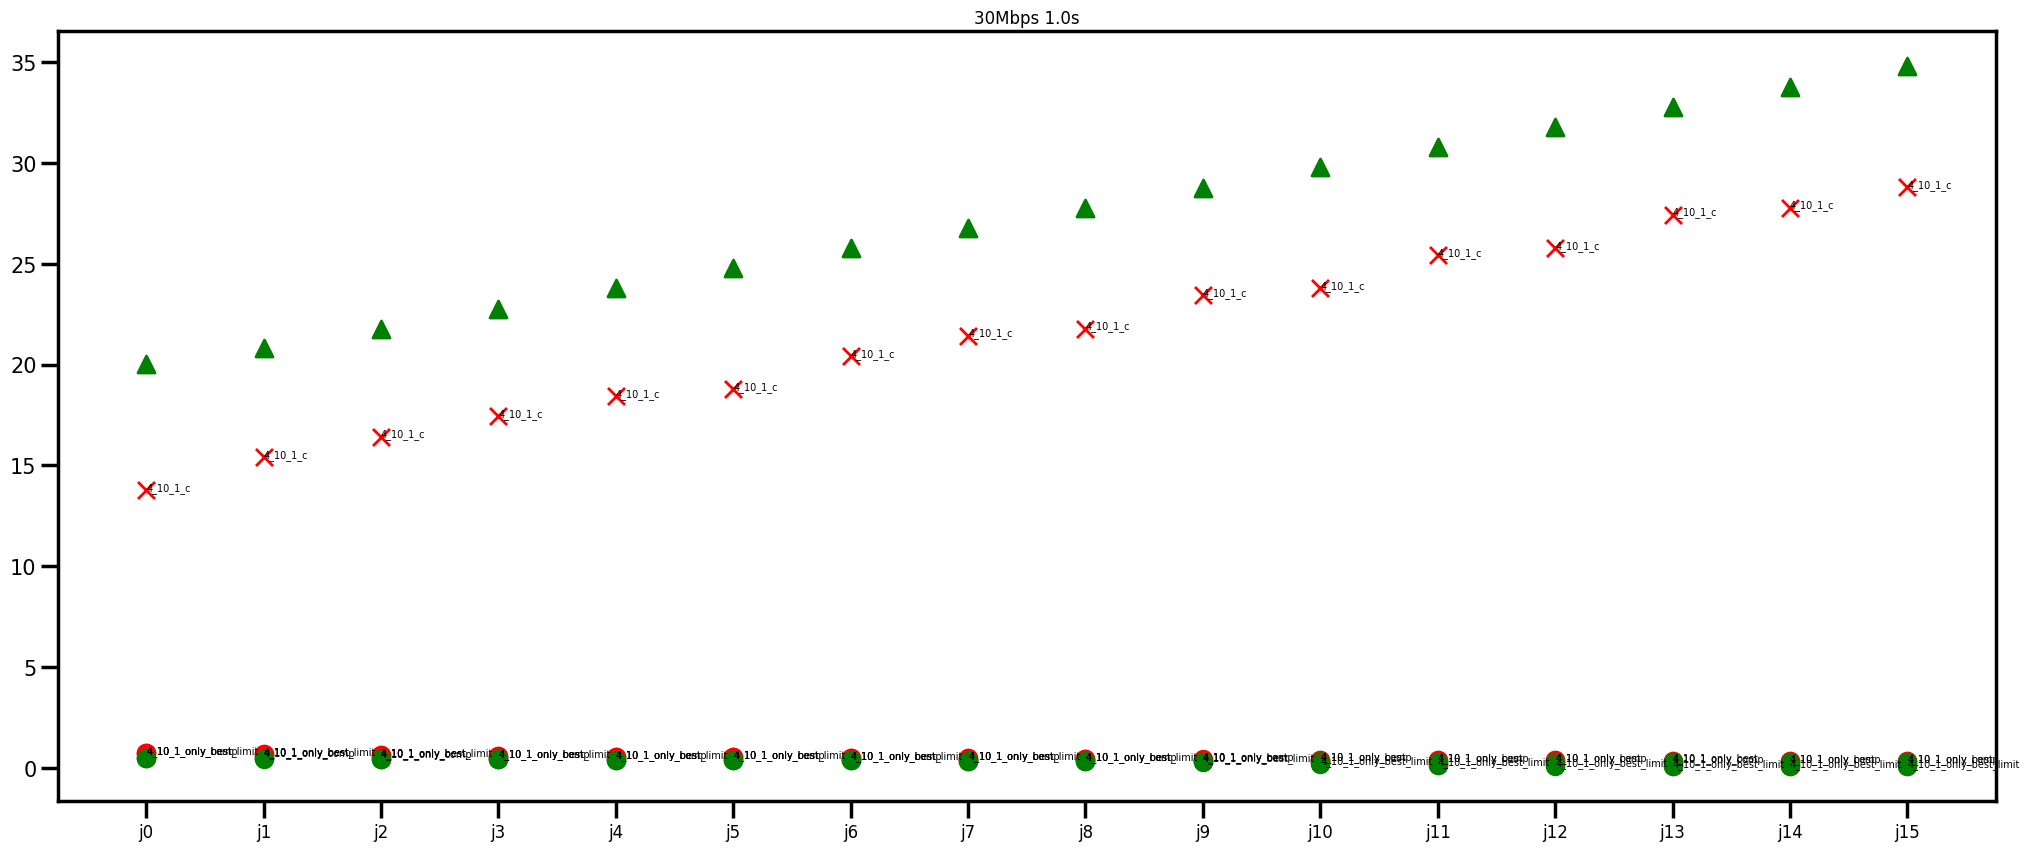

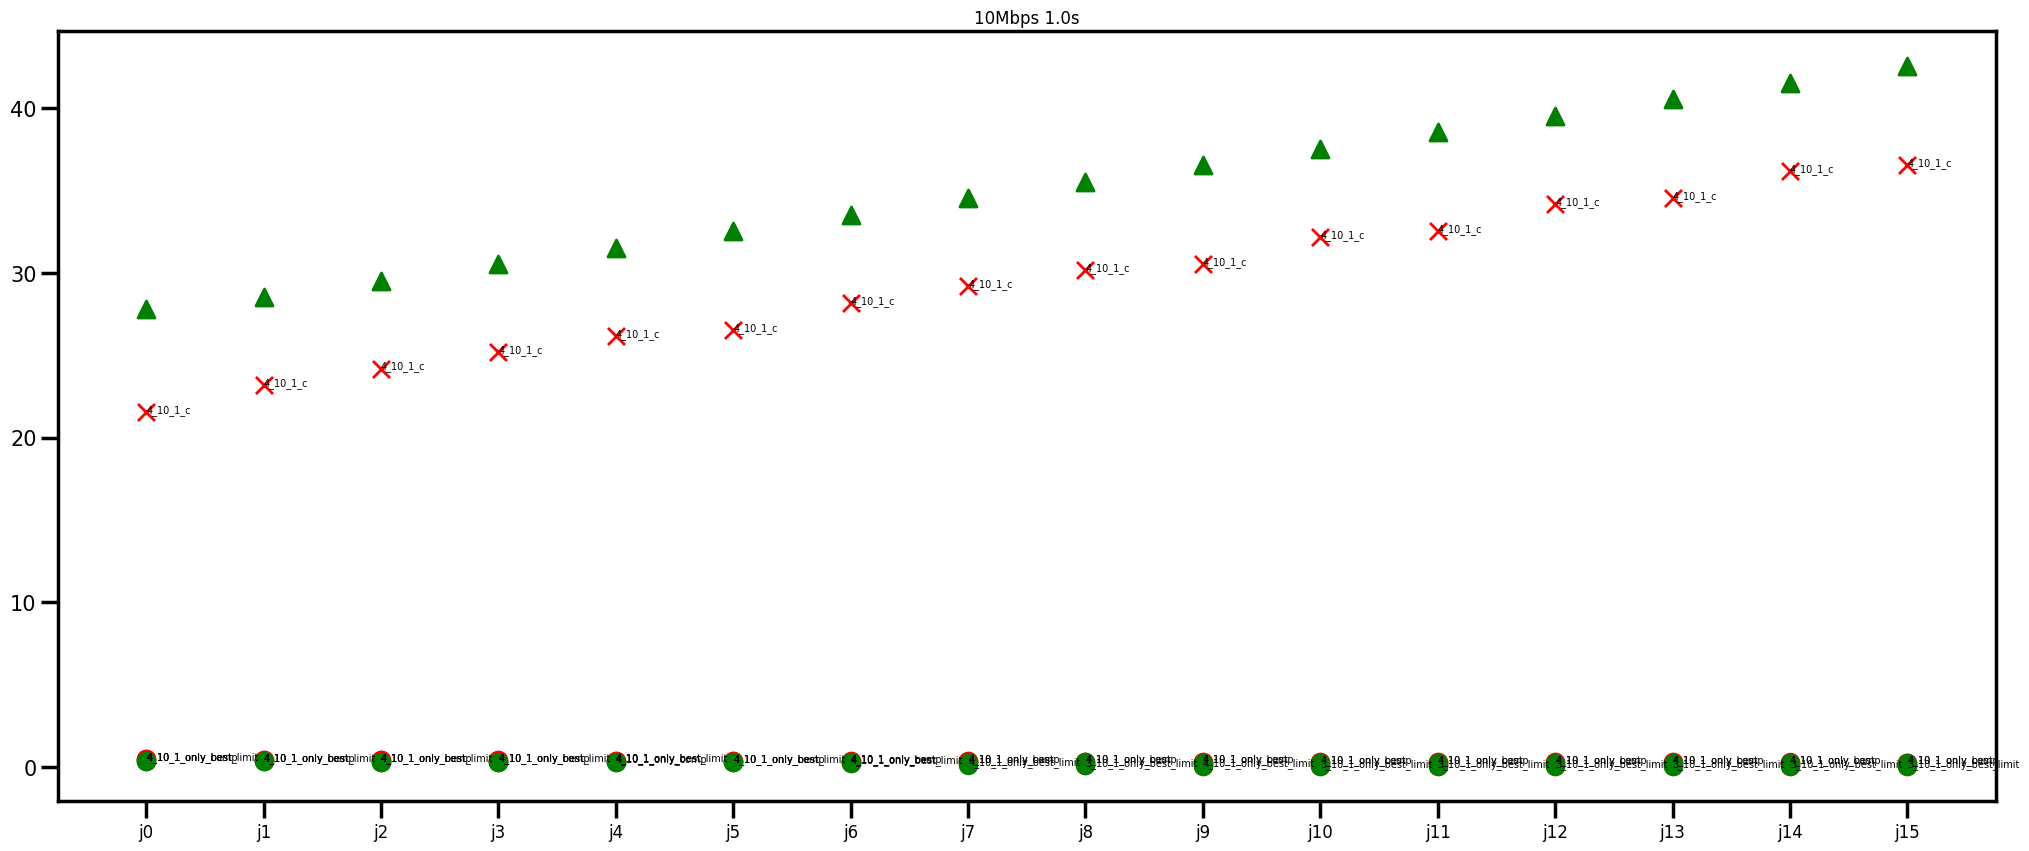

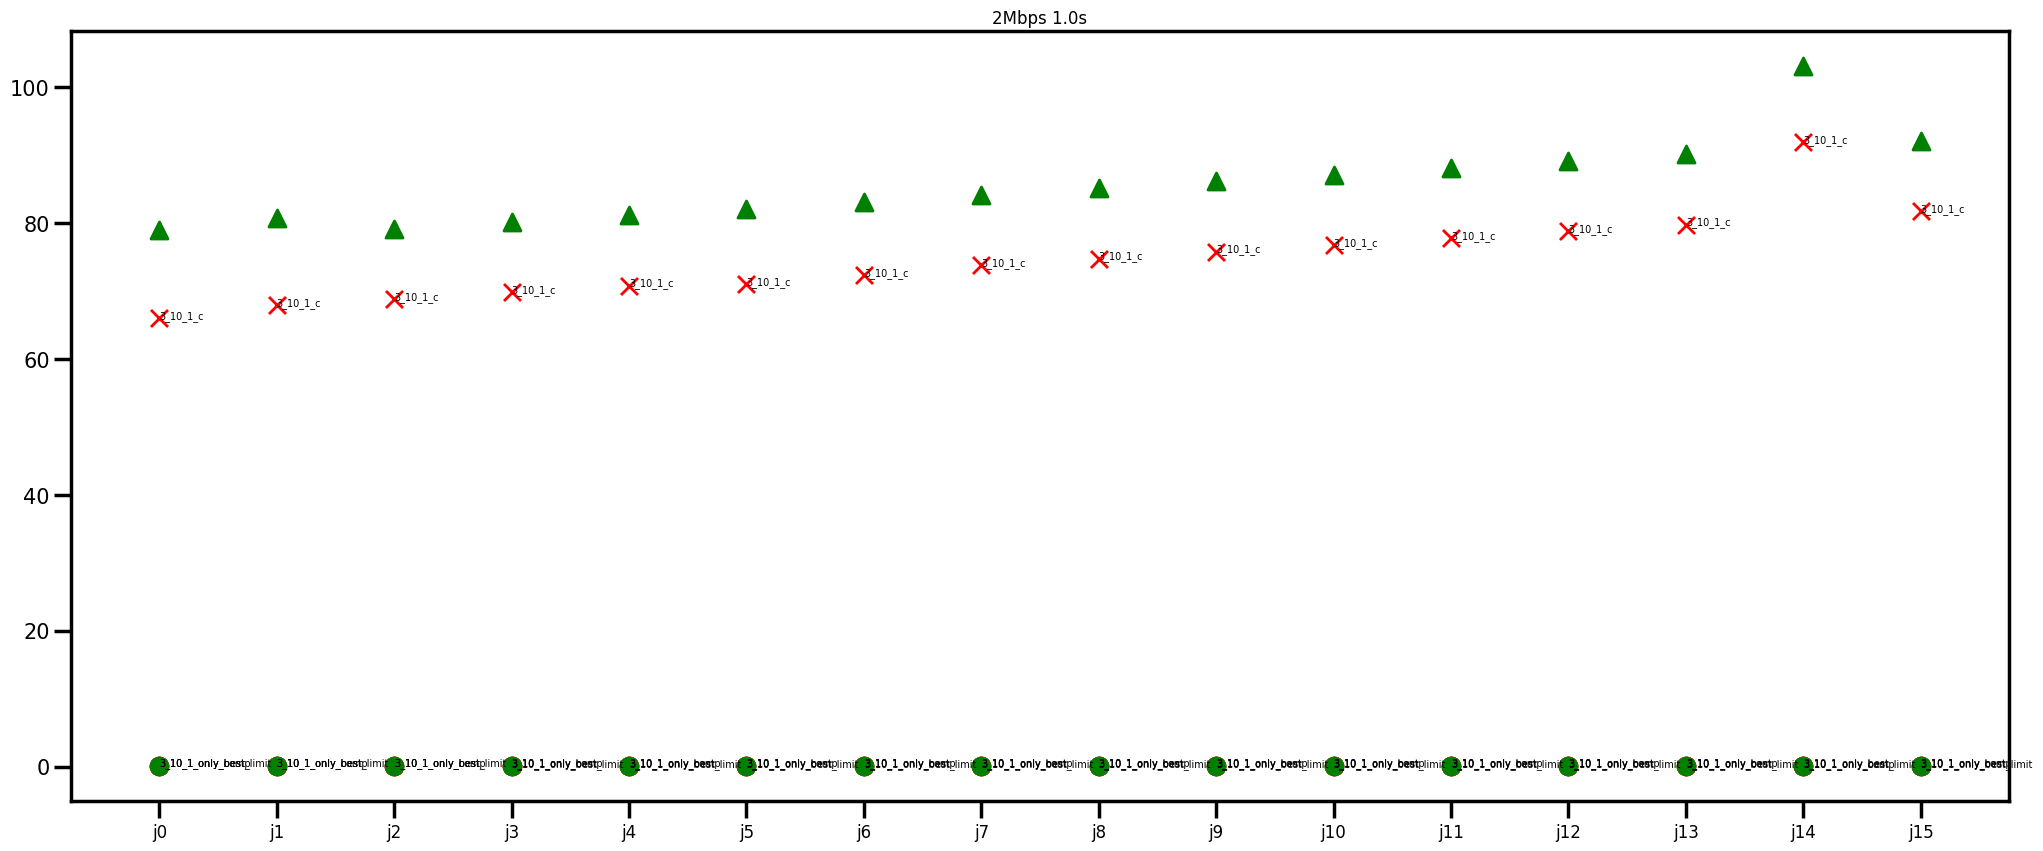

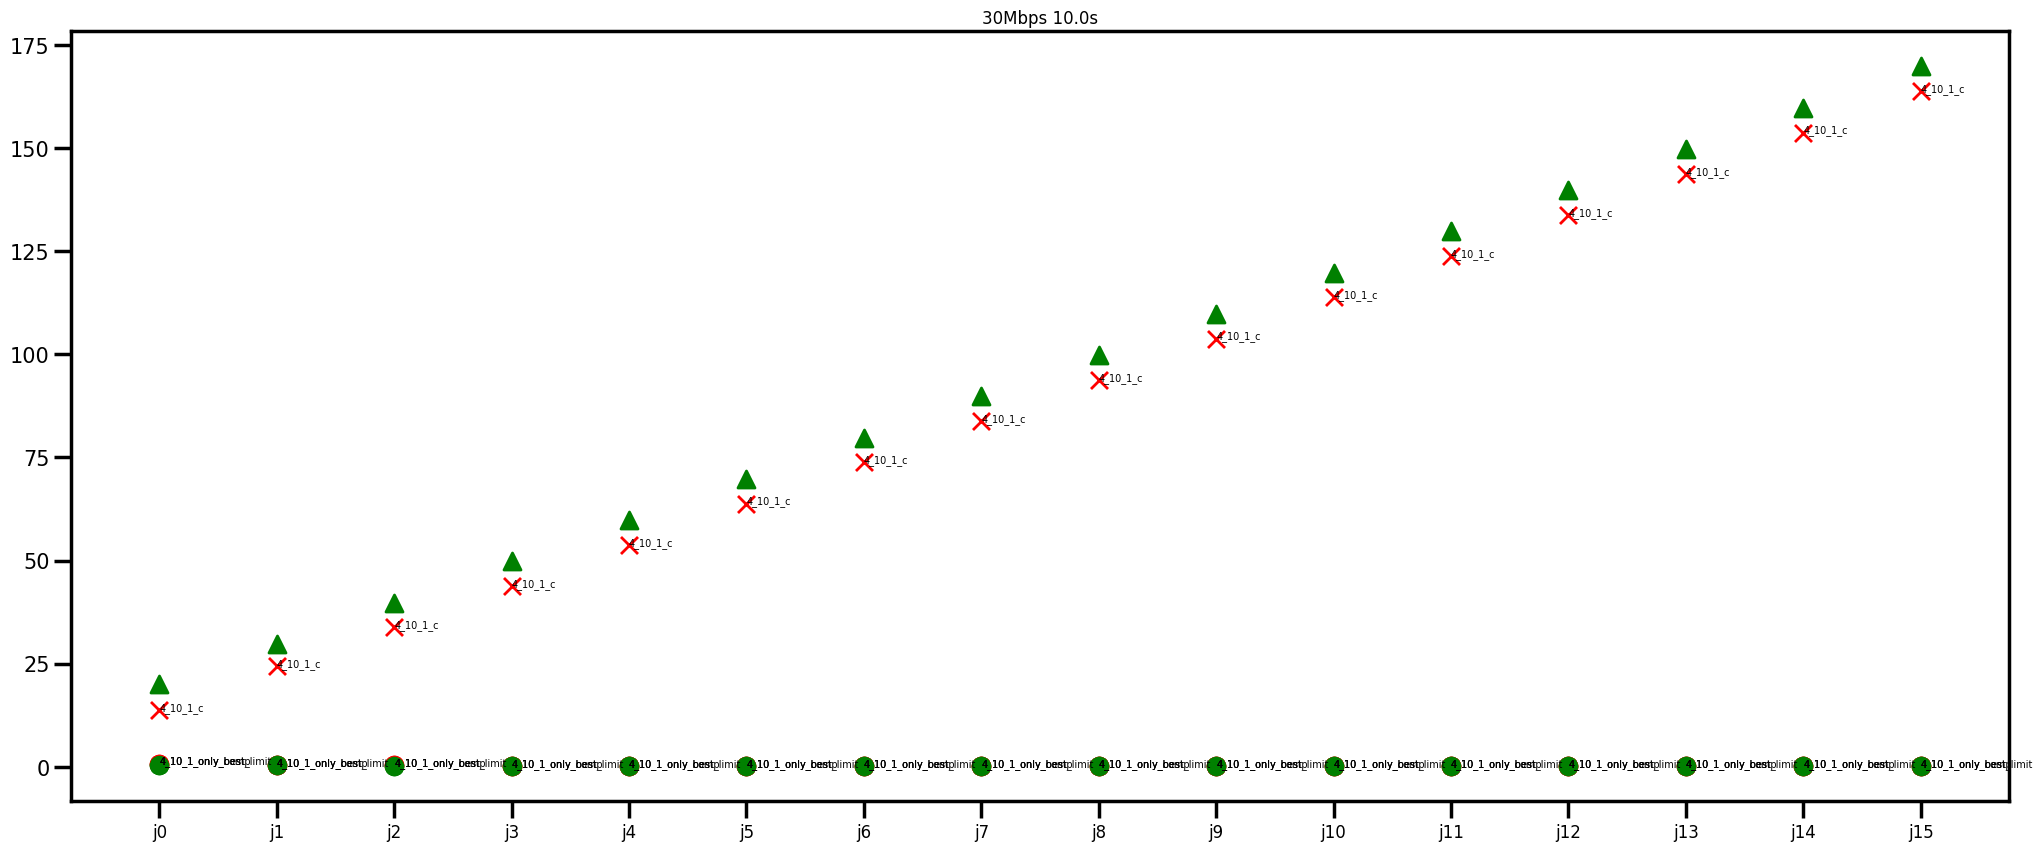

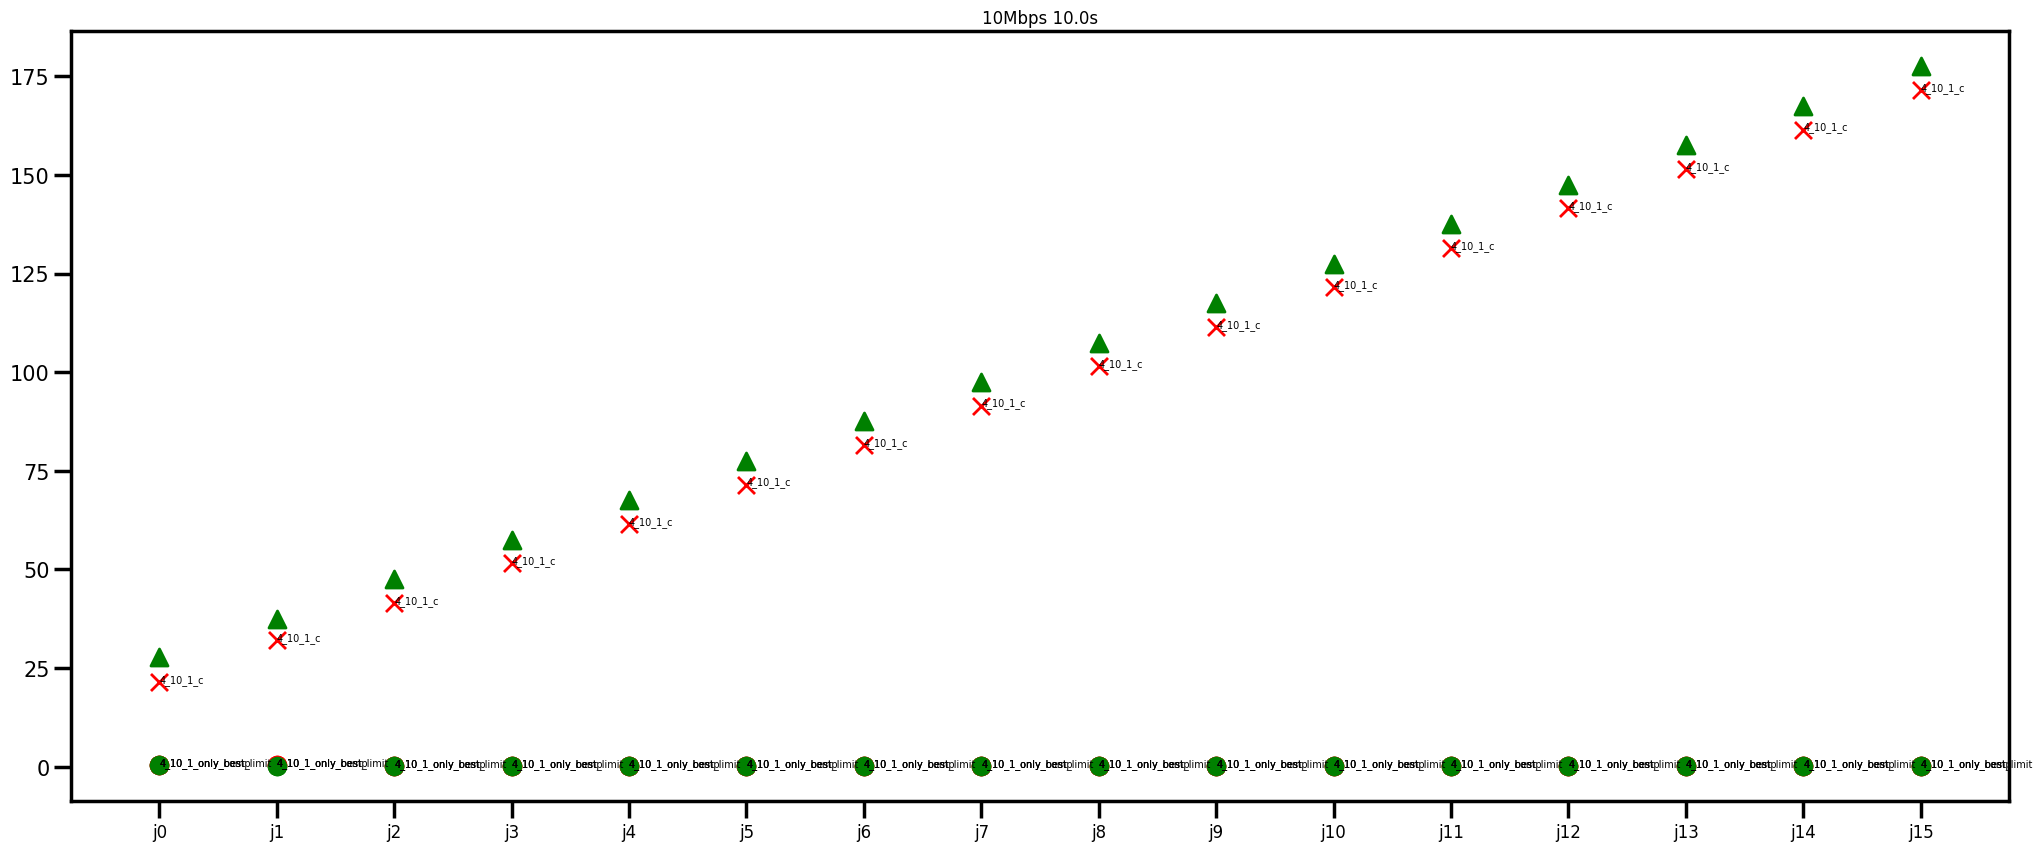

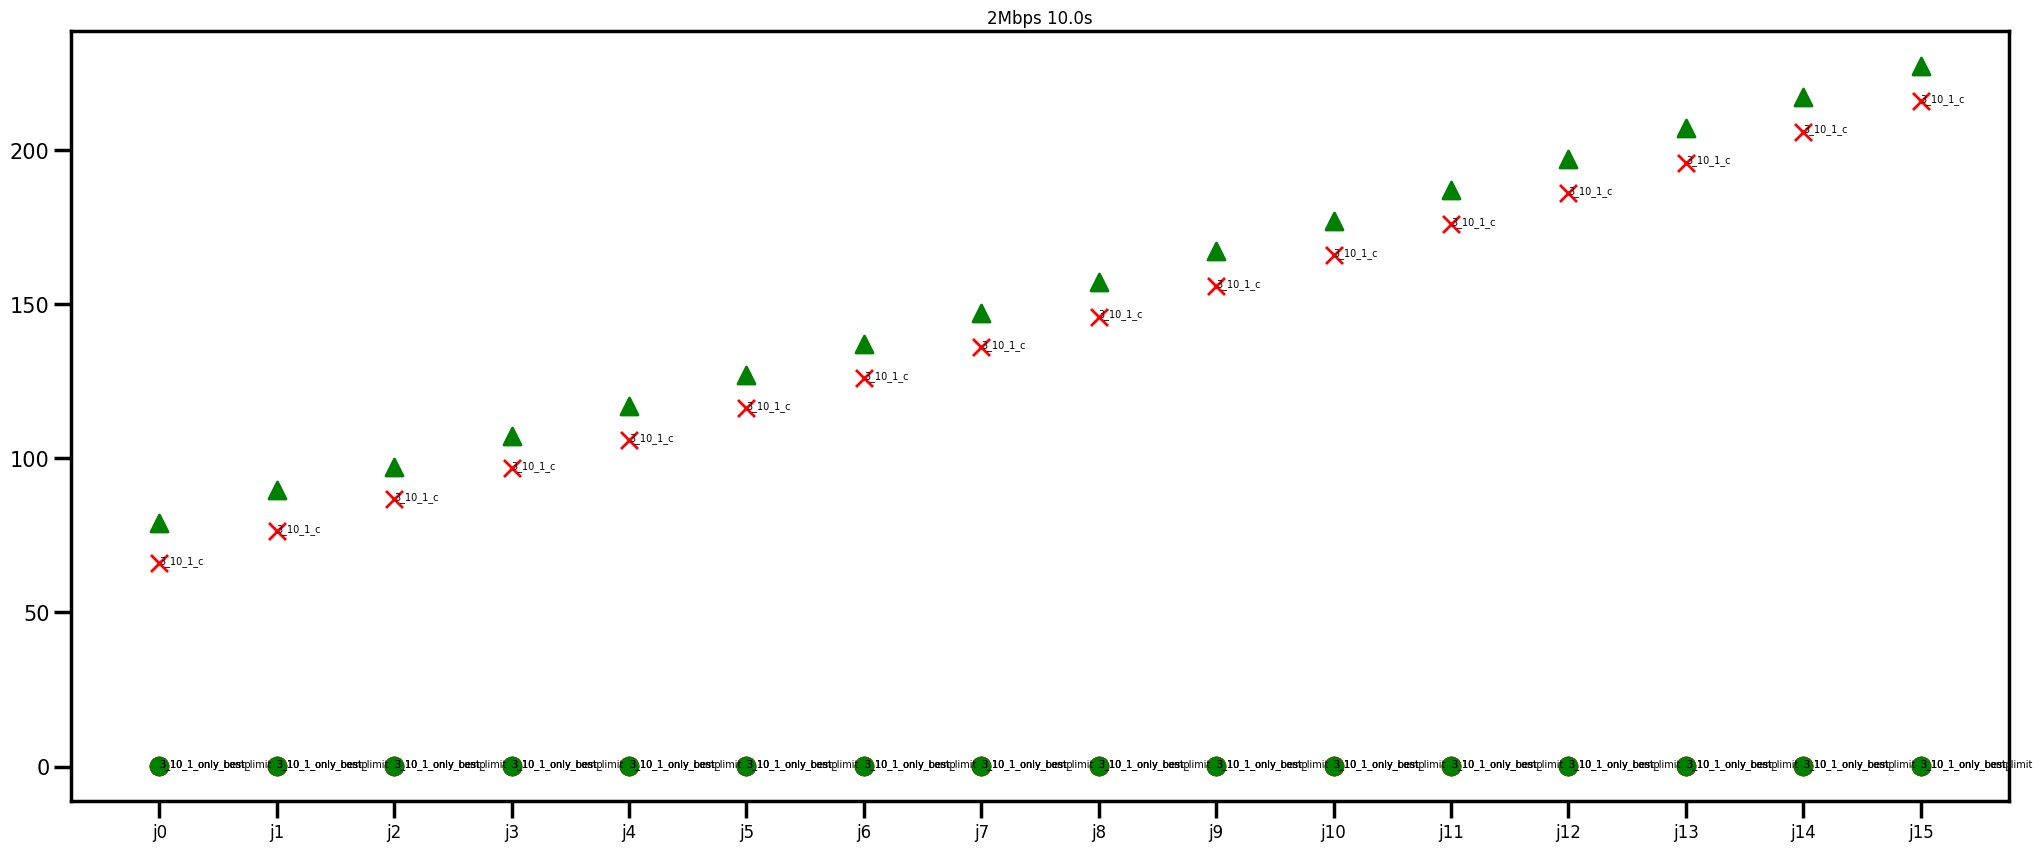

: 

In [ ]:
# bws = [240, 5, 2]
# bws = [240, 5, 2]
# bws=[240, 30, 20, 15, 10, 2, 1]
bws=[30,10,2]

iats = [0.01, 0.5, 1.0, 10.0]
# iats = [0.001, 0.1, 1.0, 10.0]
inp=10
global_real=[]
global_pred=[]

global_full_real_time=[]
global_full_pred_time=[]
global_full_real_th=[]
global_full_pred_th=[]

cur_model = "resnet18"
# cur_model = "vit"
# cur_model = "eff"
csv_header="run_type,arr_time,model,bw,throughput,latency,job_count,max_wait,max_wait_and_arr\n"
lines_to_be_written=[]
for cur_model in ["resnet18", "eff", "vit"]:
    for iat in iats:
        for bw in bws:
            # filename = f"../scheduler/sim.op.bramble-1-3.resnet18.{bw}.{iat}"
            # filename = f"../scheduler/sim.op.bramble-2-4.vit.{bw}.{iat}"
            # filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.eff.{bw}.{iat}"
            filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}"
            # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.azure"
            if not Path(filename).is_file():
                continue
            ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename, skip_ts=False)
            # ts, overhead, bs, bn, world, added_time = simulation_reader("../scheduler/sim.op.bramble-1-3.resnet18")
            # ts, overhead, bs, bn, world, added_time = simulation_reader("../scheduler/sim.op.bramble-1-3.resnet18.0.1")
            # ts, overhead, bs, bn, world, added_time = simulation_reader("../scheduler/sim.op.bramble-1-3.resnet18.1.0")
            # ts, overhead, bs, bn, world, added_time = simulation_reader("../scheduler/sim.op.dummy.resnet18")
            # print(ts)
            if len(ts)==6:
                continue
            # print(overhead)
            # print(bs)
            # print(bn)
            # print(world)

            real_ts={}
            only_wait_ts={}
            specific_waits =[]
            for j in ts:
                if j not in real_ts:
                    real_ts[j]=0
                # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", "vit", world[j], overhead[j]-1,
                # bs[j], bn[j], bw=bw, ty=ty[j]) + added_time[j]
                real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j], overhead[j],
                bs[j], bn[j], bw=bw, ty=ty[j])
                arr_t = added_time[j][0]
                wait_t = added_time[j][1]
                only_wait_ts[j] =  arr_t+wait_t
                specific_waits.append(wait_t)
                real_ts[j] = arr_t+wait_t+real_ts[j]
            # print(real_ts)
            
            print(filename)
            global_full_pred_th.append( round(inp*len(ts)/max(ts.values()),3) )
            global_full_pred_time.append(max(ts.values()))

            global_full_real_th.append( round(inp*len(real_ts)/max(real_ts.values()),3) )
            global_full_real_time.append(max(real_ts.values()))
            lines_to_be_written.append(f"greedy_sim,{iat},{cur_model},{bw},{inp*len(ts)/max(ts.values())},{max(ts.values())},{len(ts)},{max(specific_waits)},{max(only_wait_ts.values())}\n")
            lines_to_be_written.append(f"greedy_real,{iat},{cur_model},{bw},{inp*len(real_ts)/max(real_ts.values())},{max(real_ts.values())},{len(ts)},{max(specific_waits)},{max(only_wait_ts.values())}\n")
            print(f"total predicted time to completion of {len(ts)} jobs: {max(ts.values())}, full throughput: {inp*len(ts)/max(ts.values())}, s/machine: {(sum(ts.values())-sum(only_wait_ts.values()))/len(ts)}")
            print(f"total real time to completion of {len(real_ts)} jobs: {max(real_ts.values())}, full throughput: {inp*len(real_ts)/max(real_ts.values())}, s/machine: { (sum(real_ts.values()) - sum(only_wait_ts.values()))/len(real_ts)}")

            # real_ts = {k:inp/v for k,v in real_ts.items()}
            # ts = {k:inp/v for k,v in ts.items()}
            print(f"rmse: { np.sqrt(np.mean([ (real_ts[j] - ts[j])**2 for j in real_ts])) }")
            print(f"mape: { (np.mean([ abs(real_ts[j] - ts[j])/real_ts[j] for j in real_ts])) }")
            fig, axs = plt.subplots(figsize=(25,10))
            # axs.scatter(ts.keys(), ts.values(), marker=f"${world[]}$")
            for k in ts.keys():
                axs.scatter(k, ts[k], marker="x", s=150, color="red")
                axs.scatter(k, real_ts[k], marker="^", s=150, color="green")
                axs.text(k, ts[k], f"{world[k]}_{bn[k]}_{bs[k]}_{ty[k]}")
                axs.set_title(f"{bw}Mbps {iat}s")
            global_real.extend(list(real_ts.values()))
            global_pred.extend(list(ts.values()))
            # continue
            #special files now for only compute and only communicate
            for s in ["only_comp", "only_comm", "only_best", "only_best_limit"]:
                filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.azure"
                if not Path(filename).is_file():
                    continue
                ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename, skip_ts=False)
                if len(ts)==6:
                    continue
                if "best" not in filename:
                    ty = {j:"c" if "comp" in filename else "nw" for j in ts}

                real_ts={}
                only_wait_ts={}
                specific_waits=[]
                for j in ts:
                    if j not in real_ts:
                        real_ts[j]=0
                    # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
                    # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
                    real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j], overhead[j],
                    bs[j], bn[j], bw=bw, ty=ty[j])
                    arr_t = added_time[j][0]
                    wait_t = added_time[j][1]
                    specific_waits.append(wait_t)
                    only_wait_ts[j] =  arr_t+wait_t
                    real_ts[j] = arr_t+wait_t+real_ts[j] 
                # print(real_ts)
                # global_full_pred_th.append(inp*len(ts)/max(ts.values()))
                # global_full_pred_time.append(max(ts.values()))

                # global_full_real_th.append(inp*len(real_ts)/max(real_ts.values()))
                # global_full_real_time.append(max(real_ts.values()))
                
                print(filename, s)
                lines_to_be_written.append(f"{s}_sim,{iat},{cur_model},{bw},{inp*len(ts)/max(ts.values())},{max(ts.values())},{len(ts)},{max(specific_waits)},{max(only_wait_ts.values())}\n")
                lines_to_be_written.append(f"{s}_real,{iat},{cur_model},{bw},{inp*len(real_ts)/max(real_ts.values())},{max(real_ts.values())},{len(ts)},{max(specific_waits)},{max(only_wait_ts.values())}\n")
                print(f"total predicted time to completion of {len(ts)} jobs: {max(ts.values())}, full throughput: {inp*len(ts)/max(ts.values())}, s/machine: {(sum(ts.values())-sum(only_wait_ts.values()))/len(ts)}")
                print(f"total real time to completion of {len(real_ts)} jobs: {max(real_ts.values())}, full throughput: {inp*len(real_ts)/max(real_ts.values())}, s/machine: {(sum(real_ts.values())-sum(only_wait_ts.values()))/len(real_ts)}")
                # print(f"{s} rmse: { np.sqrt(np.mean([ (real_ts[j] - ts[j])**2 for j in real_ts])) }")
                # print(f"{s} mape: { (np.mean([ abs(real_ts[j] - ts[j])/real_ts[j] for j in real_ts])) }")
                real_ts = {k:inp/(v if v!=0 else 1) for k,v in real_ts.items()}
                ts = {k:inp/(v if v!=0 else 1) for k,v in ts.items()}
                for k in ts.keys():
                    axs.scatter(k, ts[k], marker="o", color="red")
                    axs.scatter(k, real_ts[k], marker="o", color="green")
                    axs.text(k, ts[k], f"{world[k]}_{bn[k]}_{bs[k]}_{s}")
                    # axs.set_title(f"{bw}Mbps {iat}s")
                

            print()

print("global rmse, mape")
print(f"rmse: { np.sqrt(np.mean([ (global_real[j] - global_pred[j])**2 for j in range(len(global_pred))])) }")
print(f"mae: { (np.mean([ abs(global_real[j] - global_pred[j]) for j in range(len(global_pred))])) }")
print(f"mape: { (np.mean([ abs(global_real[j] - global_pred[j])/global_real[j] for j in range(len(global_pred))])) }")
print()
print("global total time and throughput")
print(f"std real time: {np.std( global_full_real_time )}")
print(f"std real th: {np.std( global_full_real_th )}")
print(f"std pred time: {np.std( global_full_pred_time )}")
print(f"std pred th: {np.std( global_full_pred_th )}")
print(f"std pred-real abs diff {(np.std([ abs(global_full_real_th[j] - global_full_pred_th[j]) for j in range(len(global_full_pred_time))]))}")

print(f"rmse time: { np.sqrt(np.mean([ (global_full_real_time[j] - global_full_pred_time[j])**2 for j in range(len(global_full_pred_time))])) }")
print(f"rmse th: { np.sqrt(np.mean([ (global_full_real_th[j] - global_full_pred_th[j])**2 for j in range(len(global_full_pred_th))])) }")
print(f"mae time: { (np.mean([ abs(global_full_real_time[j] - global_full_pred_time[j]) for j in range(len(global_full_pred_time))])) }")
print(f"mae th: { (np.mean([ abs(global_full_real_th[j] - global_full_pred_th[j]) for j in range(len(global_full_pred_time))])) }")
print(f"mape time: { np.sqrt(np.mean([ abs(global_full_real_time[j] - global_full_pred_time[j])/global_full_real_time[j] for j in range(len(global_full_pred_time))])) }")
print(f"mape th: { np.sqrt(np.mean([ abs(global_full_real_th[j] - global_full_pred_th[j])/global_full_real_th[j] for j in range(len(global_full_pred_th))])) }")

f=open("sim_vs_real.csv","w")
# f=open("sim_vs_real_azure.csv","w")
f.write(csv_header)
f.writelines(lines_to_be_written)
f.close()
#for batch size 1
#fp rate = 0.35 for eff
#for rate = 3 for eff 
#for rate = 20 for res and vit

#this is for batch size 10
#fp rate = 2.8 for res -> also 2.5 actually?
#fp rate = 2.5 for vit

#res -> 2.5 to 3
# {'j0': 30.706000000000003, 'j1': 31.206000000000003, 'j2': 34.54023578590206, 'j3': 38.54871807957278, 'j4': 39.176, 'j5': 66.412}
# {'j0': 80, 'j1': 80, 'j2': 80, 'j3': 80, 'j4': 80, 'j5': 84}
# {'j0': np.int64(1), 'j1': np.int64(1), 'j2': np.int64(1), 'j3': np.int64(1), 'j4': np.int64(1), 'j5': np.int64(1)}
# {'j0': np.int64(10), 'j1': np.int64(10), 'j2': np.int64(10), 'j3': np.int64(10), 'j4': np.int64(10), 'j5': np.int64(10)}
# {'j0': np.int64(4), 'j1': np.int64(4), 'j2': np.int64(4), 'j3': np.int64(4), 'j4': np.int64(4), 'j5': np.int64(4)}
# {'j0': np.float64(47.6694904), 'j1': np.float64(47.6694904), 'j2': np.float64(47.6694904), 'j3': np.float64(47.6694904), 'j4': np.float64(47.6694904), 'j5': np.float64(75.8754904)}
# rmse: 12.754537538136848
# mape: 0.24514640422178194

#resnet18 -> 3->2.8
# {'j0': 32.055, 'j1': 32.555, 'j2': 36.33707528541065, 'j3': 40.79640278259435, 'j4': 41.103, 'j5': 69.11}
# {'j0': 80, 'j1': 80, 'j2': 80, 'j3': 80, 'j4': 80, 'j5': 84}
# {'j0': np.int64(1), 'j1': np.int64(1), 'j2': np.int64(1), 'j3': np.int64(1), 'j4': np.int64(1), 'j5': np.int64(1)}
# {'j0': np.int64(10), 'j1': np.int64(10), 'j2': np.int64(10), 'j3': np.int64(10), 'j4': np.int64(10), 'j5': np.int64(10)}
# {'j0': np.int64(4), 'j1': np.int64(4), 'j2': np.int64(4), 'j3': np.int64(4), 'j4': np.int64(4), 'j5': np.int64(4)}
# {'j0': np.float64(47.6694904), 'j1': np.float64(47.6694904), 'j2': np.float64(47.6694904), 'j3': np.float64(47.6694904), 'j4': np.float64(47.6694904), 'j5': np.float64(77.22449040000001)}
# rmse: 11.231554113703327
# mape: 0.21156062842690213

#
# {'j0': 32.729, 'j1': 33.229, 'j2': 37.240534388197425, 'j3': 41.926016581861155, 'j4': 42.066, 'j5': 70.458}
# {'j0': 80, 'j1': 80, 'j2': 80, 'j3': 80, 'j4': 80, 'j5': 84}
# {'j0': np.int64(1), 'j1': np.int64(1), 'j2': np.int64(1), 'j3': np.int64(1), 'j4': np.inqt64(1), 'j5': np.int64(1)}
# {'j0': np.int64(10), 'j1': np.int64(10), 'j2': np.int64(10), 'j3': np.int64(10), 'j4': np.int64(10), 'j5': np.int64(10)}
# {'j0': np.int64(4), 'j1': np.int64(4), 'j2': np.int64(4), 'j3': np.int64(4), 'j4': np.int64(4), 'j5': np.int64(4)}
# {'j0': np.float64(47.6694904), 'j1': np.float64(47.6694904), 'j2': np.float64(47.6694904), 'j3': np.float64(47.6694904), 'j4': np.float64(47.6694904), 'j5': np.float64(77.8984904)}
# rmse: 10.490127370025338
# mape: 0.19477888891427889

#inter_arrivla = 0.8, 
# rmse: 4.273794775599762
# mape: 0.2360364127632102


In [372]:
#when is 6 worse than any other combination 
cur_model = "eff"
bw=240
# f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "r")
# detailed_map = f.readlines()[0]
# detailed_map = literal_eval(detailed_map.strip())
bg_load=40
fixed_w = 6
model_marker = {"eff":"x", "resnet18":"o", "vit":"^"}
l_w=3
sub="bramble-2-4"
# bws=[2,5,10,20,30,40,50,60,70,80,100,240]
bws=[2,10,30,240]
for cur_model in ["eff", "resnet18", "vit"]:
    # fig, axs = plt.subplots(figsize=(25,10))
    load_to_scores={}
    for bw_ind, bw in enumerate(bws):
        l_w=4 if cur_model=="vit" else 3
        for bg_load in range(1,101):
        # for bg_load in range(1,110,10):
            b_flag=0
            for w in [3]:
                # score_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, fixed_w,  bg_load*map_sub["bramble-2-4"]*0.01 ,
                #                     1, 10, bw=bw, ty='c', col_flag="median", nw_var=True)
                score_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w,  bg_load*map_sub["bramble-2-4"]*0.01,
                                    1, 10, bw=bw, ty='c', col_flag="median", nw_var=True)
                score_to_beat = 10/(score_nw)
                real_rt_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w, bg_load*map_sub["bramble-2-4"]*0.01,
                                1, 10, bw=bw, ty="nw", col_flag="median", nw_var=True)
                # real_rt_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, l_w, bg_load*map_sub["bramble-2-4"]*0.01+3,
                #                 1, 10, bw=bw, ty="c", col_flag="median", nw_var=True)
                cur_score = 10/real_rt_nw
                if cur_score >= score_to_beat and (cur_score-score_to_beat)/score_to_beat >= 0.10:
                    print(cur_model, bw, bg_load, [cur_score])
                    b_flag=1
                    break
            if b_flag==1:
                b_flag=0
                break
            # else:
            #     axs.scatter(bg_load, bw_ind, color="green" if cur_score > score_to_beat else "red", marker=model_marker[cur_model], label=f"2x3 split {cur_model}" if cur_score > score_to_beat else f"1x6 split {cur_model}"  )

                # break
            load_to_scores[bg_load] = [cur_score]


        # axs.plot(load_to_scores.keys(), [v[0] for v in load_to_scores.values()], label="2x3 splits", linestyle="--", marker="x")
        # axs.plot(load_to_scores.keys(), [v[2] for v in load_to_scores.values()], label="1x6 splits", linestyle="--", marker="x")
    # axs.legend()
    # axs.set_yticks(np.arange(0,len(bws)))
    # axs.set_yticklabels(bws)

    
        # print(ty, bg_load, cur_score, score_to_beat)
print()
print()
print()
print()
# for w in [3,4,5]:
cur_model = "eff"
bw=240
# f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "r")
# detailed_map = f.readlines()[0]
# detailed_map = literal_eval(detailed_map.strip())
bg_load=40
fixed_w = 6
model_marker = {"eff":"x", "resnet18":"o", "vit":"^"}
l_w=3
# bws=[2,5,10,20,30,40,50,60,70,80,100,240]
bws=[2,10,30,240]
for cur_model in ["eff", "resnet18", "vit"]:
    # fig, axs = plt.subplots(figsize=(25,10))
    load_to_scores={}
    for bw_ind, bw in enumerate(bws):
        l_w=4 if cur_model=="vit" else 3
        for bg_load in range(1,101):
        # for bg_load in range(1,110,10):
            b_flag=0
            for w in [6]:
                # score_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, fixed_w,  bg_load*map_sub["bramble-2-4"]*0.01 ,
                #                     1, 10, bw=bw, ty='c', col_flag="median", nw_var=True)
                score_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w,  bg_load*map_sub["bramble-2-4"]*0.01,
                                    1, 10, bw=bw, ty='nw', col_flag="median", nw_var=True)
                score_to_beat = 10/(score_nw)
                real_rt_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w, bg_load*map_sub["bramble-2-4"]*0.01,
                                1, 10, bw=bw, ty="c", col_flag="median", nw_var=True)
                # real_rt_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, l_w, bg_load*map_sub["bramble-2-4"]*0.01+3,
                #                 1, 10, bw=bw, ty="c", col_flag="median", nw_var=True)
                cur_score = 10/real_rt_nw
                if cur_score >= score_to_beat and (cur_score-score_to_beat)/score_to_beat >= 0.10:
                    print(cur_model, bw, bg_load, [cur_score])
                    b_flag=1
                    break
            if b_flag==1:
                b_flag=0
                break
                # axs.scatter(np.arange(bg_load,101), [bw_ind]*len(np.arange(bg_load,101)), color="green" if cur_score > score_to_beat else "red", marker=model_marker[cur_model], label=f"2x3 split {cur_model}" if cur_score > score_to_beat else f"1x6 split {cur_model}"  )
                # break
            # else:
            #     axs.scatter(bg_load, bw_ind, color="green" if cur_score > score_to_beat else "red", marker=model_marker[cur_model], label=f"2x3 split {cur_model}" if cur_score > score_to_beat else f"1x6 split {cur_model}"  )

                # break
            load_to_scores[bg_load] = [cur_score]


eff 2 1 [np.float64(0.48081546302529093)]
eff 10 1 [np.float64(1.278935925310142)]
eff 30 4 [np.float64(1.6423057973394646)]
eff 240 66 [np.float64(1.7088174982911823)]






KeyboardInterrupt: 

/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.eff.240.1.0.only_comp.uniform.duty_cycle.no_leeway
/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.eff.240.1.0.only_comm.uniform.duty_cycle.no_leeway
/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.eff.240.1.0.only_best.uniform.duty_cycle.no_leeway
/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.eff.30.1.0.only_comp.uniform.duty_cycle.no_leeway
/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.eff.30.1.0.only_comm.uniform.duty_cycle.no_leeway
/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.eff.30.1.0.only_best.uniform.duty_cycle.no_leeway
/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.eff.10.1.0.only_comp.uniform.duty_cycle.no_leeway
/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bra

Exception: end it

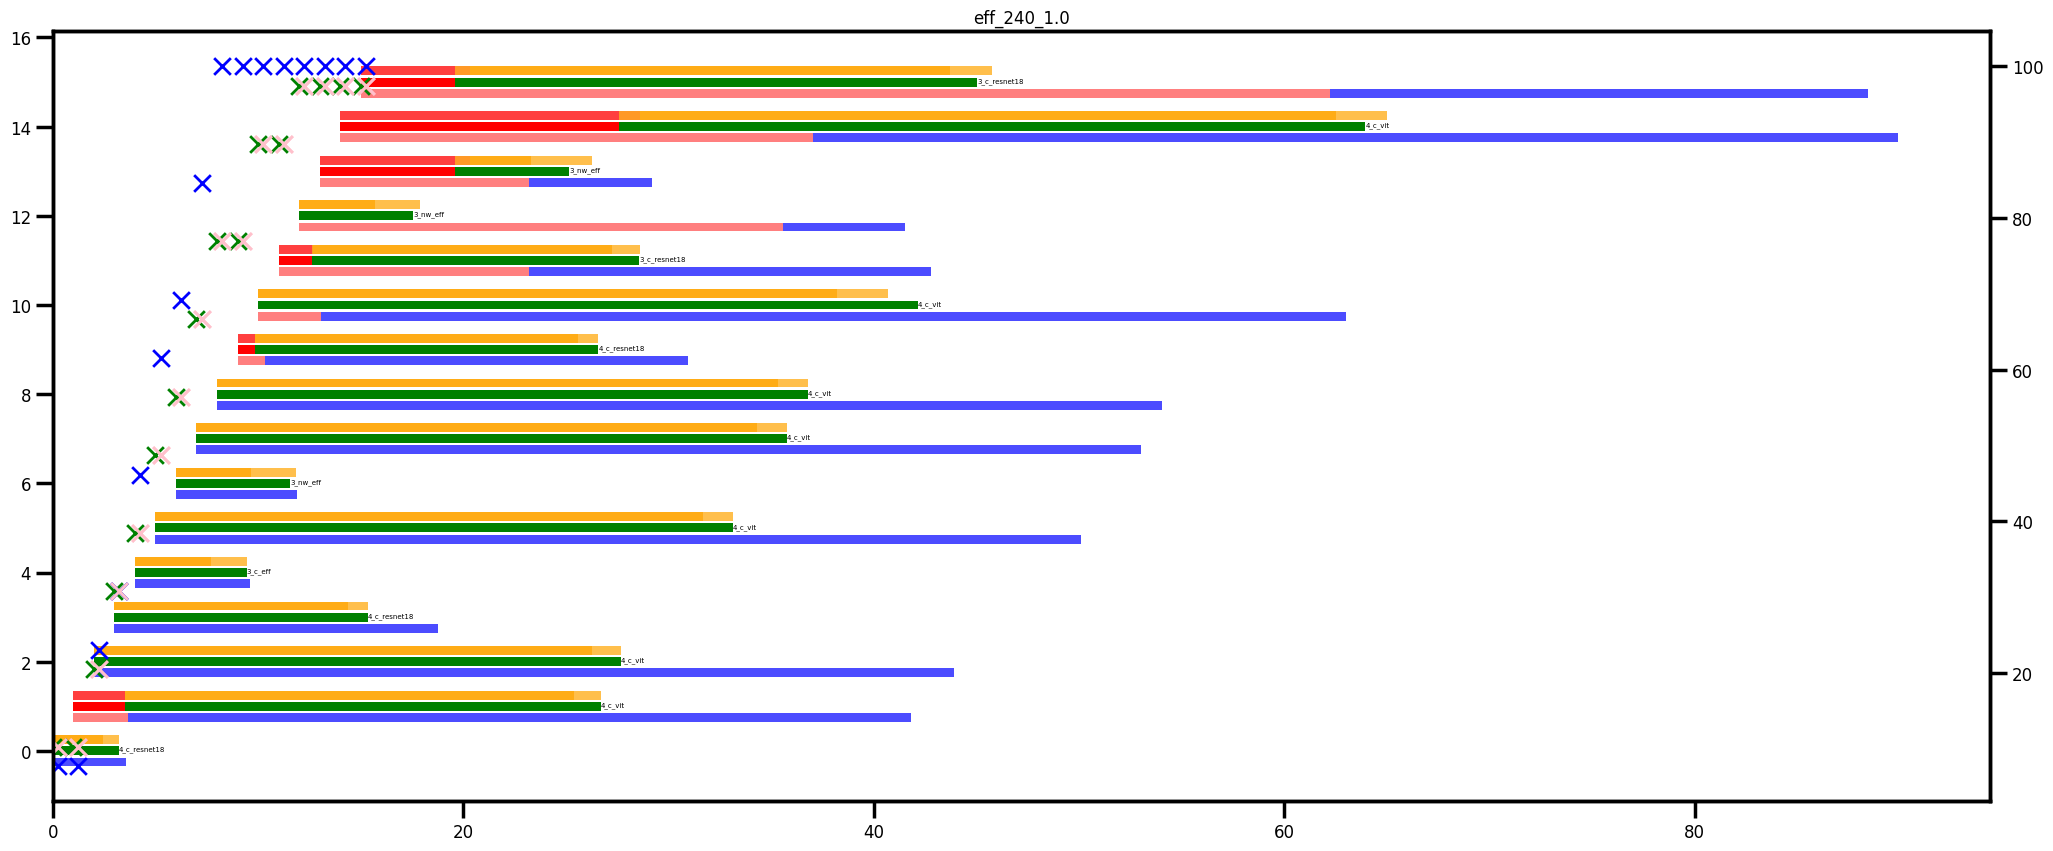

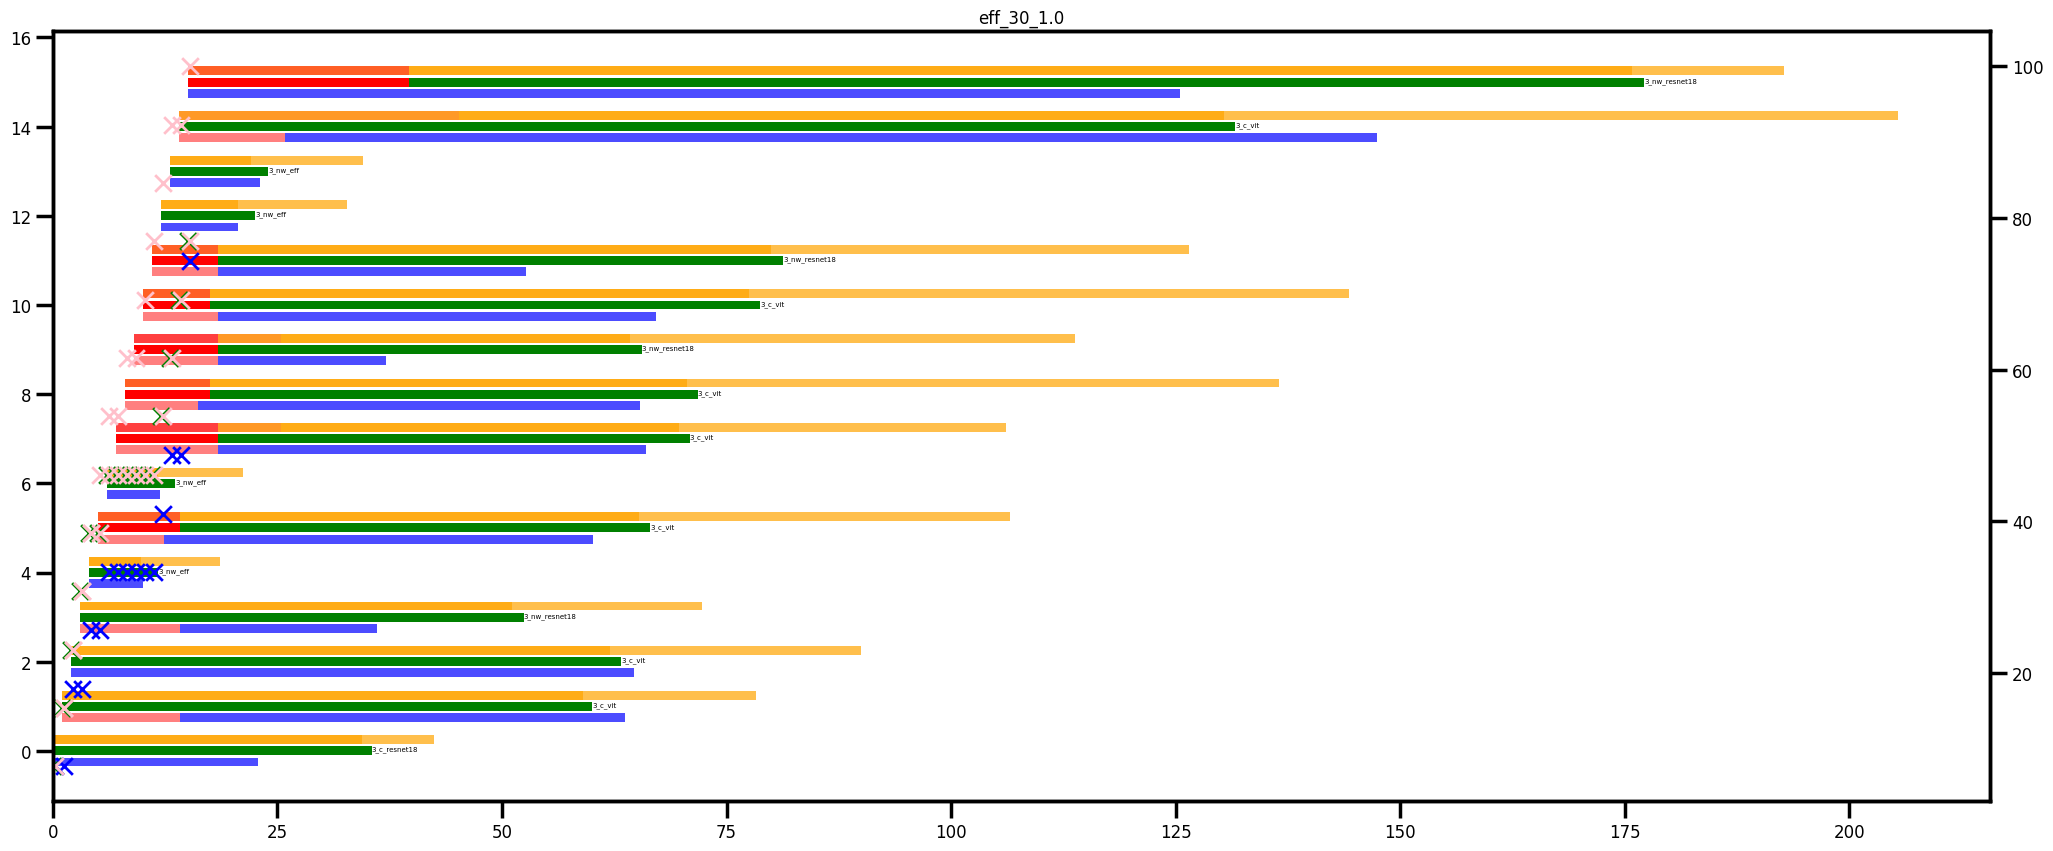

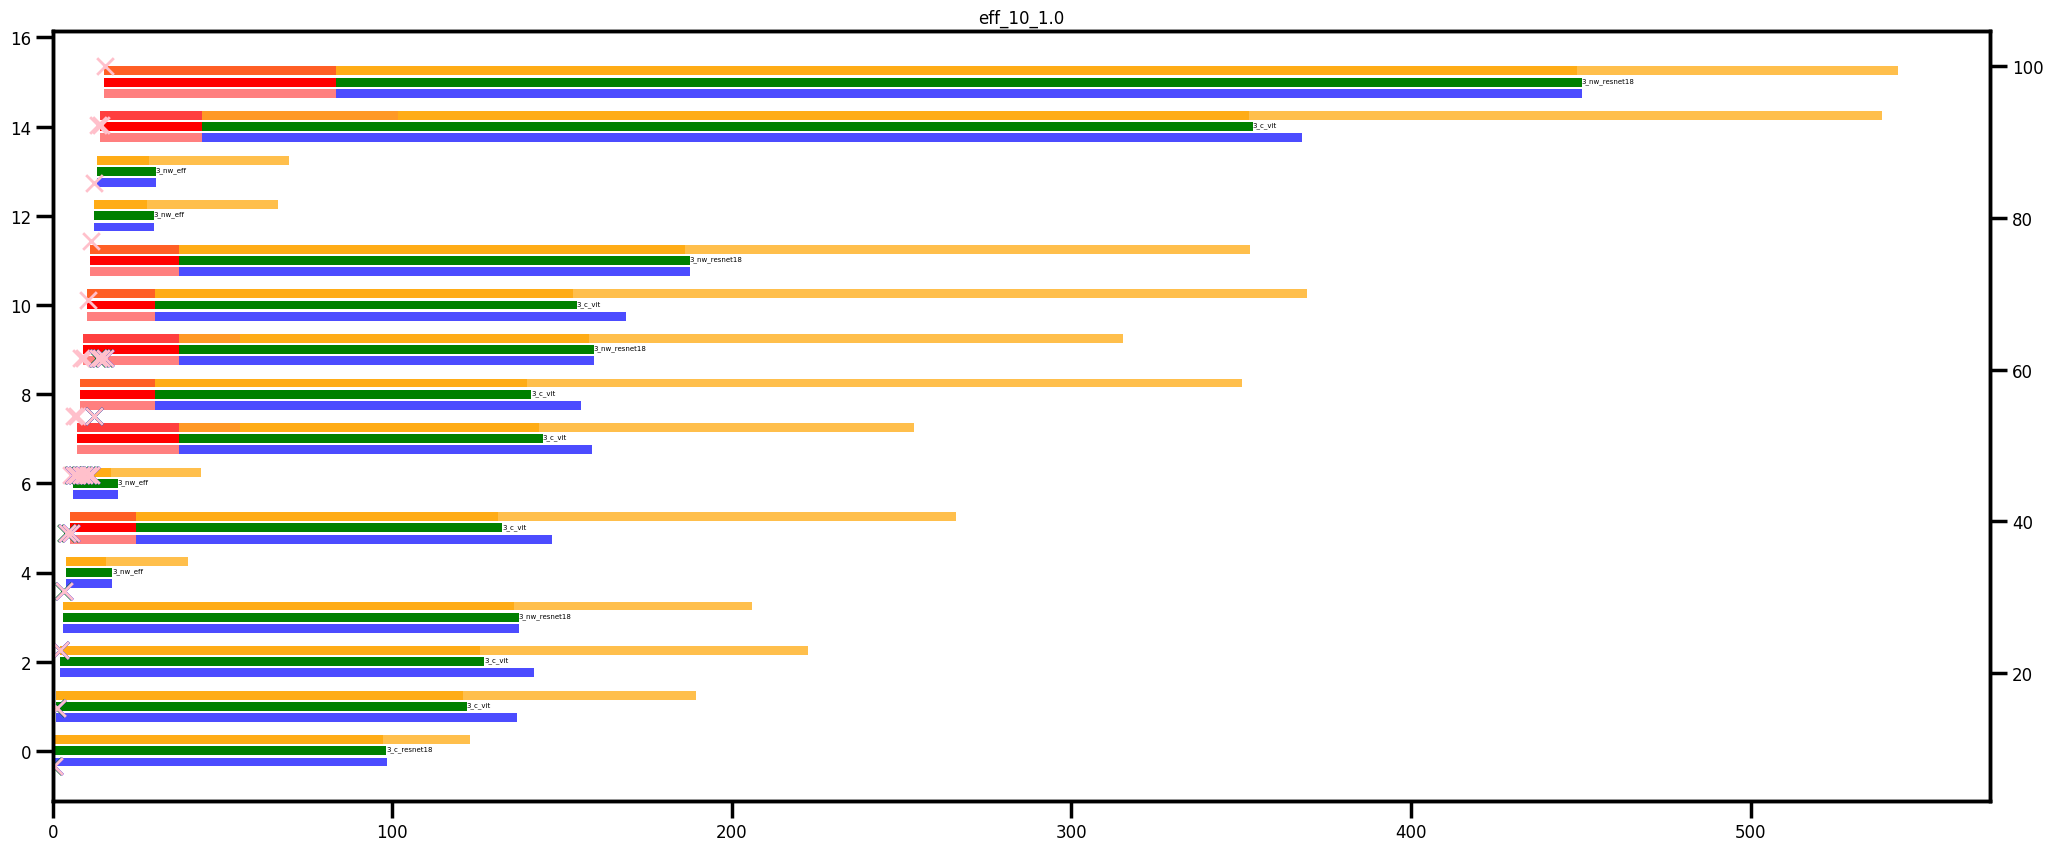

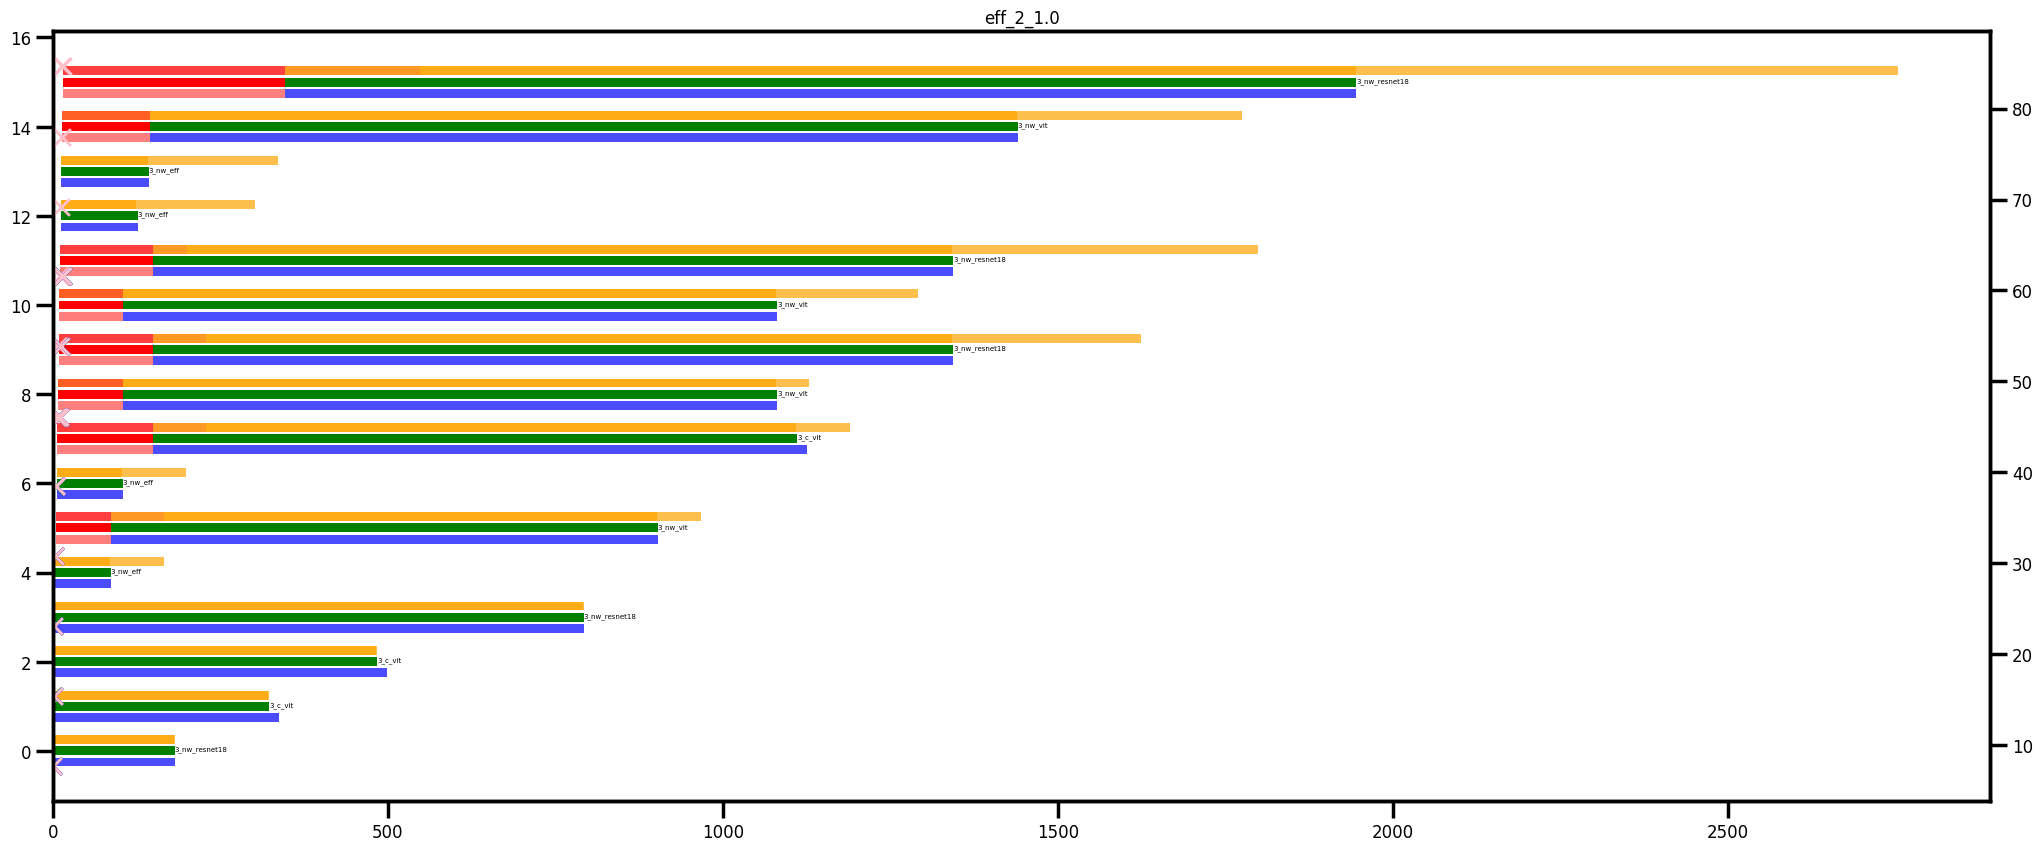

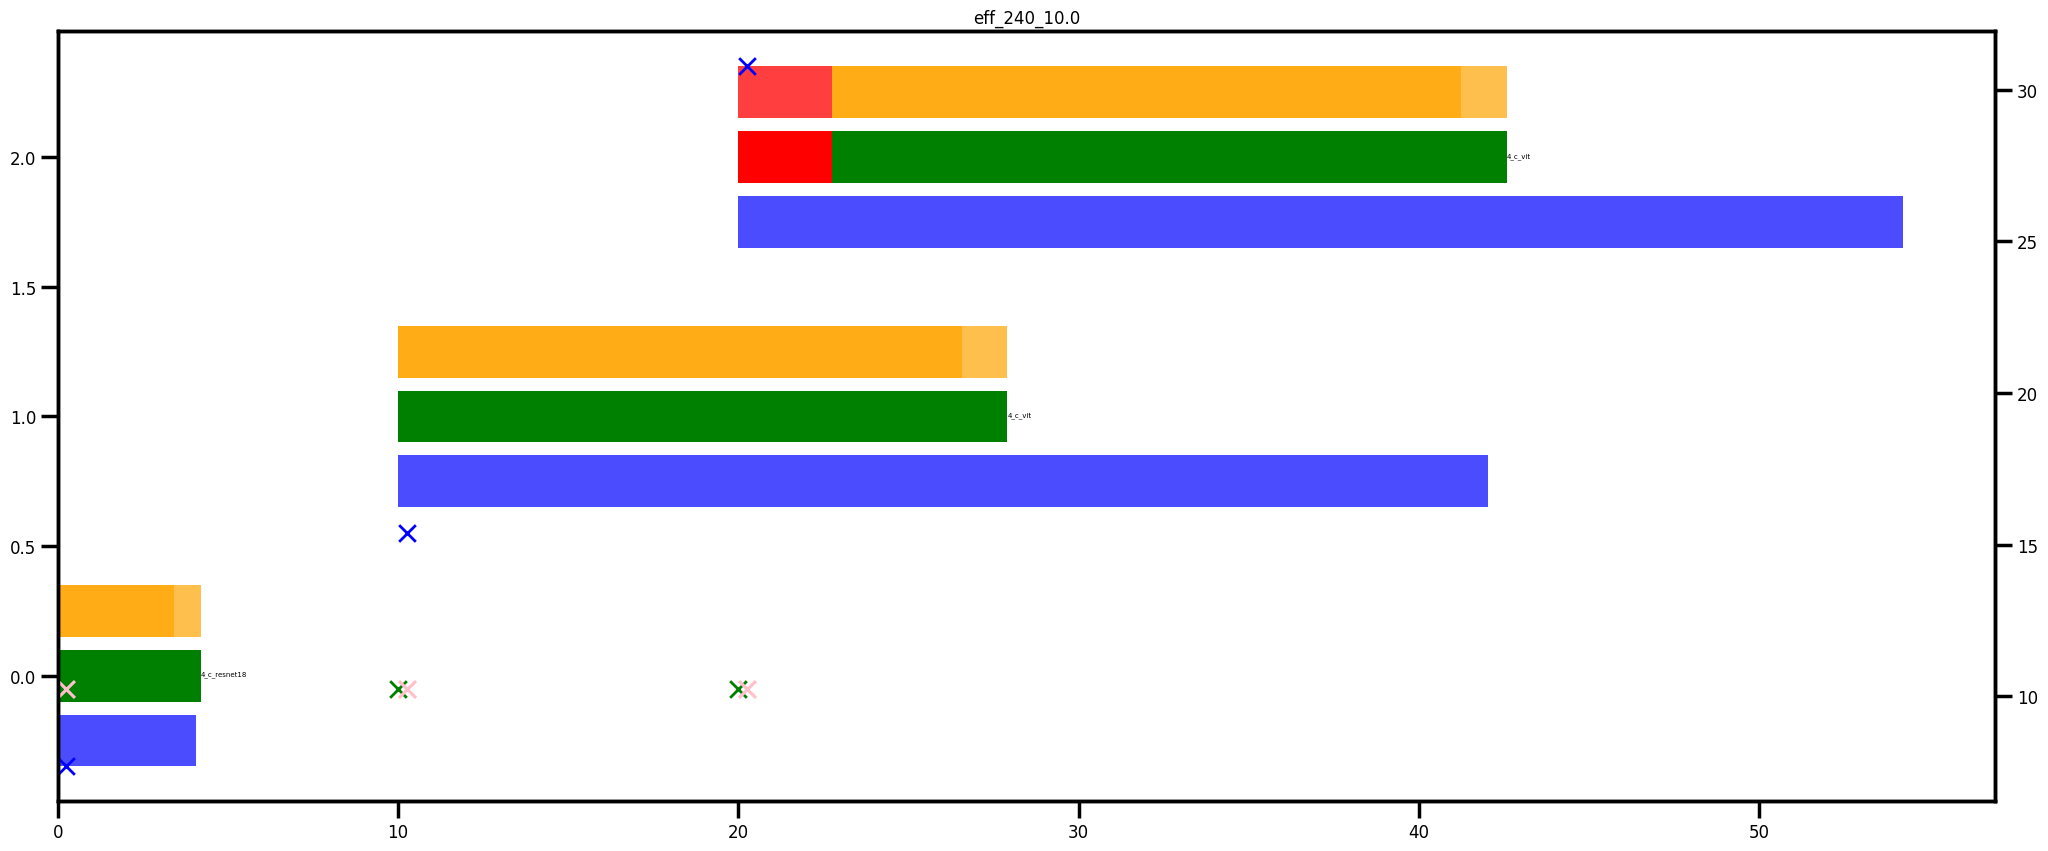

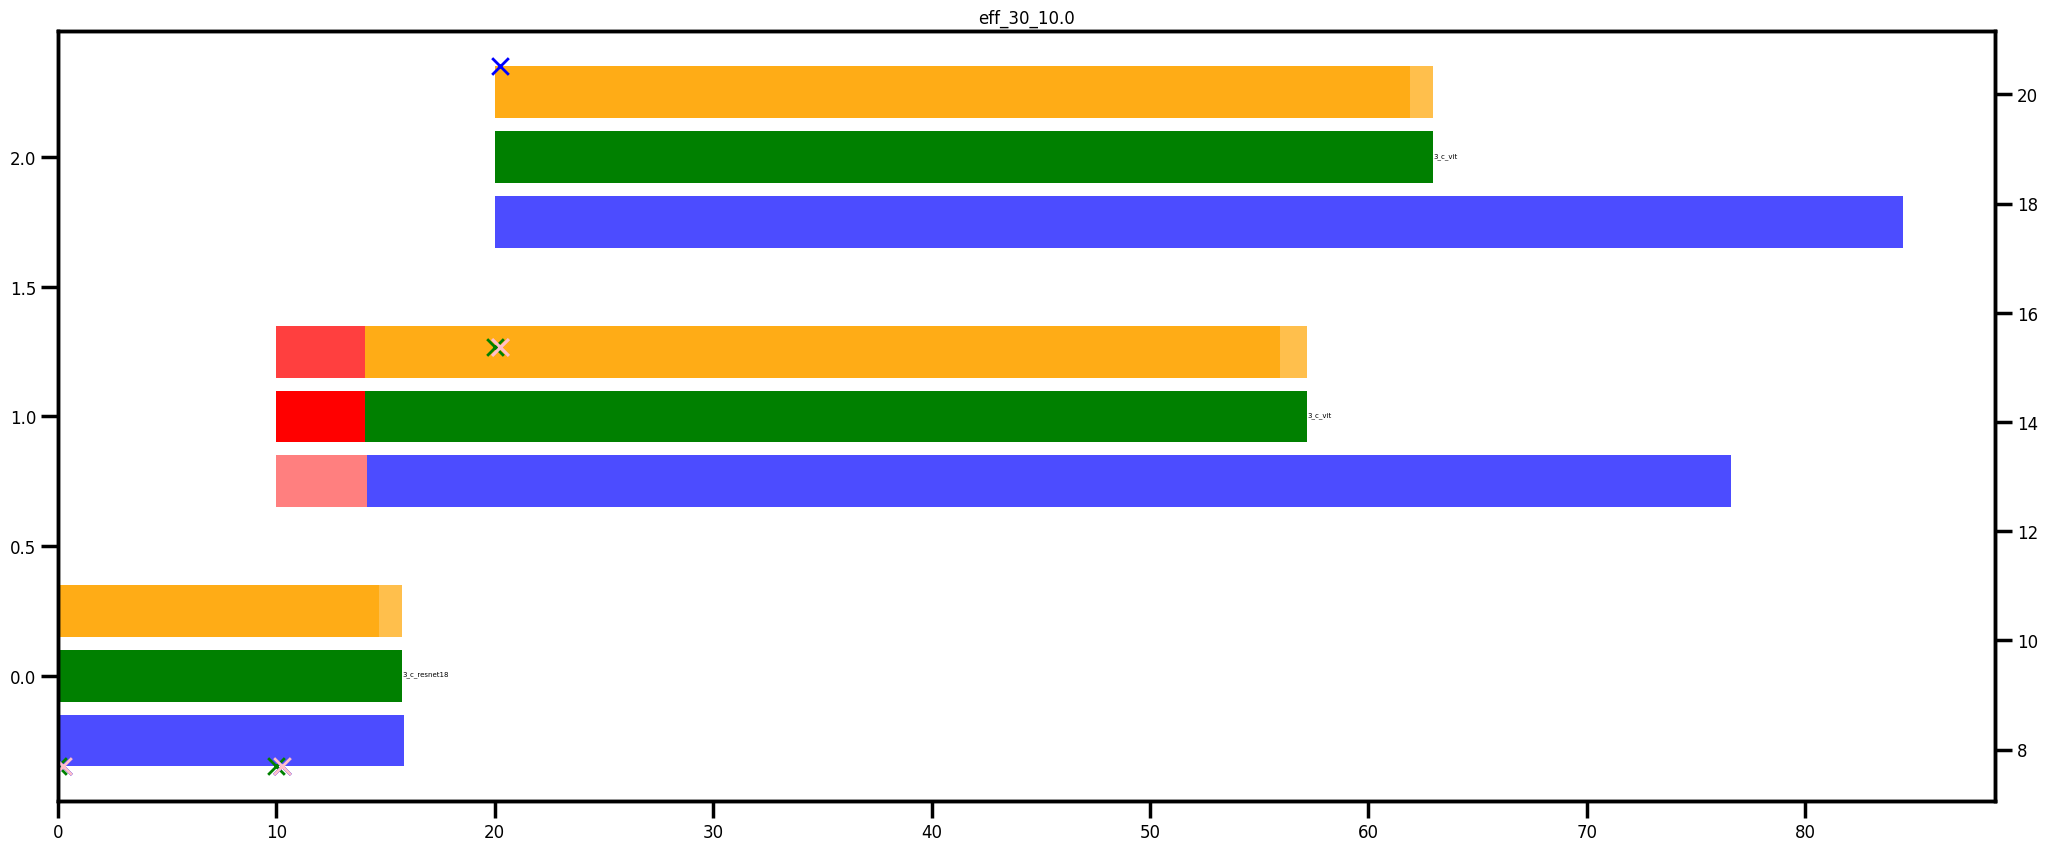

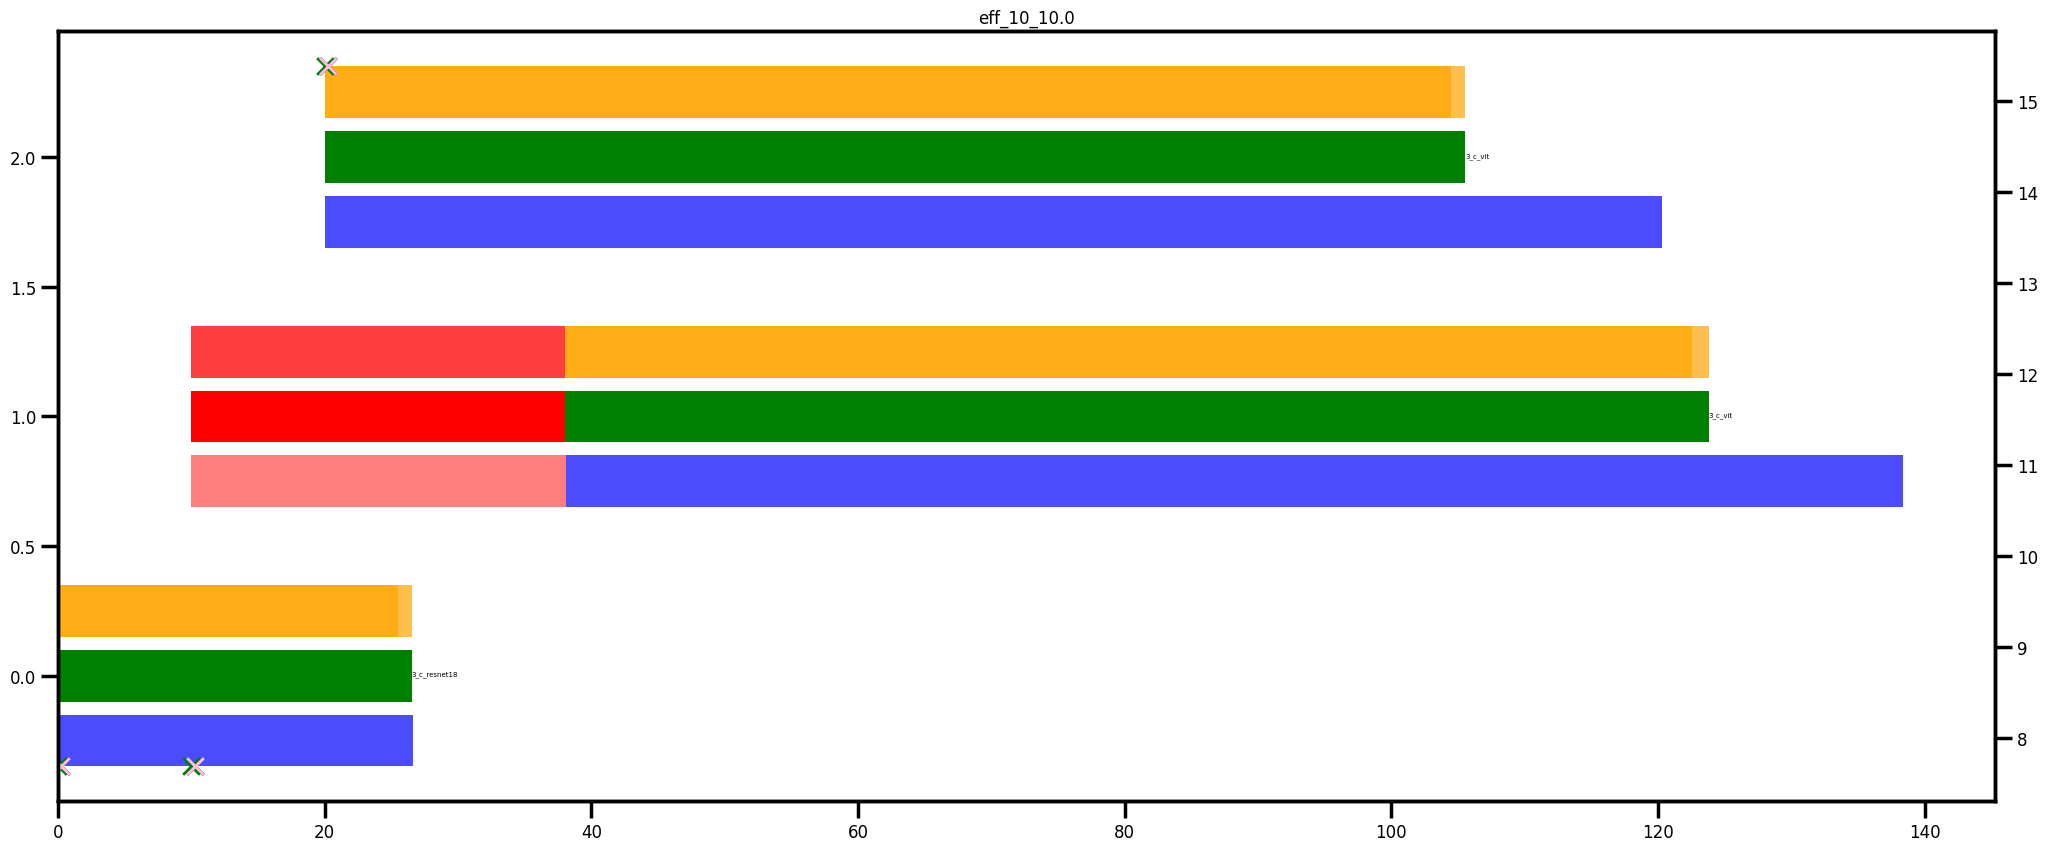

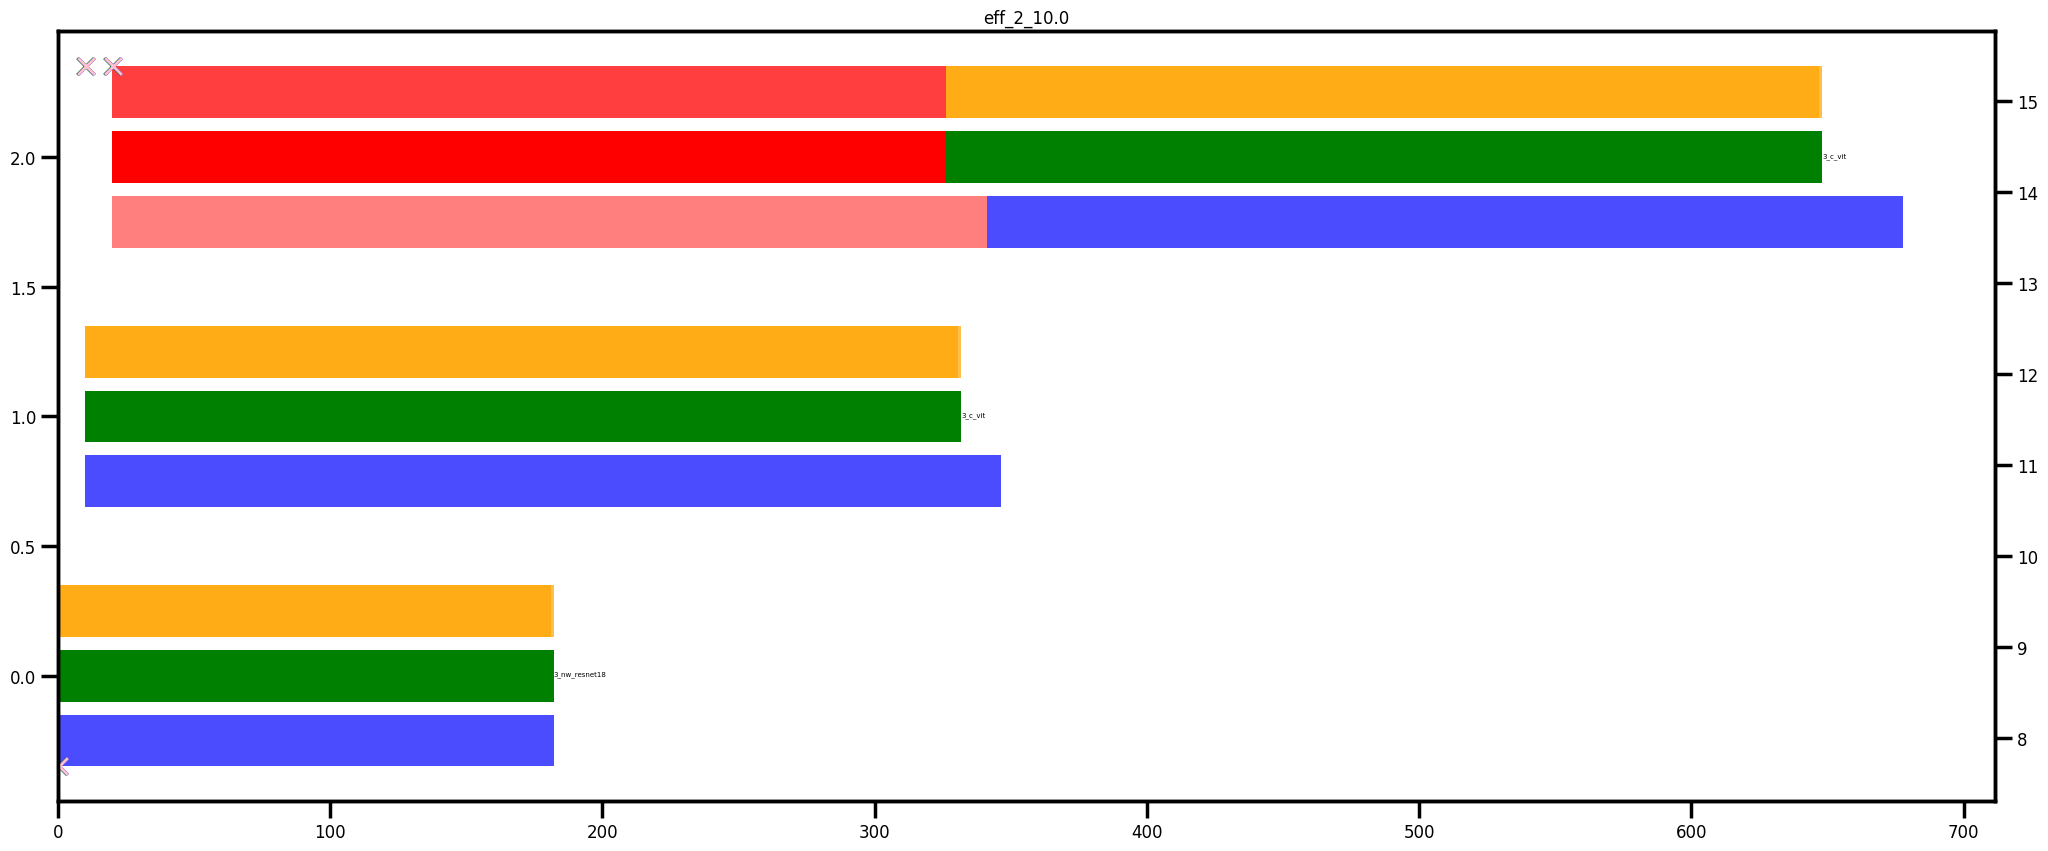

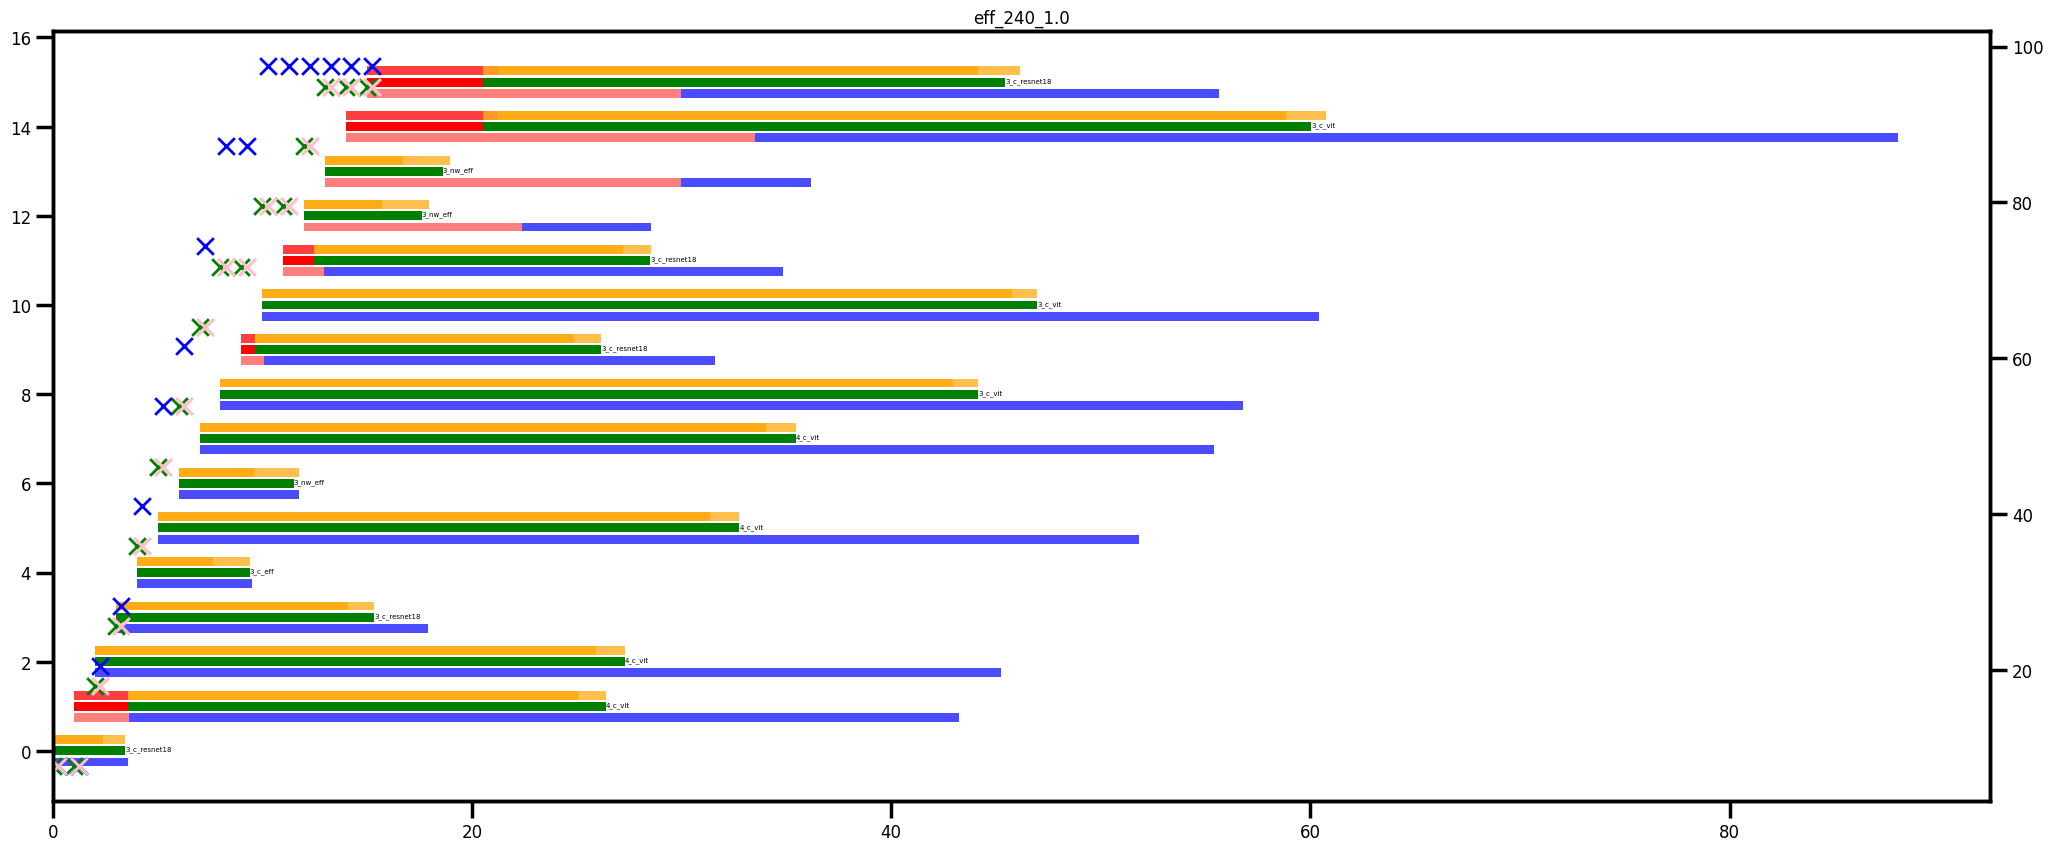

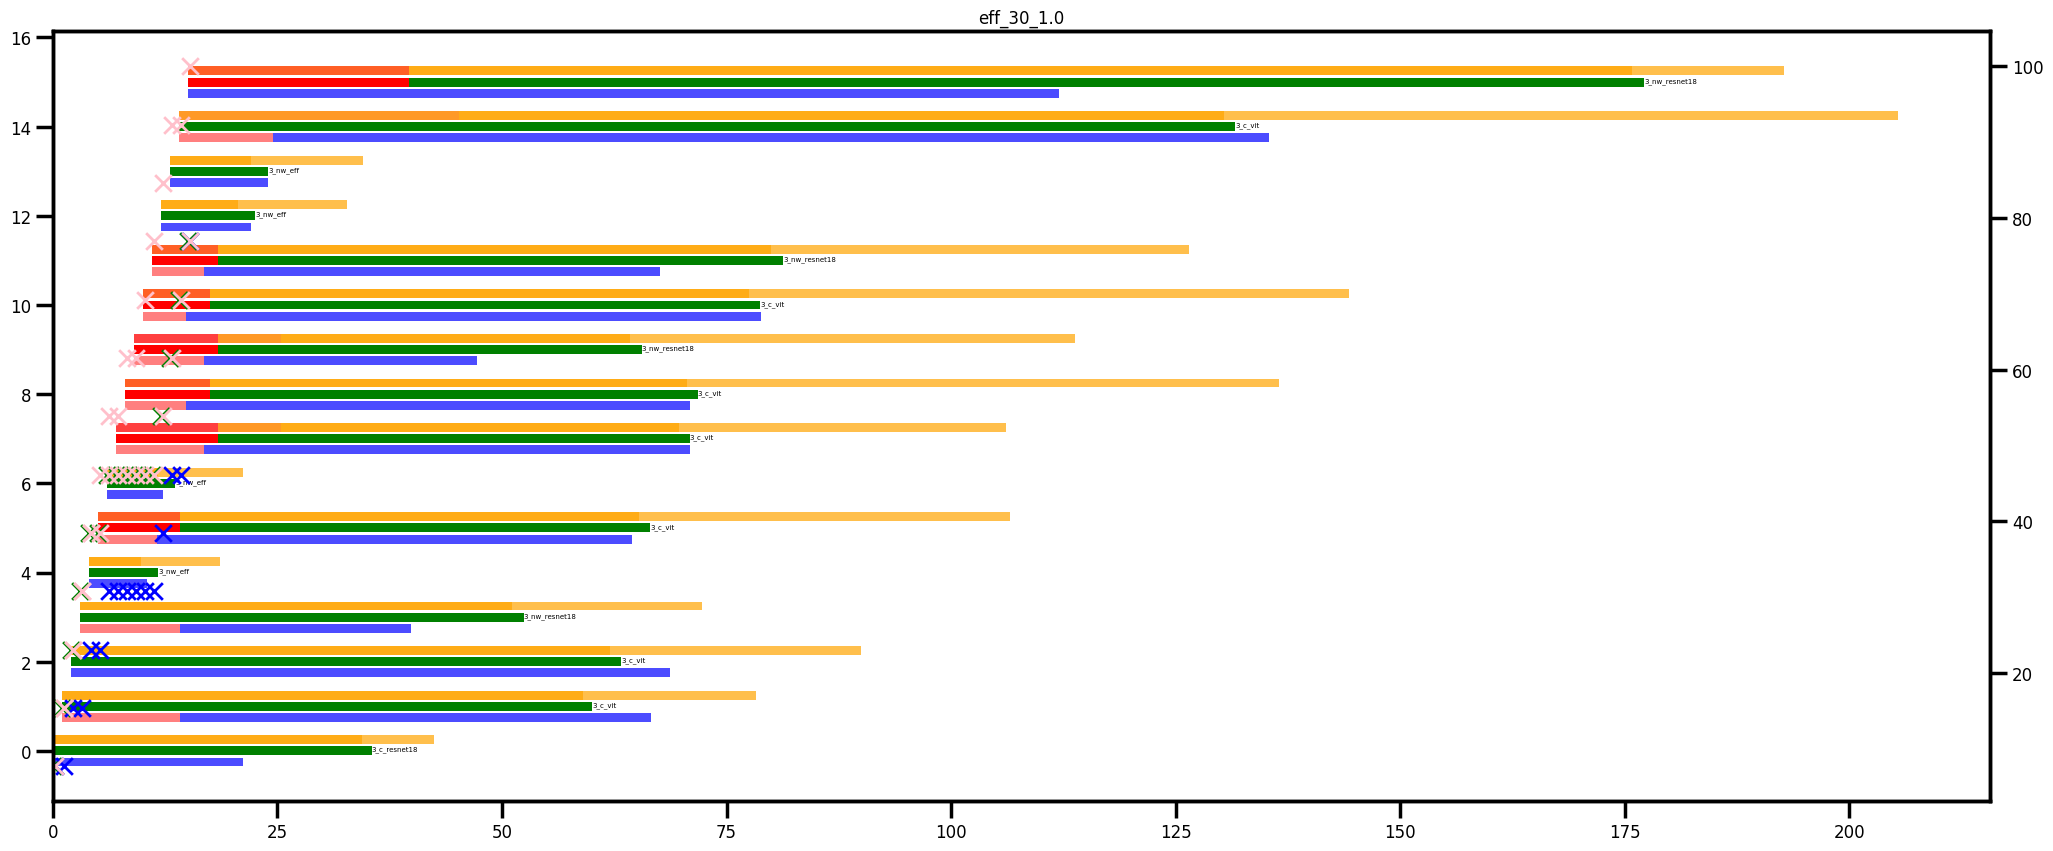

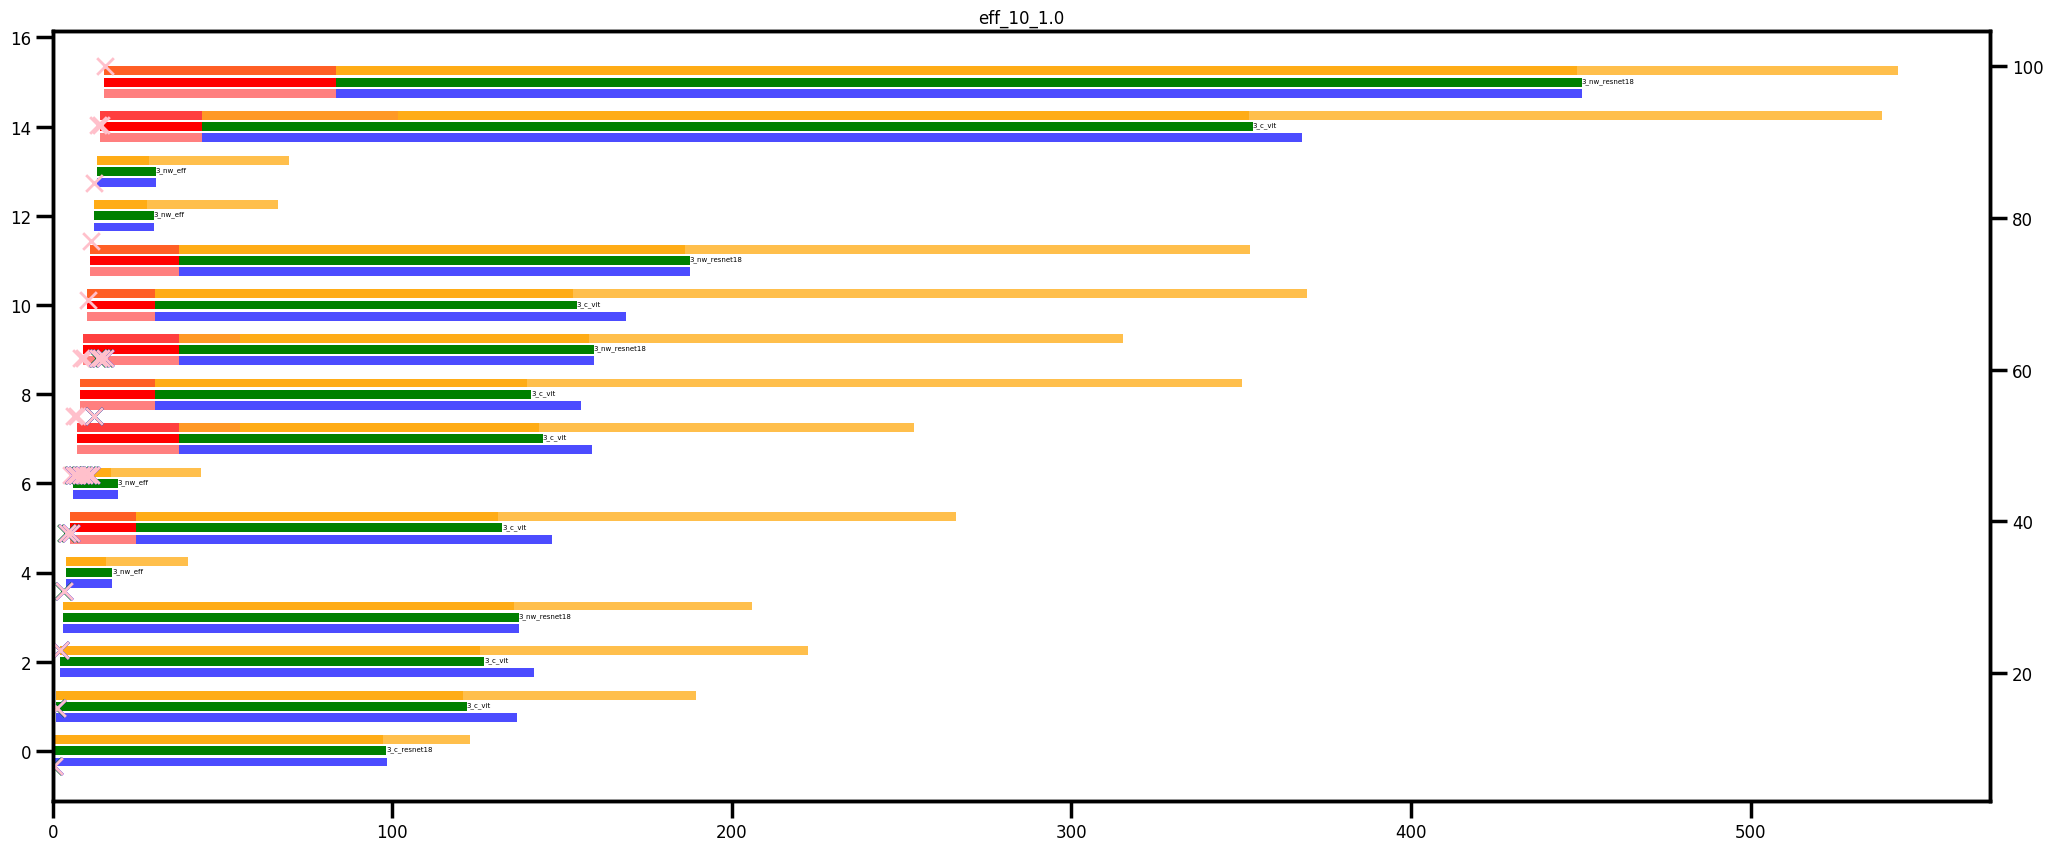

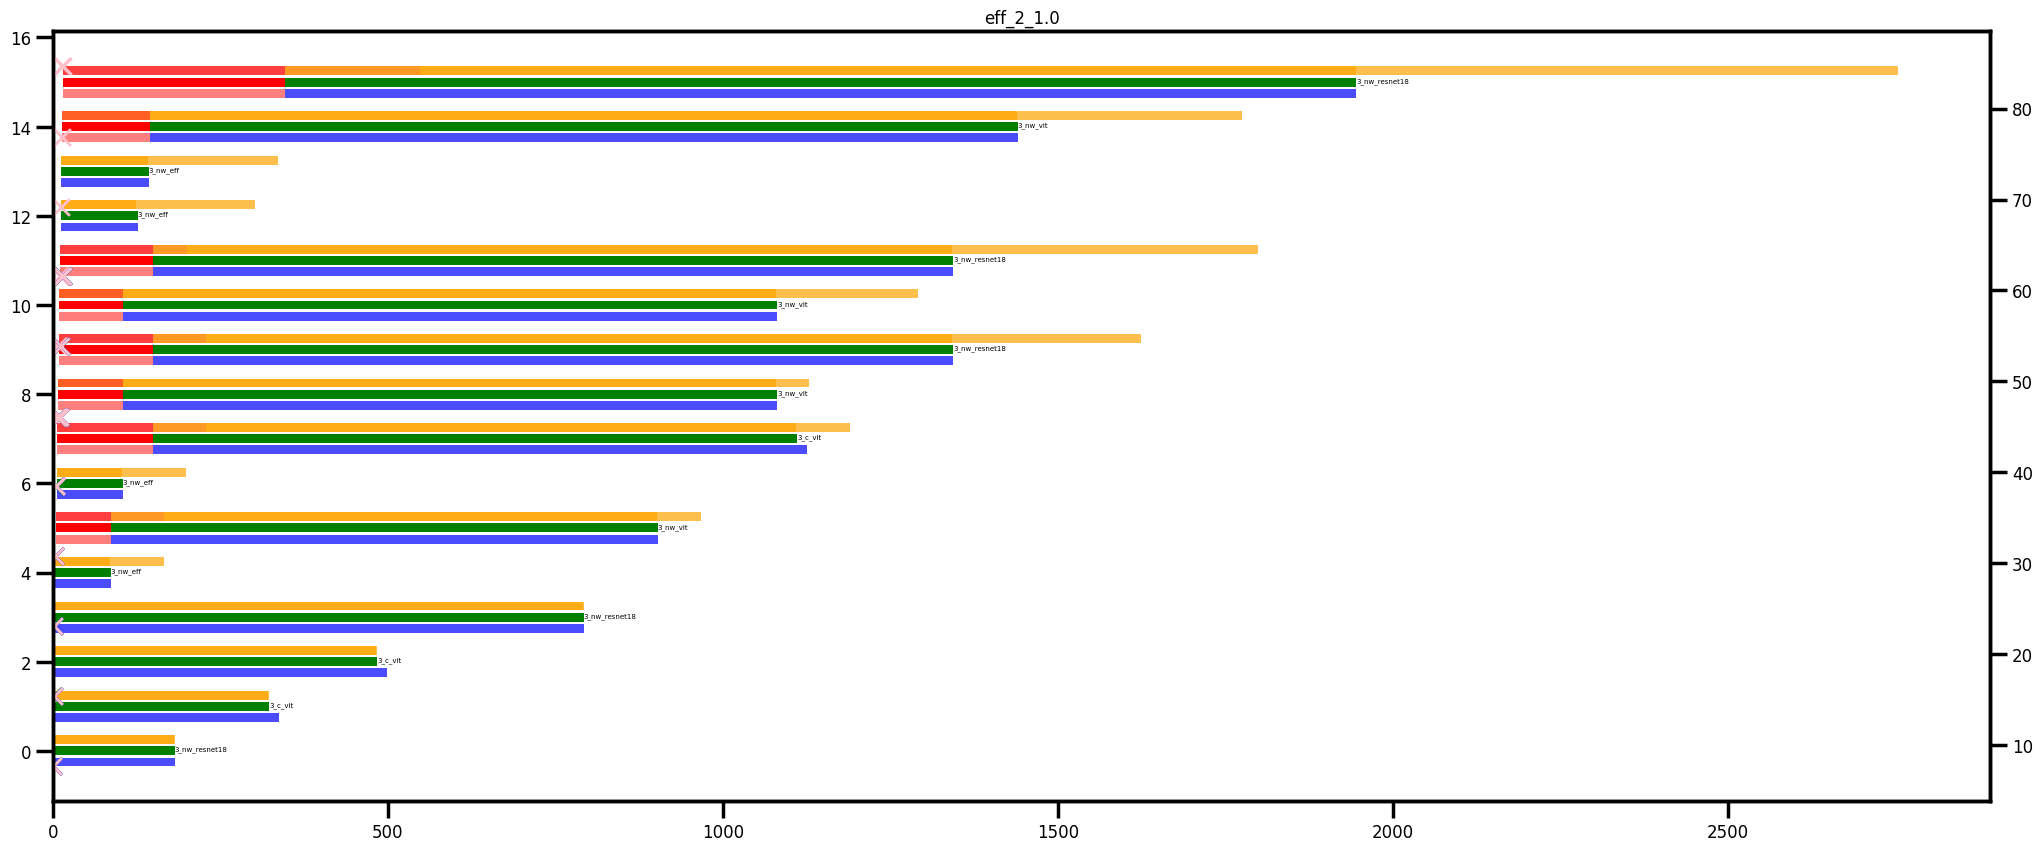

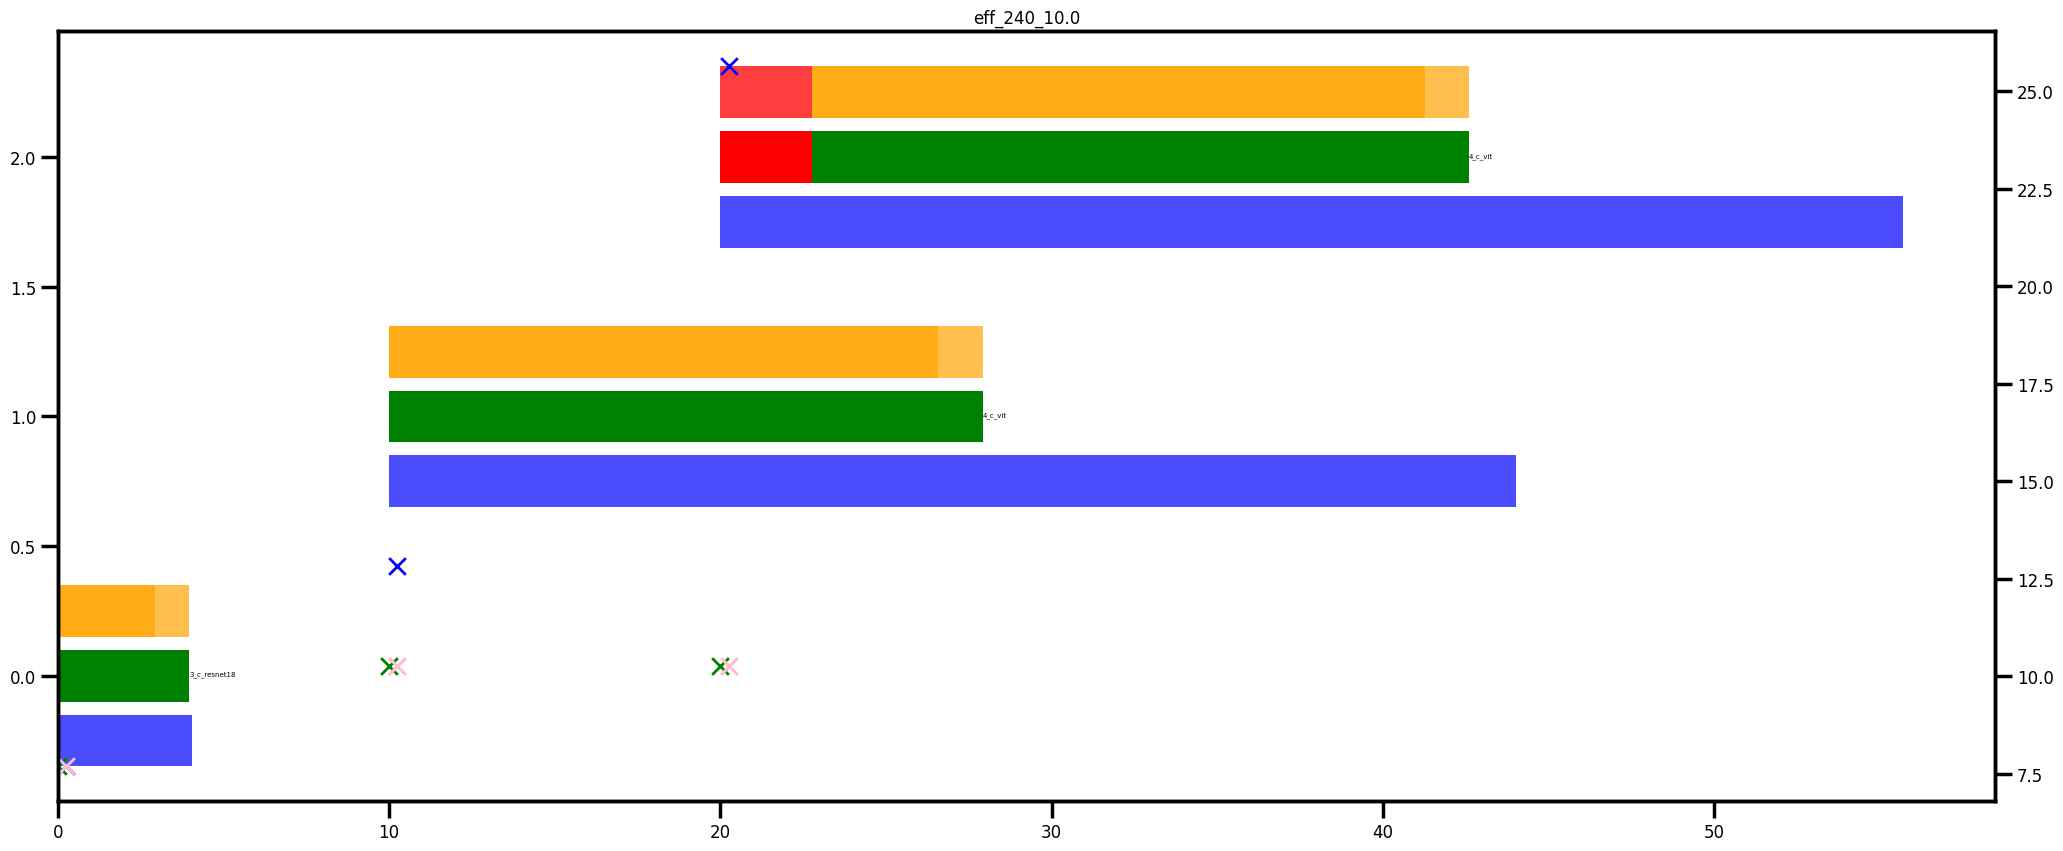

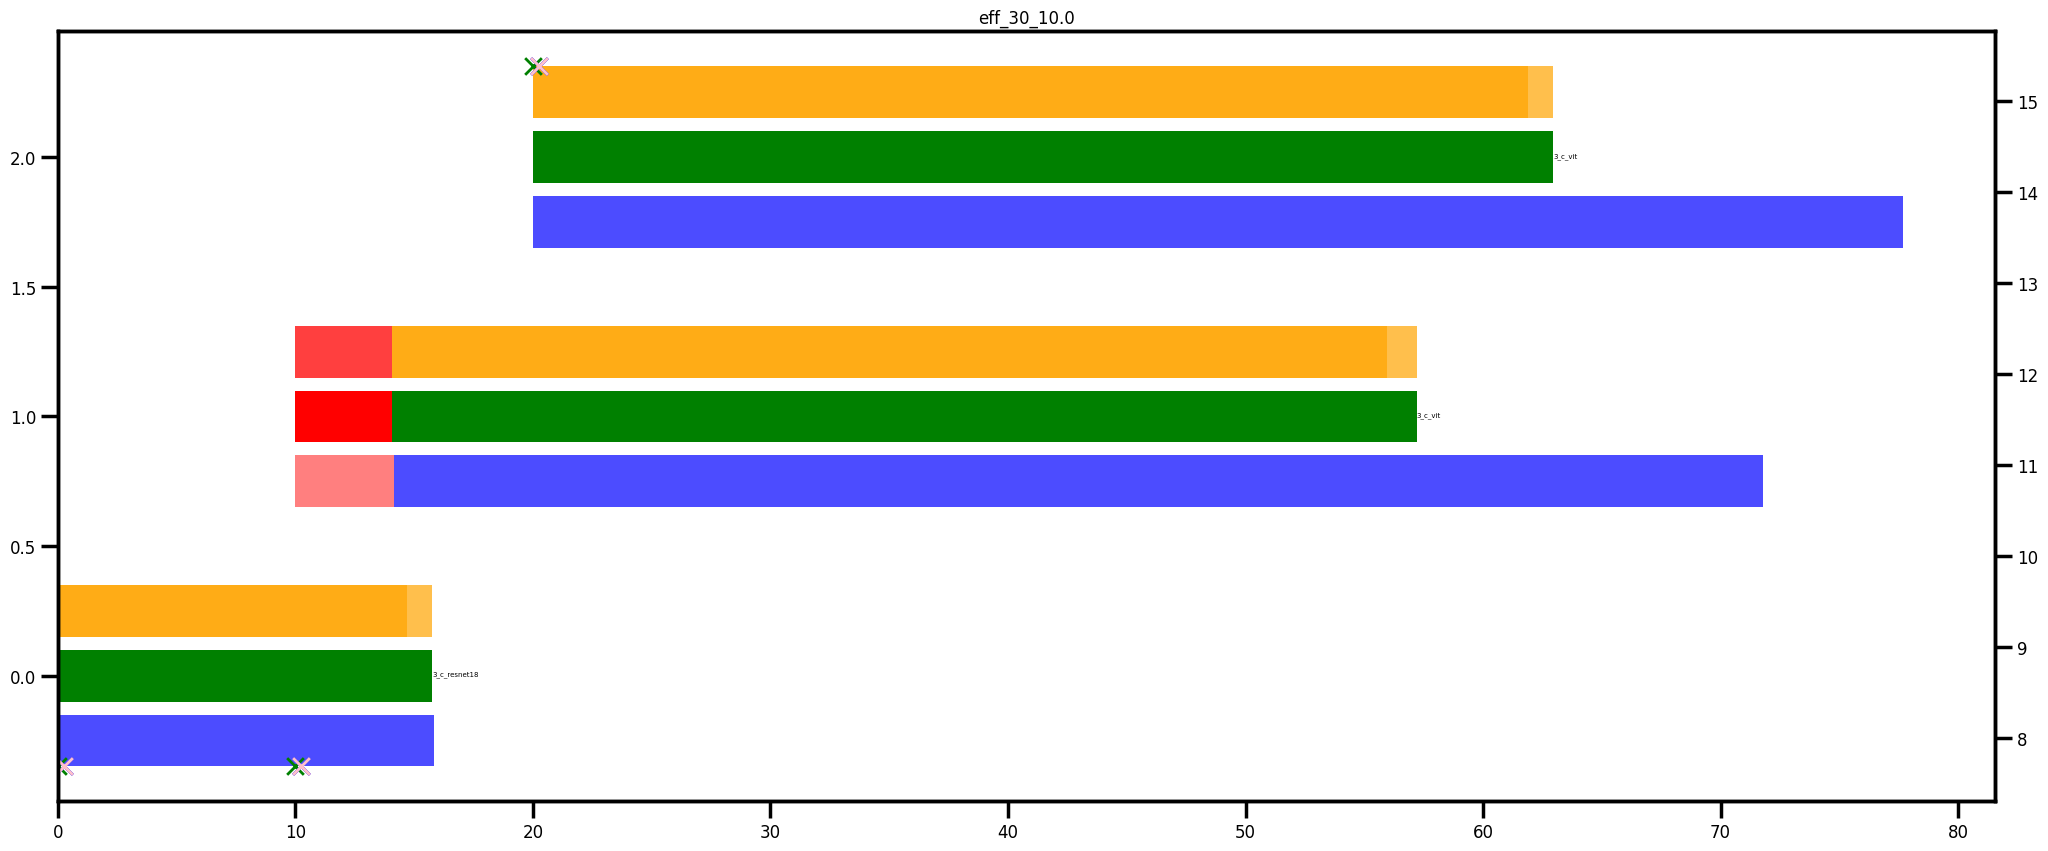

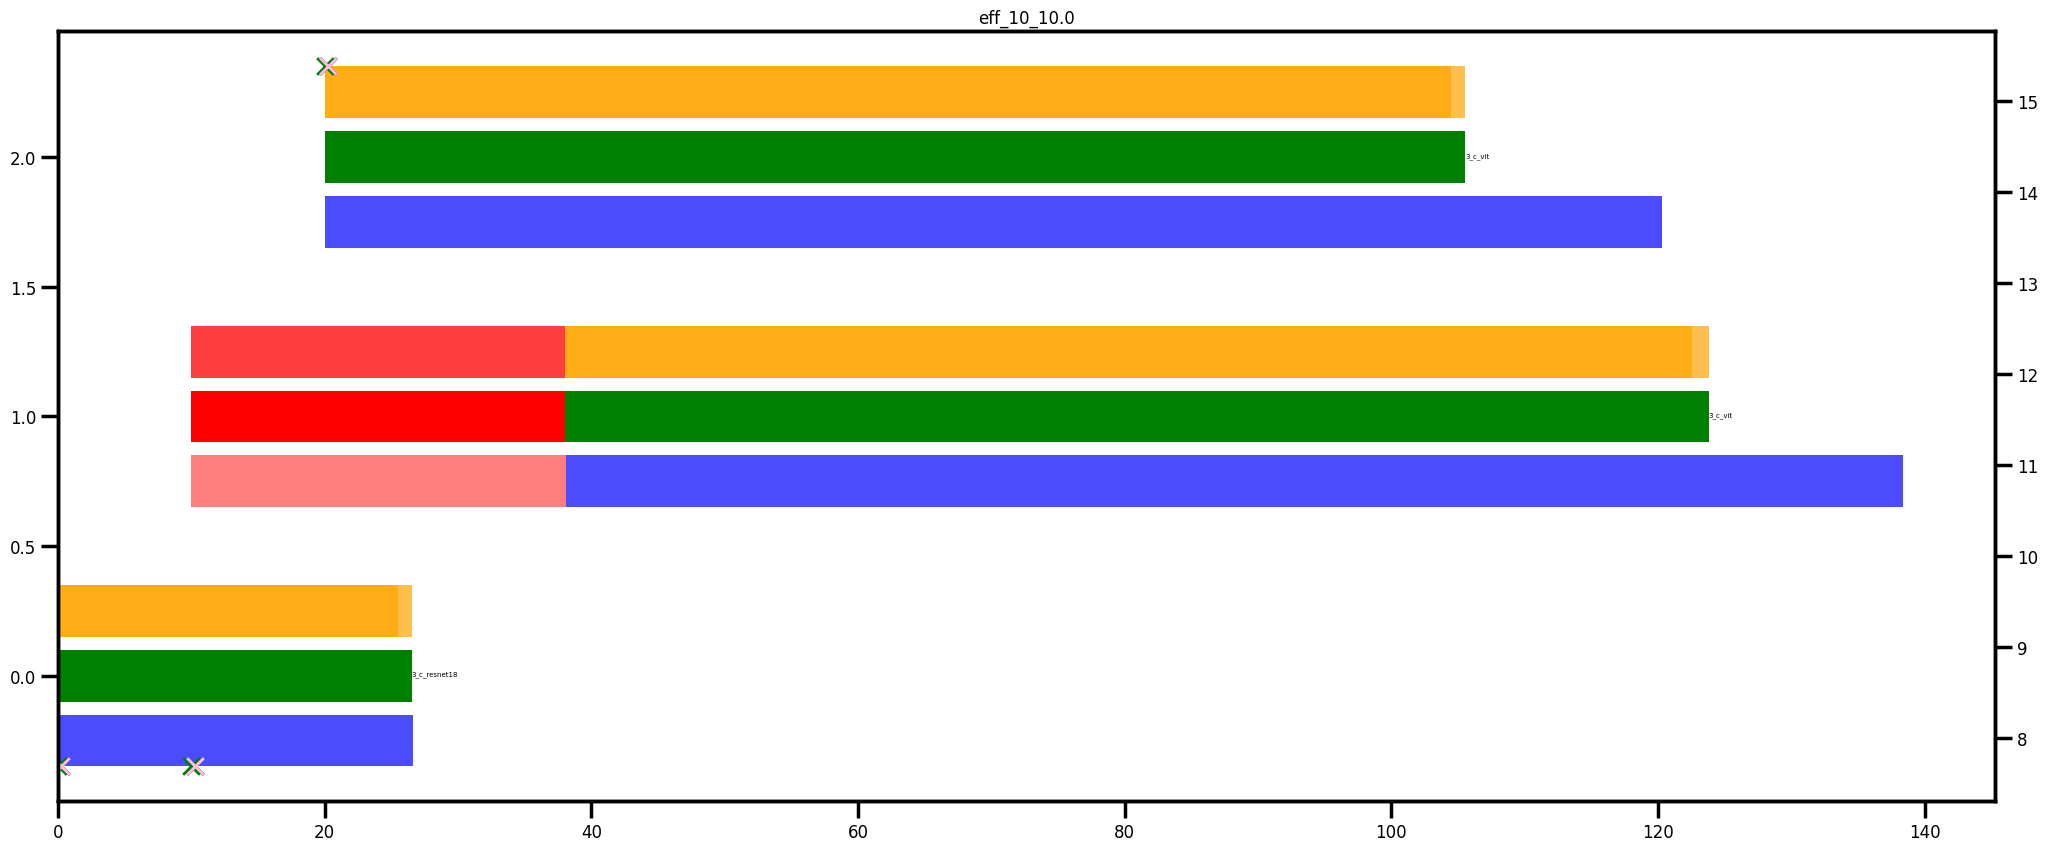

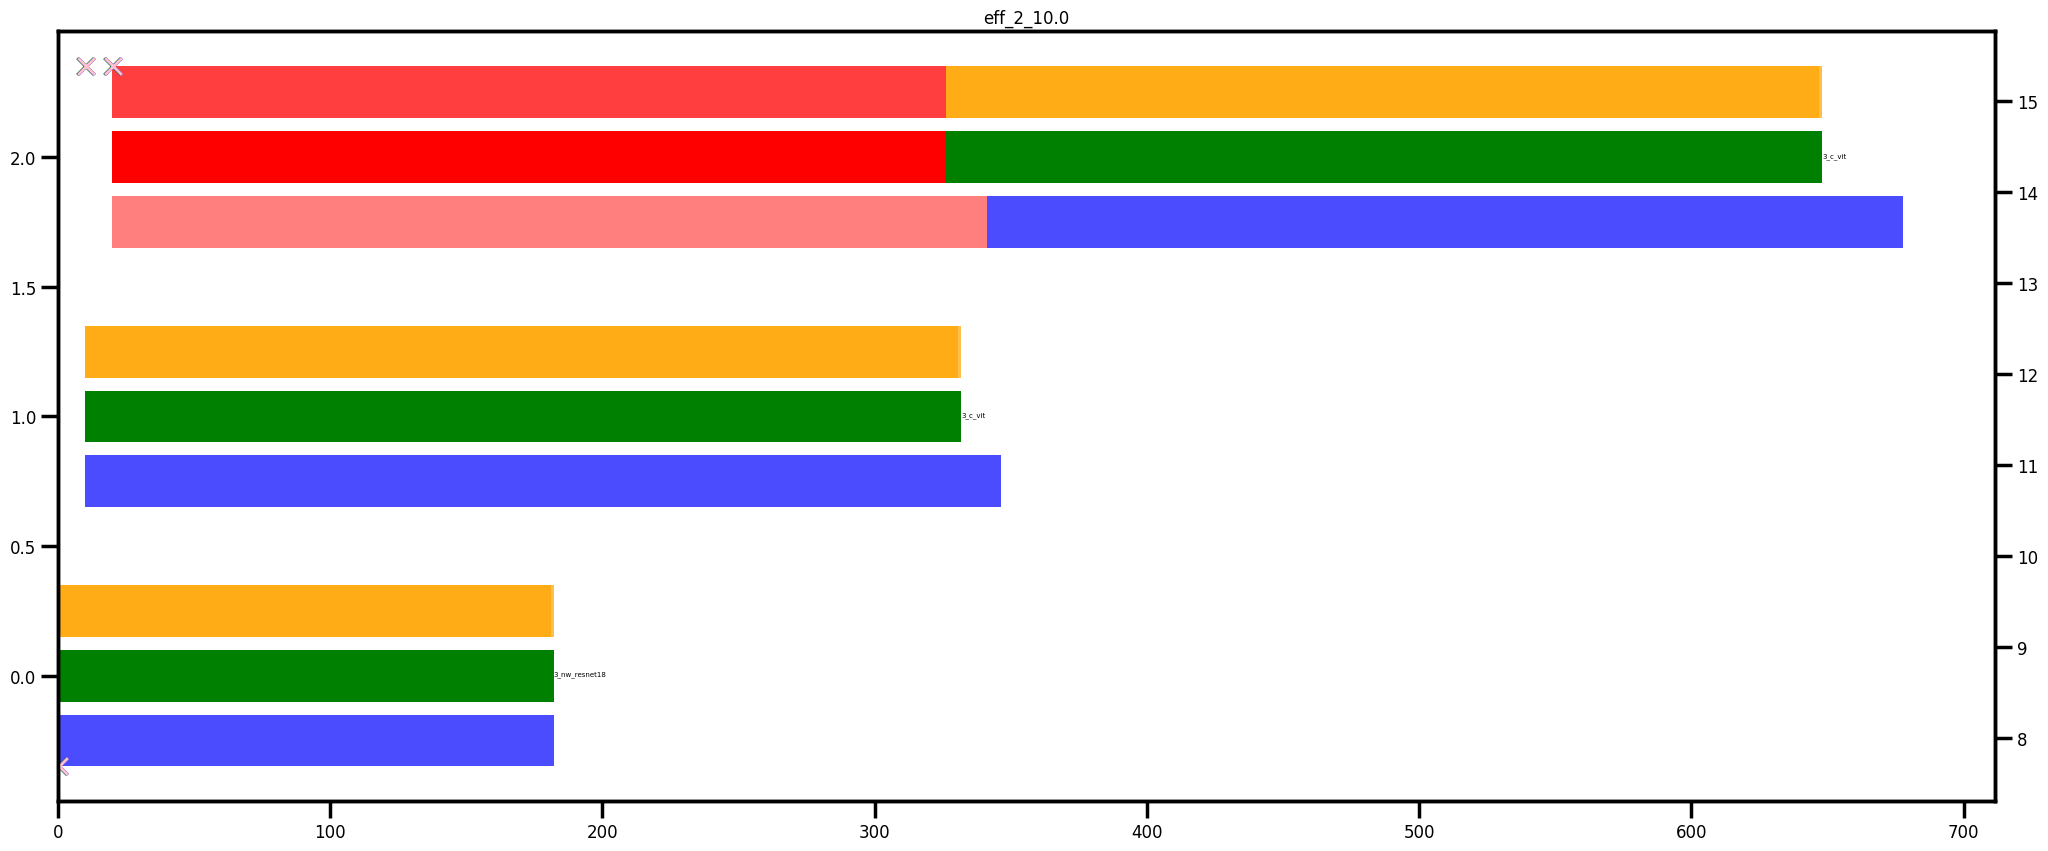

In [440]:
# for iat in [0.1, 0.5, 1.0, 10.0]:
# for iat in [1.0, 10.0]:
def gini_coefficient(x):
    """Compute Gini coefficient of array of values"""
    diffsum = 0
    for i, xi in enumerate(x[:-1], 1):
        diffsum += np.sum(np.abs(xi - x[i:]))
    return diffsum / (len(x)**2 * np.mean(x))

data_collector={}
sub="bramble-2-4"
inp=10
pred_schedule = []
real_schedule = []
# for cur_model in ["resnet18", "vit", "eff"]:
# for cur_model in ["resnet18", "vit", "eff"]:
for cur_model in ["eff"]:
    no_lee_len = 0
    for lee in [0,1]:
    # for lee in [0]:
        # for iat in [0.5, 1.0, 10.0]:
        # for iat in [ 1.0]:
        for iat in [1.0, 10.0]:
        # for iat in [0.5]:
            for bw in [240, 30, 10, 2]:
            # for bw in [240]:
            # for bw in [2]:
                pred_y=[]
                real_y=[]

                # cur_model="resnet18"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.uniform.duty_cycle.mix.{'no_leeway' if lee==0 else 'leeway'}"
                filename = f"/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.azure.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.azure.duty_cycle.mix.{'no_leeway' if lee==0 else 'leeway'}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.uniform.duty_cycle.mix.{'no_leeway' if lee==0 else 'leeway'}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.azure.duty_cycle.mix.{'no_leeway' if lee==0 else 'leeway'}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.azure.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.azure.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.azure.duty_cycle"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.001.uniform.debug"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.1.uniform.debug"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.10.0.1.uniform.debug"

                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.eff.10.1.0.only_comm.uniform.duty_cycle"
                # filename=f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.eff.10.1.0.uniform.duty_cycle"

                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.mixed.0.1.uniform.debug"

                # filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.10.0.01"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.001.azure"
                ts, overhead, bs, bn, world, added_time, ty, _, devs_used, bw_used, models_used = simulation_reader(filename, skip_ts=False, agg_flag="exp")
                fig, bar_axs = plt.subplots(figsize=(25,10))
                bar_axs.set_title(f"{cur_model}_{bw}_{iat}")
                if len(models_used)==0:
                    models_used= {k:cur_model for k in overhead}
                arr_times = []
                dev_to_s_map={}
                n_dev_to_s_map={}
                real_ts={}
                n_real_ts={}
                run_ts = {k:ts[k]-sum(added_time[k]) for k in ts}
                pred_y = [ts[k]-sum(added_time[k]) for k in ts]
                for j in ts:
                    ind = int(j.split("j")[-1])

                    if j not in real_ts:
                        real_ts[j]=0
                        n_real_ts[j]=0
                    # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
                    # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
                    # real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max_2_5.csv", sub, cur_model, world[j], overhead[j]-world[j],
                    # bs[j], bn[j], bw=10, ty=ty[j], col_flag="median", agg_flag="mean")
                    real_ts[j], std_val, pred_rt, n_real_ts[j], worst_dev_util, naive_worst_dev_util = best_fit_reader("best_fit_max_2_6.csv", sub, models_used[j], world[j], overhead[j]-world[j],
                    bs[j], bn[j], bw=bw_used[j] if bw!=2 else 2, ty=ty[j], col_flag="median", agg_flag="max", nw_var=True if bw==2 else False)
                    # real_ts[j], std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_max_2_6.csv", sub, models_used[j], world[j], overhead[j]-world[j],
                    # bs[j], bn[j], bw=bw_used[j], ty=ty[j], col_flag="median", agg_flag="min")#, nw_var=True )
                    dev_str = devs_used[j]
                    # print(devs_used)
                    for dev in dev_str.split("."):
                        if dev not in dev_to_s_map:
                            dev_to_s_map[dev]=[worst_dev_util]
                        else:
                            dev_to_s_map[dev].append(worst_dev_util)
                    for dev in dev_str.split("."):
                        if dev not in n_dev_to_s_map:
                            n_dev_to_s_map[dev]=[naive_worst_dev_util]
                        else:
                            n_dev_to_s_map[dev].append(naive_worst_dev_util)
                    # print(dev_to_s_map)
                        
                    
                    # print(bs[j], bn[j])
                    arr_t = added_time[j][0]
                    wait_t = added_time[j][1]
                    # specific_waits.append(wait_t)
                    # only_wait_ts[j] =  arr_t+wait_t
                    # real_ts[j] = arr_t+wait_t+real_ts[j] 
                    
                    #uncomment to plot
                    bar_axs.barh(ind, wait_t, left=arr_t, color="red", height=0.2 )
                    # bar_axs.barh(ind, ts[j]-sum(added_time[j]), color="green", left=(sum(added_time[j])), height=0.2)
                    bar_axs.barh(ind, real_ts[j], color="green", left=(sum(added_time[j])), height=0.2)
                    
                    real_y.append(real_ts[j])
                    # real_ts[j]+=added_time[j][1]#sum(added_time[j]) #compensate for wait time and accurately calculate the time per device!
                    # bar_axs.barh(ind, pred_rt, color="green", left=(sum(added_time[j])), height=0.2)
                    # bar_axs.text(ts[j], ind, f'{world[j]}_{ty[j]}')
                    bar_axs.text(real_ts[j]+sum(added_time[j]), ind, f'{world[j]}_{ty[j]}_{models_used[j]}')
                    # bar_axs.text(ts[j], ind, f'{world[j]}_{ty[j]}_{models_used[j]}')
                # print(f"{iat} arrival times with bw {bw} and model {cur_model}",
                # f"gives rmse: { np.sqrt( np.mean([(pred_y[i]-real_y[i])**2 for i in range(len(pred_y))]) ) }, mae: {np.mean([abs(pred_y[i]-real_y[i]) for i in range(len(pred_y))])}")
                lat = float(round(max(real_ts.values()),2))
                n_lat = float(round(max(n_real_ts.values()),2))
                # s_per_mac = float(round( sum([sum(dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0])/map_sub['bramble-2-4'],3 ))
                # min_s_per_mac = float(round( min([sum(dev_to_s_map[dev])/lat for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]+[np.inf]),3 ))
                # max_s_per_mac = float(round( max([sum(dev_to_s_map[dev])/lat for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]+[0]),3 ))
                sum_nt,sum_t,sum_nw=0,0,0
                max_time =0 
                for dev in dev_to_s_map:
                    nt = sum([dev_to_s_map[dev][i][0] for i in range(len(dev_to_s_map[dev]))])
                    t = sum([dev_to_s_map[dev][i][1] for i in range(len(dev_to_s_map[dev]))])
                    nw = sum([dev_to_s_map[dev][i][2] for i in range(len(dev_to_s_map[dev]))])
                    sum_nt += nt
                    sum_t += t
                    sum_nw += nw
                    if max_time <= nt+t+nw:
                        max_time = nt+t+nw 

                per_mac = [1 for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]
                
                eff_eq = [float(round(sum_nt,3)), float(round(sum_t,3)), float(round(sum_nw,3)), float(round((len(per_mac)*(max_time) - (sum_nt+sum_t+sum_nw)),3)), len(per_mac)]

                n_per_mac = [sum(n_dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]
                n_eff_eq = [float(round(sum(n_per_mac),3)), float(round((len(n_per_mac)*(max(n_per_mac)) - sum(n_per_mac)),3)), len(n_per_mac)]
                # repeated_times = len(per_mac)
                # total_times = map_sub["bramble-2-4"]
                # if len(per_mac) < map_sub["bramble-2-4"]:
                #         per_mac = np.array([sum(per_mac)/(map_sub["bramble-2-4"]*lat) for _ in per_mac])
                # if lee==0:
                #     no_lee_len=len(per_mac)
                # if len(per_mac) < no_lee_len:
                # per_mac = np.array([sum(per_mac)/(no_lee_len*lat) for _ in per_mac])
                # per_mac = np.array([sum(per_mac)/(len(per_mac)*lat) for _ in per_mac])
                # else:
                #     per_mac = np.array([_/(len(per_mac)) for _ in per_mac])
                run_real_ts = {k:real_ts[k]-added_time[k][1] for k in real_ts}
                pred_schedule.append(max(run_ts.values()))
                real_schedule.append(max(run_real_ts.values()))

                # s_per_mac = float(round( np.mean([sum(dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]),3 ))
                # print(f"greedy {cur_model} {iat} {bw} s/machine used {'w/' if lee==1 else 'w/o'} leeway: {s_per_mac}")
                th = float(round(10*len(real_ts)/max(real_ts.values()),3))
                n_th = float(round(10*len(real_ts)/max(n_real_ts.values()),3))
                # print(f"overall throughput greedy {cur_model} {iat} {bw} {'w/' if lee==1 else 'w/o'} leeway: {th} ")
                # data_collector[f"greedy_{cur_model}_{bw}_{iat}_{'w/' if lee==1 else 'w/o'}_leeway"]=[ [np.max(per_mac), np.mean(per_mac), np.min(per_mac), np.std(per_mac), len(per_mac) ], th, lat]
                data_collector[f"greedy_{cur_model}_{bw}_{iat}_{'w/' if lee==1 else 'w/o'}_leeway"]=[ eff_eq, th, lat ]
                data_collector[f"naive_{cur_model}_{bw}_{iat}_{'w/' if lee==1 else 'w/o'}_leeway"]=[ n_eff_eq, n_th, n_lat ]
                
                for j in ts:
                    ind = int(j.split("j")[-1])
                    w=added_time[j][1]
                    arr = added_time[j][0]
                    arr_times.append(arr)
                    # bar_axs.barh(ind, w, left=arr, color="red" )
                    # bar_axs.barh(ind, ts[j]-(sum(added_time[j])), color="green", left=(sum(added_time[j])), height=0.2)
                    # bar_axs.barh(ind, arr, edgecolor="black", color='none')

                bar_axs1=bar_axs.twinx()
                bar_axs1.scatter(arr_times, [round(100*overhead[i]/map_sub["bramble-2-4"],2) for i in overhead], marker="x", color="green")

                for s in ["only_comp", "only_comm", "only_best", "only_best_limit"]:
                    # if "best" not in s:
                    #     continue
                    if "limit" in s:
                    # if "best" in s:
                        continue
                    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                    filename = f"/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                    # filename = f"/Users/animeshnd/model_splitting/scheduler/maybe_final_results/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.azure.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.azure.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.azure.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.azure.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.azure.duty_cycle"
                    print(filename)
                    # filename=f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.eff.10.1.0.{s}.uniform.duty_cycle"
                    ts, overhead, bs, bn, world, added_time, ty, _, devs_used, bw_used, models_used = simulation_reader(filename, skip_ts=False, agg_flag="exp")
                    dev_to_s_map={}
                    real_ts={}
                    if len(models_used)==0:
                       models_used= {k:cur_model for k in overhead}
                    for j in ts:
                        ind = int(j.split("j")[-1])
                        # if ind>30:
                        #     continue
                        if j not in real_ts:
                            real_ts[j]=0
                        # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
                        # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
                        # real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j] if 'best' in s else (6 if 'comp' in s else 3),  np.floor(overhead[j]*map_sub["bramble-2-4"]),
                        # real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max_2_5.csv", sub, cur_model, world[j],  overhead[j]-world[j],
                        # 1, 10, bw=10, ty=ty[j] if 'best' in s else ('c' if 'comp' in s else 'nw'), col_flag="median", agg_flag="mean")
                        real_ts[j], std_val, pred_rt, naive_rt, worst_dev_util,_ = best_fit_reader("best_fit_min_2_6.csv", sub, models_used[j], world[j],  overhead[j]-world[j],
                        1, 10, bw=bw_used[j] if bw!=2 else 2, ty=ty[j] if 'best' in s else ('c' if 'comp' in s else 'nw'), col_flag="median" if "best" not in s else "min", agg_flag="max" if "best" not in s else "max",  nw_var=True if bw==2 else False)
                        # real_ts[j], std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, models_used[j], world[j],  overhead[j]-world[j],
                        # 1, 10, bw=bw_used[j], ty=ty[j] if 'best' in s else ('c' if 'comp' in s else 'nw'), col_flag="median" if "best" not in s else "min", agg_flag="min") #if "best" not in s else "min",  nw_var=True)
                        # print(worst_dev_util)
                        dev_str = devs_used[j]
                        # print(devs_used)
                        for dev in dev_str.split("."):
                            if dev not in dev_to_s_map:
                                dev_to_s_map[dev]=[worst_dev_util]
                            else:
                                dev_to_s_map[dev].append(worst_dev_util)
                        # print(dev_to_s_map)
                        arr_t = added_time[j][0]
                        wait_t = added_time[j][1]
                        # specific_waits.append(wait_t)
                        # only_wait_ts[j] =  arr_t+wait_t
                        # real_ts[j] = arr_t+wait_t+real_ts[j] 
                        # bar_axs.barh(ind, ts[j]-(sum(added_time[j])), color="green", left=(sum(added_time[j])), height=0.2)
                        
                        #uncomment to plot
                        bar_axs.barh(ind+0.25*(-1 if "comm" in s else 1), wait_t, left=arr_t, color="red", alpha=0.5, height=0.2 )
                        # bar_axs.barh(ind+0.25*(-1 if "comm" in s else 1), ts[j]-sum(added_time[j]), left=arr_t+wait_t, color="blue" if "comm" in s else "pink", alpha=0.7, height=0.2 )
                        bar_axs.barh(ind+0.25*(-1 if "comm" in s else 1), real_ts[j], left=arr_t+wait_t, color="blue" if "comm" in s else "orange", alpha=0.7, height=0.2 )
                        
                        # real_ts[j] += wait_t
                        # if "comm" in s:
                        # bar_axs.barh(ind+0.55*(-1 if "comm" in s else 1), pred_rt, left=arr_t+wait_t, color="orange" if "comm" in s else "pink", alpha=0.7, height=0.2 )
                    lat = float(round(max(real_ts.values()),2))
                    # s_per_mac = float(round( sum([sum(dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0])/map_sub['bramble-2-4'],3 ))
                    # min_s_per_mac = float(round( min([sum(dev_to_s_map[dev])/lat for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]+[np.inf]),3 ))
                    # max_s_per_mac = float(round( max([sum(dev_to_s_map[dev])/lat for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]+[0]),3 ))
                    # per_mac = np.array([sum(dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0])
                    sum_nt,sum_t,sum_nw=0,0,0
                    max_time =0 
                    for dev in dev_to_s_map:
                        nt = sum([dev_to_s_map[dev][i][0] for i in range(len(dev_to_s_map[dev]))])
                        t = sum([dev_to_s_map[dev][i][1] for i in range(len(dev_to_s_map[dev]))])
                        nw = sum([dev_to_s_map[dev][i][2] for i in range(len(dev_to_s_map[dev]))])
                        sum_nt += nt
                        sum_t += t
                        sum_nw += nw
                        if max_time <= nt+t+nw:
                            max_time = nt+t+nw 
                    

                    per_mac = [1 for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]
                    
                    eff_eq = [float(round(sum_nt,3)), float(round(sum_t,3)), float(round(sum_nw,3)), float(round((len(per_mac)*(max_time) - (sum_nt+sum_t+sum_nw)),3)), len(per_mac)]

                    #relative energy index
                    #k.Pi.(sum of time spent on dev) + (num devs * trace time) aka total time for sched - (sum of time spent on dev) -> idle time
                    # eff_eq = [float(round(sum(per_mac),3)), float(round((len(per_mac)*(lat) - sum(per_mac)),3))] #m,c -> y=k*total activity + (trace time - total_activity)
                    # eff_eq = [float(round(sum(per_mac),3)), float(round((len(per_mac)*(max(per_mac)) - sum(per_mac)),3)), len(per_mac)] #m,c -> y=k*total activity + (trace time - total_activity)
                    # idle_tiem = (len(per_mac)*(max(per_mac)) - sum(per_mac))
                    
                    # repeated_times = len(per_mac)
                    # total_times = map_sub["bramble-2-4"]
                    # if len(per_mac) < map_sub["bramble-2-4"]:
                    #     per_mac = np.array([sum(per_mac)/(map_sub["bramble-2-4"]*lat) for _ in per_mac])
                    # if lee==0:
                    #     no_lee_len=len(per_mac)
                    # if len(per_mac) < no_lee_len:
                    #     per_mac = np.array([sum(per_mac)/(len(per_mac)*lat) for _ in per_mac])
                    # # per_mac = np.array([sum(per_mac)/(len(per_mac)*lat) for _ in per_mac])
                    # else:
                    #     per_mac = np.array([_/(len(per_mac)) for _ in per_mac])
                    # per_mac_rr = []

                    rr_per_mac = []
                    # s_per_mac = float(round( np.mean([sum(dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]),3 ))
                    # print(f"{s} {cur_model} {iat} {bw} s/machine used {'w/' if lee==1 else 'w/o'} leeway: {s_per_mac}")
                    th=float(round(inp*len(real_ts)/max(real_ts.values()),3))
                    # print(f"overall throughput {s} {cur_model} {iat} {bw} {'w/' if lee==1 else 'w/o'} leeway: {th} ")
                    # data_collector[f"{s}_{cur_model}_{bw}_{iat}_{'w/' if lee==1 else 'w/o'}_leeway"]=[ [min_s_per_mac, s_per_mac, max_s_per_mac, np.std(per_mac), len(per_mac),  gini_coefficient(per_mac) ], th, lat]
                    # data_collector[f"{s}_{cur_model}_{bw}_{iat}_{'w/' if lee==1 else 'w/o'}_leeway"]=[ [np.max(per_mac), np.mean(per_mac), np.min(per_mac), np.std(per_mac),  len(per_mac) ], th, lat]
                    data_collector[f"{s}_{cur_model}_{bw}_{iat}_{'w/' if lee==1 else 'w/o'}_leeway"]=[ eff_eq, th, lat]
                    bar_axs1.scatter([i+0.25 for i in arr_times], [round(100*overhead[i]/map_sub["bramble-2-4"],2) for i in overhead], marker="x", color="blue" if "comm" in s else "pink")

                # bar_axs.set_xticks(np.arange(0,46,1))
                # bar_axs.set_yticks(np.arange(0,31,1))
                # bar_axs.xaxis.grid(True, linestyle='--', color="black", alpha=0.2)

    print(f"full schedule gives rmse: { np.sqrt( np.mean([(real_schedule[i]-pred_schedule[i])**2 for i in range(len(pred_schedule))]) ) }, mae: {np.mean([abs(pred_schedule[i]-real_schedule[i]) for i in range(len(pred_schedule))])}")
    print(data_collector)

raise Exception("end it")



print(overhead)
real_ts={}
only_wait_ts={}
specific_waits=[]
for j in ts:
    if j not in real_ts:
        real_ts[j]=0
    # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
    # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
    real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j], overhead[j]-1,
    bs[j], bn[j], bw=bw, ty=ty[j])
    # print(bs[j], bn[j])
    arr_t = added_time[j][0]
    wait_t = added_time[j][1]
    specific_waits.append(wait_t)
    only_wait_ts[j] =  arr_t+wait_t
    real_ts[j] = arr_t+wait_t+real_ts[j] 
    # real_ts[j] = arr_t+wait_t+pred_rt 
fig, evo_axs = plt.subplots(figsize=(25,10))
evo_axs1 = evo_axs.twinx()
# evo_axs.set_title()
arr_times = [added_time[i][0]+added_time[i][1] for i in ts.keys()]
# arr_times = [added_time[i][0] for i in ts.keys()]
wait_times = [added_time[i][1] for i in ts.keys()]
evo_axs.plot(arr_times, ts.values(), color="green")
evo_axs.plot(arr_times, real_ts.values(), color="green", linestyle="--")

for ind, i in enumerate(ts.keys()):
    evo_axs.text(arr_times[ind], ts[i], f"{world[i]}_{ty[i]}", fontsize=20)
    # evo_axs.text(arr_times[ind], real_ts[i], f"{world[i]}_{ty[i]}", fontsize=20)
# for i in ts:
#     ar = added_time[i][0]
#     wa = added_time[i][1]
#     h = ts[i]
#     evo_axs.barh(0, width=h,height=0.01, color="blue")
#     evo_axs.barh(0, width=wa,height=0.01,left=ar, color="red")
    # evo_axs.barh(0, height=i,color="green")
evo_axs1.scatter(arr_times, [(overhead[i])/map_sub["bramble-2-4"] for i in overhead], color="green")
# raise Exception("end it")
# print(max(overhead.values())-max(world.values()))
for s in ["only_comp", "only_comm", "only_best", "only_best_limit"]:
    if "best" in s:
        continue
    # filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.30.0.01.{s}"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.001.uniform.debug"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.1.uniform.debug"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.30.0.01.{s}"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.10.0.01.{s}"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.001.{s}.azure"
    ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename, skip_ts=False)
    for j in ts:
        if j not in real_ts:
            real_ts[j]=0
        # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
        # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
        # real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j] if 'best' in s else (6 if 'comp' in s else 3),  np.floor(overhead[j]*map_sub["bramble-2-4"]),
        real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, 3,  overhead[j]-1,
        1, 10, bw=bw, ty=ty[j] if 'best' in s else ('c' if 'comp' in s else 'nw'))
        arr_t = added_time[j][0]
        wait_t = added_time[j][1]
        specific_waits.append(wait_t)
        only_wait_ts[j] =  arr_t+wait_t
        real_ts[j] = arr_t+wait_t+real_ts[j] 
        # real_ts[j] = arr_t+wait_t+pred_rt 
    # fig, evo_axs = plt.subplots(figsize=(25,10))
    # evo_axs1 = evo_axs.twinx()
    arr_times = [added_time[i][0]+added_time[i][1] for i in ts.keys()]
    # arr_times = [added_time[i][0] for i in ts.keys()]
    wait_times = [added_time[i][1] for i in ts.keys()]
    # evo_axs.plot(arr_times, ts.values(), linestyle="--", marker="x", alpha=0.5)
    evo_axs.plot(arr_times, real_ts.values(), linestyle="--", marker="x", alpha=0.5)
    print(max(overhead.values()))
    evo_axs1.scatter(arr_times, [(overhead[i])/map_sub["bramble-2-4"] for i in overhead], alpha=0.2)
    for ind, i in enumerate(ts.keys()):
        # evo_axs.text(arr_times[ind], ts[i], f"{world[i]}_{ty[i] if 'best' in s else ('c' if 'comp' in s else 'nw')}", fontsize=20, alpha=0.2)
        evo_axs.text(arr_times[ind], real_ts[i], f"{world[i]}_{ty[i] if 'best' in s else ('c' if 'comp' in s else 'nw')}", fontsize=20, alpha=0.2)


# {'greedy_resnet18_240_0.5_w/o_leeway': [85.791, 1.01, 306.9], 'only_comp_resnet18_240_0.5_w/o_leeway': [128.443, 1.048, 295.83], 'only_comm_resnet18_240_0.5_w/o_leeway': [126.712, 1.008, 307.51], 'greedy_resnet18_240_0.5_w/_leeway': [85.791, 1.01, 306.9], 'only_comp_resnet18_240_0.5_w/_leeway': [128.443, 1.048, 295.83], 'only_comm_resnet18_240_0.5_w/_leeway': [126.712, 1.008, 307.51]}

# {'greedy_eff_240_0.5_w/o_leeway': [15.391, 13.188, 23.51], 'only_comp_eff_240_0.5_w/o_leeway': [23.086, 7.948, 39.0], 'only_comm_eff_240_0.5_w/o_leeway': [17.716, 13.188, 23.51], 'greedy_eff_240_0.5_w/_leeway': [15.391, 13.188, 23.51], 'only_comp_eff_240_0.5_w/_leeway': [23.086, 7.948, 39.0], 'only_comm_eff_240_0.5_w/_leeway': [17.716, 13.188, 23.51]}


# {'greedy_eff_240_1.0_w/o_leeway': [5.319, 13.376, 11.96], 'only_comp_eff_240_1.0_w/o_leeway': [6.474, 21.751, 7.36], 'only_comm_eff_240_1.0_w/o_leeway': [7.196, 12.995, 12.31], 'greedy_eff_240_1.0_w/_leeway': [3.778, 25.198, 6.35], 'only_comp_eff_240_1.0_w/_leeway': [4.793, 25.198, 6.35], 'only_comm_eff_240_1.0_w/_leeway': [7.196, 12.995, 12.31]}


# {'greedy_eff_240_1.0_w/o_leeway': [3.717, 26.088, 6.13], 'only_comp_eff_240_1.0_w/o_leeway': [4.695, 26.088, 6.13], 'only_comm_eff_240_1.0_w/o_leeway': [6.874, 20.164, 7.94], 'greedy_eff_240_1.0_w/_leeway': [3.717, 26.088, 6.13], 'only_comp_eff_240_1.0_w/_leeway': [4.695, 26.088, 6.13], 'only_comm_eff_240_1.0_w/_leeway': [6.872, 15.87, 10.08]}


# {'greedy_eff_240_1.0_w/o_leeway': [4.565, 19.93, 8.03], 'only_comp_eff_240_1.0_w/o_leeway': [6.248, 19.93, 8.03], 'only_comm_eff_240_1.0_w/o_leeway': [7.196, 12.995, 12.31], 
# 'greedy_eff_240_1.0_w/_leeway': [3.429, 25.296, 6.32], 'only_comp_eff_240_1.0_w/_leeway': [4.936, 25.296, 6.32], 'only_comm_eff_240_1.0_w/_leeway': [7.196, 12.995, 12.31]}


# {'greedy_eff_240_1.0_w/o_leeway': [4.744, 24.004, 6.67], 'only_comp_eff_240_1.0_w/o_leeway': [6.525, 24.004, 6.67], 'only_comm_eff_240_1.0_w/o_leeway': [6.653, 24.364, 6.57], 
# 'greedy_eff_240_1.0_w/_leeway': [3.429, 25.296, 6.32], 'only_comp_eff_240_1.0_w/_leeway': [4.936, 25.296, 6.32], 'only_comm_eff_240_1.0_w/_leeway': [6.358, 24.364, 6.57]}


# {'greedy_eff_240_1.0_w/o_leeway': [3.334, 27.629, 5.79], 'only_comp_eff_240_1.0_w/o_leeway': [5.447, 27.629, 5.79], 'only_comm_eff_240_1.0_w/o_leeway': [5.811, 26.161, 6.12], 
# 'greedy_eff_240_1.0_w/_leeway': [3.061, 28.965, 5.52], 'only_comp_eff_240_1.0_w/_leeway': [5.332, 27.643, 5.79], 'only_comm_eff_240_1.0_w/_leeway': [5.811, 26.161, 6.12]}



{'greedy_eff_240_1.0_w/o_leeway': [[np.float64(2.3911000000000002), np.float64(1.65867), np.float64(0.5658000000000001), np.float64(0.7405922536051806), 10], 3.801, 34.2], 
 'only_comp_eff_240_1.0_w/o_leeway': [[np.float64(0.7489736842105263), np.float64(0.5564771468144046), np.float64(0.19823684210526316), np.float64(0.17819141400524274), 38], 3.801, 34.2], 
 'only_comm_eff_240_1.0_w/o_leeway': [[np.float64(0.8876923076923077), np.float64(0.7960946745562131), np.float64(0.6646666666666666), np.float64(0.06536104025202341), 39], 2.892, 44.95], 
 'greedy_eff_240_10.0_w/o_leeway': [[np.float64(2.872818181818182), np.float64(1.7128347107438016), np.float64(0.36427272727272725), np.float64(0.9966483620882371), 11], 3.625, 22.07], 
 'only_comp_eff_240_10.0_w/o_leeway': [[np.float64(2.4468666666666667), np.float64(1.5456311111111118), np.float64(0.30333333333333334), np.float64(0.7978515684350823), 15], 3.625, 22.07], 
 'only_comm_eff_240_10.0_w/o_leeway': [[np.float64(2.6656666666666666), np.float64(1.5636802721088434), np.float64(0.7672857142857142), np.float64(0.6697701928646439), 21], 2.035, 39.3], 
 
 'greedy_eff_240_1.0_w/_leeway': [[np.float64(0.38472553699284007), np.float64(0.38472553699284), np.float64(0.38472553699284007), np.float64(5.551115123125783e-17), 6], 3.448, 37.71], 
 'only_comp_eff_240_1.0_w/_leeway': [[np.float64(0.8861081081081081), np.float64(0.5418268809349889), np.float64(0.18427027027027026), np.float64(0.22056599735088603), 37], 3.448, 37.71], 
 'only_comm_eff_240_1.0_w/_leeway': [[np.float64(1.156), np.float64(0.898071329639889), np.float64(0.4732368421052632), np.float64(0.21293864531401852), 38], 2.493, 52.16], 
 'greedy_eff_240_10.0_w/_leeway': [[np.float64(0.5715843695923376), np.float64(0.5715843695923376), np.float64(0.5715843695923376), np.float64(0.0), 11], 3.542, 22.59], 
 'only_comp_eff_240_10.0_w/_leeway': [[np.float64(0.8959794807697317), np.float64(0.8959794807697317), np.float64(0.8959794807697317), np.float64(0.0), 17], 3.542, 22.59], 'only_comm_eff_240_10.0_w/_leeway': [[np.float64(0.9008628367846805), np.float64(0.9008628367846805), np.float64(0.9008628367846805), np.float64(0.0), 18], 2.004, 39.92]}


{'greedy_eff_240_1.0_w/o_leeway': [[np.float64(0.12435672514619879), np.float64(0.1243567251461988), np.float64(0.12435672514619879), np.float64(1.3877787807814457e-17), 10], 3.801, 34.2], 
 'only_comp_eff_240_1.0_w/o_leeway': [[np.float64(0.6024538911381017), np.float64(0.6024538911381015), np.float64(0.6024538911381017), np.float64(1.1102230246251565e-16), 38], 3.801, 34.2], ''
'only_comm_eff_240_1.0_w/o_leeway': [[np.float64(0.8876923076923077), np.float64(0.7960946745562131), np.float64(0.6646666666666666), np.float64(0.06536104025202341), 39], 2.892, 44.95], 
'greedy_eff_240_10.0_w/o_leeway': [[np.float64(0.24078747110011267), np.float64(0.2407874711001127), np.float64(0.24078747110011267), np.float64(2.7755575615628914e-17), 11], 3.625, 22.07], 
'only_comp_eff_240_10.0_w/o_leeway': [[np.float64(0.4040372706888338), np.float64(0.4040372706888338), np.float64(0.4040372706888338), np.float64(0.0), 15], 3.625, 22.07], 
'only_comm_eff_240_10.0_w/o_leeway': [[np.float64(0.44991387747112943), np.float64(0.4499138774711294), np.float64(0.44991387747112943), np.float64(5.551115123125783e-17), 21], 2.035, 39.3], 

'greedy_eff_240_1.0_w/_leeway': [[np.float64(0.05918854415274462), np.float64(0.05918854415274461), np.float64(0.05918854415274462), np.float64(6.938893903907228e-18), 6], 3.448, 37.71], 'only_comp_eff_240_1.0_w/_leeway': [[np.float64(0.5043625781095948), np.float64(0.5043625781095951), np.float64(0.5043625781095948), np.float64(2.220446049250313e-16), 37], 3.448, 37.71], 'only_comm_eff_240_1.0_w/_leeway': [[np.float64(0.6374936094069527), np.float64(0.6374936094069527), np.float64(0.6374936094069527), np.float64(0.0), 38], 2.493, 52.16], 'greedy_eff_240_10.0_w/_leeway': [[np.float64(0.1612161042439927), np.float64(0.16121610424399266), np.float64(0.1612161042439927), np.float64(2.7755575615628914e-17), 11], 3.542, 22.59], 'only_comp_eff_240_10.0_w/_leeway': [[np.float64(0.390555158284242), np.float64(0.390555158284242), np.float64(0.390555158284242), np.float64(0.0), 17], 3.542, 22.59], 'only_comm_eff_240_10.0_w/_leeway': [[np.float64(0.4157828477467756), np.float64(0.41578284774677565), np.float64(0.4157828477467756), np.float64(5.551115123125783e-17), 18], 2.004, 39.92]}




{'only_best_limit_eff_240_1.0_w/o_leeway': [[np.float64(165.86699999999996), np.float64(176.13300000000004)], 3.801, 34.2], 
 'only_comp_eff_240_1.0_w/o_leeway': [[np.float64(803.5530000000001), np.float64(496.047)], 3.801, 34.2], 
 'only_comm_eff_240_1.0_w/o_leeway': [[np.float64(1210.86), np.float64(542.1900000000003)], 2.892, 44.95], 
 'only_best_limit_eff_240_10.0_w/o_leeway': [[np.float64(207.253), np.float64(35.517000000000024)], 3.625, 22.07], 
 'only_comp_eff_240_10.0_w/o_leeway': [[np.float64(347.76699999999994), np.float64(-16.716999999999928)], 3.625, 22.07], 
 'only_comm_eff_240_10.0_w/o_leeway': [[np.float64(689.583), np.float64(135.71699999999998)], 2.035, 39.3], 
 
 'only_best_limit_eff_240_1.0_w/_leeway': [[np.float64(87.04799999999999), np.float64(139.212)], 3.448, 37.71], 
 'only_comp_eff_240_1.0_w/_leeway': [[np.float64(741.7610000000001), np.float64(653.5089999999999)], 3.448, 37.71], 
 'only_comm_eff_240_1.0_w/_leeway': [[np.float64(1296.8149999999991), np.float64(685.2650000000008)], 2.493, 52.16], 
 'only_best_limit_eff_240_10.0_w/_leeway': [[np.float64(142.033), np.float64(106.45700000000002)], 3.542, 22.59], 
 'only_comp_eff_240_10.0_w/_leeway': [[np.float64(344.083), np.float64(39.946999999999946)], 3.542, 22.59], 
 'only_comm_eff_240_10.0_w/_leeway': [[np.float64(647.3240000000001), np.float64(71.23599999999999)], 2.004, 39.92]}


240 [95.75, 95.75, 66.23] [0.18, 0.18, 0.68] [5.33, 5.33, 0.97]
eff, 240, [['greedy', 95.75, [408.64799999999997, 408.64799999999997, 336.34, 612.85], [0.15, 0.166, 0.178, 0.183, 0.299, 1.787], 633.5824, 60.25], ['only_comp', 95.75, [411.96799999999996, 411.96799999999996, 329.86, 609.984], [0.151, 0.168, 0.179, 0.184, 0.301, 1.801], 633.5824, 60.25], ['only_comm', 66.23, [323.289, 323.289, 1730.318, 881.141], [0.622, 0.649, 0.668, 0.676, 0.865, 3.304], 305.9915, 87.1], ['only_best', 100.0, [345.43, 345.43, 323.268, 612.85], [0.14, 0.154, 0.164, 0.168, 0.266, 1.524], 633.5824, 57.69]]
30 [98.83, 93.65, 79.52] [0.18, 0.11, 0.25] [5.5, 8.55, 3.2]
eff, 30, [['greedy', 98.83, [319.124, 319.124, 493.546, 3108.8900000000003], [0.17, 0.174, 0.178, 0.179, 0.211, 0.621], 1796.1973939393943, 192.53], ['only_comp', 93.65, [325.123, 325.123, 475.04999999999995, 3334.6510000000003], [0.105, 0.109, 0.113, 0.114, 0.147, 0.575], 1753.6838461538462, 203.18], ['only_comm', 79.52, [90.601, 90.601, 1417.3

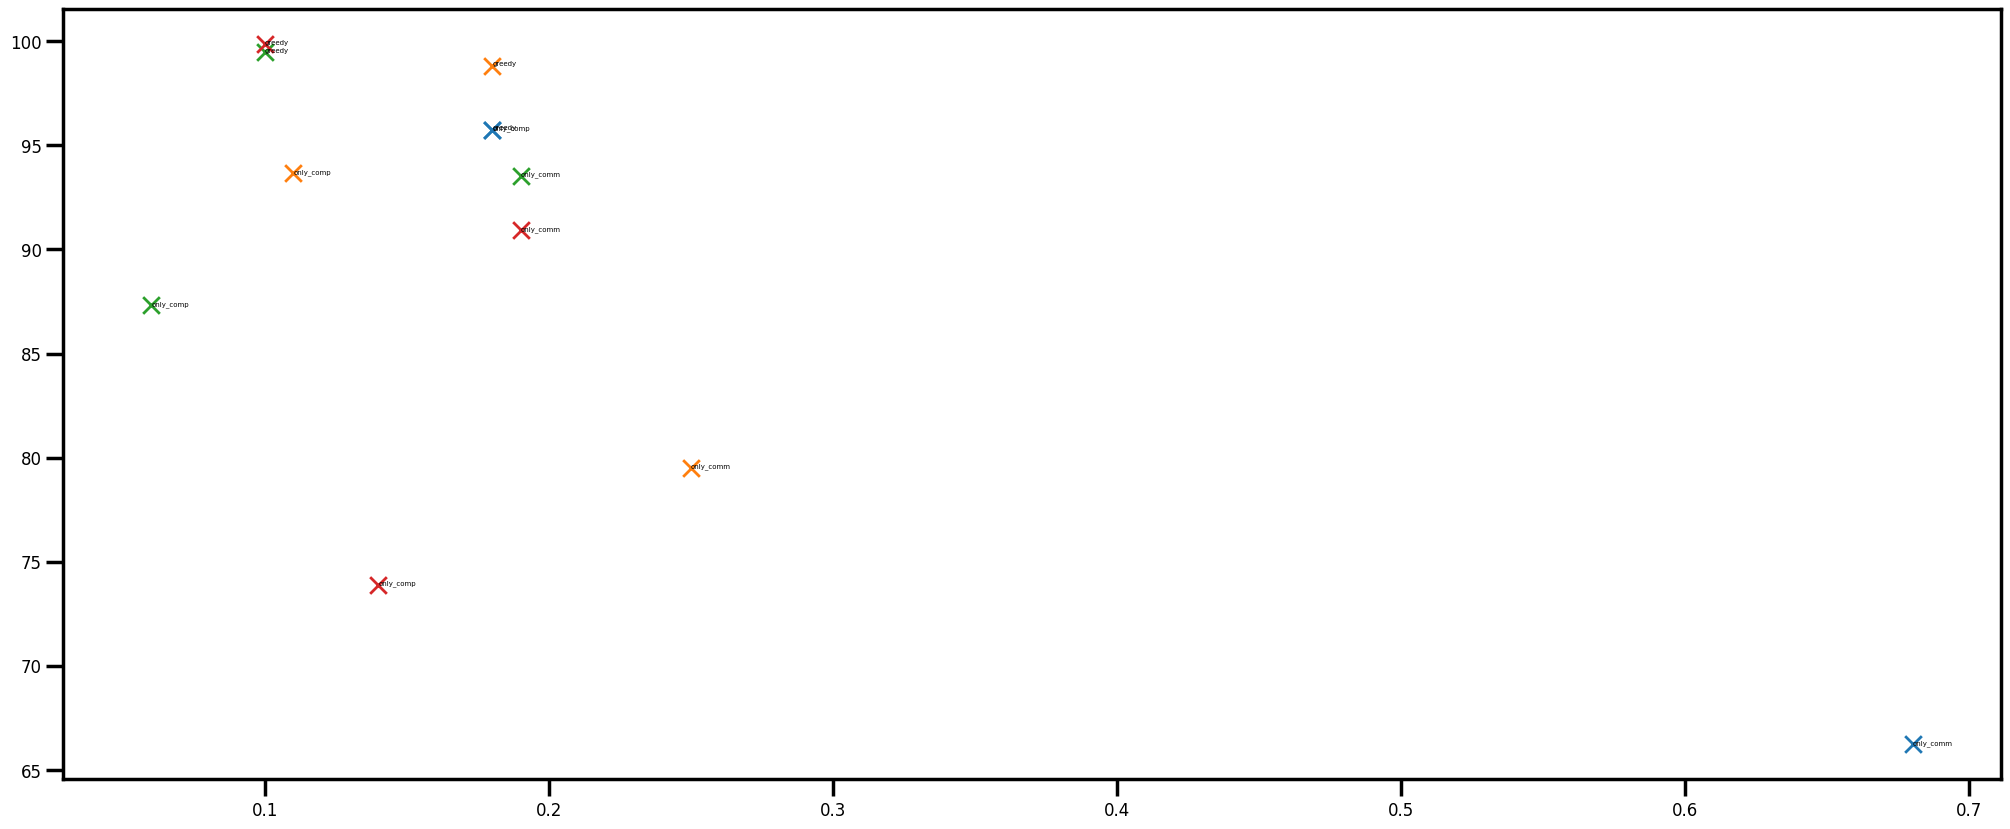

In [465]:
# trial_len = {'greedy_eff_240_1.0_w/o_leeway': [[np.float64(165.86699999999996), np.float64(176.13300000000004)], 3.801, 34.2], 'only_comp_eff_240_1.0_w/o_leeway': [[np.float64(803.5530000000001), np.float64(496.047)], 3.801, 34.2], 'only_comm_eff_240_1.0_w/o_leeway': [[np.float64(1210.86), np.float64(542.1900000000003)], 2.892, 44.95], 'only_best_eff_240_1.0_w/o_leeway': [[np.float64(749.2499999999995), np.float64(496.39000000000055)], 3.966, 32.78], 'greedy_eff_240_10.0_w/o_leeway': [[np.float64(207.253), np.float64(35.517000000000024)], 3.625, 22.07], 'only_comp_eff_240_10.0_w/o_leeway': [[np.float64(347.76699999999994), np.float64(-16.716999999999928)], 3.625, 22.07], 'only_comm_eff_240_10.0_w/o_leeway': [[np.float64(689.583), np.float64(135.71699999999998)], 2.035, 39.3], 'only_best_eff_240_10.0_w/o_leeway': [[np.float64(316.35800000000006), np.float64(-6.758000000000038)], 3.876, 20.64], 'greedy_eff_240_1.0_w/_leeway': [[np.float64(87.04799999999999), np.float64(139.212)], 3.448, 37.71], 'only_comp_eff_240_1.0_w/_leeway': [[np.float64(741.7610000000001), np.float64(653.5089999999999)], 3.448, 37.71], 'only_comm_eff_240_1.0_w/_leeway': [[np.float64(1296.8149999999991), np.float64(685.2650000000008)], 2.493, 52.16], 'only_best_eff_240_1.0_w/_leeway': [[np.float64(689.5560000000004), np.float64(661.3139999999995)], 3.561, 36.51], 'greedy_eff_240_10.0_w/_leeway': [[np.float64(142.033), np.float64(106.45700000000002)], 3.542, 22.59], 'only_comp_eff_240_10.0_w/_leeway': [[np.float64(344.083), np.float64(39.946999999999946)], 3.542, 22.59], 'only_comm_eff_240_10.0_w/_leeway': [[np.float64(647.3240000000001), np.float64(71.23599999999999)], 2.004, 39.92], 'only_best_eff_240_10.0_w/_leeway': [[np.float64(312.39900000000006), np.float64(47.32099999999997)], 3.781, 21.16]}
f=open('fixed_analysis_uniform.log')
# f=open('fixed_analysis_azure.log')
# l=f.readlines()[0] -> old values where latency used instead of max for idle time calc
# l=f.readlines()[1] -> values include non-leeway which we don't need anymore
# l=f.readlines()[2] -> incorrect values for greedy lmao xd moment
# l=f.readlines()[3] -> actual vals
# l=f.readlines()[4] #->bw vals diff
# l=f.readlines()[5] #->bw vals diff
# l=f.readlines()[3] #->bw vals diff
# l=f.readlines()[3] #->bw vals diff
# l=f.readlines()[3] #->bw vals diff
# l=f.readlines()[5] #->bw vals diff
# l=f.readlines()[6] #->bw vals w/ balanced workload diff w/ 10
# l=f.readlines()[7] #->bw vals w/ comp heavy workload diff w/ 10
# l=f.readlines()[8] #->bw vals w/ more n/w heavy, but still comp heavy workload diff w/ 10
# l=f.readlines()[9] #->bw vals w/ more n/w heavy, but still comp heavy workload diff w/ 10, w/ max instead of np.median for worst_dev_util
# l=f.readlines()[10] #->bw vals w/ balanced workload diff w/ 10 w/ max instead of np.median for worst_dev_util
# l=f.readlines()[13] #->og vals, split nt, t, nw, idle
l=f.readlines()[14] #->vit favor vals, split nt, t, nw, idle


trial_len = ast.literal_eval(l)
fig, axs = plt.subplots(figsize=(25,10))
# k = [1,2,3,4,5,10,100,100]
# k = [1,2,3,4,5,10]
k = [1,2,2.7,3,10,100]
cur_model="eff"
lee=0
bw=240
iat=1.0
for bw in [240, 30, 10, 2]:
    # for cur_model in ["resnet18", "vit","eff"]:
    # for cur_model in ["eff"]:
    for cur_model in ["eff"]:
        max_thr = {}
        # for iat in [0.5, 1.0, 10.0]:
        # for iat in [1.0, 10.0]:
        for iat in [1.0,10.0]:
            # for lee in [0,1]:
            for lee in [0]:
                max_baseline_keys = []
                # for iat in [1.0, 10.0]:
                baseline_keys=[f"{s}_{cur_model}_{bw}_1.0_{'w/' if lee!=0 else 'w/o'}_leeway" for s in ["greedy", "only_comp", "only_comm", "only_best"]]
                other_key=[f"{s}_{cur_model}_{bw}_10.0_{'w/' if lee!=0 else 'w/o'}_leeway" for s in ["greedy", "only_comp", "only_comm", "only_best"]]
                # min_lat = 39*min([round( (sum(trial_len[key][0][:2])/trial_len[key][0][2] + sum(trial_len[other_key[k_ind]][0][:2])/trial_len[other_key[k_ind]][0][2]),2) for k_ind, key in enumerate(baseline_keys)])
                # max_lat = 39*max([round( (sum(trial_len[key][0][:2])/trial_len[key][0][2] + sum(trial_len[other_key[k_ind]][0][:2])/trial_len[other_key[k_ind]][0][2]),2) for k_ind, key in enumerate(baseline_keys)])
                # min_baseline = min([round( (sum(trial_len[key][0][:2])),2) for k_ind, key in enumerate(baseline_keys)])
                # max_baseline = max([round( (sum(trial_len[key][0][:2])),2) for k_ind, key in enumerate(baseline_keys)])
                min_baseline = min([round( (sum(trial_len[key][0][:4])),2) for k_ind, key in enumerate(baseline_keys)])
                max_baseline = max([round( (sum(trial_len[key][0][:4])),2) for k_ind, key in enumerate(baseline_keys)])
                key = f"only_best_{cur_model}_{bw}_1.0_{'w/' if lee!=0 else 'w/o'}_leeway"
                other_key = f"only_best_{cur_model}_{bw}_10.0_{'w/' if lee!=0 else 'w/o'}_leeway"
                best_lat= 39*sum([sum(trial_len[key][0][:4])/trial_len[key][0][4] + sum(trial_len[other_key][0][:4])/trial_len[other_key][0][4]])
                # best_baseline= sum([sum([3*trial_len[key][0][0],trial_len[key][0][1]]) + sum([3*trial_len[other_key][0][0], trial_len[other_key][0][1]])])
                # best_baseline= sum(([3*trial_len[key][0][0],trial_len[key][0][1]]))
                b_nt = trial_len[key][0][0]#+trial_len[other_key][0][0]
                b_t= trial_len[key][0][1]#+trial_len[other_key][0][1]
                b_nw = trial_len[key][0][2]#+trial_len[other_key][0][2]
                b_idle = trial_len[key][0][3]#+trial_len[other_key][0][3]
                best_baseline= sum(([3*(b_nt), b_t, b_nw, b_idle]))
                # best_baseline= sum(([3*(b_nt+b_nw), b_t, b_idle]))
                # print(best_baseline)
                # max_baseline = max([sum(trial_len[key][0][:2]) for key in max_baseline_keys])
                # min_baseline = min([sum(trial_len[key][0][:2]) for key in max_baseline_keys])
                # min_lat = 39*min([round(sum(trial_len[key][0][:2])/trial_len[key][0][2],2) for key in max_baseline_keys])
                # max_lat = 39*max([round(sum(trial_len[key][0][:2])/trial_len[key][0][2],2) for key in max_baseline_keys])
                # key = f"only_best_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"
                # best_lat= 39*sum(trial_len[key][0][:2])/trial_len[key][0][2]
                # best_added_energy = best_lat*(39-trial_len[key][0][2])
                # best_act = trial_len[key][0][0]
                # best_idl = trial_len[key][0][1]
                # sum_best = min([sum(trial_len[key][0]) for key in max_baseline_keys if "best" in key])
                for s in ["greedy", "only_comp", "only_comm", "only_best"]:
                # for s in ["greedy"]:
                # for s in ["greedy", "only_comm", "only_comp"]:
                    # if s not in max_thr:
                    #     max_thr[s]=[0,0,0]
                    key =  f"{s}_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"
                    # if max_thr[s][0] < trial_len[key][1]:
                    # trial_len[key][0][1] = 0 if  trial_len[key][0][1]<0 else  trial_len[key][0][1]
                    # lat = 39*sum(trial_len[key][0][:2])/trial_len[key][0][2]
                    # lat = 39*sum(trial_len[key][0][:2])/trial_len[key][0][2]
                    # lat = sum(trial_len[key][0][:2])
                    # lat = best_baseline
                    lat = 39*(best_baseline)/trial_len[key][0][4]
                    # real_lat = 39*sum(trial_len[key][0][:2])/trial_len[key][0][2]
                    real_lat = 39*sum(trial_len[key][0][:4])/trial_len[key][0][4]
                    added_energy = (real_lat/39)*(39-trial_len[key][0][4])
                    # s=f"{s}_{iat}"
                    if s not in max_thr:
                        #real one
                        # max_thr[s] = [max(0, trial_len[key][-1]),[trial_len[key][0][0],trial_len[key][0][1]+added_energy,trial_len[key][0][2]], [round( (i*trial_len[key][0][0] + trial_len[key][0][1]+added_energy)/(lat),2) for i in k], lat]
                        # print(trial_len[key][0], key)
                        nt = trial_len[key][0][0]
                        t = trial_len[key][0][1]
                        nw = trial_len[key][0][2]
                        idle = trial_len[key][0][3]
                        max_thr[s] = [max(0, trial_len[key][-1]),[nt, t, nw, idle+added_energy,trial_len[key][0][4]], [round( (i*nt + t + nw + idle+added_energy)/(lat),2) for i in k], lat]
                        # max_thr[s] = [max(0, trial_len[key][-1]),[nt, t, nw, idle+added_energy,trial_len[key][0][4]], [round( (i*(nt+nw) + t + idle+added_energy)/(lat),2) for i in k], lat]
                        
                        # max_thr[s] = [max(0, trial_len[key][-1]),[trial_len[key][0][0],trial_len[key][0][1],trial_len[key][0][2]], [round( (i*trial_len[key][0][0] + trial_len[key][0][1])/(lat),2) for i in k], lat]
                        # max_thr[s] = [max(0, trial_len[key][-1]),[trial_len[key][0][0],trial_len[key][0][1],trial_len[key][0][2]], [round( (i*trial_len[key][0][0] + trial_len[key][0][1])/(best_baseline),2) for i in k], lat]
                    elif s in max_thr: 
                        # prev_lat = sum(trial_len[key][0][:2])#/max_thr[s][1][2]
                        # prev_add_energy = prev_lat*(39-max_thr[s][1][2])
                        # max_thr[s] = [max(max_thr[s][0], trial_len[key][1]), max_thr[s][1], [round( (i*(trial_len[key][0][0]+max_thr[s][1][0]) + (trial_len[key][0][1]+max_thr[s][1][1]))/((lat+prev_lat)),2) for i in k]]
                        # if "greedy" in s:
                        # max_thr[s] = [max(max_thr[s][0], trial_len[key][1]), [sum([trial_len[key][0][0],max_thr[s][1][0]]), sum([trial_len[key][0][1],max_thr[s][1][1]]), max_thr[s][1][2]], [round( (i*sum([trial_len[key][0][0],max_thr[s][1][0]]) + sum([trial_len[key][0][1],max_thr[s][1][1]]))/(lat+max_thr[s][-1]),2) for i in k], lat+max_thr[s][-1] ]
                        
                        #real one
                        # max_thr[s] = [sum([max_thr[s][0], trial_len[key][-1]]), [sum([trial_len[key][0][0],max_thr[s][1][0]]), sum([trial_len[key][0][1],max_thr[s][1][1],added_energy]), max_thr[s][1][2]], [round( (i*sum([trial_len[key][0][0],max_thr[s][1][0]]) + sum([trial_len[key][0][1],max_thr[s][1][1], added_energy]))/(lat+max_thr[s][-1]),3) for i in k], lat+max_thr[s][-1] ]
                        prev_nt = max_thr[s][1][0]
                        prev_t = max_thr[s][1][1]
                        prev_nw = max_thr[s][1][2]
                        prev_idle = max_thr[s][1][3]
                        nt = trial_len[key][0][0]
                        t = trial_len[key][0][1]
                        nw = trial_len[key][0][2]
                        idle = trial_len[key][0][3]
                        max_thr[s] = [sum([max_thr[s][0], trial_len[key][-1]]), [prev_nt+nt,prev_t+t, prev_nw+nw, prev_idle+idle+added_energy ,max_thr[s][1][4]], [round( (i*(nt+prev_nt) + (t+prev_t) + (nw+prev_nw) + idle+prev_idle+added_energy)/(lat+max_thr[s][-1]),3) for i in k], lat+max_thr[s][-1] ]
                        # max_thr[s] = [sum([max_thr[s][0], trial_len[key][-1]]), [prev_nt+nt,prev_t+t, prev_nw+nw, prev_idle+idle+added_energy ,max_thr[s][1][4]], [round( (i*(nt+prev_nt+nw+prev_nw) + (t+prev_t) + idle+prev_idle+added_energy)/(lat+max_thr[s][-1]),3) for i in k], lat+max_thr[s][-1] ]
                        
                        # max_thr[s] = [sum([max_thr[s][0], trial_len[key][-1]]), [sum([trial_len[key][0][0],max_thr[s][1][0]]), sum([trial_len[key][0][1],max_thr[s][1][1]]), max_thr[s][1][2]], [round( (i*sum([trial_len[key][0][0],max_thr[s][1][0]]) + sum([trial_len[key][0][1],max_thr[s][1][1]]))/(lat+max_thr[s][-1]),3) for i in k], lat+max_thr[s][-1] ]
                        # max_thr[s] = [sum([max_thr[s][0], trial_len[key][-1]]), [sum([trial_len[key][0][0],max_thr[s][1][0]]), sum([trial_len[key][0][1],max_thr[s][1][1]]), max_thr[s][1][2]], [round( (i*sum([trial_len[key][0][0],max_thr[s][1][0]]) + sum([trial_len[key][0][1],max_thr[s][1][1]]))/(best_baseline),3) for i in k], lat+max_thr[s][-1] ]
                        # else:
                        # max_thr[s] = [max(max_thr[s][0], trial_len[key][1]), max_thr[s][1], [round( (i*max(trial_len[key][0][0],max_thr[s][1][0]) + max(trial_len[key][0][1],max_thr[s][1][1]))/(max(lat,prev_lat)),2) for i in k]]

                        # max_thr[s] = [max(max_thr[s][0], trial_len[key][1]),trial_len[key][0], [round( (i*trial_len[key][0][0] + trial_len[key][0][1])/(trial_len[key][0][2]*best_lat),2) for i in k]]
                        # max_thr[s] = [max(max_thr[s][0], trial_len[key][1]),trial_len[key][0], [round( (i*trial_len[key][0][0] + trial_len[key][0][1]+added_energy)/((best_lat+best_added_energy)),2) for i in k]]
                    # print(key)
                    # axs.plot(k, [round( (i*trial_len[key][0][0] + trial_len[key][0][1]+added_energy)/(39*lat),2) for i in k])
                    # axs.text(k[-1], [round( (i*trial_len[key][0][0] + trial_len[key][0][1]+added_energy)/(39*lat),2) for i in k][-1],f"{cur_model}_{s}_{'w/' if lee!=0 else 'w/o'}_leeway")
        thr = [ round(100*max_thr["only_best"][0]/max_thr[ke][0],2) for ke in max_thr if "best" not in ke]
        en = [round(max_thr[ke][2][3],2) for ke in max_thr if "best" not in ke]
        print(bw, thr, en, [round( round(thr[i]*0.01,2)/en[i],2) for i in range(len(thr))])#, [round( en[i]/round(thr[i]*0.01,2),2) for i in range(len(thr))])
        axs.scatter(en, thr, marker="x")
        for ke in max_thr:
            if "best" in ke:
                continue
            axs.text(round(max_thr[ke][2][3],2), round(100*max_thr["only_best"][0]/max_thr[ke][0],2),  ke)
        print(f"{cur_model}, {bw}, { [ [k, round(100*(10/v[0])/(10/max_thr['only_best'][0]),2), [v[1][0], v[1][0], v[1][1], v[1][2]], v[2], v[-1]/39, v[0]] for k,v in max_thr.items() ] }")

# axs.plot(k, [i*trial_len[key][0][0] + trial_len[key][0][1] for i in k], label="no lee")
# lee=1
# key = f"greedy_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"
# axs.plot(k, [i*trial_len[key][0][0] + trial_len[key][0][1] for i in k], label="lee")
# axs.legend()
# axs.set_yscale("log", base=10)


240 greed 0.8267513848159009
240 greed [np.float64(0.538), np.float64(7.0809999999999995), np.float64(84.137)] nan
240 comp 0.8267513848159009
240 comp [np.float64(0.844), np.float64(10.621500000000001), np.float64(100.363)] nan
240 comm 0.6806825554091303
240 comm [np.float64(0.844), np.float64(10.971), np.float64(167.695)] nan
30 greed 0.9750231480933312
30 greed [np.float64(0.799), np.float64(15.553), np.float64(293.867)] nan
30 comp 0.974580757700185
30 comp [np.float64(1.199), np.float64(34.7025), np.float64(463.737)] nan
30 comm 0.8917818600044535
30 comm [np.float64(1.199), np.float64(28.9345), np.float64(352.206)] nan
10 greed 0.9899376040453807
10 greed [np.float64(1.108), np.float64(56.7395), np.float64(425.773)] nan
10 comp 0.9903828834573638
10 comp [np.float64(1.662), np.float64(77.08), np.float64(793.448)] nan
10 comm 0.8880952850953527
10 comm [np.float64(1.662), np.float64(72.084), np.float64(1293.172)] nan
2 greed 0.9958794468237981
2 greed [np.float64(2.733), np.float

/Users/animeshnd/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/animeshnd/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: x and y must be the same size

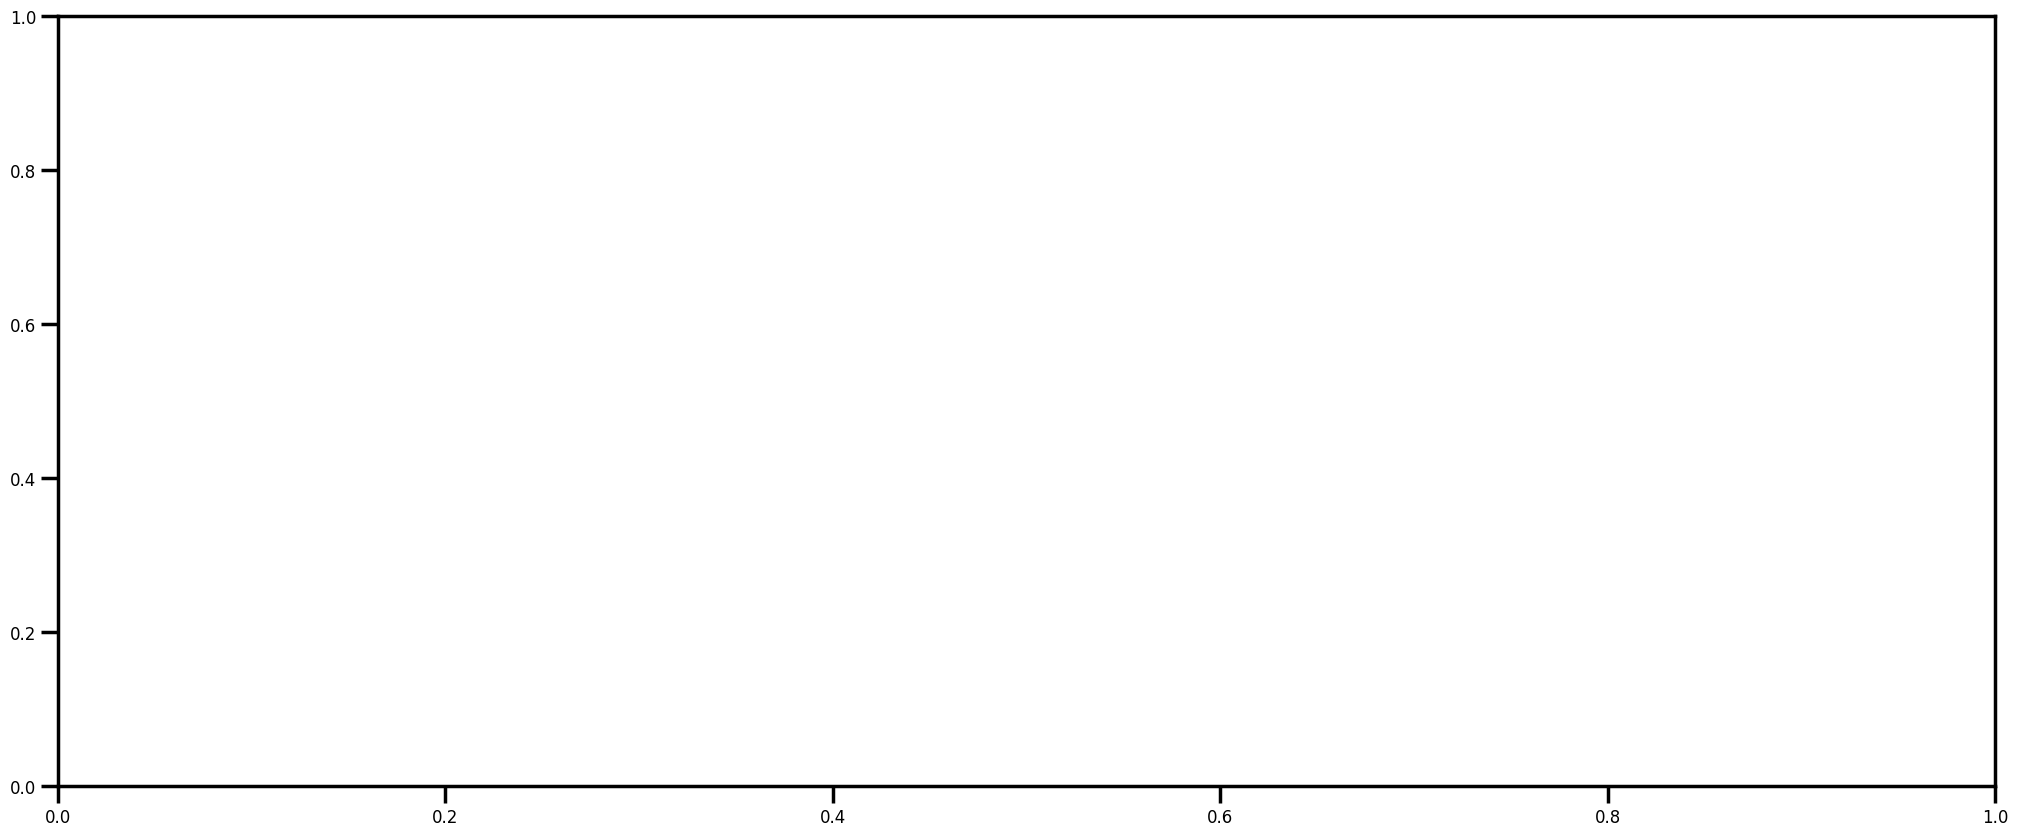

In [ ]:
# resnet18_trials_uniform = {'greedy_resnet18_240_0.5_w/o_leeway': [39.646, 6.129, 50.58], 'only_comp_resnet18_240_0.5_w/o_leeway': [60.142, 6.129, 50.58], 'only_comm_resnet18_240_0.5_w/o_leeway': [50.764, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/o_leeway': [54.433, 6.251, 49.59], 'greedy_resnet18_30_0.5_w/o_leeway': [302.244, 0.601, 516.07], 'only_comp_resnet18_30_0.5_w/o_leeway': [455.684, 0.564, 549.7], 'only_comm_resnet18_30_0.5_w/o_leeway': [434.839, 0.601, 516.07], 'only_best_resnet18_30_0.5_w/o_leeway': [432.071, 0.602, 514.87], 'greedy_resnet18_10_0.5_w/o_leeway': [901.347, 0.196, 1582.98], 'only_comp_resnet18_10_0.5_w/o_leeway': [1357.033, 0.188, 1649.85], 'only_comm_resnet18_10_0.5_w/o_leeway': [1294.79, 0.196, 1582.98], 'only_best_resnet18_10_0.5_w/o_leeway': [1292.136, 0.196, 1582.15], 'greedy_resnet18_2_0.5_w/o_leeway': [4494.011, 0.039, 7915.6], 'only_comp_resnet18_2_0.5_w/o_leeway': [11061.385, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/o_leeway': [6452.575, 0.039, 7915.6], 'only_best_resnet18_2_0.5_w/o_leeway': [6449.927, 0.039, 7914.77], 'greedy_resnet18_240_1.0_w/o_leeway': [9.192, 6.841, 23.39], 'only_comp_resnet18_240_1.0_w/o_leeway': [16.033, 6.841, 23.39], 'only_comm_resnet18_240_1.0_w/o_leeway': [12.058, 8.985, 17.81], 'only_best_resnet18_240_1.0_w/o_leeway': [14.803, 7.143, 22.4], 'greedy_resnet18_30_1.0_w/o_leeway': [41.139, 0.839, 190.67], 'only_comp_resnet18_30_1.0_w/o_leeway': [143.72, 0.839, 190.67], 'only_comm_resnet18_30_1.0_w/o_leeway': [143.941, 0.838, 190.84], 'only_best_resnet18_30_1.0_w/o_leeway': [142.58, 0.844, 189.63], 'greedy_resnet18_10_1.0_w/o_leeway': [65.864, 0.303, 528.64], 'only_comp_resnet18_10_1.0_w/o_leeway': [361.098, 0.303, 528.42], 'only_comm_resnet18_10_1.0_w/o_leeway': [361.319, 0.303, 528.64], 'only_best_resnet18_10_1.0_w/o_leeway': [360.016, 0.303, 527.32], 'greedy_resnet18_2_1.0_w/o_leeway': [356.36, 0.061, 2632.66], 'only_comp_resnet18_2_1.0_w/o_leeway': [4982.344, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/o_leeway': [1810.835, 0.061, 2632.66], 'only_best_resnet18_2_1.0_w/o_leeway': [1809.538, 0.061, 2631.34], 'greedy_resnet18_240_10.0_w/o_leeway': [0.765, 7.136, 4.2], 'only_comp_resnet18_240_10.0_w/o_leeway': [1.147, 7.136, 4.2], 'only_comm_resnet18_240_10.0_w/o_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/o_leeway': [0.947, 8.78, 3.42], 'greedy_resnet18_30_10.0_w/o_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/o_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/o_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/o_leeway': [5.174, 0.826, 36.33], 'greedy_resnet18_10_10.0_w/o_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/o_leeway': [15.256, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/o_leeway': [15.283, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/o_leeway': [15.068, 0.272, 110.28], 'greedy_resnet18_2_10.0_w/o_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/o_leeway': [74.541, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/o_leeway': [74.568, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/o_leeway': [74.359, 0.052, 577.92], 'greedy_resnet18_240_0.5_w/_leeway': [33.436, 5.606, 55.3], 'only_comp_resnet18_240_0.5_w/_leeway': [51.111, 5.627, 55.09], 'only_comm_resnet18_240_0.5_w/_leeway': [50.764, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/_leeway': [48.076, 5.743, 53.98], 'greedy_resnet18_30_0.5_w/_leeway': [271.551, 0.601, 516.07], 'only_comp_resnet18_30_0.5_w/_leeway': [414.085, 0.591, 524.78], 'only_comm_resnet18_30_0.5_w/_leeway': [414.36, 0.601, 516.07], 'only_best_resnet18_30_0.5_w/_leeway': [401.49, 0.602, 514.87], 'greedy_resnet18_10_0.5_w/_leeway': [808.359, 0.251, 1233.87], 'only_comp_resnet18_10_0.5_w/_leeway': [1201.462, 0.251, 1233.55], 'only_comm_resnet18_10_0.5_w/_leeway': [1186.731, 0.192, 1618.64], 'only_best_resnet18_10_0.5_w/_leeway': [1199.239, 0.252, 1232.55], 'greedy_resnet18_2_0.5_w/_leeway': [4494.011, 0.039, 7915.6], 'only_comp_resnet18_2_0.5_w/_leeway': [11061.385, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/_leeway': [6452.575, 0.039, 7915.6], 'only_best_resnet18_2_0.5_w/_leeway': [6449.927, 0.039, 7914.77], 'greedy_resnet18_240_1.0_w/_leeway': [8.535, 8.203, 19.5], 'only_comp_resnet18_240_1.0_w/_leeway': [13.296, 8.203, 19.5], 'only_comm_resnet18_240_1.0_w/_leeway': [12.058, 8.985, 17.81], 'only_best_resnet18_240_1.0_w/_leeway': [12.026, 8.791, 18.2], 'greedy_resnet18_30_1.0_w/_leeway': [41.139, 0.839, 190.67], 'only_comp_resnet18_30_1.0_w/_leeway': [143.72, 0.839, 190.67], 'only_comm_resnet18_30_1.0_w/_leeway': [143.941, 0.838, 190.84], 'only_best_resnet18_30_1.0_w/_leeway': [142.58, 0.844, 189.63], 'greedy_resnet18_10_1.0_w/_leeway': [65.864, 0.303, 528.64], 'only_comp_resnet18_10_1.0_w/_leeway': [361.098, 0.303, 528.42], 'only_comm_resnet18_10_1.0_w/_leeway': [361.319, 0.303, 528.64], 'only_best_resnet18_10_1.0_w/_leeway': [360.016, 0.303, 527.32], 'greedy_resnet18_2_1.0_w/_leeway': [356.36, 0.061, 2632.66], 'only_comp_resnet18_2_1.0_w/_leeway': [4982.344, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/_leeway': [1810.835, 0.061, 2632.66], 'only_best_resnet18_2_1.0_w/_leeway': [1809.538, 0.061, 2631.34], 'greedy_resnet18_240_10.0_w/_leeway': [0.538, 7.58, 3.96], 'only_comp_resnet18_240_10.0_w/_leeway': [0.807, 7.58, 3.96], 'only_comm_resnet18_240_10.0_w/_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/_leeway': [0.604, 10.285, 2.92], 'greedy_resnet18_30_10.0_w/_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/_leeway': [5.174, 0.826, 36.33], 'greedy_resnet18_10_10.0_w/_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/_leeway': [15.256, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/_leeway': [15.283, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/_leeway': [15.068, 0.272, 110.28], 'greedy_resnet18_2_10.0_w/_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/_leeway': [74.541, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/_leeway': [74.568, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/_leeway': [74.359, 0.052, 577.92]}
#most updated value for testing/playing around
# eff_trials_uniform = {'greedy_eff_240_0.5_w/o_leeway': [[0.528, 28.246, 3.605, np.float64(0.04589759631979369), 15, np.float64(0.37202225278424567)], 8.416, 36.84], 'only_comp_eff_240_0.5_w/o_leeway': [[0.402, 47.997, 4.538, np.float64(0.040377428746007075), 39, np.float64(0.42687883821682343)], 8.416, 36.84], 'only_comm_eff_240_0.5_w/o_leeway': [[0.546, 77.068, 4.512, np.float64(0.043363873921423754), 39, np.float64(0.4324351853986965)], 5.864, 52.86], 'greedy_eff_30_0.5_w/o_leeway': [[0.7, 82.879, 2.324, np.float64(0.019526286327753887), 12, np.float64(0.21341465678385335)], 1.814, 170.87], 'only_comp_eff_30_0.5_w/o_leeway': [[0.266, 156.594, 3.822, np.float64(0.03175992107270047), 39, np.float64(0.44558521164863757)], 1.814, 170.87], 'only_comm_eff_30_0.5_w/o_leeway': [[0.336, 157.616, 2.188, np.float64(0.01845018325458267), 39, np.float64(0.34964462055411244)], 1.672, 185.45], 'greedy_eff_10_0.5_w/o_leeway': [[0.404, 193.423, 1.424, np.float64(0.012823415793003662), 18, np.float64(0.24259635375136598)], 0.661, 469.11], 'only_comp_eff_10_0.5_w/o_leeway': [[0.343, 368.016, 3.216, np.float64(0.02816546812858239), 39, np.float64(0.4175465854388113)], 0.661, 469.11], 'only_comm_eff_10_0.5_w/o_leeway': [[0.287, 299.743, 1.484, np.float64(0.013117101940991723), 39, np.float64(0.32180486358409477)], 0.641, 483.69], 'greedy_eff_2_0.5_w/o_leeway': [[0.679, 1932.344, 2.426, np.float64(0.019703737790313276), 18, np.float64(0.21625700005232132)], 0.119, 2610.18], 'only_comp_eff_2_0.5_w/o_leeway': [[0.067, 2975.568, 4.997, np.float64(0.052925813727098425), 39, np.float64(0.6121754061952365)], 0.119, 2609.97], 'only_comm_eff_2_0.5_w/o_leeway': [[0.067, 2491.034, 2.471, np.float64(0.0253804857457091), 39, np.float64(0.45453146526466837)], 0.119, 2610.18], 'greedy_eff_240_1.0_w/o_leeway': [[0.388, 9.25, 0.806, np.float64(0.011172650195282059), 17, np.float64(0.16565384733289457)], 4.402, 36.35], 'only_comp_eff_240_1.0_w/o_leeway': [[0.388, 23.609, 1.092, np.float64(0.011052847381784811), 38, np.float64(0.12592115352274805)], 4.402, 36.35], 'only_comm_eff_240_1.0_w/o_leeway': [[0.531, 41.463, 1.437, np.float64(0.020331972536106697), 39, np.float64(0.18887399461893947)], 3.027, 52.86], 'greedy_eff_30_1.0_w/o_leeway': [[0.735, 32.033, 1.389, np.float64(0.017305133241364463), 9, np.float64(0.14385658207339952)], 1.164, 137.5], 'only_comp_eff_30_1.0_w/o_leeway': [[0.105, 92.046, 0.924, np.float64(0.017124749639715473), 39, np.float64(0.30195553590441926)], 0.9, 177.76], 'only_comm_eff_30_1.0_w/o_leeway': [[0.064, 49.561, 1.101, np.float64(0.0202001952388632), 24, np.float64(0.2744434054103925)], 1.316, 121.54], 'greedy_eff_10_1.0_w/o_leeway': [[0.761, 96.852, 1.477, np.float64(0.01839329990533532), 9, np.float64(0.1389787476255717)], 0.436, 366.79], 'only_comp_eff_10_1.0_w/o_leeway': [[0.093, 253.365, 0.904, np.float64(0.016337971173026145), 39, np.float64(0.31059603914159195)], 0.303, 528.42], 'only_comm_eff_10_1.0_w/o_leeway': [[0.044, 140.337, 1.571, np.float64(0.032207614031056125), 24, np.float64(0.43874850907926866)], 0.436, 366.79], 'greedy_eff_2_1.0_w/o_leeway': [[0.736, 631.03, 2.376, np.float64(0.04401301137718341), 9, np.float64(0.21300248141377684)], 0.1, 1598.63], 'only_comp_eff_2_1.0_w/o_leeway': [[0.079, 972.452, 1.65, np.float64(0.03176941373993043), 33, np.float64(0.4977905260394844)], 0.073, 2205.35], 'only_comm_eff_2_1.0_w/o_leeway': [[0.065, 789.191, 2.43, np.float64(0.05440375995668661), 24, np.float64(0.55345671590728)], 0.1, 1598.63], 'greedy_eff_240_10.0_w/o_leeway': [[1.533, 3.121, 1.533, np.float64(0.0), 4, np.float64(0.0)], 1.511, 19.85], 'only_comp_eff_240_10.0_w/o_leeway': [[1.712, 3.486, 1.712, np.float64(0.0), 4, np.float64(0.0)], 1.511, 19.85], 'only_comm_eff_240_10.0_w/o_leeway': [[0.692, 7.799, 0.794, np.float64(0.012167025491563574), 12, np.float64(0.02607582826200595)], 0.876, 34.24], 'greedy_eff_30_10.0_w/o_leeway': [[0.863, 2.865, 0.863, np.float64(0.0), 3, np.float64(0.0)], 0.695, 43.15], 'only_comp_eff_30_10.0_w/o_leeway': [[0.859, 6.808, 1.192, np.float64(0.0553804557744303), 6, np.float64(0.08100748039503718)], 0.695, 43.15], 'only_comm_eff_30_10.0_w/o_leeway': [[0.814, 12.05, 1.037, np.float64(0.032576438212381924), 8, np.float64(0.053560180958886344)], 0.465, 64.48], 'greedy_eff_10_10.0_w/o_leeway': [[0.886, 5.844, 0.886, np.float64(0.0), 3, np.float64(0.0)], 0.35, 85.75], 'only_comp_eff_10_10.0_w/o_leeway': [[0.884, 13.517, 1.165, np.float64(0.04684159378036931), 6, np.float64(0.06857344472012931)], 0.35, 85.75], 'only_comm_eff_10_10.0_w/o_leeway': [[0.881, 15.439, 1.121, np.float64(0.04001063582278061), 6, np.float64(0.059977081361167875)], 0.299, 100.29], 'greedy_eff_2_10.0_w/o_leeway': [[0.913, 22.591, 0.913, np.float64(0.0), 3, np.float64(0.0)], 0.093, 321.83], 'only_comp_eff_2_10.0_w/o_leeway': [[0.913, 58.663, 1.457, np.float64(0.09076479300665982), 6, np.float64(0.11490963401217641)], 0.093, 321.83], 'only_comm_eff_2_10.0_w/o_leeway': [[0.907, 60.432, 1.428, np.float64(0.08682563264497598), 6, np.float64(0.1115863958116676)], 0.089, 336.55], 'greedy_eff_240_0.5_w/_leeway': [[0.279, 25.648, 4.245, np.float64(0.05016210794820178), 15, np.float64(0.48244641127230325)], 7.847, 39.51], 'only_comp_eff_240_0.5_w/_leeway': [[0.497, 41.612, 3.718, np.float64(0.030162163435760402), 37, np.float64(0.36052202688655005)], 7.847, 39.51], 'only_comm_eff_240_0.5_w/_leeway': [[0.61, 77.624, 4.588, np.float64(0.03698837803650485), 39, np.float64(0.3818494855958032)], 5.714, 54.26], 'greedy_eff_30_0.5_w/_leeway': [[0.7, 82.879, 2.324, np.float64(0.019526286327753887), 12, np.float64(0.21341465678385335)], 1.814, 170.87], 'only_comp_eff_30_0.5_w/_leeway': [[0.266, 156.594, 3.822, np.float64(0.03175992107270047), 39, np.float64(0.44558521164863757)], 1.814, 170.87], 'only_comm_eff_30_0.5_w/_leeway': [[0.317, 157.003, 2.609, np.float64(0.01914048802882274), 39, np.float64(0.3369989033855)], 1.672, 185.45], 'greedy_eff_10_0.5_w/_leeway': [[0.404, 193.423, 1.424, np.float64(0.012823415793003662), 18, np.float64(0.24259635375136598)], 0.661, 469.11], 'only_comp_eff_10_0.5_w/_leeway': [[0.343, 368.016, 3.216, np.float64(0.02816546812858239), 39, np.float64(0.4175465854388113)], 0.661, 469.11], 'only_comm_eff_10_0.5_w/_leeway': [[0.287, 299.743, 1.484, np.float64(0.013117101940991723), 39, np.float64(0.32180486358409477)], 0.641, 483.69], 'greedy_eff_2_0.5_w/_leeway': [[0.679, 1932.344, 2.426, np.float64(0.019703737790313276), 18, np.float64(0.21625700005232132)], 0.119, 2610.18], 'only_comp_eff_2_0.5_w/_leeway': [[0.067, 2975.568, 4.997, np.float64(0.052925813727098425), 39, np.float64(0.6121754061952365)], 0.119, 2609.97], 'only_comm_eff_2_0.5_w/_leeway': [[0.067, 2491.034, 2.471, np.float64(0.0253804857457091), 39, np.float64(0.45453146526466837)], 0.119, 2610.18], 'greedy_eff_240_1.0_w/_leeway': [[0.364, 8.013, 0.867, np.float64(0.011558514116768136), 15, np.float64(0.181886249100072)], 4.05, 39.51], 'only_comp_eff_240_1.0_w/_leeway': [[0.28, 22.723, 0.998, np.float64(0.01125769197246988), 37, np.float64(0.15978509202325253)], 4.05, 39.51], 'only_comm_eff_240_1.0_w/_leeway': [[0.458, 38.734, 1.35, np.float64(0.01286285432646967), 38, np.float64(0.1296337215492738)], 2.934, 54.53], 'greedy_eff_30_1.0_w/_leeway': [[0.735, 32.033, 1.389, np.float64(0.017305133241364463), 9, np.float64(0.14385658207339952)], 1.164, 137.5], 'only_comp_eff_30_1.0_w/_leeway': [[0.105, 92.046, 0.924, np.float64(0.017124749639715473), 39, np.float64(0.30195553590441926)], 0.9, 177.76], 'only_comm_eff_30_1.0_w/_leeway': [[0.082, 49.534, 1.586, np.float64(0.026654231691569233), 21, np.float64(0.278315706152823)], 1.443, 110.89], 'greedy_eff_10_1.0_w/_leeway': [[0.761, 96.852, 1.477, np.float64(0.01839329990533532), 9, np.float64(0.1389787476255717)], 0.436, 366.79], 'only_comp_eff_10_1.0_w/_leeway': [[0.093, 253.365, 0.904, np.float64(0.016337971173026145), 39, np.float64(0.31059603914159195)], 0.303, 528.42], 'only_comm_eff_10_1.0_w/_leeway': [[0.044, 140.337, 1.571, np.float64(0.032207614031056125), 24, np.float64(0.43874850907926866)], 0.436, 366.79], 'greedy_eff_2_1.0_w/_leeway': [[0.736, 631.03, 2.376, np.float64(0.04401301137718341), 9, np.float64(0.21300248141377684)], 0.1, 1598.63], 'only_comp_eff_2_1.0_w/_leeway': [[0.079, 972.452, 1.65, np.float64(0.03176941373993043), 33, np.float64(0.4977905260394844)], 0.073, 2205.35], 'only_comm_eff_2_1.0_w/_leeway': [[0.065, 789.191, 2.43, np.float64(0.05440375995668661), 24, np.float64(0.55345671590728)], 0.1, 1598.63], 'greedy_eff_240_10.0_w/_leeway': [[0.807, 2.751, 1.533, np.float64(0.10476653247461118), 4, np.float64(0.10070078652104222)], 1.511, 19.85], 'only_comp_eff_240_10.0_w/_leeway': [[1.533, 3.387, 1.707, np.float64(0.02518090657687244), 4, np.float64(0.01966049733166797)], 1.511, 19.85], 'only_comm_eff_240_10.0_w/_leeway': [[0.755, 7.345, 0.854, np.float64(0.012046436424528528), 10, np.float64(0.023604056483566352)], 0.84, 35.7], 'greedy_eff_30_10.0_w/_leeway': [[0.863, 2.865, 0.863, np.float64(0.0), 3, np.float64(0.0)], 0.695, 43.15], 'only_comp_eff_30_10.0_w/_leeway': [[0.859, 6.808, 1.192, np.float64(0.0553804557744303), 6, np.float64(0.08100748039503718)], 0.695, 43.15], 'only_comm_eff_30_10.0_w/_leeway': [[0.904, 9.119, 1.152, np.float64(0.041371937124364294), 6, np.float64(0.06038802193167438)], 0.52, 57.68], 'greedy_eff_10_10.0_w/_leeway': [[0.886, 5.844, 0.886, np.float64(0.0), 3, np.float64(0.0)], 0.35, 85.75], 'only_comp_eff_10_10.0_w/_leeway': [[0.884, 13.517, 1.165, np.float64(0.04684159378036931), 6, np.float64(0.06857344472012931)], 0.35, 85.75], 'only_comm_eff_10_10.0_w/_leeway': [[0.881, 15.439, 1.121, np.float64(0.04001063582278061), 6, np.float64(0.059977081361167875)], 0.299, 100.29], 'greedy_eff_2_10.0_w/_leeway': [[0.913, 22.591, 0.913, np.float64(0.0), 3, np.float64(0.0)], 0.093, 321.83], 'only_comp_eff_2_10.0_w/_leeway': [[0.913, 58.663, 1.457, np.float64(0.09076479300665982), 6, np.float64(0.11490963401217641)], 0.093, 321.83], 'only_comm_eff_2_10.0_w/_leeway': [[0.907, 60.432, 1.428, np.float64(0.08682563264497598), 6, np.float64(0.1115863958116676)], 0.089, 336.55]}
# eff_trials_azure = {'greedy_eff_240_0.5_w/o_leeway': [[0.472, 11.041, 1.284, np.float64(0.019791388580527567), 14, np.float64(0.22324424785043961)], 4.952, 36.35], 'only_comp_eff_240_0.5_w/o_leeway': [[0.209, 23.575, 1.367, np.float64(0.019260644340147022), 39, np.float64(0.26952210047189445)], 4.887, 36.84], 'only_comm_eff_240_0.5_w/o_leeway': [[0.467, 45.415, 1.902, np.float64(0.024184869912517587), 39, np.float64(0.25353802792898444)], 3.274, 54.97], 'greedy_eff_30_0.5_w/o_leeway': [[0.722, 41.798, 1.595, np.float64(0.02073163259221635), 9, np.float64(0.156700939859656)], 1.23, 146.38], 'only_comp_eff_30_0.5_w/o_leeway': [[0.067, 94.872, 1.375, np.float64(0.018384139332113077), 39, np.float64(0.33336422733762616)], 0.941, 191.24], 'only_comm_eff_30_0.5_w/o_leeway': [[0.045, 61.317, 2.075, np.float64(0.03783863616504256), 23, np.float64(0.46015133039074774)], 1.399, 128.65], 'greedy_eff_10_0.5_w/o_leeway': [[0.099, 81.304, 1.414, np.float64(0.03384483635014364), 9, np.float64(0.3041965441041279)], 0.491, 366.79], 'only_comp_eff_10_0.5_w/o_leeway': [[0.054, 246.958, 1.215, np.float64(0.016858234577173097), 39, np.float64(0.3384856807681202)], 0.316, 568.89], 'only_comm_eff_10_0.5_w/o_leeway': [[0.021, 114.68, 1.543, np.float64(0.032855871616994776), 24, np.float64(0.5465724646138616)], 0.491, 366.79], 'greedy_eff_2_0.5_w/o_leeway': [[0.809, 731.836, 2.843, np.float64(0.04640325465713229), 9, np.float64(0.2566293912641929)], 0.1, 1800.94], 'only_comp_eff_2_0.5_w/o_leeway': [[0.067, 1413.311, 1.757, np.float64(0.02518752375743182), 39, np.float64(0.4373944631304257)], 0.069, 2609.97], 'only_comm_eff_2_0.5_w/o_leeway': [[0.058, 1017.032, 2.891, np.float64(0.04926441444351896), 27, np.float64(0.5511798030047014)], 0.1, 1800.94], 'greedy_eff_240_1.0_w/o_leeway': [[0.165, 4.253, 0.699, np.float64(0.01665749558266263), 10, np.float64(0.23109660149396807)], 3.801, 34.2], 'only_comp_eff_240_1.0_w/o_leeway': [[0.22, 20.604, 0.832, np.float64(0.01523003538506348), 38, np.float64(0.1732547756487029)], 3.801, 34.2], 'only_comm_eff_240_1.0_w/o_leeway': [[0.577, 31.048, 0.77, np.float64(0.004362249627498778), 39, np.float64(0.04479041596627444)], 2.892, 44.95], 'greedy_eff_30_1.0_w/o_leeway': [[1.376, 28.625, 2.459, np.float64(0.04164856680829476), 6, np.float64(0.14118894254411776)], 1.34, 97.04], 'only_comp_eff_30_1.0_w/o_leeway': [[0.085, 63.541, 0.904, np.float64(0.02160051972096146), 33, np.float64(0.3181067061658657)], 0.869, 149.55], 'only_comm_eff_30_1.0_w/o_leeway': [[0.096, 37.592, 1.92, np.float64(0.04870449768130602), 19, np.float64(0.4584989307124424)], 1.225, 106.12], 'greedy_eff_10_1.0_w/o_leeway': [[0.336, 39.435, 1.457, np.float64(0.04313488582361457), 6, np.float64(0.3126794575699885)], 0.455, 285.86], 'only_comp_eff_10_1.0_w/o_leeway': [[0.062, 169.941, 0.904, np.float64(0.01977193100993159), 33, np.float64(0.33415093284487213)], 0.283, 459.82], 'only_comm_eff_10_1.0_w/o_leeway': [[0.085, 74.837, 1.586, np.float64(0.035905281015876436), 21, np.float64(0.43709943080573954)], 0.455, 285.86], 'greedy_eff_2_1.0_w/o_leeway': [[1.484, 429.313, 3.19, np.float64(0.06560797390564312), 6, np.float64(0.18246967828911567)], 0.109, 1194.01], 'only_comp_eff_2_1.0_w/o_leeway': [[0.087, 730.321, 0.91, np.float64(0.023294813659023875), 33, np.float64(0.39418309375901206)], 0.065, 2003.04], 'only_comm_eff_2_1.0_w/o_leeway': [[0.088, 577.454, 3.253, np.float64(0.08210557483750049), 21, np.float64(0.5759854463778681)], 0.109, 1194.01], 'greedy_eff_240_10.0_w/o_leeway': [[0.182, 5.314, 1.432, np.float64(0.06209295414006914), 11, np.float64(0.3157458407225599)], 3.625, 22.07], 'only_comp_eff_240_10.0_w/o_leeway': [[0.206, 8.917, 1.663, np.float64(0.06778303991009424), 15, np.float64(0.28470556435774536)], 3.625, 22.07], 'only_comm_eff_240_10.0_w/o_leeway': [[0.41, 17.682, 1.424, np.float64(0.04473655868370713), 21, np.float64(0.23440004425034514)], 2.035, 39.3], 'greedy_eff_30_10.0_w/o_leeway': [[0.533, 10.532, 0.889, np.float64(0.022232532184385388), 6, np.float64(0.1251232498521002)], 0.831, 96.32], 'only_comp_eff_30_10.0_w/o_leeway': [[0.156, 19.936, 1.038, np.float64(0.03910700547690897), 18, np.float64(0.36608146519015816)], 0.831, 96.32], 'only_comm_eff_30_10.0_w/o_leeway': [[0.14, 26.607, 0.964, np.float64(0.03227516964811361), 18, np.float64(0.27616968320922475)], 0.721, 110.89], 'greedy_eff_10_10.0_w/o_leeway': [[0.482, 26.116, 0.901, np.float64(0.026175487919162285), 6, np.float64(0.15137520102263824)], 0.326, 245.43], 'only_comp_eff_10_10.0_w/o_leeway': [[0.159, 52.58, 0.902, np.float64(0.0399739969831085), 21, np.float64(0.3849280601175523)], 0.326, 245.43], 'only_comm_eff_10_10.0_w/o_leeway': [[0.151, 48.549, 0.977, np.float64(0.03624052631261548), 18, np.float64(0.3653859052870357)], 0.308, 260.01], 'greedy_eff_2_10.0_w/o_leeway': [[1.668, 125.147, 1.668, np.float64(0.0), 3, np.float64(0.0)], 0.082, 975.58], 'only_comp_eff_2_10.0_w/o_leeway': [[0.182, 273.944, 1.823, np.float64(0.07166485513812923), 18, np.float64(0.4526321065529096)], 0.083, 961.0], 'only_comm_eff_2_10.0_w/o_leeway': [[0.092, 265.251, 1.745, np.float64(0.06972959276527556), 18, np.float64(0.47638905805633364)], 0.082, 975.58], 'greedy_eff_240_0.5_w/_leeway': [[0.649, 9.69, 1.339, np.float64(0.016557087585726032), 9, np.float64(0.1443355163061454)], 4.556, 39.51], 'only_comp_eff_240_0.5_w/_leeway': [[0.239, 23.414, 1.459, np.float64(0.017018194052777803), 37, np.float64(0.24757998099508394)], 4.556, 39.51], 'only_comm_eff_240_0.5_w/_leeway': [[0.183, 43.322, 1.603, np.float64(0.022280086997526177), 39, np.float64(0.267885655822063)], 3.348, 53.77], 'greedy_eff_30_0.5_w/_leeway': [[0.722, 41.798, 1.595, np.float64(0.02073163259221635), 9, np.float64(0.156700939859656)], 1.23, 146.38], 'only_comp_eff_30_0.5_w/_leeway': [[0.067, 94.872, 1.375, np.float64(0.018384139332113077), 39, np.float64(0.33336422733762616)], 0.941, 191.24], 'only_comm_eff_30_0.5_w/_leeway': [[0.048, 58.451, 2.135, np.float64(0.03991912055711183), 21, np.float64(0.44749434997073717)], 1.481, 121.54], 'greedy_eff_10_0.5_w/_leeway': [[0.099, 81.304, 1.414, np.float64(0.03384483635014364), 9, np.float64(0.3041965441041279)], 0.491, 366.79], 'only_comp_eff_10_0.5_w/_leeway': [[0.054, 246.958, 1.215, np.float64(0.016858234577173097), 39, np.float64(0.3384856807681202)], 0.316, 568.89], 'only_comm_eff_10_0.5_w/_leeway': [[0.021, 114.68, 1.543, np.float64(0.032855871616994776), 24, np.float64(0.5465724646138616)], 0.491, 366.79], 'greedy_eff_2_0.5_w/_leeway': [[0.809, 731.836, 2.843, np.float64(0.04640325465713229), 9, np.float64(0.2566293912641929)], 0.1, 1800.94], 'only_comp_eff_2_0.5_w/_leeway': [[0.067, 1413.311, 1.757, np.float64(0.02518752375743182), 39, np.float64(0.4373944631304257)], 0.069, 2609.97], 'only_comm_eff_2_0.5_w/_leeway': [[0.058, 1017.032, 2.891, np.float64(0.04926441444351896), 27, np.float64(0.5511798030047014)], 0.1, 1800.94], 'greedy_eff_240_1.0_w/_leeway': [[0.149, 2.232, 0.62, np.float64(0.01813434510331885), 6, np.float64(0.30638268541494357)], 3.448, 37.71], 'only_comp_eff_240_1.0_w/_leeway': [[0.181, 19.02, 0.869, np.float64(0.01664716949591576), 37, np.float64(0.23217436868734254)], 3.448, 37.71], 'only_comm_eff_240_1.0_w/_leeway': [[0.345, 33.252, 0.842, np.float64(0.011933206291193814), 38, np.float64(0.12568239555331612)], 2.493, 52.16], 'greedy_eff_30_1.0_w/_leeway': [[1.376, 28.625, 2.459, np.float64(0.04164856680829476), 6, np.float64(0.14118894254411776)], 1.34, 97.04], 'only_comp_eff_30_1.0_w/_leeway': [[0.085, 63.541, 0.904, np.float64(0.02160051972096146), 33, np.float64(0.3181067061658657)], 0.869, 149.55], 'only_comm_eff_30_1.0_w/_leeway': [[0.096, 40.827, 2.176, np.float64(0.055745859789035554), 18, np.float64(0.45751459735052674)], 1.257, 103.44], 'greedy_eff_10_1.0_w/_leeway': [[0.336, 39.435, 1.457, np.float64(0.04313488582361457), 6, np.float64(0.3126794575699885)], 0.455, 285.86], 'only_comp_eff_10_1.0_w/_leeway': [[0.062, 169.941, 0.904, np.float64(0.01977193100993159), 33, np.float64(0.33415093284487213)], 0.283, 459.82], 'only_comm_eff_10_1.0_w/_leeway': [[0.085, 74.837, 1.586, np.float64(0.035905281015876436), 21, np.float64(0.43709943080573954)], 0.455, 285.86], 'greedy_eff_2_1.0_w/_leeway': [[1.484, 429.313, 3.19, np.float64(0.06560797390564312), 6, np.float64(0.18246967828911567)], 0.109, 1194.01], 'only_comp_eff_2_1.0_w/_leeway': [[0.087, 730.321, 0.91, np.float64(0.023294813659023875), 33, np.float64(0.39418309375901206)], 0.065, 2003.04], 'only_comm_eff_2_1.0_w/_leeway': [[0.088, 577.454, 3.253, np.float64(0.08210557483750049), 21, np.float64(0.5759854463778681)], 0.109, 1194.01], 'greedy_eff_240_10.0_w/_leeway': [[0.177, 3.642, 0.762, np.float64(0.030510049394287194), 11, np.float64(0.2076623678364119)], 3.542, 22.59], 'only_comp_eff_240_10.0_w/_leeway': [[0.209, 8.823, 1.567, np.float64(0.06180137277433447), 17, np.float64(0.30691534583567476)], 3.542, 22.59], 'only_comm_eff_240_10.0_w/_leeway': [[0.375, 16.598, 1.557, np.float64(0.051207664281191737), 18, np.float64(0.24892308780284492)], 2.004, 39.92], 'greedy_eff_30_10.0_w/_leeway': [[0.533, 10.532, 0.889, np.float64(0.022232532184385388), 6, np.float64(0.1251232498521002)], 0.831, 96.32], 'only_comp_eff_30_10.0_w/_leeway': [[0.156, 19.936, 1.038, np.float64(0.03910700547690897), 18, np.float64(0.36608146519015816)], 0.831, 96.32], 'only_comm_eff_30_10.0_w/_leeway': [[0.145, 23.572, 0.97, np.float64(0.03737275672350499), 15, np.float64(0.2726647347535505)], 0.798, 100.24], 'greedy_eff_10_10.0_w/_leeway': [[0.482, 26.116, 0.901, np.float64(0.026175487919162285), 6, np.float64(0.15137520102263824)], 0.326, 245.43], 'only_comp_eff_10_10.0_w/_leeway': [[0.159, 52.58, 0.902, np.float64(0.0399739969831085), 21, np.float64(0.3849280601175523)], 0.326, 245.43], 'only_comm_eff_10_10.0_w/_leeway': [[0.151, 48.549, 0.977, np.float64(0.03624052631261548), 18, np.float64(0.3653859052870357)], 0.308, 260.01], 'greedy_eff_2_10.0_w/_leeway': [[1.668, 125.147, 1.668, np.float64(0.0), 3, np.float64(0.0)], 0.082, 975.58], 'only_comp_eff_2_10.0_w/_leeway': [[0.182, 273.944, 1.823, np.float64(0.07166485513812923), 18, np.float64(0.4526321065529096)], 0.083, 961.0], 'only_comm_eff_2_10.0_w/_leeway': [[0.092, 265.251, 1.745, np.float64(0.06972959276527556), 18, np.float64(0.47638905805633364)], 0.082, 975.58]}

# vit_trials_uniform = 
trials_entry = {'greedy_resnet18_240_1.0_w/o_leeway': [[2.285, 3.729, 25.8], 6.922, 23.12], 'only_comp_resnet18_240_1.0_w/o_leeway': [[2.285, 6.308, 28.346], 6.922, 23.12], 'only_comm_resnet18_240_1.0_w/o_leeway': [[2.888, 5.313, 27.616], 10.122, 15.81], 'only_best_resnet18_240_1.0_w/o_leeway': [[1.465, 5.059, 23.917], 7.232, 22.12], 'greedy_resnet18_30_1.0_w/o_leeway': [[12.356, 2.604, 21.497], 0.973, 164.48], 'only_comp_resnet18_30_1.0_w/o_leeway': [[6.151, 34.373, 156.147], 0.974, 164.27], 'only_comm_resnet18_30_1.0_w/o_leeway': [[6.467, 34.594, 156.326], 0.973, 164.48], 'only_best_resnet18_30_1.0_w/o_leeway': [[5.212, 33.233, 155.237], 0.981, 163.16], 'greedy_resnet18_10_1.0_w/o_leeway': [[29.777, 6.579, 55.75], 0.328, 488.17], 'only_comp_resnet18_10_1.0_w/o_leeway': [[14.714, 90.364, 464.428], 0.328, 487.96], 'only_comm_resnet18_10_1.0_w/o_leeway': [[15.03, 90.585, 464.607], 0.328, 488.17], 'only_best_resnet18_10_1.0_w/o_leeway': [[13.941, 89.282, 463.518], 0.329, 486.85], 'greedy_resnet18_2_1.0_w/o_leeway': [[543.792, 291.163, 3241.324], 0.066, 2407.87], 'only_comp_resnet18_2_1.0_w/o_leeway': [[368.02, 1031.024, 6780.698], 0.054, 2972.91], 'only_comm_resnet18_2_1.0_w/o_leeway': [[560.945, 1431.444, 3609.576], 0.066, 2407.87], 'only_best_resnet18_2_1.0_w/o_leeway': [[559.856, 1430.129, 3606.326], 0.066, 2406.55], 'greedy_resnet18_240_10.0_w/o_leeway': [[7.458, 0.765, 7.458], 7.136, 4.2], 'only_comp_resnet18_240_10.0_w/o_leeway': [[11.187, 1.147, 11.187], 7.136, 4.2], 'only_comm_resnet18_240_10.0_w/o_leeway': [[10.971, 0.844, 10.971], 7.406, 4.05], 'only_best_resnet18_240_10.0_w/o_leeway': [[9.237, 0.947, 9.237], 8.78, 3.42], 'greedy_resnet18_30_10.0_w/o_leeway': [[55.094, 4.238, 55.094], 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/o_leeway': [[69.796, 5.369, 69.796], 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/o_leeway': [[69.982, 5.383, 69.982], 0.798, 37.61], 'only_best_resnet18_30_10.0_w/o_leeway': [[67.258, 5.174, 67.258], 0.826, 36.33], 'greedy_resnet18_10_10.0_w/o_leeway': [[78.989, 6.076, 78.989], 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/o_leeway': [[79.006, 13.28, 93.629], 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/o_leeway': [[79.238, 13.307, 93.753], 0.269, 111.4], 'only_best_resnet18_10_10.0_w/o_leeway': [[78.166, 13.091, 92.022], 0.272, 110.28], 'greedy_resnet18_2_10.0_w/o_leeway': [[175.54, 13.503, 175.54], 0.078, 384.75], 'only_comp_resnet18_2_10.0_w/o_leeway': [[350.758, 55.291, 368.02], 0.078, 384.49], 'only_comm_resnet18_2_10.0_w/o_leeway': [[351.08, 55.333, 368.252], 0.078, 384.75], 'only_best_resnet18_2_10.0_w/o_leeway': [[349.196, 55.106, 367.18], 0.078, 383.45], 'greedy_resnet18_240_1.0_w/_leeway': [[2.546, 4.305, 24.379], 10.32, 15.5], 'only_comp_resnet18_240_1.0_w/_leeway': [[2.546, 5.672, 26.905], 10.32, 15.5], 'only_comm_resnet18_240_1.0_w/_leeway': [[2.888, 5.313, 27.616], 10.122, 15.81], 'only_best_resnet18_240_1.0_w/_leeway': [[1.465, 4.368, 20.727], 11.268, 14.2], 'greedy_resnet18_30_1.0_w/_leeway': [[12.356, 2.604, 21.497], 0.973, 164.48], 'only_comp_resnet18_30_1.0_w/_leeway': [[6.151, 34.373, 156.147], 0.974, 164.27], 'only_comm_resnet18_30_1.0_w/_leeway': [[6.467, 34.594, 156.326], 0.973, 164.48], 'only_best_resnet18_30_1.0_w/_leeway': [[5.212, 33.233, 155.237], 0.981, 163.16], 'greedy_resnet18_10_1.0_w/_leeway': [[29.777, 6.579, 55.75], 0.328, 488.17], 'only_comp_resnet18_10_1.0_w/_leeway': [[14.714, 90.364, 464.428], 0.328, 487.96], 'only_comm_resnet18_10_1.0_w/_leeway': [[15.03, 90.585, 464.607], 0.328, 488.17], 'only_best_resnet18_10_1.0_w/_leeway': [[13.941, 89.282, 463.518], 0.329, 486.85], 'greedy_resnet18_2_1.0_w/_leeway': [[543.792, 291.163, 3241.324], 0.066, 2407.87], 'only_comp_resnet18_2_1.0_w/_leeway': [[368.02, 1031.024, 6780.698], 0.054, 2972.91], 'only_comm_resnet18_2_1.0_w/_leeway': [[560.945, 1431.444, 3609.576], 0.066, 2407.87], 'only_best_resnet18_2_1.0_w/_leeway': [[559.856, 1430.129, 3606.326], 0.066, 2406.55], 'greedy_resnet18_240_10.0_w/_leeway': [[6.992, 0.538, 6.992], 7.58, 3.96], 'only_comp_resnet18_240_10.0_w/_leeway': [[10.488, 0.807, 10.488], 7.58, 3.96], 'only_comm_resnet18_240_10.0_w/_leeway': [[10.971, 0.844, 10.971], 7.406, 4.05], 'only_best_resnet18_240_10.0_w/_leeway': [[7.851, 0.604, 7.851], 10.285, 2.92], 'greedy_resnet18_30_10.0_w/_leeway': [[55.094, 4.238, 55.094], 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/_leeway': [[69.796, 5.369, 69.796], 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/_leeway': [[69.982, 5.383, 69.982], 0.798, 37.61], 'only_best_resnet18_30_10.0_w/_leeway': [[67.258, 5.174, 67.258], 0.826, 36.33], 'greedy_resnet18_10_10.0_w/_leeway': [[78.989, 6.076, 78.989], 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/_leeway': [[79.006, 13.28, 93.629], 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/_leeway': [[79.238, 13.307, 93.753], 0.269, 111.4], 'only_best_resnet18_10_10.0_w/_leeway': [[78.166, 13.091, 92.022], 0.272, 110.28], 'greedy_resnet18_2_10.0_w/_leeway': [[175.54, 13.503, 175.54], 0.078, 384.75], 'only_comp_resnet18_2_10.0_w/_leeway': [[350.758, 55.291, 368.02], 0.078, 384.49], 'only_comm_resnet18_2_10.0_w/_leeway': [[351.08, 55.333, 368.252], 0.078, 384.75], 'only_best_resnet18_2_10.0_w/_leeway': [[349.196, 55.106, 367.18], 0.078, 383.45], 'greedy_vit_240_1.0_w/o_leeway': [[37.278, 13.123, 60.45], 2.08, 76.9], 'only_comp_vit_240_1.0_w/o_leeway': [[17.832, 31.506, 78.282], 2.08, 76.9], 'only_comm_vit_240_1.0_w/o_leeway': [[37.117, 64.43, 158.089], 1.312, 121.93], 'only_best_vit_240_1.0_w/o_leeway': [[16.778, 29.989, 75.276], 2.114, 75.7], 'greedy_vit_30_1.0_w/o_leeway': [[168.266, 35.549, 293.867], 0.403, 396.86], 'only_comp_vit_30_1.0_w/o_leeway': [[38.348, 118.086, 463.737], 0.395, 404.63], 'only_comm_vit_30_1.0_w/o_leeway': [[65.034, 137.274, 462.475], 0.351, 456.1], 'only_best_vit_30_1.0_w/o_leeway': [[47.16, 118.924, 319.332], 0.405, 395.32], 'greedy_vit_10_1.0_w/o_leeway': [[77.251, 71.446, 425.773], 0.171, 933.89], 'only_comp_vit_10_1.0_w/o_leeway': [[77.08, 291.639, 793.448], 0.171, 933.89], 'only_comm_vit_10_1.0_w/o_leeway': [[90.848, 324.071, 1293.172], 0.14, 1145.08], 'only_best_vit_10_1.0_w/o_leeway': [[76.246, 290.441, 791.494], 0.172, 932.69], 'greedy_vit_2_1.0_w/o_leeway': [[154.714, 305.931, 1911.196], 0.037, 4353.78], 'only_comp_vit_2_1.0_w/o_leeway': [[299.787, 1329.949, 3795.16], 0.037, 4317.92], 'only_comm_vit_2_1.0_w/o_leeway': [[313.555, 1346.713, 3822.392], 0.037, 4353.78], 'only_best_vit_2_1.0_w/o_leeway': [[298.953, 1338.916, 3819.636], 0.037, 4352.24], 'greedy_vit_240_10.0_w/o_leeway': [[16.197, 1.661, 16.197], 1.328, 22.6], 'only_comp_vit_240_10.0_w/o_leeway': [[16.226, 4.838, 30.942], 1.328, 22.6], 'only_comm_vit_240_10.0_w/o_leeway': [[30.495, 14.082, 61.039], 0.718, 41.76], 'only_best_vit_240_10.0_w/o_leeway': [[15.215, 4.538, 29.035], 1.412, 21.25], 'greedy_vit_30_10.0_w/o_leeway': [[38.519, 2.963, 38.519], 0.531, 56.5], 'only_comp_vit_30_10.0_w/o_leeway': [[38.348, 7.66, 61.236], 0.531, 56.5], 'only_comm_vit_30_10.0_w/o_leeway': [[56.061, 16.456, 104.383], 0.317, 94.72], 'only_best_vit_30_10.0_w/o_leeway': [[37.514, 7.44, 59.202], 0.543, 55.25], 'greedy_vit_10_10.0_w/o_leeway': [[77.251, 5.942, 77.251], 0.255, 117.83], 'only_comp_vit_10_10.0_w/o_leeway': [[77.08, 14.09, 106.087], 0.255, 117.83], 'only_comm_vit_10_10.0_w/o_leeway': [[90.848, 17.416, 135.554], 0.206, 145.43], 'only_best_vit_10_10.0_w/o_leeway': [[76.246, 13.869, 104.055], 0.257, 116.57], 'greedy_vit_2_10.0_w/o_leeway': [[154.714, 11.901, 154.714], 0.093, 321.83], 'only_comp_vit_2_10.0_w/o_leeway': [[299.787, 46.863, 309.428], 0.093, 321.83], 'only_comm_vit_2_10.0_w/o_leeway': [[313.555, 50.011, 336.59], 0.089, 336.55], 'only_best_vit_2_10.0_w/o_leeway': [[298.953, 46.642, 307.396], 0.094, 320.76], 'greedy_vit_240_1.0_w/_leeway': [[24.455, 12.944, 84.137], 2.129, 75.17], 'only_comp_vit_240_1.0_w/_leeway': [[17.832, 31.074, 100.363], 2.129, 75.17], 'only_comm_vit_240_1.0_w/_leeway': [[38.933, 62.007, 167.695], 1.385, 115.51], 'only_best_vit_240_1.0_w/_leeway': [[16.778, 29.657, 96.425], 2.163, 73.97], 'greedy_vit_30_1.0_w/_leeway': [[168.266, 35.549, 293.867], 0.403, 396.86], 'only_comp_vit_30_1.0_w/_leeway': [[38.348, 118.086, 463.737], 0.395, 404.63], 'only_comm_vit_30_1.0_w/_leeway': [[62.134, 135.163, 352.206], 0.36, 444.81], 'only_best_vit_30_1.0_w/_leeway': [[47.16, 118.924, 319.332], 0.405, 395.32], 'greedy_vit_10_1.0_w/_leeway': [[77.251, 71.446, 425.773], 0.171, 933.89], 'only_comp_vit_10_1.0_w/_leeway': [[77.08, 291.639, 793.448], 0.171, 933.89], 'only_comm_vit_10_1.0_w/_leeway': [[90.848, 324.071, 1293.172], 0.14, 1145.08], 'only_best_vit_10_1.0_w/_leeway': [[76.246, 290.441, 791.494], 0.172, 932.69], 'greedy_vit_2_1.0_w/_leeway': [[154.714, 305.931, 1911.196], 0.037, 4353.78], 'only_comp_vit_2_1.0_w/_leeway': [[299.787, 1329.949, 3795.16], 0.037, 4317.92], 'only_comm_vit_2_1.0_w/_leeway': [[313.555, 1346.713, 3822.392], 0.037, 4353.78], 'only_best_vit_2_1.0_w/_leeway': [[298.953, 1338.916, 3819.636], 0.037, 4352.24], 'greedy_vit_240_10.0_w/_leeway': [[16.197, 1.661, 16.197], 1.328, 22.6], 'only_comp_vit_240_10.0_w/_leeway': [[16.226, 4.838, 30.942], 1.328, 22.6], 'only_comm_vit_240_10.0_w/_leeway': [[29.87, 11.963, 36.105], 0.792, 37.87], 'only_best_vit_240_10.0_w/_leeway': [[15.215, 4.538, 29.035], 1.412, 21.25], 'greedy_vit_30_10.0_w/_leeway': [[38.519, 2.963, 38.519], 0.531, 56.5], 'only_comp_vit_30_10.0_w/_leeway': [[38.348, 7.66, 61.236], 0.531, 56.5], 'only_comm_vit_30_10.0_w/_leeway': [[44.723, 12.332, 62.134], 0.439, 68.3], 'only_best_vit_30_10.0_w/_leeway': [[37.514, 7.44, 59.202], 0.543, 55.25], 'greedy_vit_10_10.0_w/_leeway': [[77.251, 5.942, 77.251], 0.255, 117.83], 'only_comp_vit_10_10.0_w/_leeway': [[77.08, 14.09, 106.087], 0.255, 117.83], 'only_comm_vit_10_10.0_w/_leeway': [[90.848, 17.416, 135.554], 0.206, 145.43], 'only_best_vit_10_10.0_w/_leeway': [[76.246, 13.869, 104.055], 0.257, 116.57], 'greedy_vit_2_10.0_w/_leeway': [[154.714, 11.901, 154.714], 0.093, 321.83], 'only_comp_vit_2_10.0_w/_leeway': [[299.787, 46.863, 309.428], 0.093, 321.83], 'only_comm_vit_2_10.0_w/_leeway': [[313.555, 50.011, 336.59], 0.089, 336.55], 'only_best_vit_2_10.0_w/_leeway': [[298.953, 46.642, 307.396], 0.094, 320.76], 'greedy_eff_240_1.0_w/o_leeway': [[3.932, 3.186, 9.0], 28.73, 5.57], 'only_comp_eff_240_1.0_w/o_leeway': [[3.932, 5.152, 13.05], 27.643, 5.79], 'only_comm_eff_240_1.0_w/o_leeway': [[4.441, 5.587, 13.95], 26.747, 5.98], 'only_best_eff_240_1.0_w/o_leeway': [[2.761, 3.283, 8.252], 41.885, 3.82], 'greedy_eff_30_1.0_w/o_leeway': [[9.719, 4.032, 18.75], 8.905, 17.97], 'only_comp_eff_30_1.0_w/o_leeway': [[4.099, 8.982, 35.032], 6.471, 24.72], 'only_comm_eff_30_1.0_w/o_leeway': [[4.525, 7.267, 23.275], 8.905, 17.97], 'only_best_eff_30_1.0_w/o_leeway': [[2.845, 5.2, 18.227], 9.951, 16.08], 'greedy_eff_10_1.0_w/o_leeway': [[57.729, 4.441, 57.729], 3.245, 49.31], 'only_comp_eff_10_1.0_w/o_leeway': [[15.472, 27.791, 96.934], 1.463, 109.34], 'only_comm_eff_10_1.0_w/o_leeway': [[7.201, 16.968, 64.93], 3.245, 49.31], 'only_best_eff_10_1.0_w/o_leeway': [[5.513, 14.9, 58.179], 3.374, 47.42], 'greedy_eff_2_1.0_w/o_leeway': [[17.762, 31.885, 198.371], 0.416, 384.43], 'only_comp_eff_2_1.0_w/o_leeway': [[90.738, 248.303, 452.18], 0.3, 532.82], 'only_comm_eff_2_1.0_w/o_leeway': [[35.524, 139.941, 246.214], 0.416, 384.43], 'only_best_eff_2_1.0_w/o_leeway': [[32.114, 137.872, 242.846], 0.418, 382.54], 'greedy_eff_240_10.0_w/o_leeway': [[5.902, 0.757, 5.902], 8.251, 3.64], 'only_comp_eff_240_10.0_w/o_leeway': [[9.273, 1.189, 9.273], 7.981, 3.76], 'only_comm_eff_240_10.0_w/o_leeway': [[8.853, 1.135, 8.853], 8.251, 3.64], 'only_best_eff_240_10.0_w/o_leeway': [[7.068, 0.906, 7.068], 10.901, 2.75], 'greedy_eff_30_10.0_w/o_leeway': [[10.388, 0.799, 10.388], 5.321, 5.64], 'only_comp_eff_30_10.0_w/o_leeway': [[16.023, 1.233, 16.023], 5.134, 5.84], 'only_comm_eff_30_10.0_w/o_leeway': [[15.582, 1.199, 15.582], 5.321, 5.64], 'only_best_eff_30_10.0_w/o_leeway': [[10.449, 0.804, 10.449], 8.017, 3.74], 'greedy_eff_10_10.0_w/o_leeway': [[14.402, 1.108, 14.402], 3.863, 7.76], 'only_comp_eff_10_10.0_w/o_leeway': [[28.065, 2.159, 28.065], 2.959, 10.14], 'only_comm_eff_10_10.0_w/o_leeway': [[21.603, 1.662, 21.603], 3.863, 7.76], 'only_best_eff_10_10.0_w/o_leeway': [[16.47, 1.267, 16.47], 5.112, 5.87], 'greedy_eff_2_10.0_w/o_leeway': [[35.524, 2.733, 35.524], 0.877, 34.2], 'only_comp_eff_2_10.0_w/o_leeway': [[60.388, 9.373, 61.464], 0.466, 64.38], 'only_comm_eff_2_10.0_w/o_leeway': [[53.286, 4.099, 53.286], 0.877, 34.2], 'only_best_eff_2_10.0_w/o_leeway': [[48.171, 3.705, 48.171], 0.929, 32.31], 'greedy_eff_240_1.0_w/_leeway': [[3.932, 2.897, 9.0], 28.965, 5.52], 'only_comp_eff_240_1.0_w/_leeway': [[5.186, 5.084, 13.052], 27.643, 5.79], 'only_comm_eff_240_1.0_w/_leeway': [[4.441, 5.587, 13.95], 26.747, 5.98], 'only_best_eff_240_1.0_w/_leeway': [[3.388, 3.214, 8.252], 44.004, 3.64], 'greedy_eff_30_1.0_w/_leeway': [[9.719, 4.032, 18.75], 8.905, 17.97], 'only_comp_eff_30_1.0_w/_leeway': [[4.099, 8.982, 35.032], 6.471, 24.72], 'only_comm_eff_30_1.0_w/_leeway': [[4.525, 7.267, 23.275], 8.905, 17.97], 'only_best_eff_30_1.0_w/_leeway': [[2.845, 5.2, 18.227], 9.951, 16.08], 'greedy_eff_10_1.0_w/_leeway': [[57.729, 4.441, 57.729], 3.245, 49.31], 'only_comp_eff_10_1.0_w/_leeway': [[15.472, 27.791, 96.934], 1.463, 109.34], 'only_comm_eff_10_1.0_w/_leeway': [[7.201, 16.968, 64.93], 3.245, 49.31], 'only_best_eff_10_1.0_w/_leeway': [[5.513, 14.9, 58.179], 3.374, 47.42], 'greedy_eff_2_1.0_w/_leeway': [[17.762, 31.885, 198.371], 0.416, 384.43], 'only_comp_eff_2_1.0_w/_leeway': [[90.738, 248.303, 452.18], 0.3, 532.82], 'only_comm_eff_2_1.0_w/_leeway': [[35.524, 139.941, 246.214], 0.416, 384.43], 'only_best_eff_2_1.0_w/_leeway': [[32.114, 137.872, 242.846], 0.418, 382.54], 'greedy_eff_240_10.0_w/_leeway': [[7.17, 0.552, 7.17], 7.57, 3.96], 'only_comp_eff_240_10.0_w/_leeway': [[10.755, 0.827, 10.755], 7.57, 3.96], 'only_comm_eff_240_10.0_w/_leeway': [[8.853, 1.135, 8.853], 8.251, 3.64], 'only_best_eff_240_10.0_w/_leeway': [[7.251, 0.558, 7.251], 11.219, 2.67], 'greedy_eff_30_10.0_w/_leeway': [[10.388, 0.799, 10.388], 5.321, 5.64], 'only_comp_eff_30_10.0_w/_leeway': [[16.023, 1.233, 16.023], 5.134, 5.84], 'only_comm_eff_30_10.0_w/_leeway': [[15.582, 1.199, 15.582], 5.321, 5.64], 'only_best_eff_30_10.0_w/_leeway': [[10.449, 0.804, 10.449], 8.017, 3.74], 'greedy_eff_10_10.0_w/_leeway': [[14.402, 1.108, 14.402], 3.863, 7.76], 'only_comp_eff_10_10.0_w/_leeway': [[28.065, 2.159, 28.065], 2.959, 10.14], 'only_comm_eff_10_10.0_w/_leeway': [[21.603, 1.662, 21.603], 3.863, 7.76], 'only_best_eff_10_10.0_w/_leeway': [[16.47, 1.267, 16.47], 5.112, 5.87], 'greedy_eff_2_10.0_w/_leeway': [[35.524, 2.733, 35.524], 0.877, 34.2], 'only_comp_eff_2_10.0_w/_leeway': [[60.388, 9.373, 61.464], 0.466, 64.38], 'only_comm_eff_2_10.0_w/_leeway': [[53.286, 4.099, 53.286], 0.877, 34.2], 'only_best_eff_2_10.0_w/_leeway': [[48.171, 3.705, 48.171], 0.929, 32.31]}
azure_trials_entry = {'greedy_resnet18_240_1.0_w/o_leeway': [[34.314, 20.076, 104.382], 20.318, 40.36], 'only_comp_resnet18_240_1.0_w/o_leeway': [[2.546, 22.437, 88.521], 20.318, 40.36], 'only_comm_resnet18_240_1.0_w/o_leeway': [[2.888, 21.548, 105.528], 19.785, 41.44], 'only_best_resnet18_240_1.0_w/o_leeway': [[1.465, 15.476, 73.624], 20.829, 39.37], 'greedy_resnet18_30_1.0_w/o_leeway': [[6.467, 70.808, 197.046], 2.029, 404.07], 'only_comp_resnet18_30_1.0_w/o_leeway': [[6.288, 77.975, 188.125], 2.031, 403.75], 'only_comm_resnet18_30_1.0_w/o_leeway': [[6.467, 77.178, 203.513], 2.029, 404.07], 'only_best_resnet18_30_1.0_w/o_leeway': [[5.378, 69.681, 200.246], 2.036, 402.75], 'greedy_resnet18_10_1.0_w/o_leeway': [[14.155, 193.721, 804.138], 0.497, 1651.48], 'only_comp_resnet18_10_1.0_w/o_leeway': [[14.851, 216.351, 816.103], 0.509, 1609.51], 'only_comm_resnet18_10_1.0_w/o_leeway': [[15.03, 208.729, 819.151], 0.497, 1651.48], 'only_best_resnet18_10_1.0_w/o_leeway': [[13.941, 201.166, 801.183], 0.497, 1650.28], 'greedy_resnet18_2_1.0_w/o_leeway': [[2487.703, 16177.134, 47132.896], 0.103, 7940.86], 'only_comp_resnet18_2_1.0_w/o_leeway': [[350.758, 419.171, 1331.469], 0.057, 1396.11], 'only_comm_resnet18_2_1.0_w/o_leeway': [[946.297, 17508.777, 47886.517], 0.103, 7940.86], 'only_best_resnet18_2_1.0_w/o_leeway': [[945.208, 17501.184, 47866.994], 0.103, 7939.66], 'greedy_resnet18_240_10.0_w/o_leeway': [[2.285, 3.864, 19.768], 6.978, 18.63], 'only_comp_resnet18_240_10.0_w/o_leeway': [[2.285, 5.392, 21.972], 6.978, 18.63], 'only_comm_resnet18_240_10.0_w/o_leeway': [[2.888, 4.119, 17.595], 9.377, 13.86], 'only_best_resnet18_240_10.0_w/o_leeway': [[1.465, 4.34, 18.403], 7.37, 17.64], 'greedy_resnet18_30_10.0_w/o_leeway': [[6.139, 0.472, 6.139], 0.79, 164.48], 'only_comp_resnet18_30_10.0_w/o_leeway': [[6.151, 28.316, 156.147], 0.791, 164.27], 'only_comm_resnet18_30_10.0_w/o_leeway': [[6.45, 28.492, 156.326], 0.79, 164.48], 'only_best_resnet18_30_10.0_w/o_leeway': [[5.212, 27.394, 155.237], 0.797, 163.16], 'greedy_resnet18_10_10.0_w/o_leeway': [[14.764, 1.136, 14.764], 0.266, 488.17], 'only_comp_resnet18_10_10.0_w/o_leeway': [[14.714, 81.014, 464.428], 0.266, 487.96], 'only_comm_resnet18_10_10.0_w/o_leeway': [[15.013, 81.189, 464.607], 0.266, 488.17], 'only_best_resnet18_10_10.0_w/o_leeway': [[13.941, 80.136, 463.518], 0.267, 486.85], 'greedy_resnet18_2_10.0_w/o_leeway': [[175.54, 13.503, 175.54], 0.054, 2407.87], 'only_comp_resnet18_2_10.0_w/o_leeway': [[350.758, 1153.593, 2294.848], 0.054, 2407.66], 'only_comm_resnet18_2_10.0_w/o_leeway': [[351.08, 1153.784, 2295.027], 0.054, 2407.87], 'only_best_resnet18_2_10.0_w/o_leeway': [[349.196, 1152.719, 2293.938], 0.054, 2406.55], 'greedy_resnet18_240_1.0_w/_leeway': [[7.98, 17.152, 110.213], 19.936, 41.13], 'only_comp_resnet18_240_1.0_w/_leeway': [[2.546, 19.431, 111.049], 19.936, 41.13], 'only_comm_resnet18_240_1.0_w/_leeway': [[2.888, 21.548, 105.528], 19.785, 41.44], 'only_best_resnet18_240_1.0_w/_leeway': [[1.465, 12.838, 74.384], 20.589, 39.83], 'greedy_resnet18_30_1.0_w/_leeway': [[14.771, 70.754, 182.016], 2.029, 404.07], 'only_comp_resnet18_30_1.0_w/_leeway': [[6.217, 84.53, 216.067], 1.778, 461.17], 'only_comm_resnet18_30_1.0_w/_leeway': [[6.467, 77.376, 203.513], 2.032, 403.49], 'only_best_resnet18_30_1.0_w/_leeway': [[5.378, 69.798, 186.305], 2.036, 402.75], 'greedy_resnet18_10_1.0_w/_leeway': [[60.12, 205.487, 850.201], 0.516, 1590.23], 'only_comp_resnet18_10_1.0_w/_leeway': [[14.714, 201.18, 1050.829], 0.636, 1288.81], 'only_comm_resnet18_10_1.0_w/_leeway': [[15.03, 207.83, 780.848], 0.529, 1549.39], 'only_best_resnet18_10_1.0_w/_leeway': [[13.941, 213.28, 843.42], 0.516, 1589.02], 'greedy_resnet18_2_1.0_w/_leeway': [[2487.703, 16177.134, 47132.896], 0.103, 7940.86], 'only_comp_resnet18_2_1.0_w/_leeway': [[350.758, 419.171, 1331.469], 0.057, 1396.11], 'only_comm_resnet18_2_1.0_w/_leeway': [[946.297, 17508.777, 47886.517], 0.103, 7940.86], 'only_best_resnet18_2_1.0_w/_leeway': [[945.208, 17501.184, 47866.994], 0.103, 7939.66], 'greedy_resnet18_240_10.0_w/_leeway': [[2.546, 2.724, 16.732], 6.638, 19.58], 'only_comp_resnet18_240_10.0_w/_leeway': [[2.546, 4.065, 19.258], 6.638, 19.58], 'only_comm_resnet18_240_10.0_w/_leeway': [[2.888, 4.119, 17.595], 9.377, 13.86], 'only_best_resnet18_240_10.0_w/_leeway': [[1.465, 3.012, 15.04], 7.112, 18.28], 'greedy_resnet18_30_10.0_w/_leeway': [[6.139, 0.472, 6.139], 0.79, 164.48], 'only_comp_resnet18_30_10.0_w/_leeway': [[6.151, 28.316, 156.147], 0.791, 164.27], 'only_comm_resnet18_30_10.0_w/_leeway': [[6.45, 28.492, 156.326], 0.79, 164.48], 'only_best_resnet18_30_10.0_w/_leeway': [[5.212, 27.394, 155.237], 0.797, 163.16], 'greedy_resnet18_10_10.0_w/_leeway': [[14.764, 1.136, 14.764], 0.266, 488.17], 'only_comp_resnet18_10_10.0_w/_leeway': [[14.714, 81.014, 464.428], 0.266, 487.96], 'only_comm_resnet18_10_10.0_w/_leeway': [[15.013, 81.189, 464.607], 0.266, 488.17], 'only_best_resnet18_10_10.0_w/_leeway': [[13.941, 80.136, 463.518], 0.267, 486.85], 'greedy_resnet18_2_10.0_w/_leeway': [[175.54, 13.503, 175.54], 0.054, 2407.87], 'only_comp_resnet18_2_10.0_w/_leeway': [[350.758, 1153.593, 2294.848], 0.054, 2407.66], 'only_comm_resnet18_2_10.0_w/_leeway': [[351.08, 1153.784, 2295.027], 0.054, 2407.87], 'only_best_resnet18_2_10.0_w/_leeway': [[349.196, 1152.719, 2293.938], 0.054, 2406.55], 'greedy_vit_240_1.0_w/o_leeway': [[508.841, 104.378, 508.841], 12.615, 65.0], 'only_comp_vit_240_1.0_w/o_leeway': [[13.656, 118.694, 528.939], 12.615, 65.0], 'only_comm_vit_240_1.0_w/o_leeway': [[26.551, 282.202, 973.93], 6.983, 117.44], 'only_best_vit_240_1.0_w/o_leeway': [[12.673, 110.253, 491.56], 12.899, 63.57], 'greedy_vit_30_1.0_w/o_leeway': [[76.39, 231.791, 1340.85], 1.731, 473.63], 'only_comp_vit_30_1.0_w/o_leeway': [[28.772, 216.897, 1104.129], 1.59, 515.56], 'only_comm_vit_30_1.0_w/o_leeway': [[35.779, 264.869, 1522.836], 1.881, 435.98], 'only_best_vit_30_1.0_w/o_leeway': [[27.795, 253.174, 1326.345], 1.736, 472.36], 'greedy_vit_10_1.0_w/o_leeway': [[58.904, 391.772, 1380.389], 0.548, 1496.06], 'only_comp_vit_10_1.0_w/o_leeway': [[48.138, 402.62, 1289.747], 0.633, 1295.59], 'only_comm_vit_10_1.0_w/o_leeway': [[62.124, 493.817, 2486.271], 0.542, 1513.11], 'only_best_vit_10_1.0_w/o_leeway': [[47.161, 432.581, 1406.045], 0.549, 1494.6], 'greedy_vit_2_1.0_w/o_leeway': [[154.714, 10008.926, 64980.664], 0.188, 4356.18], 'only_comp_vit_2_1.0_w/o_leeway': [[299.787, 10963.816, 66415.3], 0.19, 4320.32], 'only_comm_vit_2_1.0_w/o_leeway': [[313.555, 11049.708, 66891.86], 0.188, 4356.18], 'only_best_vit_2_1.0_w/o_leeway': [[298.953, 11034.915, 66843.63], 0.188, 4354.64], 'greedy_vit_240_10.0_w/o_leeway': [[29.936, 7.73, 45.435], 1.741, 74.69], 'only_comp_vit_240_10.0_w/o_leeway': [[15.499, 23.742, 60.18], 1.741, 74.69], 'only_comm_vit_240_10.0_w/o_leeway': [[26.551, 52.366, 101.719], 1.167, 111.42], 'only_best_vit_240_10.0_w/o_leeway': [[14.489, 22.449, 57.162], 1.775, 73.26], 'greedy_vit_30_10.0_w/o_leeway': [[np.inf, 0.0, 0.0], 0.811, 160.22], 'only_comp_vit_30_10.0_w/o_leeway': [[28.836, 86.867, 144.967], 0.811, 160.22], 'only_comm_vit_30_10.0_w/o_leeway': [[44.494, 96.164, 206.305], 0.313, 415.57], 'only_best_vit_30_10.0_w/o_leeway': [[27.82, 85.897, 143.99], 0.818, 159.02], 'greedy_vit_10_10.0_w/o_leeway': [[np.inf, 0.0, 0.0], 0.297, 437.15], 'only_comp_vit_10_10.0_w/o_leeway': [[48.202, 222.428, 396.724], 0.297, 437.15], 'only_comm_vit_10_10.0_w/o_leeway': [[62.152, 236.081, 410.34], 0.288, 451.73], 'only_best_vit_10_10.0_w/o_leeway': [[47.186, 221.458, 395.747], 0.298, 435.95], 'greedy_vit_2_10.0_w/o_leeway': [[154.714, 11.901, 154.714], 0.067, 1934.19], 'only_comp_vit_2_10.0_w/o_leeway': [[299.787, 892.045, 1752.336], 0.068, 1919.61], 'only_comm_vit_2_10.0_w/o_leeway': [[313.555, 905.668, 1765.952], 0.067, 1934.19], 'only_best_vit_2_10.0_w/o_leeway': [[298.953, 898.189, 1764.574], 0.067, 1932.66], 'greedy_vit_240_1.0_w/_leeway': [[20.078, 113.761, 422.058], 9.296, 88.21], 'only_comp_vit_240_1.0_w/_leeway': [[13.656, 129.251, 435.743], 9.296, 88.21], 'only_comm_vit_240_1.0_w/_leeway': [[31.322, 274.698, 760.672], 7.057, 116.2], 'only_best_vit_240_1.0_w/_leeway': [[12.673, 122.851, 414.256], 9.425, 87.0], 'greedy_vit_30_1.0_w/_leeway': [[22.674, 250.404, 1627.278], 1.812, 452.59], 'only_comp_vit_30_1.0_w/_leeway': [[28.772, 201.072, 1132.962], 1.872, 438.01], 'only_comm_vit_30_1.0_w/_leeway': [[44.695, 300.94, 1687.924], 1.761, 465.68], 'only_best_vit_30_1.0_w/_leeway': [[27.795, 270.856, 1607.623], 1.818, 451.06], 'greedy_vit_10_1.0_w/_leeway': [[55.904, 340.99, 1248.94], 0.622, 1317.68], 'only_comp_vit_10_1.0_w/_leeway': [[48.138, 402.62, 1289.747], 0.633, 1295.59], 'only_comm_vit_10_1.0_w/_leeway': [[62.124, 554.642, 2517.502], 0.616, 1330.76], 'only_best_vit_10_1.0_w/_leeway': [[47.16, 382.599, 1278.221], 0.623, 1316.42], 'greedy_vit_2_1.0_w/_leeway': [[154.714, 10008.926, 64980.664], 0.188, 4356.18], 'only_comp_vit_2_1.0_w/_leeway': [[299.787, 10963.816, 66415.3], 0.19, 4320.32], 'only_comm_vit_2_1.0_w/_leeway': [[313.555, 11049.708, 66891.86], 0.188, 4356.18], 'only_best_vit_2_1.0_w/_leeway': [[298.953, 11034.915, 66843.63], 0.188, 4354.64], 'greedy_vit_240_10.0_w/_leeway': [[35.227, 7.189, 58.23], 1.671, 77.8], 'only_comp_vit_240_10.0_w/_leeway': [[14.745, 24.198, 72.975], 1.671, 77.8], 'only_comm_vit_240_10.0_w/_leeway': [[29.87, 47.584, 113.971], 1.206, 107.83], 'only_best_vit_240_10.0_w/_leeway': [[13.791, 23.011, 70.069], 1.697, 76.6], 'greedy_vit_30_10.0_w/_leeway': [[np.inf, 0.0, 0.0], 0.811, 160.22], 'only_comp_vit_30_10.0_w/_leeway': [[28.836, 86.867, 144.967], 0.811, 160.22], 'only_comm_vit_30_10.0_w/_leeway': [[44.723, 100.801, 158.583], 0.744, 174.8], 'only_best_vit_30_10.0_w/_leeway': [[27.82, 85.897, 143.99], 0.818, 159.02], 'greedy_vit_10_10.0_w/_leeway': [[np.inf, 0.0, 0.0], 0.297, 437.15], 'only_comp_vit_10_10.0_w/_leeway': [[48.202, 222.428, 396.724], 0.297, 437.15], 'only_comm_vit_10_10.0_w/_leeway': [[62.152, 236.081, 410.34], 0.288, 451.73], 'only_best_vit_10_10.0_w/_leeway': [[47.186, 221.458, 395.747], 0.298, 435.95], 'greedy_vit_2_10.0_w/_leeway': [[154.714, 11.901, 154.714], 0.067, 1934.19], 'only_comp_vit_2_10.0_w/_leeway': [[299.787, 892.045, 1752.336], 0.068, 1919.61], 'only_comm_vit_2_10.0_w/_leeway': [[313.555, 905.668, 1765.952], 0.067, 1934.19], 'only_best_vit_2_10.0_w/_leeway': [[298.953, 898.189, 1764.574], 0.067, 1932.66], 'greedy_eff_240_1.0_w/o_leeway': [[3.514, 20.181, 80.822], 53.321, 15.38], 'only_comp_eff_240_1.0_w/o_leeway': [[3.681, 22.792, 105.233], 49.335, 16.62], 'only_comm_eff_240_1.0_w/o_leeway': [[4.232, 26.901, 82.122], 57.256, 14.32], 'only_best_eff_240_1.0_w/o_leeway': [[4.028, 14.087, 48.335], 60.164, 13.63], 'greedy_eff_30_1.0_w/o_leeway': [[167.564, 26.127, 172.089], 29.323, 27.96], 'only_comp_eff_30_1.0_w/o_leeway': [[4.099, 30.049, 170.652], 13.33, 61.51], 'only_comm_eff_30_1.0_w/o_leeway': [[4.525, 30.652, 176.614], 29.323, 27.96], 'only_best_eff_30_1.0_w/o_leeway': [[2.814, 20.055, 116.134], 31.446, 26.08], 'greedy_eff_10_1.0_w/o_leeway': [[61.92, 33.898, 155.82], 9.244, 88.71], 'only_comp_eff_10_1.0_w/o_leeway': [[5.437, 46.929, 283.362], 3.802, 215.7], 'only_comm_eff_10_1.0_w/o_leeway': [[5.194, 39.092, 161.014], 9.244, 88.71], 'only_best_eff_10_1.0_w/o_leeway': [[3.483, 28.495, 114.938], 9.445, 86.82], 'greedy_eff_2_1.0_w/o_leeway': [[17.762, 1038.999, 6744.614], 1.773, 462.54], 'only_comp_eff_2_1.0_w/o_leeway': [[60.388, 2262.894, 12416.922], 0.824, 995.41], 'only_comm_eff_2_1.0_w/o_leeway': [[32.79, 1147.055, 6942.985], 1.773, 462.54], 'only_best_eff_2_1.0_w/o_leeway': [[31.148, 1136.457, 6884.185], 1.78, 460.65], 'greedy_eff_240_10.0_w/o_leeway': [[3.514, 2.174, 8.2], 23.377, 5.56], 'only_comp_eff_240_10.0_w/o_leeway': [[3.514, 3.946, 11.696], 23.377, 5.56], 'only_comm_eff_240_10.0_w/o_leeway': [[4.232, 4.38, 11.56], 24.317, 5.35], 'only_best_eff_240_10.0_w/o_leeway': [[2.014, 2.482, 7.211], 34.139, 3.81], 'greedy_eff_30_10.0_w/o_leeway': [[4.525, 2.537, 14.225], 8.293, 15.68], 'only_comp_eff_30_10.0_w/o_leeway': [[4.099, 6.903, 29.363], 3.68, 35.33], 'only_comm_eff_30_10.0_w/o_leeway': [[4.525, 6.069, 19.419], 8.293, 15.68], 'only_best_eff_30_10.0_w/o_leeway': [[2.814, 4.389, 16.059], 9.428, 13.79], 'greedy_eff_10_10.0_w/o_leeway': [[43.327, 3.333, 43.327], 2.672, 48.65], 'only_comp_eff_10_10.0_w/o_leeway': [[5.194, 16.681, 81.705], 1.483, 87.66], 'only_comm_eff_10_10.0_w/o_leeway': [[5.194, 10.829, 48.521], 2.672, 48.65], 'only_best_eff_10_10.0_w/o_leeway': [[3.483, 9.149, 45.161], 2.78, 46.76], 'greedy_eff_2_10.0_w/o_leeway': [[17.762, 1.366, 17.762], 0.618, 210.21], 'only_comp_eff_2_10.0_w/o_leeway': [[60.388, 183.382, 361.687], 0.336, 386.75], 'only_comm_eff_2_10.0_w/o_leeway': [[32.79, 95.321, 198.371], 0.618, 210.21], 'only_best_eff_2_10.0_w/o_leeway': [[31.148, 93.64, 196.691], 0.624, 208.33], 'greedy_eff_240_1.0_w/_leeway': [[3.514, 19.648, 98.21], 58.21, 14.09], 'only_comp_eff_240_1.0_w/_leeway': [[7.028, 22.632, 101.481], 57.395, 14.29], 'only_comm_eff_240_1.0_w/_leeway': [[8.464, 26.912, 86.354], 63.192, 12.98], 'only_best_eff_240_1.0_w/_leeway': [[4.028, 13.899, 60.292], 66.461, 12.34], 'greedy_eff_30_1.0_w/_leeway': [[167.564, 26.127, 172.089], 29.323, 27.96], 'only_comp_eff_30_1.0_w/_leeway': [[4.099, 30.049, 170.652], 13.33, 61.51], 'only_comm_eff_30_1.0_w/_leeway': [[4.525, 30.652, 176.614], 29.323, 27.96], 'only_best_eff_30_1.0_w/_leeway': [[2.814, 20.055, 116.134], 31.446, 26.08], 'greedy_eff_10_1.0_w/_leeway': [[61.92, 33.898, 155.82], 9.244, 88.71], 'only_comp_eff_10_1.0_w/_leeway': [[5.437, 46.929, 283.362], 3.802, 215.7], 'only_comm_eff_10_1.0_w/_leeway': [[5.194, 39.092, 161.014], 9.244, 88.71], 'only_best_eff_10_1.0_w/_leeway': [[3.483, 28.495, 114.938], 9.445, 86.82], 'greedy_eff_2_1.0_w/_leeway': [[17.762, 1038.999, 6744.614], 1.773, 462.54], 'only_comp_eff_2_1.0_w/_leeway': [[60.388, 2262.894, 12416.922], 0.824, 995.41], 'only_comm_eff_2_1.0_w/_leeway': [[32.79, 1147.055, 6942.985], 1.773, 462.54], 'only_best_eff_2_1.0_w/_leeway': [[31.148, 1136.457, 6884.185], 1.78, 460.65], 'greedy_eff_240_10.0_w/_leeway': [[3.514, 2.356, 11.041], 24.757, 5.25], 'only_comp_eff_240_10.0_w/_leeway': [[7.701, 3.894, 14.459], 24.757, 5.25], 'only_comm_eff_240_10.0_w/_leeway': [[4.232, 4.383, 13.281], 23.291, 5.58], 'only_best_eff_240_10.0_w/_leeway': [[4.697, 2.505, 9.384], 37.122, 3.5], 'greedy_eff_30_10.0_w/_leeway': [[4.525, 2.537, 14.225], 8.293, 15.68], 'only_comp_eff_30_10.0_w/_leeway': [[4.099, 6.903, 29.363], 3.68, 35.33], 'only_comm_eff_30_10.0_w/_leeway': [[4.525, 6.069, 19.419], 8.293, 15.68], 'only_best_eff_30_10.0_w/_leeway': [[2.814, 4.389, 16.059], 9.428, 13.79], 'greedy_eff_10_10.0_w/_leeway': [[43.327, 3.333, 43.327], 2.672, 48.65], 'only_comp_eff_10_10.0_w/_leeway': [[5.194, 16.681, 81.705], 1.483, 87.66], 'only_comm_eff_10_10.0_w/_leeway': [[5.194, 10.829, 48.521], 2.672, 48.65], 'only_best_eff_10_10.0_w/_leeway': [[3.483, 9.149, 45.161], 2.78, 46.76], 'greedy_eff_2_10.0_w/_leeway': [[17.762, 1.366, 17.762], 0.618, 210.21], 'only_comp_eff_2_10.0_w/_leeway': [[60.388, 183.382, 361.687], 0.336, 386.75], 'only_comm_eff_2_10.0_w/_leeway': [[32.79, 95.321, 198.371], 0.618, 210.21], 'only_best_eff_2_10.0_w/_leeway': [[31.148, 93.64, 196.691], 0.624, 208.33]}


# resnet18_trials_azure = {'greedy_resnet18_2_10.0_w/o_leeway': [12.928, 0.053, 2430.35], 'only_comp_resnet18_2_10.0_w/o_leeway': [486.398, 0.053, 2430.14], 'only_comm_resnet18_2_10.0_w/o_leeway': [486.573, 0.053, 2430.35], 'only_best_resnet18_2_10.0_w/o_leeway': [485.527, 0.054, 2429.03], 'greedy_resnet18_2_10.0_w/_leeway': [12.928, 0.053, 2430.35], 'only_comp_resnet18_2_10.0_w/_leeway': [486.398, 0.053, 2430.14], 'only_comm_resnet18_2_10.0_w/_leeway': [486.573, 0.053, 2430.35], 'only_best_resnet18_2_10.0_w/_leeway': [485.527, 0.054, 2429.03], 'greedy_resnet18_240_1.0_w/o_leeway': [20.578, 20.318, 40.36], 'only_comp_resnet18_240_1.0_w/o_leeway': [23.052, 20.318, 40.36], 'only_comm_resnet18_240_1.0_w/o_leeway': [22.079, 19.785, 41.44], 'only_best_resnet18_240_1.0_w/o_leeway': [16.088, 20.829, 39.37], 'greedy_resnet18_30_1.0_w/o_leeway': [81.718, 2.029, 404.07], 'only_comp_resnet18_30_1.0_w/o_leeway': [91.221, 2.031, 403.75], 'only_comm_resnet18_30_1.0_w/o_leeway': [89.544, 2.029, 404.07], 'only_best_resnet18_30_1.0_w/o_leeway': [82.063, 2.036, 402.75], 'greedy_resnet18_10_1.0_w/o_leeway': [206.45, 0.497, 1651.48], 'only_comp_resnet18_10_1.0_w/o_leeway': [234.522, 0.509, 1609.51], 'only_comm_resnet18_10_1.0_w/o_leeway': [225.089, 0.497, 1651.48], 'only_best_resnet18_10_1.0_w/o_leeway': [217.526, 0.497, 1650.28], 'greedy_resnet18_240_10.0_w/o_leeway': [4.155, 6.978, 18.63], 'only_comp_resnet18_240_10.0_w/o_leeway': [6.121, 6.978, 18.63], 'only_comm_resnet18_240_10.0_w/o_leeway': [4.549, 9.377, 13.86], 'only_best_resnet18_240_10.0_w/o_leeway': [5.07, 7.37, 17.64], 'greedy_resnet18_30_10.0_w/o_leeway': [0.995, 0.79, 164.48], 'only_comp_resnet18_30_10.0_w/o_leeway': [34.262, 0.791, 164.27], 'only_comm_resnet18_30_10.0_w/o_leeway': [34.438, 0.79, 164.48], 'only_best_resnet18_30_10.0_w/o_leeway': [33.34, 0.797, 163.16], 'greedy_resnet18_10_10.0_w/o_leeway': [2.704, 0.266, 488.17], 'only_comp_resnet18_10_10.0_w/o_leeway': [98.853, 0.266, 487.96], 'only_comm_resnet18_10_10.0_w/o_leeway': [99.029, 0.266, 488.17], 'only_best_resnet18_10_10.0_w/o_leeway': [97.976, 0.267, 486.85], 'greedy_resnet18_240_1.0_w/_leeway': [17.549, 19.936, 41.13], 'only_comp_resnet18_240_1.0_w/_leeway': [19.969, 19.936, 41.13], 'only_comm_resnet18_240_1.0_w/_leeway': [22.079, 19.785, 41.44], 'only_best_resnet18_240_1.0_w/_leeway': [13.394, 20.589, 39.83], 'greedy_resnet18_30_1.0_w/_leeway': [82.139, 2.029, 404.07], 'only_comp_resnet18_30_1.0_w/_leeway': [97.222, 1.778, 461.17], 'only_comm_resnet18_30_1.0_w/_leeway': [89.983, 2.032, 403.49], 'only_best_resnet18_30_1.0_w/_leeway': [82.655, 2.036, 402.75], 'greedy_resnet18_10_1.0_w/_leeway': [217.457, 0.516, 1590.23], 'only_comp_resnet18_10_1.0_w/_leeway': [216.691, 0.636, 1288.81], 'only_comm_resnet18_10_1.0_w/_leeway': [224.037, 0.529, 1549.39], 'only_best_resnet18_10_1.0_w/_leeway': [228.88, 0.516, 1589.02], 'greedy_resnet18_240_10.0_w/_leeway': [2.956, 6.638, 19.58], 'only_comp_resnet18_240_10.0_w/_leeway': [4.606, 6.638, 19.58], 'only_comm_resnet18_240_10.0_w/_leeway': [4.549, 9.377, 13.86], 'only_best_resnet18_240_10.0_w/_leeway': [3.566, 7.112, 18.28], 'greedy_resnet18_30_10.0_w/_leeway': [0.995, 0.79, 164.48], 'only_comp_resnet18_30_10.0_w/_leeway': [34.262, 0.791, 164.27], 'only_comm_resnet18_30_10.0_w/_leeway': [34.438, 0.79, 164.48], 'only_best_resnet18_30_10.0_w/_leeway': [33.34, 0.797, 163.16], 'greedy_resnet18_10_10.0_w/_leeway': [2.704, 0.266, 488.17], 'only_comp_resnet18_10_10.0_w/_leeway': [98.853, 0.266, 487.96], 'only_comm_resnet18_10_10.0_w/_leeway': [99.029, 0.266, 488.17], 'only_best_resnet18_10_10.0_w/_leeway': [97.976, 0.267, 486.85]}
# eff_trials_azure = {'greedy_eff_2_1.0_w/o_leeway': [84.647, 1.753, 467.71], 'only_comp_eff_2_1.0_w/o_leeway': [159.805, 0.804, 1020.53], 'only_comm_eff_2_1.0_w/o_leeway': [95.531, 1.753, 467.71], 'only_best_eff_2_1.0_w/o_leeway': [84.931, 1.76, 465.82], 'greedy_eff_2_10.0_w/o_leeway': [1.586, 0.663, 196.06], 'only_comp_eff_2_10.0_w/o_leeway': [79.089, 0.333, 390.46], 'only_comm_eff_2_10.0_w/o_leeway': [47.405, 0.663, 196.06], 'only_best_eff_2_10.0_w/o_leeway': [45.722, 0.669, 194.18], 'greedy_eff_2_1.0_w/_leeway': [84.647, 1.753, 467.71], 'only_comp_eff_2_1.0_w/_leeway': [159.805, 0.804, 1020.53], 'only_comm_eff_2_1.0_w/_leeway': [95.531, 1.753, 467.71], 'only_best_eff_2_1.0_w/_leeway': [84.931, 1.76, 465.82], 'greedy_eff_2_10.0_w/_leeway': [1.586, 0.663, 196.06], 'only_comp_eff_2_10.0_w/_leeway': [79.089, 0.333, 390.46], 'only_comm_eff_2_10.0_w/_leeway': [47.405, 0.663, 196.06], 'only_best_eff_2_10.0_w/_leeway': [45.722, 0.669, 194.18], 'greedy_eff_240_1.0_w/o_leeway': [20.538, 52.925, 15.49], 'only_comp_eff_240_1.0_w/o_leeway': [23.935, 49.335, 16.62], 'only_comm_eff_240_1.0_w/o_leeway': [27.238, 56.174, 14.6], 'only_best_eff_240_1.0_w/o_leeway': [14.511, 59.66, 13.74], 'greedy_eff_30_1.0_w/o_leeway': [26.393, 29.323, 27.96], 'only_comp_eff_30_1.0_w/o_leeway': [30.811, 13.33, 61.51], 'only_comm_eff_30_1.0_w/o_leeway': [31.03, 29.323, 27.96], 'only_best_eff_30_1.0_w/o_leeway': [20.433, 31.446, 26.08], 'greedy_eff_10_1.0_w/o_leeway': [34.698, 9.244, 88.71], 'only_comp_eff_10_1.0_w/o_leeway': [49.213, 3.802, 215.7], 'only_comm_eff_10_1.0_w/o_leeway': [40.231, 9.244, 88.71], 'only_best_eff_10_1.0_w/o_leeway': [29.634, 9.445, 86.82], 'greedy_eff_240_10.0_w/o_leeway': [2.224, 23.377, 5.56], 'only_comp_eff_240_10.0_w/o_leeway': [4.06, 23.377, 5.56], 'only_comm_eff_240_10.0_w/o_leeway': [4.523, 24.197, 5.37], 'only_best_eff_240_10.0_w/o_leeway': [2.601, 34.139, 3.81], 'greedy_eff_30_10.0_w/o_leeway': [2.583, 8.293, 15.68], 'only_comp_eff_30_10.0_w/o_leeway': [7.647, 3.68, 35.33], 'only_comm_eff_30_10.0_w/o_leeway': [6.502, 8.293, 15.68], 'only_best_eff_30_10.0_w/o_leeway': [4.822, 9.428, 13.79], 'greedy_eff_10_10.0_w/o_leeway': [3.333, 2.672, 48.65], 'only_comp_eff_10_10.0_w/o_leeway': [19.52, 1.483, 87.66], 'only_comm_eff_10_10.0_w/o_leeway': [12.248, 2.672, 48.65], 'only_best_eff_10_10.0_w/o_leeway': [10.568, 2.78, 46.76], 'greedy_eff_240_1.0_w/_leeway': [20.663, 58.21, 14.09], 'only_comp_eff_240_1.0_w/_leeway': [23.913, 57.395, 14.29], 'only_comm_eff_240_1.0_w/_leeway': [27.183, 63.114, 12.99], 'only_best_eff_240_1.0_w/_leeway': [14.958, 66.461, 12.34], 'greedy_eff_30_1.0_w/_leeway': [26.393, 29.323, 27.96], 'only_comp_eff_30_1.0_w/_leeway': [30.811, 13.33, 61.51], 'only_comm_eff_30_1.0_w/_leeway': [31.03, 29.323, 27.96], 'only_best_eff_30_1.0_w/_leeway': [20.433, 31.446, 26.08], 'greedy_eff_10_1.0_w/_leeway': [34.698, 9.244, 88.71], 'only_comp_eff_10_1.0_w/_leeway': [49.213, 3.802, 215.7], 'only_comm_eff_10_1.0_w/_leeway': [40.231, 9.244, 88.71], 'only_best_eff_10_1.0_w/_leeway': [29.634, 9.445, 86.82], 'greedy_eff_240_10.0_w/_leeway': [2.418, 24.757, 5.25], 'only_comp_eff_240_10.0_w/_leeway': [3.997, 24.757, 5.25], 'only_comm_eff_240_10.0_w/_leeway': [4.479, 22.551, 5.76], 'only_best_eff_240_10.0_w/_leeway': [2.609, 37.122, 3.5], 'greedy_eff_30_10.0_w/_leeway': [2.583, 8.293, 15.68], 'only_comp_eff_30_10.0_w/_leeway': [7.647, 3.68, 35.33], 'only_comm_eff_30_10.0_w/_leeway': [6.502, 8.293, 15.68], 'only_best_eff_30_10.0_w/_leeway': [4.822, 9.428, 13.79], 'greedy_eff_10_10.0_w/_leeway': [3.333, 2.672, 48.65], 'only_comp_eff_10_10.0_w/_leeway': [19.52, 1.483, 87.66], 'only_comm_eff_10_10.0_w/_leeway': [12.248, 2.672, 48.65], 'only_best_eff_10_10.0_w/_leeway': [10.568, 2.78, 46.76]}
# vit_trials_azure = {'greedy_vit_2_1.0_w/o_leeway': [7088.0, 0.181, 4522.71], 'only_comp_vit_2_1.0_w/o_leeway': [8559.908, 0.183, 4486.86], 'only_comm_vit_2_1.0_w/o_leeway': [8645.8, 0.181, 4522.71], 'only_best_vit_2_1.0_w/o_leeway': [8631.007, 0.181, 4521.18], 'greedy_vit_2_10.0_w/o_leeway': [45.119, 0.067, 1953.56], 'only_comp_vit_2_10.0_w/o_leeway': [1270.641, 0.067, 1938.98], 'only_comm_vit_2_10.0_w/o_leeway': [1284.264, 0.067, 1953.56], 'only_best_vit_2_10.0_w/o_leeway': [1276.785, 0.067, 1952.02], 'greedy_vit_2_1.0_w/_leeway': [7088.0, 0.181, 4522.71], 'only_comp_vit_2_1.0_w/_leeway': [8559.908, 0.183, 4486.86], 'only_comm_vit_2_1.0_w/_leeway': [8645.8, 0.181, 4522.71], 'only_best_vit_2_1.0_w/_leeway': [8631.007, 0.181, 4521.18], 'greedy_vit_2_10.0_w/_leeway': [45.119, 0.067, 1953.56], 'only_comp_vit_2_10.0_w/_leeway': [1270.641, 0.067, 1938.98], 'only_comm_vit_2_10.0_w/_leeway': [1284.264, 0.067, 1953.56], 'only_best_vit_2_10.0_w/_leeway': [1276.785, 0.067, 1952.02],'greedy_vit_240_1.0_w/o_leeway': [114.728, 12.615, 65.0], 'only_comp_vit_240_1.0_w/o_leeway': [131.847, 12.615, 65.0], 'only_comm_vit_240_1.0_w/o_leeway': [285.879, 6.983, 117.44], 'only_best_vit_240_1.0_w/o_leeway': [123.379, 12.899, 63.57], 'greedy_vit_30_1.0_w/o_leeway': [544.165, 1.731, 473.63], 'only_comp_vit_30_1.0_w/o_leeway': [620.867, 1.59, 515.56], 'only_comm_vit_30_1.0_w/o_leeway': [522.901, 1.881, 435.98], 'only_best_vit_30_1.0_w/o_leeway': [647.358, 1.736, 472.36], 'greedy_vit_10_1.0_w/o_leeway': [1355.033, 0.548, 1496.06], 'only_comp_vit_10_1.0_w/o_leeway': [1604.093, 0.633, 1295.59], 'only_comm_vit_10_1.0_w/o_leeway': [1694.346, 0.542, 1513.11], 'only_best_vit_10_1.0_w/o_leeway': [1641.134, 0.549, 1494.6], 'greedy_vit_240_10.0_w/o_leeway': [8.052, 1.741, 74.69], 'only_comp_vit_240_10.0_w/o_leeway': [28.131, 1.741, 74.69], 'only_comm_vit_240_10.0_w/o_leeway': [54.565, 1.167, 111.42], 'only_best_vit_240_10.0_w/o_leeway': [26.797, 1.775, 73.26], 'greedy_vit_30_10.0_w/o_leeway': [0.0, 0.811, 160.22], 'only_comp_vit_30_10.0_w/o_leeway': [107.589, 0.811, 160.22], 'only_comm_vit_30_10.0_w/o_leeway': [119.512, 0.313, 415.57], 'only_best_vit_30_10.0_w/o_leeway': [106.62, 0.818, 159.02], 'greedy_vit_10_10.0_w/o_leeway': [0.0, 0.297, 437.15], 'only_comp_vit_10_10.0_w/o_leeway': [284.596, 0.297, 437.15], 'only_comm_vit_10_10.0_w/o_leeway': [298.221, 0.288, 451.73], 'only_best_vit_10_10.0_w/o_leeway': [283.627, 0.298, 435.95], 'greedy_vit_240_1.0_w/_leeway': [122.783, 8.932, 91.8], 'only_comp_vit_240_1.0_w/_leeway': [141.586, 8.932, 91.8], 'only_comm_vit_240_1.0_w/_leeway': [285.264, 7.057, 116.2], 'only_best_vit_240_1.0_w/_leeway': [135.153, 9.051, 90.6], 'greedy_vit_30_1.0_w/_leeway': [554.664, 1.812, 452.59], 'only_comp_vit_30_1.0_w/_leeway': [600.284, 1.872, 438.01], 'only_comm_vit_30_1.0_w/_leeway': [681.853, 1.761, 465.68], 'only_best_vit_30_1.0_w/_leeway': [657.004, 1.818, 451.06], 'greedy_vit_10_1.0_w/_leeway': [1294.518, 0.622, 1317.68], 'only_comp_vit_10_1.0_w/_leeway': [1604.093, 0.633, 1295.59], 'only_comm_vit_10_1.0_w/_leeway': [2033.401, 0.616, 1330.76], 'only_best_vit_10_1.0_w/_leeway': [1581.371, 0.623, 1316.42], 'greedy_vit_240_10.0_w/_leeway': [7.466, 1.671, 77.8], 'only_comp_vit_240_10.0_w/_leeway': [28.213, 1.671, 77.8], 'only_comm_vit_240_10.0_w/_leeway': [49.662, 1.206, 107.83], 'only_best_vit_240_10.0_w/_leeway': [27.01, 1.697, 76.6], 'greedy_vit_30_10.0_w/_leeway': [0.0, 0.811, 160.22], 'only_comp_vit_30_10.0_w/_leeway': [107.589, 0.811, 160.22], 'only_comm_vit_30_10.0_w/_leeway': [121.214, 0.744, 174.8], 'only_best_vit_30_10.0_w/_leeway': [106.62, 0.818, 159.02], 'greedy_vit_10_10.0_w/_leeway': [0.0, 0.297, 437.15], 'only_comp_vit_10_10.0_w/_leeway': [284.596, 0.297, 437.15], 'only_comm_vit_10_10.0_w/_leeway': [298.221, 0.288, 451.73], 'only_best_vit_10_10.0_w/_leeway': [283.627, 0.298, 435.95]}
# azure_trials_entry={}
# for k,v in resnet18_trials_azure.items():
#     azure_trials_entry[k]=v
# for k,v in eff_trials_azure.items():
#     azure_trials_entry[k]=v
# for k,v in vit_trials_azure.items():
#     azure_trials_entry[k]=v



# resnet18_trials_uniform={'greedy_resnet18_240_0.5_w/o_leeway': [9.005, 7.281, 42.58], 'only_comp_resnet18_240_0.5_w/o_leeway': [12.183, 7.089, 43.73], 'only_comm_resnet18_240_0.5_w/o_leeway': [13.053, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/o_leeway': [9.391, 7.454, 41.59], 'greedy_resnet18_30_0.5_w/o_leeway': [50.47, 0.607, 511.07], 'only_comp_resnet18_30_0.5_w/o_leeway': [59.605, 0.591, 524.15], 'only_comm_resnet18_30_0.5_w/o_leeway': [59.385, 0.607, 511.07], 'only_best_resnet18_30_0.5_w/o_leeway': [56.617, 0.608, 509.87], 'greedy_resnet18_10_0.5_w/o_leeway': [145.404, 0.2, 1552.3], 'only_comp_resnet18_10_0.5_w/o_leeway': [168.679, 0.197, 1577.42], 'only_comm_resnet18_10_0.5_w/o_leeway': [167.805, 0.2, 1552.3], 'only_best_resnet18_10_0.5_w/o_leeway': [165.151, 0.2, 1551.09], 'greedy_resnet18_2_0.5_w/o_leeway': [714.293, 0.04, 7769.31], 'only_comp_resnet18_2_0.5_w/o_leeway': [10368.815, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/o_leeway': [817.649, 0.04, 7769.31], 'only_best_resnet18_2_0.5_w/o_leeway': [815.001, 0.04, 7768.1], 'greedy_resnet18_240_1.0_w/o_leeway': [4.512, 6.922, 23.12], 'only_comp_resnet18_240_1.0_w/o_leeway': [7.555, 6.922, 23.12], 'only_comm_resnet18_240_1.0_w/o_leeway': [6.179, 10.122, 15.81], 'only_best_resnet18_240_1.0_w/o_leeway': [6.318, 7.232, 22.12], 'greedy_resnet18_30_1.0_w/o_leeway': [4.968, 0.973, 164.48], 'only_comp_resnet18_30_1.0_w/o_leeway': [46.588, 0.974, 164.27], 'only_comm_resnet18_30_1.0_w/o_leeway': [46.81, 0.973, 164.48], 'only_best_resnet18_30_1.0_w/o_leeway': [45.449, 0.981, 163.16], 'greedy_resnet18_10_1.0_w/o_leeway': [12.795, 0.328, 488.17], 'only_comp_resnet18_10_1.0_w/o_leeway': [117.409, 0.328, 487.96], 'only_comm_resnet18_10_1.0_w/o_leeway': [117.63, 0.328, 488.17], 'only_best_resnet18_10_1.0_w/o_leeway': [116.327, 0.329, 486.85], 'greedy_resnet18_2_1.0_w/o_leeway': [65.305, 0.066, 2430.35], 'only_comp_resnet18_2_1.0_w/o_leeway': [3714.266, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/o_leeway': [565.63, 0.066, 2430.35], 'only_best_resnet18_2_1.0_w/o_leeway': [564.333, 0.066, 2429.03], 'greedy_resnet18_240_10.0_w/o_leeway': [0.765, 7.136, 4.2], 'only_comp_resnet18_240_10.0_w/o_leeway': [1.147, 7.136, 4.2], 'only_comm_resnet18_240_10.0_w/o_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/o_leeway': [0.947, 8.78, 3.42], 'greedy_resnet18_30_10.0_w/o_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/o_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/o_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/o_leeway': [5.174, 0.826, 36.33], 'greedy_resnet18_10_10.0_w/o_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/o_leeway': [14.07, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/o_leeway': [14.097, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/o_leeway': [13.882, 0.272, 110.28], 'greedy_resnet18_2_10.0_w/o_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/o_leeway': [68.612, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/o_leeway': [68.64, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/o_leeway': [68.431, 0.052, 577.92], 'greedy_resnet18_240_0.5_w/_leeway': [9.03, 6.596, 47.0], 'only_comp_resnet18_240_0.5_w/_leeway': [12.935, 5.976, 51.87], 'only_comm_resnet18_240_0.5_w/_leeway': [13.053, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/_leeway': [9.913, 6.787, 45.68], 'greedy_resnet18_30_0.5_w/_leeway': [44.312, 0.634, 488.91], 'only_comp_resnet18_30_0.5_w/_leeway': [53.119, 0.635, 488.49], 'only_comm_resnet18_30_0.5_w/_leeway': [58.706, 0.607, 511.07], 'only_best_resnet18_30_0.5_w/_leeway': [50.571, 0.636, 487.59], 'greedy_resnet18_10_0.5_w/_leeway': [126.945, 0.252, 1228.87], 'only_comp_resnet18_10_0.5_w/_leeway': [149.006, 0.252, 1228.55], 'only_comm_resnet18_10_0.5_w/_leeway': [148.597, 0.2, 1548.67], 'only_best_resnet18_10_0.5_w/_leeway': [146.783, 0.253, 1227.55], 'greedy_resnet18_2_0.5_w/_leeway': [714.293, 0.04, 7769.31], 'only_comp_resnet18_2_0.5_w/_leeway': [10368.815, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/_leeway': [817.649, 0.04, 7769.31], 'only_best_resnet18_2_0.5_w/_leeway': [815.001, 0.04, 7768.1], 'greedy_resnet18_240_1.0_w/_leeway': [4.75, 9.652, 16.58], 'only_comp_resnet18_240_1.0_w/_leeway': [6.393, 9.652, 16.58], 'only_comm_resnet18_240_1.0_w/_leeway': [6.179, 10.122, 15.81], 'only_best_resnet18_240_1.0_w/_leeway': [5.113, 10.476, 15.27], 'greedy_resnet18_30_1.0_w/_leeway': [4.968, 0.973, 164.48], 'only_comp_resnet18_30_1.0_w/_leeway': [46.588, 0.974, 164.27], 'only_comm_resnet18_30_1.0_w/_leeway': [46.81, 0.973, 164.48], 'only_best_resnet18_30_1.0_w/_leeway': [45.449, 0.981, 163.16], 'greedy_resnet18_10_1.0_w/_leeway': [12.795, 0.328, 488.17], 'only_comp_resnet18_10_1.0_w/_leeway': [117.409, 0.328, 487.96], 'only_comm_resnet18_10_1.0_w/_leeway': [117.63, 0.328, 488.17], 'only_best_resnet18_10_1.0_w/_leeway': [116.327, 0.329, 486.85], 'greedy_resnet18_2_1.0_w/_leeway': [65.305, 0.066, 2430.35], 'only_comp_resnet18_2_1.0_w/_leeway': [3714.266, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/_leeway': [565.63, 0.066, 2430.35], 'only_best_resnet18_2_1.0_w/_leeway': [564.333, 0.066, 2429.03], 'greedy_resnet18_240_10.0_w/_leeway': [0.538, 7.58, 3.96], 'only_comp_resnet18_240_10.0_w/_leeway': [0.807, 7.58, 3.96], 'only_comm_resnet18_240_10.0_w/_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/_leeway': [0.604, 10.285, 2.92], 'greedy_resnet18_30_10.0_w/_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/_leeway': [5.174, 0.826, 36.33], 'greedy_resnet18_10_10.0_w/_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/_leeway': [14.07, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/_leeway': [14.097, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/_leeway': [13.882, 0.272, 110.28], 'greedy_resnet18_2_10.0_w/_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/_leeway': [68.612, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/_leeway': [68.64, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/_leeway': [68.431, 0.052, 577.92]}
# eff_trials_uniform={'greedy_eff_240_0.5_w/o_leeway': [7.221, 40.086, 7.73], 'only_comp_eff_240_0.5_w/o_leeway': [11.953, 29.386, 10.55], 'only_comm_eff_240_0.5_w/o_leeway': [11.695, 40.142, 7.72], 'only_best_eff_240_0.5_w/o_leeway': [7.83, 53.033, 5.85], 'greedy_eff_30_0.5_w/o_leeway': [8.866, 12.062, 25.7], 'only_comp_eff_30_0.5_w/o_leeway': [15.579, 7.181, 43.17], 'only_comm_eff_30_0.5_w/o_leeway': [13.704, 12.062, 25.7], 'only_best_eff_30_0.5_w/o_leeway': [9.698, 13.018, 23.81], 'greedy_eff_10_0.5_w/o_leeway': [14.049, 4.265, 72.68], 'only_comp_eff_10_0.5_w/o_leeway': [29.85, 1.678, 184.78], 'only_comm_eff_10_0.5_w/o_leeway': [20.004, 4.265, 72.68], 'only_best_eff_10_0.5_w/o_leeway': [15.998, 4.379, 70.8], 'greedy_eff_2_0.5_w/o_leeway': [47.444, 0.671, 461.97], 'only_comp_eff_2_0.5_w/o_leeway': [109.713, 0.329, 941.83], 'only_comm_eff_2_0.5_w/o_leeway': [60.775, 0.671, 461.97], 'only_best_eff_2_0.5_w/o_leeway': [56.766, 0.674, 460.09], 'greedy_eff_240_1.0_w/o_leeway': [3.334, 27.629, 5.79], 'only_comp_eff_240_1.0_w/o_leeway': [5.447, 27.629, 5.79], 'only_comm_eff_240_1.0_w/o_leeway': [5.811, 26.161, 6.12], 'only_best_eff_240_1.0_w/o_leeway': [3.572, 39.584, 4.04], 'greedy_eff_30_1.0_w/o_leeway': [4.413, 8.905, 17.97], 'only_comp_eff_30_1.0_w/o_leeway': [9.884, 6.302, 25.39], 'only_comm_eff_30_1.0_w/o_leeway': [8.232, 8.905, 17.97], 'only_best_eff_30_1.0_w/o_leeway': [6.164, 9.951, 16.08], 'greedy_eff_10_1.0_w/o_leeway': [4.737, 3.245, 49.31], 'only_comp_eff_10_1.0_w/o_leeway': [36.256, 1.463, 109.34], 'only_comm_eff_10_1.0_w/o_leeway': [18.908, 3.245, 49.31], 'only_best_eff_10_1.0_w/o_leeway': [16.84, 3.374, 47.42], 'greedy_eff_2_1.0_w/o_leeway': [35.432, 0.398, 402.19], 'only_comp_eff_2_1.0_w/o_leeway': [159.884, 0.281, 568.75], 'only_comm_eff_2_1.0_w/o_leeway': [74.559, 0.398, 402.19], 'only_best_eff_2_1.0_w/o_leeway': [72.489, 0.4, 400.31], 'greedy_eff_240_10.0_w/o_leeway': [0.757, 8.251, 3.64], 'only_comp_eff_240_10.0_w/o_leeway': [1.189, 7.981, 3.76], 'only_comm_eff_240_10.0_w/o_leeway': [1.135, 8.251, 3.64], 'only_best_eff_240_10.0_w/o_leeway': [0.906, 10.901, 2.75], 'greedy_eff_30_10.0_w/o_leeway': [0.799, 5.321, 5.64], 'only_comp_eff_30_10.0_w/o_leeway': [1.233, 5.134, 5.84], 'only_comm_eff_30_10.0_w/o_leeway': [1.199, 5.321, 5.64], 'only_best_eff_30_10.0_w/o_leeway': [0.804, 8.017, 3.74], 'greedy_eff_10_10.0_w/o_leeway': [1.108, 3.863, 7.76], 'only_comp_eff_10_10.0_w/o_leeway': [2.159, 2.959, 10.14], 'only_comm_eff_10_10.0_w/o_leeway': [1.662, 3.863, 7.76], 'only_best_eff_10_10.0_w/o_leeway': [1.267, 5.112, 5.87], 'greedy_eff_2_10.0_w/o_leeway': [5.276, 0.577, 51.97], 'only_comp_eff_2_10.0_w/o_leeway': [11.411, 0.335, 89.61], 'only_comm_eff_2_10.0_w/o_leeway': [6.757, 0.577, 51.97], 'only_best_eff_2_10.0_w/o_leeway': [6.362, 0.599, 50.07], 'greedy_eff_240_0.5_w/_leeway': [6.732, 41.652, 7.44], 'only_comp_eff_240_0.5_w/_leeway': [11.263, 34.755, 8.92], 'only_comm_eff_240_0.5_w/_leeway': [11.695, 40.142, 7.72], 'only_best_eff_240_0.5_w/_leeway': [7.358, 55.81, 5.55], 'greedy_eff_30_0.5_w/_leeway': [8.866, 12.062, 25.7], 'only_comp_eff_30_0.5_w/_leeway': [15.579, 7.181, 43.17], 'only_comm_eff_30_0.5_w/_leeway': [13.704, 12.062, 25.7], 'only_best_eff_30_0.5_w/_leeway': [9.698, 13.018, 23.81], 'greedy_eff_10_0.5_w/_leeway': [14.049, 4.265, 72.68], 'only_comp_eff_10_0.5_w/_leeway': [29.85, 1.678, 184.78], 'only_comm_eff_10_0.5_w/_leeway': [20.004, 4.265, 72.68], 'only_best_eff_10_0.5_w/_leeway': [15.998, 4.379, 70.8], 'greedy_eff_2_0.5_w/_leeway': [47.444, 0.671, 461.97], 'only_comp_eff_2_0.5_w/_leeway': [109.713, 0.329, 941.83], 'only_comm_eff_2_0.5_w/_leeway': [60.775, 0.671, 461.97], 'only_best_eff_2_0.5_w/_leeway': [56.766, 0.674, 460.09], 'greedy_eff_240_1.0_w/_leeway': [3.061, 28.965, 5.52], 'only_comp_eff_240_1.0_w/_leeway': [5.332, 27.643, 5.79], 'only_comm_eff_240_1.0_w/_leeway': [5.811, 26.161, 6.12], 'only_best_eff_240_1.0_w/_leeway': [3.462, 44.004, 3.64], 'greedy_eff_30_1.0_w/_leeway': [4.413, 8.905, 17.97], 'only_comp_eff_30_1.0_w/_leeway': [9.884, 6.302, 25.39], 'only_comm_eff_30_1.0_w/_leeway': [8.232, 8.905, 17.97], 'only_best_eff_30_1.0_w/_leeway': [6.164, 9.951, 16.08], 'greedy_eff_10_1.0_w/_leeway': [4.737, 3.245, 49.31], 'only_comp_eff_10_1.0_w/_leeway': [36.256, 1.463, 109.34], 'only_comm_eff_10_1.0_w/_leeway': [18.908, 3.245, 49.31], 'only_best_eff_10_1.0_w/_leeway': [16.84, 3.374, 47.42], 'greedy_eff_2_1.0_w/_leeway': [35.432, 0.398, 402.19], 'only_comp_eff_2_1.0_w/_leeway': [159.884, 0.281, 568.75], 'only_comm_eff_2_1.0_w/_leeway': [74.559, 0.398, 402.19], 'only_best_eff_2_1.0_w/_leeway': [72.489, 0.4, 400.31], 'greedy_eff_240_10.0_w/_leeway': [0.552, 7.57, 3.96], 'only_comp_eff_240_10.0_w/_leeway': [0.827, 7.57, 3.96], 'only_comm_eff_240_10.0_w/_leeway': [1.135, 8.251, 3.64], 'only_best_eff_240_10.0_w/_leeway': [0.558, 11.219, 2.67], 'greedy_eff_30_10.0_w/_leeway': [0.799, 5.321, 5.64], 'only_comp_eff_30_10.0_w/_leeway': [1.233, 5.134, 5.84], 'only_comm_eff_30_10.0_w/_leeway': [1.199, 5.321, 5.64], 'only_best_eff_30_10.0_w/_leeway': [0.804, 8.017, 3.74], 'greedy_eff_10_10.0_w/_leeway': [1.108, 3.863, 7.76], 'only_comp_eff_10_10.0_w/_leeway': [2.159, 2.959, 10.14], 'only_comm_eff_10_10.0_w/_leeway': [1.662, 3.863, 7.76], 'only_best_eff_10_10.0_w/_leeway': [1.267, 5.112, 5.87], 'greedy_eff_2_10.0_w/_leeway': [5.276, 0.577, 51.97], 'only_comp_eff_2_10.0_w/_leeway': [11.411, 0.335, 89.61], 'only_comm_eff_2_10.0_w/_leeway': [6.757, 0.577, 51.97], 'only_best_eff_2_10.0_w/_leeway': [6.362, 0.599, 50.07]}
# vit_trials_uniform={ 'greedy_vit_240_0.5_w/o_leeway': [40.789, 3.608, 85.92], 'only_comp_vit_240_0.5_w/o_leeway': [61.111, 3.608, 85.92], 'only_comm_vit_240_0.5_w/o_leeway': [124.756, 2.489, 124.57], 'only_best_vit_240_0.5_w/o_leeway': [58.426, 3.659, 84.72], 'greedy_vit_30_0.5_w/o_leeway': [196.754, 0.731, 423.82], 'only_comp_vit_30_0.5_w/o_leeway': [312.64, 0.713, 434.95], 'only_comm_vit_30_0.5_w/o_leeway': [325.612, 0.774, 400.38], 'only_best_vit_30_0.5_w/o_leeway': [317.434, 0.734, 422.62], 'greedy_vit_10_0.5_w/o_leeway': [526.052, 0.329, 941.47], 'only_comp_vit_10_0.5_w/o_leeway': [857.502, 0.334, 926.89], 'only_comm_vit_10_0.5_w/o_leeway': [879.366, 0.248, 1247.99], 'only_best_vit_10_0.5_w/o_leeway': [863.309, 0.33, 939.93], 'greedy_vit_2_0.5_w/o_leeway': [2500.428, 0.068, 4527.41], 'only_comp_vit_2_0.5_w/o_leeway': [4105.424, 0.069, 4491.56], 'only_comm_vit_2_0.5_w/o_leeway': [4137.899, 0.068, 4527.41], 'only_best_vit_2_0.5_w/o_leeway': [4128.512, 0.068, 4525.88], 'greedy_vit_240_1.0_w/o_leeway': [14.465, 2.007, 79.72], 'only_comp_vit_240_1.0_w/o_leeway': [37.057, 2.007, 79.72], 'only_comm_vit_240_1.0_w/o_leeway': [71.047, 1.312, 121.93], 'only_best_vit_240_1.0_w/o_leeway': [35.53, 2.044, 78.29], 'greedy_vit_30_1.0_w/o_leeway': [36.914, 0.403, 396.86], 'only_comp_vit_30_1.0_w/o_leeway': [146.824, 0.395, 404.63], 'only_comm_vit_30_1.0_w/o_leeway': [165.235, 0.351, 456.1], 'only_best_vit_30_1.0_w/o_leeway': [147.663, 0.405, 395.32], 'greedy_vit_10_1.0_w/o_leeway': [77.227, 0.171, 933.89], 'only_comp_vit_10_1.0_w/o_leeway': [384.092, 0.171, 933.89], 'only_comm_vit_10_1.0_w/o_leeway': [410.258, 0.14, 1145.08], 'only_best_vit_10_1.0_w/o_leeway': [382.895, 0.172, 932.69], 'greedy_vit_2_1.0_w/o_leeway': [370.591, 0.035, 4532.91], 'only_comp_vit_2_1.0_w/o_leeway': [1826.477, 0.036, 4497.06], 'only_comm_vit_2_1.0_w/o_leeway': [1843.242, 0.035, 4532.91], 'only_best_vit_2_1.0_w/o_leeway': [1835.445, 0.035, 4531.38], 'greedy_vit_240_10.0_w/o_leeway': [1.661, 1.328, 22.6], 'only_comp_vit_240_10.0_w/o_leeway': [4.838, 1.328, 22.6], 'only_comm_vit_240_10.0_w/o_leeway': [14.149, 0.718, 41.76], 'only_best_vit_240_10.0_w/o_leeway': [4.538, 1.412, 21.25], 'greedy_vit_30_10.0_w/o_leeway': [2.963, 0.531, 56.5], 'only_comp_vit_30_10.0_w/o_leeway': [7.839, 0.531, 56.5], 'only_comm_vit_30_10.0_w/o_leeway': [16.754, 0.317, 94.72], 'only_best_vit_30_10.0_w/o_leeway': [7.618, 0.543, 55.25], 'greedy_vit_10_10.0_w/o_leeway': [5.942, 0.255, 117.83], 'only_comp_vit_10_10.0_w/o_leeway': [14.686, 0.255, 117.83], 'only_comm_vit_10_10.0_w/o_leeway': [17.952, 0.206, 145.43], 'only_best_vit_10_10.0_w/o_leeway': [14.465, 0.257, 116.57], 'greedy_vit_2_10.0_w/o_leeway': [23.819, 0.062, 485.78], 'only_comp_vit_2_10.0_w/o_leeway': [55.801, 0.062, 485.78], 'only_comm_vit_2_10.0_w/o_leeway': [58.949, 0.058, 513.38], 'only_best_vit_2_10.0_w/o_leeway': [55.58, 0.062, 484.53], 'greedy_vit_240_0.5_w/_leeway': [42.28, 3.653, 84.87], 'only_comp_vit_240_0.5_w/_leeway': [63.466, 3.653, 84.87], 'only_comm_vit_240_0.5_w/_leeway': [114.903, 2.86, 108.4], 'only_best_vit_240_0.5_w/_leeway': [60.913, 3.705, 83.66], 'greedy_vit_30_0.5_w/_leeway': [196.754, 0.731, 423.82], 'only_comp_vit_30_0.5_w/_leeway': [312.64, 0.713, 434.95], 'only_comm_vit_30_0.5_w/_leeway': [348.761, 0.684, 453.22], 'only_best_vit_30_0.5_w/_leeway': [317.434, 0.734, 422.62], 'greedy_vit_10_0.5_w/_leeway': [526.052, 0.329, 941.47], 'only_comp_vit_10_0.5_w/_leeway': [857.502, 0.334, 926.89], 'only_comm_vit_10_0.5_w/_leeway': [879.366, 0.248, 1247.99], 'only_best_vit_10_0.5_w/_leeway': [863.309, 0.33, 939.93], 'greedy_vit_2_0.5_w/_leeway': [2500.428, 0.068, 4527.41], 'only_comp_vit_2_0.5_w/_leeway': [4105.424, 0.069, 4491.56], 'only_comm_vit_2_0.5_w/_leeway': [4137.899, 0.068, 4527.41], 'only_best_vit_2_0.5_w/_leeway': [4128.512, 0.068, 4525.88], 'greedy_vit_240_1.0_w/_leeway': [14.041, 2.129, 75.17], 'only_comp_vit_240_1.0_w/_leeway': [36.206, 2.129, 75.17], 'only_comm_vit_240_1.0_w/_leeway': [67.298, 1.339, 119.5], 'only_best_vit_240_1.0_w/_leeway': [34.777, 2.163, 73.97], 'greedy_vit_30_1.0_w/_leeway': [36.914, 0.403, 396.86], 'only_comp_vit_30_1.0_w/_leeway': [146.824, 0.395, 404.63], 'only_comm_vit_30_1.0_w/_leeway': [163.592, 0.36, 444.81], 'only_best_vit_30_1.0_w/_leeway': [147.663, 0.405, 395.32], 'greedy_vit_10_1.0_w/_leeway': [77.227, 0.171, 933.89], 'only_comp_vit_10_1.0_w/_leeway': [384.092, 0.171, 933.89], 'only_comm_vit_10_1.0_w/_leeway': [410.258, 0.14, 1145.08], 'only_best_vit_10_1.0_w/_leeway': [382.895, 0.172, 932.69], 'greedy_vit_2_1.0_w/_leeway': [370.591, 0.035, 4532.91], 'only_comp_vit_2_1.0_w/_leeway': [1826.477, 0.036, 4497.06], 'only_comm_vit_2_1.0_w/_leeway': [1843.242, 0.035, 4532.91], 'only_best_vit_2_1.0_w/_leeway': [1835.445, 0.035, 4531.38], 'greedy_vit_240_10.0_w/_leeway': [1.661, 1.328, 22.6], 'only_comp_vit_240_10.0_w/_leeway': [4.838, 1.328, 22.6], 'only_comm_vit_240_10.0_w/_leeway': [12.023, 0.792, 37.87], 'only_best_vit_240_10.0_w/_leeway': [4.538, 1.412, 21.25], 'greedy_vit_30_10.0_w/_leeway': [2.963, 0.531, 56.5], 'only_comp_vit_30_10.0_w/_leeway': [7.839, 0.531, 56.5], 'only_comm_vit_30_10.0_w/_leeway': [12.734, 0.439, 68.3], 'only_best_vit_30_10.0_w/_leeway': [7.618, 0.543, 55.25], 'greedy_vit_10_10.0_w/_leeway': [5.942, 0.255, 117.83], 'only_comp_vit_10_10.0_w/_leeway': [14.686, 0.255, 117.83], 'only_comm_vit_10_10.0_w/_leeway': [17.952, 0.206, 145.43], 'only_best_vit_10_10.0_w/_leeway': [14.465, 0.257, 116.57], 'greedy_vit_2_10.0_w/_leeway': [23.819, 0.062, 485.78], 'only_comp_vit_2_10.0_w/_leeway': [55.801, 0.062, 485.78], 'only_comm_vit_2_10.0_w/_leeway': [58.949, 0.058, 513.38], 'only_best_vit_2_10.0_w/_leeway': [55.58, 0.062, 484.53]}

# trials_entry={}
# for k,v in resnet18_trials_uniform.items():
#     trials_entry[k]=v
# for k,v in eff_trials_uniform.items():
#     trials_entry[k]=v
# for k,v in vit_trials_uniform.items():
#     trials_entry[k]=v

# resnet18_trials_uniform = resnet18_trials_azure
# eff_trials_uniform = eff_trials_azure
# vit_trials_uniform = vit_trials_azure

# {'greedy_resnet18_240_0.5_w/o_leeway': [9.005, 7.281, 42.58], 'only_comp_resnet18_240_0.5_w/o_leeway': [12.183, 7.089, 43.73], 'only_comm_resnet18_240_0.5_w/o_leeway': [13.053, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/o_leeway': [9.391, 7.454, 41.59], 'greedy_resnet18_30_0.5_w/o_leeway': [50.47, 0.607, 511.07], 'only_comp_resnet18_30_0.5_w/o_leeway': [59.605, 0.591, 524.15], 'only_comm_resnet18_30_0.5_w/o_leeway': [59.385, 0.607, 511.07], 'only_best_resnet18_30_0.5_w/o_leeway': [56.617, 0.608, 509.87], 'greedy_resnet18_10_0.5_w/o_leeway': [145.404, 0.2, 1552.3], 'only_comp_resnet18_10_0.5_w/o_leeway': [168.679, 0.197, 1577.42], 'only_comm_resnet18_10_0.5_w/o_leeway': [167.805, 0.2, 1552.3], 'only_best_resnet18_10_0.5_w/o_leeway': [165.151, 0.2, 1551.09], 'greedy_resnet18_2_0.5_w/o_leeway': [714.293, 0.04, 7769.31], 'only_comp_resnet18_2_0.5_w/o_leeway': [10368.815, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/o_leeway': [817.649, 0.04, 7769.31], 'only_best_resnet18_2_0.5_w/o_leeway': [815.001, 0.04, 7768.1], 'greedy_resnet18_240_1.0_w/o_leeway': [4.512, 6.922, 23.12], 'only_comp_resnet18_240_1.0_w/o_leeway': [7.555, 6.922, 23.12], 'only_comm_resnet18_240_1.0_w/o_leeway': [6.179, 10.122, 15.81], 'only_best_resnet18_240_1.0_w/o_leeway': [6.318, 7.232, 22.12], 'greedy_resnet18_30_1.0_w/o_leeway': [4.968, 0.973, 164.48], 'only_comp_resnet18_30_1.0_w/o_leeway': [46.588, 0.974, 164.27], 'only_comm_resnet18_30_1.0_w/o_leeway': [46.81, 0.973, 164.48], 'only_best_resnet18_30_1.0_w/o_leeway': [45.449, 0.981, 163.16], 'greedy_resnet18_10_1.0_w/o_leeway': [12.795, 0.328, 488.17], 'only_comp_resnet18_10_1.0_w/o_leeway': [117.409, 0.328, 487.96], 'only_comm_resnet18_10_1.0_w/o_leeway': [117.63, 0.328, 488.17], 'only_best_resnet18_10_1.0_w/o_leeway': [116.327, 0.329, 486.85], 'greedy_resnet18_2_1.0_w/o_leeway': [65.305, 0.066, 2430.35], 'only_comp_resnet18_2_1.0_w/o_leeway': [3714.266, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/o_leeway': [565.63, 0.066, 2430.35], 'only_best_resnet18_2_1.0_w/o_leeway': [564.333, 0.066, 2429.03], 'greedy_resnet18_240_10.0_w/o_leeway': [0.765, 7.136, 4.2], 'only_comp_resnet18_240_10.0_w/o_leeway': [1.147, 7.136, 4.2], 'only_comm_resnet18_240_10.0_w/o_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/o_leeway': [0.947, 8.78, 3.42], 'greedy_resnet18_30_10.0_w/o_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/o_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/o_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/o_leeway': [5.174, 0.826, 36.33], 'greedy_resnet18_10_10.0_w/o_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/o_leeway': [14.07, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/o_leeway': [14.097, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/o_leeway': [13.882, 0.272, 110.28], 'greedy_resnet18_2_10.0_w/o_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/o_leeway': [68.612, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/o_leeway': [68.64, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/o_leeway': [68.431, 0.052, 577.92], 'greedy_resnet18_240_0.5_w/_leeway': [9.03, 6.596, 47.0], 'only_comp_resnet18_240_0.5_w/_leeway': [12.935, 5.976, 51.87], 'only_comm_resnet18_240_0.5_w/_leeway': [13.053, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/_leeway': [9.913, 6.787, 45.68], 'greedy_resnet18_30_0.5_w/_leeway': [44.312, 0.634, 488.91], 'only_comp_resnet18_30_0.5_w/_leeway': [53.119, 0.635, 488.49], 'only_comm_resnet18_30_0.5_w/_leeway': [58.706, 0.607, 511.07], 'only_best_resnet18_30_0.5_w/_leeway': [50.571, 0.636, 487.59], 'greedy_resnet18_10_0.5_w/_leeway': [126.945, 0.252, 1228.87], 'only_comp_resnet18_10_0.5_w/_leeway': [149.006, 0.252, 1228.55], 'only_comm_resnet18_10_0.5_w/_leeway': [148.597, 0.2, 1548.67], 'only_best_resnet18_10_0.5_w/_leeway': [146.783, 0.253, 1227.55], 'greedy_resnet18_2_0.5_w/_leeway': [714.293, 0.04, 7769.31], 'only_comp_resnet18_2_0.5_w/_leeway': [10368.815, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/_leeway': [817.649, 0.04, 7769.31], 'only_best_resnet18_2_0.5_w/_leeway': [815.001, 0.04, 7768.1], 'greedy_resnet18_240_1.0_w/_leeway': [4.75, 9.652, 16.58], 'only_comp_resnet18_240_1.0_w/_leeway': [6.393, 9.652, 16.58], 'only_comm_resnet18_240_1.0_w/_leeway': [6.179, 10.122, 15.81], 'only_best_resnet18_240_1.0_w/_leeway': [5.113, 10.476, 15.27], 'greedy_resnet18_30_1.0_w/_leeway': [4.968, 0.973, 164.48], 'only_comp_resnet18_30_1.0_w/_leeway': [46.588, 0.974, 164.27], 'only_comm_resnet18_30_1.0_w/_leeway': [46.81, 0.973, 164.48], 'only_best_resnet18_30_1.0_w/_leeway': [45.449, 0.981, 163.16], 'greedy_resnet18_10_1.0_w/_leeway': [12.795, 0.328, 488.17], 'only_comp_resnet18_10_1.0_w/_leeway': [117.409, 0.328, 487.96], 'only_comm_resnet18_10_1.0_w/_leeway': [117.63, 0.328, 488.17], 'only_best_resnet18_10_1.0_w/_leeway': [116.327, 0.329, 486.85], 'greedy_resnet18_2_1.0_w/_leeway': [65.305, 0.066, 2430.35], 'only_comp_resnet18_2_1.0_w/_leeway': [3714.266, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/_leeway': [565.63, 0.066, 2430.35], 'only_best_resnet18_2_1.0_w/_leeway': [564.333, 0.066, 2429.03], 'greedy_resnet18_240_10.0_w/_leeway': [0.538, 7.58, 3.96], 'only_comp_resnet18_240_10.0_w/_leeway': [0.807, 7.58, 3.96], 'only_comm_resnet18_240_10.0_w/_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/_leeway': [0.604, 10.285, 2.92], 'greedy_resnet18_30_10.0_w/_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/_leeway': [5.174, 0.826, 36.33], 'greedy_resnet18_10_10.0_w/_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/_leeway': [14.07, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/_leeway': [14.097, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/_leeway': [13.882, 0.272, 110.28], 'greedy_resnet18_2_10.0_w/_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/_leeway': [68.612, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/_leeway': [68.64, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/_leeway': [68.431, 0.052, 577.92]}
# {'greedy_resnet18_2_1.0_w/o_leeway': [65.305, 0.066, 2430.35], 'only_comp_resnet18_2_1.0_w/o_leeway': [3714.266, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/o_leeway': [565.63, 0.066, 2430.35], 'only_best_resnet18_2_1.0_w/o_leeway': [564.333, 0.066, 2429.03], 'greedy_resnet18_2_1.0_w/_leeway': [65.305, 0.066, 2430.35], 'only_comp_resnet18_2_1.0_w/_leeway': [3714.266, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/_leeway': [565.63, 0.066, 2430.35], 'only_best_resnet18_2_1.0_w/_leeway': [564.333, 0.066, 2429.03]}

#{'greedy_resnet18_240_0.5_w/o_leeway': [9.005, 7.281, 42.58], 'only_comp_resnet18_240_0.5_w/o_leeway': [12.183, 7.089, 43.73], 'only_comm_resnet18_240_0.5_w/o_leeway': [13.053, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/o_leeway': [9.391, 7.454, 41.59], 'greedy_resnet18_30_0.5_w/o_leeway': [50.47, 0.607, 511.07], 'only_comp_resnet18_30_0.5_w/o_leeway': [59.605, 0.591, 524.15], 'only_comm_resnet18_30_0.5_w/o_leeway': [59.385, 0.607, 511.07], 'only_best_resnet18_30_0.5_w/o_leeway': [56.617, 0.608, 509.87], 'greedy_resnet18_10_0.5_w/o_leeway': [145.404, 0.2, 1552.3], 'only_comp_resnet18_10_0.5_w/o_leeway': [168.679, 0.197, 1577.42], 'only_comm_resnet18_10_0.5_w/o_leeway': [167.805, 0.2, 1552.3], 'only_best_resnet18_10_0.5_w/o_leeway': [165.151, 0.2, 1551.09], 'greedy_resnet18_2_0.5_w/o_leeway': [714.293, 0.04, 7769.31], 'only_comp_resnet18_2_0.5_w/o_leeway': [10368.815, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/o_leeway': [817.649, 0.04, 7769.31], 'only_best_resnet18_2_0.5_w/o_leeway': [815.001, 0.04, 7768.1], 'greedy_resnet18_240_1.0_w/o_leeway': [4.512, 6.922, 23.12], 'only_comp_resnet18_240_1.0_w/o_leeway': [7.555, 6.922, 23.12], 'only_comm_resnet18_240_1.0_w/o_leeway': [6.179, 10.122, 15.81], 'only_best_resnet18_240_1.0_w/o_leeway': [6.318, 7.232, 22.12], 'greedy_resnet18_30_1.0_w/o_leeway': [4.968, 0.973, 164.48], 'only_comp_resnet18_30_1.0_w/o_leeway': [46.588, 0.974, 164.27], 'only_comm_resnet18_30_1.0_w/o_leeway': [46.81, 0.973, 164.48], 'only_best_resnet18_30_1.0_w/o_leeway': [45.449, 0.981, 163.16], 'greedy_resnet18_10_1.0_w/o_leeway': [12.795, 0.328, 488.17], 'only_comp_resnet18_10_1.0_w/o_leeway': [117.409, 0.328, 487.96], 'only_comm_resnet18_10_1.0_w/o_leeway': [117.63, 0.328, 488.17], 'only_best_resnet18_10_1.0_w/o_leeway': [116.327, 0.329, 486.85], 'greedy_resnet18_2_1.0_w/o_leeway': [65.305, 0.066, 2430.35], 'only_comp_resnet18_2_1.0_w/o_leeway': [3714.266, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/o_leeway': [565.63, 0.066, 2430.35], 'only_best_resnet18_2_1.0_w/o_leeway': [564.333, 0.066, 2429.03], 'greedy_resnet18_240_10.0_w/o_leeway': [0.765, 7.136, 4.2], 'only_comp_resnet18_240_10.0_w/o_leeway': [1.147, 7.136, 4.2], 'only_comm_resnet18_240_10.0_w/o_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/o_leeway': [0.947, 8.78, 3.42], 'greedy_resnet18_30_10.0_w/o_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/o_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/o_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/o_leeway': [5.174, 0.826, 36.33], 'greedy_resnet18_10_10.0_w/o_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/o_leeway': [14.07, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/o_leeway': [14.097, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/o_leeway': [13.882, 0.272, 110.28], 'greedy_resnet18_2_10.0_w/o_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/o_leeway': [68.612, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/o_leeway': [68.64, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/o_leeway': [68.431, 0.052, 577.92], 'greedy_resnet18_240_0.5_w/_leeway': [9.03, 6.596, 47.0], 'only_comp_resnet18_240_0.5_w/_leeway': [12.935, 5.976, 51.87], 'only_comm_resnet18_240_0.5_w/_leeway': [13.053, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/_leeway': [9.913, 6.787, 45.68], 'greedy_resnet18_30_0.5_w/_leeway': [44.312, 0.634, 488.91], 'only_comp_resnet18_30_0.5_w/_leeway': [53.119, 0.635, 488.49], 'only_comm_resnet18_30_0.5_w/_leeway': [58.706, 0.607, 511.07], 'only_best_resnet18_30_0.5_w/_leeway': [50.571, 0.636, 487.59], 'greedy_resnet18_10_0.5_w/_leeway': [126.945, 0.252, 1228.87], 'only_comp_resnet18_10_0.5_w/_leeway': [149.006, 0.252, 1228.55], 'only_comm_resnet18_10_0.5_w/_leeway': [148.597, 0.2, 1548.67], 'only_best_resnet18_10_0.5_w/_leeway': [146.783, 0.253, 1227.55], 'greedy_resnet18_2_0.5_w/_leeway': [714.293, 0.04, 7769.31], 'only_comp_resnet18_2_0.5_w/_leeway': [10368.815, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/_leeway': [817.649, 0.04, 7769.31], 'only_best_resnet18_2_0.5_w/_leeway': [815.001, 0.04, 7768.1], 'greedy_resnet18_240_1.0_w/_leeway': [4.75, 9.652, 16.58], 'only_comp_resnet18_240_1.0_w/_leeway': [6.393, 9.652, 16.58], 'only_comm_resnet18_240_1.0_w/_leeway': [6.179, 10.122, 15.81], 'only_best_resnet18_240_1.0_w/_leeway': [5.113, 10.476, 15.27], 'greedy_resnet18_30_1.0_w/_leeway': [4.968, 0.973, 164.48], 'only_comp_resnet18_30_1.0_w/_leeway': [46.588, 0.974, 164.27], 'only_comm_resnet18_30_1.0_w/_leeway': [46.81, 0.973, 164.48], 'only_best_resnet18_30_1.0_w/_leeway': [45.449, 0.981, 163.16], 'greedy_resnet18_10_1.0_w/_leeway': [12.795, 0.328, 488.17], 'only_comp_resnet18_10_1.0_w/_leeway': [117.409, 0.328, 487.96], 'only_comm_resnet18_10_1.0_w/_leeway': [117.63, 0.328, 488.17], 'only_best_resnet18_10_1.0_w/_leeway': [116.327, 0.329, 486.85], 'greedy_resnet18_2_1.0_w/_leeway': [65.305, 0.066, 2430.35], 'only_comp_resnet18_2_1.0_w/_leeway': [3714.266, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/_leeway': [565.63, 0.066, 2430.35], 'only_best_resnet18_2_1.0_w/_leeway': [564.333, 0.066, 2429.03], 'greedy_resnet18_240_10.0_w/_leeway': [0.538, 7.58, 3.96], 'only_comp_resnet18_240_10.0_w/_leeway': [0.807, 7.58, 3.96], 'only_comm_resnet18_240_10.0_w/_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/_leeway': [0.604, 10.285, 2.92], 'greedy_resnet18_30_10.0_w/_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/_leeway': [5.174, 0.826, 36.33], 'greedy_resnet18_10_10.0_w/_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/_leeway': [14.07, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/_leeway': [14.097, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/_leeway': [13.882, 0.272, 110.28], 'greedy_resnet18_2_10.0_w/_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/_leeway': [68.612, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/_leeway': [68.64, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/_leeway': [68.431, 0.052, 577.92]}

# resnet18_trials_uniform = {'greedy_resnet18_240_0.5_w/o_leeway': [39.646, 6.129, 50.58], 'only_comp_resnet18_240_0.5_w/o_leeway': [60.142, 6.129, 50.58], 'only_comm_resnet18_240_0.5_w/o_leeway': [50.764, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/o_leeway': [56.981, 6.129, 50.58], 'greedy_resnet18_30_0.5_w/o_leeway': [302.244, 0.601, 516.07], 'only_comp_resnet18_30_0.5_w/o_leeway': [455.684, 0.564, 549.7], 'only_comm_resnet18_30_0.5_w/o_leeway': [434.839, 0.601, 516.07], 'only_best_resnet18_30_0.5_w/o_leeway': [434.773, 0.601, 516.07], 'greedy_resnet18_10_0.5_w/o_leeway': [901.347, 0.196, 1582.98], 'only_comp_resnet18_10_0.5_w/o_leeway': [1357.033, 0.188, 1649.85], 'only_comm_resnet18_10_0.5_w/o_leeway': [1294.79, 0.196, 1582.98], 'only_best_resnet18_10_0.5_w/o_leeway': [1294.785, 0.196, 1582.98], 'greedy_resnet18_2_0.5_w/o_leeway': [4494.011, 0.039, 7915.6], 'only_comp_resnet18_2_0.5_w/o_leeway': [11061.385, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/o_leeway': [6452.575, 0.039, 7915.6], 'only_best_resnet18_2_0.5_w/o_leeway': [6452.575, 0.039, 7915.6], 'greedy_resnet18_240_1.0_w/o_leeway': [9.192, 6.841, 23.39], 'only_comp_resnet18_240_1.0_w/o_leeway': [16.033, 6.841, 23.39], 'only_comm_resnet18_240_1.0_w/o_leeway': [12.058, 8.985, 17.81], 'only_best_resnet18_240_1.0_w/o_leeway': [16.033, 6.841, 23.39], 'greedy_resnet18_30_1.0_w/o_leeway': [41.139, 0.839, 190.67], 'only_comp_resnet18_30_1.0_w/o_leeway': [143.72, 0.839, 190.67], 'only_comm_resnet18_30_1.0_w/o_leeway': [143.941, 0.838, 190.84], 'only_best_resnet18_30_1.0_w/o_leeway': [143.858, 0.839, 190.67], 'greedy_resnet18_10_1.0_w/o_leeway': [65.864, 0.303, 528.64], 'only_comp_resnet18_10_1.0_w/o_leeway': [361.098, 0.303, 528.42], 'only_comm_resnet18_10_1.0_w/o_leeway': [361.319, 0.303, 528.64], 'only_best_resnet18_10_1.0_w/o_leeway': [361.314, 0.303, 528.64], 'greedy_resnet18_2_1.0_w/o_leeway': [356.36, 0.061, 2632.66], 'only_comp_resnet18_2_1.0_w/o_leeway': [4982.344, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/o_leeway': [1810.835, 0.061, 2632.66], 'only_best_resnet18_2_1.0_w/o_leeway': [1810.835, 0.061, 2632.66], 'greedy_resnet18_240_10.0_w/o_leeway': [0.765, 7.136, 4.2], 'only_comp_resnet18_240_10.0_w/o_leeway': [1.147, 7.136, 4.2], 'only_comm_resnet18_240_10.0_w/o_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/o_leeway': [1.147, 7.136, 4.2], 'greedy_resnet18_30_10.0_w/o_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/o_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/o_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/o_leeway': [5.369, 0.803, 37.37], 'greedy_resnet18_10_10.0_w/o_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/o_leeway': [15.256, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/o_leeway': [15.283, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/o_leeway': [15.278, 0.269, 111.33], 'greedy_resnet18_2_10.0_w/o_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/o_leeway': [74.541, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/o_leeway': [74.568, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/o_leeway': [74.568, 0.052, 578.96], 'greedy_resnet18_240_0.5_w/_leeway': [33.436, 5.606, 55.3], 'only_comp_resnet18_240_0.5_w/_leeway': [51.111, 5.627, 55.09], 'only_comm_resnet18_240_0.5_w/_leeway': [50.764, 5.678, 54.6], 'only_best_resnet18_240_0.5_w/_leeway': [50.62, 5.606, 55.3], 'greedy_resnet18_30_0.5_w/_leeway': [271.551, 0.601, 516.07], 'only_comp_resnet18_30_0.5_w/_leeway': [414.085, 0.591, 524.78], 'only_comm_resnet18_30_0.5_w/_leeway': [414.36, 0.601, 516.07], 'only_best_resnet18_30_0.5_w/_leeway': [404.081, 0.601, 516.07], 'greedy_resnet18_10_0.5_w/_leeway': [808.359, 0.251, 1233.87], 'only_comp_resnet18_10_0.5_w/_leeway': [1201.462, 0.251, 1233.55], 'only_comm_resnet18_10_0.5_w/_leeway': [1186.731, 0.192, 1618.64], 'only_best_resnet18_10_0.5_w/_leeway': [1201.798, 0.251, 1233.87], 'greedy_resnet18_2_0.5_w/_leeway': [4494.011, 0.039, 7915.6], 'only_comp_resnet18_2_0.5_w/_leeway': [11061.385, 0.027, 11342.31], 'only_comm_resnet18_2_0.5_w/_leeway': [6452.575, 0.039, 7915.6], 'only_best_resnet18_2_0.5_w/_leeway': [6452.575, 0.039, 7915.6], 'greedy_resnet18_240_1.0_w/_leeway': [8.535, 8.203, 19.5], 'only_comp_resnet18_240_1.0_w/_leeway': [13.296, 8.203, 19.5], 'only_comm_resnet18_240_1.0_w/_leeway': [12.058, 8.985, 17.81], 'only_best_resnet18_240_1.0_w/_leeway': [13.296, 8.203, 19.5], 'greedy_resnet18_30_1.0_w/_leeway': [41.139, 0.839, 190.67], 'only_comp_resnet18_30_1.0_w/_leeway': [143.72, 0.839, 190.67], 'only_comm_resnet18_30_1.0_w/_leeway': [143.941, 0.838, 190.84], 'only_best_resnet18_30_1.0_w/_leeway': [143.858, 0.839, 190.67], 'greedy_resnet18_10_1.0_w/_leeway': [65.864, 0.303, 528.64], 'only_comp_resnet18_10_1.0_w/_leeway': [361.098, 0.303, 528.42], 'only_comm_resnet18_10_1.0_w/_leeway': [361.319, 0.303, 528.64], 'only_best_resnet18_10_1.0_w/_leeway': [361.314, 0.303, 528.64], 'greedy_resnet18_2_1.0_w/_leeway': [356.36, 0.061, 2632.66], 'only_comp_resnet18_2_1.0_w/_leeway': [4982.344, 0.027, 5827.72], 'only_comm_resnet18_2_1.0_w/_leeway': [1810.835, 0.061, 2632.66], 'only_best_resnet18_2_1.0_w/_leeway': [1810.835, 0.061, 2632.66], 'greedy_resnet18_240_10.0_w/_leeway': [0.538, 7.58, 3.96], 'only_comp_resnet18_240_10.0_w/_leeway': [0.807, 7.58, 3.96], 'only_comm_resnet18_240_10.0_w/_leeway': [0.844, 7.406, 4.05], 'only_best_resnet18_240_10.0_w/_leeway': [0.807, 7.58, 3.96], 'greedy_resnet18_30_10.0_w/_leeway': [4.238, 0.803, 37.37], 'only_comp_resnet18_30_10.0_w/_leeway': [5.369, 0.803, 37.37], 'only_comm_resnet18_30_10.0_w/_leeway': [5.383, 0.798, 37.61], 'only_best_resnet18_30_10.0_w/_leeway': [5.369, 0.803, 37.37], 'greedy_resnet18_10_10.0_w/_leeway': [6.076, 0.269, 111.33], 'only_comp_resnet18_10_10.0_w/_leeway': [15.256, 0.27, 111.23], 'only_comm_resnet18_10_10.0_w/_leeway': [15.283, 0.269, 111.4], 'only_best_resnet18_10_10.0_w/_leeway': [15.278, 0.269, 111.33], 'greedy_resnet18_2_10.0_w/_leeway': [29.79, 0.052, 578.96], 'only_comp_resnet18_2_10.0_w/_leeway': [74.541, 0.052, 578.79], 'only_comm_resnet18_2_10.0_w/_leeway': [74.568, 0.052, 578.96], 'only_best_resnet18_2_10.0_w/_leeway': [74.568, 0.052, 578.96]}

# resnet18_trials_uniform={'greedy_resnet18_240_0.5_w/o_leeway': [5.913, 134.959, 2.3], 'only_comp_resnet18_240_0.5_w/o_leeway': [7.285, 134.959, 2.3], 'only_comm_resnet18_240_0.5_w/o_leeway': [7.326, 134.959, 2.3], 'only_best_resnet18_240_0.5_w/o_leeway': [7.326, 134.959, 2.3], 'only_best_limit_resnet18_240_0.5_w/o_leeway': [6.75, 125.101, 2.48], 'greedy_resnet18_30_0.5_w/o_leeway': [12.722, 44.824, 6.92], 'only_comp_resnet18_30_0.5_w/o_leeway': [18.739, 44.824, 6.92], 'only_comm_resnet18_30_0.5_w/o_leeway': [21.559, 43.497, 7.13], 'only_best_resnet18_30_0.5_w/o_leeway': [18.739, 44.824, 6.92], 'only_best_limit_resnet18_30_0.5_w/o_leeway': [17.206, 45.804, 6.77], 'greedy_resnet18_10_0.5_w/o_leeway': [30.726, 19.488, 15.91], 'only_comp_resnet18_10_0.5_w/o_leeway': [45.307, 19.488, 15.91], 'only_comm_resnet18_10_0.5_w/o_leeway': [35.819, 19.233, 16.12], 'only_best_resnet18_10_0.5_w/o_leeway': [45.307, 19.488, 15.91], 'only_best_limit_resnet18_10_0.5_w/o_leeway': [37.432, 19.72, 15.72], 'greedy_resnet18_2_0.5_w/o_leeway': [91.952, 4.424, 70.07], 'only_comp_resnet18_2_0.5_w/o_leeway': [157.908, 4.438, 69.86], 'only_comm_resnet18_2_0.5_w/o_leeway': [158.341, 4.424, 70.07], 'only_best_resnet18_2_0.5_w/o_leeway': [158.313, 4.424, 70.07], 'only_best_limit_resnet18_2_0.5_w/o_leeway': [157.728, 4.441, 69.8], 'greedy_resnet18_240_1.0_w/o_leeway': [3.075, 69.656, 2.3], 'only_comp_resnet18_240_1.0_w/o_leeway': [3.712, 69.656, 2.3], 'only_comm_resnet18_240_1.0_w/o_leeway': [3.778, 69.656, 2.3], 'only_best_resnet18_240_1.0_w/o_leeway': [3.778, 69.656, 2.3], 'only_best_limit_resnet18_240_1.0_w/o_leeway': [3.484, 64.568, 2.48], 'greedy_resnet18_30_1.0_w/o_leeway': [4.949, 23.995, 6.67], 'only_comp_resnet18_30_1.0_w/o_leeway': [9.864, 23.995, 6.67], 'only_comm_resnet18_30_1.0_w/o_leeway': [11.464, 23.884, 6.7], 'only_best_resnet18_30_1.0_w/o_leeway': [9.864, 23.995, 6.67], 'only_best_limit_resnet18_30_1.0_w/o_leeway': [9.633, 24.593, 6.51], 'greedy_resnet18_10_1.0_w/o_leeway': [8.982, 10.058, 15.91], 'only_comp_resnet18_10_1.0_w/o_leeway': [23.562, 10.058, 15.91], 'only_comm_resnet18_10_1.0_w/o_leeway': [18.477, 9.927, 16.12], 'only_best_resnet18_10_1.0_w/o_leeway': [23.562, 10.058, 15.91], 'only_best_limit_resnet18_10_1.0_w/o_leeway': [20.516, 10.153, 15.76], 'greedy_resnet18_2_1.0_w/o_leeway': [15.325, 2.283, 70.07], 'only_comp_resnet18_2_1.0_w/o_leeway': [81.488, 2.29, 69.86], 'only_comm_resnet18_2_1.0_w/o_leeway': [81.714, 2.283, 70.07], 'only_best_resnet18_2_1.0_w/o_leeway': [81.686, 2.283, 70.07], 'only_best_limit_resnet18_2_1.0_w/o_leeway': [81.408, 2.292, 69.8], 'greedy_resnet18_240_10.0_w/o_leeway': [0.46, 13.483, 2.22], 'only_comp_resnet18_240_10.0_w/o_leeway': [0.639, 14.34, 2.09], 'only_comm_resnet18_240_10.0_w/o_leeway': [0.69, 13.483, 2.22], 'only_best_resnet18_240_10.0_w/o_leeway': [0.69, 13.483, 2.22], 'only_best_limit_resnet18_240_10.0_w/o_leeway': [0.653, 12.107, 2.48], 'greedy_resnet18_30_10.0_w/o_leeway': [1.204, 4.611, 6.51], 'only_comp_resnet18_30_10.0_w/o_leeway': [1.806, 4.611, 6.51], 'only_comm_resnet18_30_10.0_w/o_leeway': [2.13, 4.527, 6.63], 'only_best_resnet18_30_10.0_w/o_leeway': [1.806, 4.611, 6.51], 'only_best_limit_resnet18_30_10.0_w/o_leeway': [1.806, 4.611, 6.51], 'greedy_resnet18_10_10.0_w/o_leeway': [1.48, 1.909, 15.71], 'only_comp_resnet18_10_10.0_w/o_leeway': [4.441, 1.909, 15.71], 'only_comm_resnet18_10_10.0_w/o_leeway': [3.445, 1.863, 16.1], 'only_best_resnet18_10_10.0_w/o_leeway': [4.441, 1.909, 15.71], 'only_best_limit_resnet18_10_10.0_w/o_leeway': [4.441, 1.909, 15.71], 'greedy_resnet18_2_10.0_w/o_leeway': [0.0, 0.428, 70.07], 'only_comp_resnet18_2_10.0_w/o_leeway': [15.257, 0.43, 69.79], 'only_comm_resnet18_2_10.0_w/o_leeway': [15.304, 0.428, 70.07], 'only_best_resnet18_2_10.0_w/o_leeway': [15.304, 0.428, 70.07], 'only_best_limit_resnet18_2_10.0_w/o_leeway': [15.264, 0.43, 69.8], 'greedy_resnet18_240_0.5_w/_leeway': [5.481, 117.424, 2.64], 'only_comp_resnet18_240_0.5_w/_leeway': [7.281, 117.424, 2.64], 'only_comm_resnet18_240_0.5_w/_leeway': [7.326, 134.959, 2.3], 'only_best_resnet18_240_0.5_w/_leeway': [7.281, 117.424, 2.64], 'only_best_limit_resnet18_240_0.5_w/_leeway': [6.202, 105.91, 2.93], 'greedy_resnet18_30_0.5_w/_leeway': [8.706, 44.824, 6.92], 'only_comp_resnet18_30_0.5_w/_leeway': [14.967, 44.824, 6.92], 'only_comm_resnet18_30_0.5_w/_leeway': [15.4, 43.497, 7.13], 'only_best_resnet18_30_0.5_w/_leeway': [14.967, 44.824, 6.92], 'only_best_limit_resnet18_30_0.5_w/_leeway': [14.754, 45.183, 6.86], 'greedy_resnet18_10_0.5_w/_leeway': [20.563, 19.488, 15.91], 'only_comp_resnet18_10_0.5_w/_leeway': [35.387, 19.488, 15.91], 'only_comm_resnet18_10_0.5_w/_leeway': [35.819, 19.233, 16.12], 'only_best_resnet18_10_0.5_w/_leeway': [35.387, 19.488, 15.91], 'only_best_limit_resnet18_10_0.5_w/_leeway': [35.192, 19.556, 15.85], 'greedy_resnet18_2_0.5_w/_leeway': [91.952, 4.424, 70.07], 'only_comp_resnet18_2_0.5_w/_leeway': [157.908, 4.438, 69.86], 'only_comm_resnet18_2_0.5_w/_leeway': [158.341, 4.424, 70.07], 'only_best_resnet18_2_0.5_w/_leeway': [158.313, 4.424, 70.07], 'only_best_limit_resnet18_2_0.5_w/_leeway': [157.728, 4.441, 69.8], 'greedy_resnet18_240_1.0_w/_leeway': [3.032, 60.86, 2.63], 'only_comp_resnet18_240_1.0_w/_leeway': [3.701, 60.86, 2.63], 'only_comm_resnet18_240_1.0_w/_leeway': [3.778, 69.656, 2.3], 'only_best_resnet18_240_1.0_w/_leeway': [3.701, 60.86, 2.63], 'only_best_limit_resnet18_240_1.0_w/_leeway': [3.173, 54.663, 2.93], 'greedy_resnet18_30_1.0_w/_leeway': [3.87, 23.135, 6.92], 'only_comp_resnet18_30_1.0_w/_leeway': [7.712, 23.135, 6.92], 'only_comm_resnet18_30_1.0_w/_leeway': [7.938, 22.45, 7.13], 'only_best_resnet18_30_1.0_w/_leeway': [7.712, 23.135, 6.92], 'only_best_limit_resnet18_30_1.0_w/_leeway': [7.603, 23.32, 6.86], 'greedy_resnet18_10_1.0_w/_leeway': [3.427, 10.058, 15.91], 'only_comp_resnet18_10_1.0_w/_leeway': [18.251, 10.058, 15.91], 'only_comm_resnet18_10_1.0_w/_leeway': [18.477, 9.927, 16.12], 'only_best_resnet18_10_1.0_w/_leeway': [18.251, 10.058, 15.91], 'only_best_limit_resnet18_10_1.0_w/_leeway': [18.157, 10.093, 15.85], 'greedy_resnet18_2_1.0_w/_leeway': [15.325, 2.283, 70.07], 'only_comp_resnet18_2_1.0_w/_leeway': [81.488, 2.29, 69.86], 'only_comm_resnet18_2_1.0_w/_leeway': [81.714, 2.283, 70.07], 'only_best_resnet18_2_1.0_w/_leeway': [81.686, 2.283, 70.07], 'only_best_limit_resnet18_2_1.0_w/_leeway': [81.408, 2.292, 69.8], 'greedy_resnet18_240_10.0_w/_leeway': [0.435, 12.107, 2.48], 'only_comp_resnet18_240_10.0_w/_leeway': [0.653, 12.107, 2.48], 'only_comm_resnet18_240_10.0_w/_leeway': [0.69, 13.483, 2.22], 'only_best_resnet18_240_10.0_w/_leeway': [0.653, 12.107, 2.48], 'only_best_limit_resnet18_240_10.0_w/_leeway': [0.653, 12.107, 2.48], 'greedy_resnet18_30_10.0_w/_leeway': [0.944, 4.433, 6.77], 'only_comp_resnet18_30_10.0_w/_leeway': [1.417, 4.433, 6.77], 'only_comm_resnet18_30_10.0_w/_leeway': [1.431, 4.373, 6.86], 'only_best_resnet18_30_10.0_w/_leeway': [1.417, 4.433, 6.77], 'only_best_limit_resnet18_30_10.0_w/_leeway': [1.417, 4.433, 6.77], 'greedy_resnet18_10_10.0_w/_leeway': [1.137, 1.894, 15.84], 'only_comp_resnet18_10_10.0_w/_leeway': [3.405, 1.894, 15.84], 'only_comm_resnet18_10_10.0_w/_leeway': [3.445, 1.863, 16.1], 'only_best_resnet18_10_10.0_w/_leeway': [3.405, 1.894, 15.84], 'only_best_limit_resnet18_10_10.0_w/_leeway': [3.393, 1.904, 15.76], 'greedy_resnet18_2_10.0_w/_leeway': [0.0, 0.428, 70.07], 'only_comp_resnet18_2_10.0_w/_leeway': [15.257, 0.43, 69.79], 'only_comm_resnet18_2_10.0_w/_leeway': [15.304, 0.428, 70.07], 'only_best_resnet18_2_10.0_w/_leeway': [15.304, 0.428, 70.07], 'only_best_limit_resnet18_2_10.0_w/_leeway': [15.264, 0.43, 69.8]}
# eff_trials_uniform = {'greedy_eff_240_0.5_w/o_leeway': [7.726, 98.663, 3.14], 'only_comp_eff_240_0.5_w/o_leeway': [9.907, 98.978, 3.13], 'only_comm_eff_240_0.5_w/o_leeway': [9.925, 98.663, 3.14], 'only_best_eff_240_0.5_w/o_leeway': [9.925, 98.663, 3.14], 'only_best_limit_eff_240_0.5_w/o_leeway': [9.062, 67.129, 4.62], 'greedy_eff_30_0.5_w/o_leeway': [8.748, 66.724, 4.65], 'only_comp_eff_30_0.5_w/o_leeway': [12.716, 66.868, 4.64], 'only_comm_eff_30_0.5_w/o_leeway': [15.003, 62.652, 4.95], 'only_best_eff_30_0.5_w/o_leeway': [12.737, 66.724, 4.65], 'only_best_limit_eff_30_0.5_w/o_leeway': [10.32, 62.893, 4.93], 'greedy_eff_10_0.5_w/o_leeway': [7.591, 54.799, 5.66], 'only_comp_eff_10_0.5_w/o_leeway': [12.939, 51.164, 6.06], 'only_comm_eff_10_0.5_w/o_leeway': [12.386, 54.799, 5.66], 'only_best_eff_10_0.5_w/o_leeway': [12.386, 54.799, 5.66], 'only_best_limit_eff_10_0.5_w/o_leeway': [12.386, 54.984, 5.64], 'greedy_eff_2_0.5_w/o_leeway': [12.75, 31.275, 9.91], 'only_comp_eff_2_0.5_w/o_leeway': [32.083, 21.162, 14.65], 'only_comm_eff_2_0.5_w/o_leeway': [21.958, 31.275, 9.91], 'only_best_eff_2_0.5_w/o_leeway': [21.958, 31.275, 9.91], 'only_best_limit_eff_2_0.5_w/o_leeway': [21.958, 31.335, 9.89], 'greedy_eff_240_1.0_w/o_leeway': [4.173, 50.923, 3.14], 'only_comp_eff_240_1.0_w/o_leeway': [5.084, 51.086, 3.13], 'only_comm_eff_240_1.0_w/o_leeway': [5.084, 50.923, 3.14], 'only_best_eff_240_1.0_w/o_leeway': [5.084, 50.923, 3.14], 'only_best_limit_eff_240_1.0_w/o_leeway': [4.207, 42.283, 3.78], 'greedy_eff_30_1.0_w/o_leeway': [3.784, 34.58, 4.63], 'only_comp_eff_30_1.0_w/o_leeway': [5.019, 34.58, 4.63], 'only_comm_eff_30_1.0_w/o_leeway': [7.717, 32.336, 4.95], 'only_best_eff_30_1.0_w/o_leeway': [5.019, 34.58, 4.63], 'only_best_limit_eff_30_1.0_w/o_leeway': [4.927, 36.273, 4.41], 'greedy_eff_10_1.0_w/o_leeway': [3.995, 28.284, 5.66], 'only_comp_eff_10_1.0_w/o_leeway': [6.666, 26.407, 6.06], 'only_comm_eff_10_1.0_w/o_leeway': [6.393, 28.284, 5.66], 'only_best_eff_10_1.0_w/o_leeway': [6.393, 28.284, 5.66], 'only_best_limit_eff_10_1.0_w/o_leeway': [6.393, 28.379, 5.64], 'greedy_eff_2_1.0_w/o_leeway': [4.25, 16.142, 9.91], 'only_comp_eff_2_1.0_w/o_leeway': [16.546, 10.922, 14.65], 'only_comm_eff_2_1.0_w/o_leeway': [11.333, 16.142, 9.91], 'only_best_eff_2_1.0_w/o_leeway': [11.333, 16.142, 9.91], 'only_best_limit_eff_2_1.0_w/o_leeway': [11.333, 16.173, 9.89], 'greedy_eff_240_10.0_w/o_leeway': [0.559, 10.807, 2.78], 'only_comp_eff_240_10.0_w/o_leeway': [0.904, 10.348, 2.9], 'only_comm_eff_240_10.0_w/o_leeway': [0.839, 10.807, 2.78], 'only_best_eff_240_10.0_w/o_leeway': [0.839, 10.807, 2.78], 'only_best_limit_eff_240_10.0_w/o_leeway': [0.789, 7.928, 3.78], 'greedy_eff_30_10.0_w/o_leeway': [0.616, 6.801, 4.41], 'only_comp_eff_30_10.0_w/o_leeway': [0.924, 6.801, 4.41], 'only_comm_eff_30_10.0_w/o_leeway': [1.044, 6.086, 4.93], 'only_best_eff_30_10.0_w/o_leeway': [0.924, 6.801, 4.41], 'only_best_limit_eff_30_10.0_w/o_leeway': [0.924, 6.801, 4.41], 'greedy_eff_10_10.0_w/o_leeway': [0.799, 5.321, 5.64], 'only_comp_eff_10_10.0_w/o_leeway': [1.233, 5.134, 5.84], 'only_comm_eff_10_10.0_w/o_leeway': [1.199, 5.321, 5.64], 'only_best_eff_10_10.0_w/o_leeway': [1.199, 5.321, 5.64], 'only_best_limit_eff_10_10.0_w/o_leeway': [1.199, 5.321, 5.64], 'greedy_eff_2_10.0_w/o_leeway': [1.417, 3.032, 9.89], 'only_comp_eff_2_10.0_w/o_leeway': [3.063, 2.079, 14.43], 'only_comm_eff_2_10.0_w/o_leeway': [2.125, 3.032, 9.89], 'only_best_eff_2_10.0_w/o_leeway': [2.125, 3.032, 9.89], 'only_best_limit_eff_2_10.0_w/o_leeway': [2.125, 3.032, 9.89], 'greedy_eff_240_0.5_w/_leeway': [7.726, 98.663, 3.14], 'only_comp_eff_240_0.5_w/_leeway': [9.907, 98.978, 3.13], 'only_comm_eff_240_0.5_w/_leeway': [9.925, 98.663, 3.14], 'only_best_eff_240_0.5_w/_leeway': [9.925, 98.663, 3.14], 'only_best_limit_eff_240_0.5_w/_leeway': [8.213, 67.129, 4.62], 'greedy_eff_30_0.5_w/_leeway': [6.621, 66.998, 4.63], 'only_comp_eff_30_0.5_w/_leeway': [9.749, 66.998, 4.63], 'only_comm_eff_30_0.5_w/_leeway': [12.165, 62.652, 4.95], 'only_best_eff_30_0.5_w/_leeway': [9.749, 66.998, 4.63], 'only_best_limit_eff_30_0.5_w/_leeway': [9.867, 62.893, 4.93], 'greedy_eff_10_0.5_w/_leeway': [7.591, 54.799, 5.66], 'only_comp_eff_10_0.5_w/_leeway': [12.939, 51.164, 6.06], 'only_comm_eff_10_0.5_w/_leeway': [12.386, 54.799, 5.66], 'only_best_eff_10_0.5_w/_leeway': [12.386, 54.799, 5.66], 'only_best_limit_eff_10_0.5_w/_leeway': [12.386, 54.984, 5.64], 'greedy_eff_2_0.5_w/_leeway': [12.75, 31.275, 9.91], 'only_comp_eff_2_0.5_w/_leeway': [32.083, 21.162, 14.65], 'only_comm_eff_2_0.5_w/_leeway': [21.958, 31.275, 9.91], 'only_best_eff_2_0.5_w/_leeway': [21.958, 31.275, 9.91], 'only_best_limit_eff_2_0.5_w/_leeway': [21.958, 31.335, 9.89], 'greedy_eff_240_1.0_w/_leeway': [4.173, 50.923, 3.14], 'only_comp_eff_240_1.0_w/_leeway': [5.084, 51.086, 3.13], 'only_comm_eff_240_1.0_w/_leeway': [5.084, 50.923, 3.14], 'only_best_eff_240_1.0_w/_leeway': [5.084, 50.923, 3.14], 'only_best_limit_eff_240_1.0_w/_leeway': [4.207, 42.283, 3.78], 'greedy_eff_30_1.0_w/_leeway': [3.784, 34.58, 4.63], 'only_comp_eff_30_1.0_w/_leeway': [5.019, 34.58, 4.63], 'only_comm_eff_30_1.0_w/_leeway': [5.569, 32.336, 4.95], 'only_best_eff_30_1.0_w/_leeway': [5.019, 34.58, 4.63], 'only_best_limit_eff_30_1.0_w/_leeway': [4.927, 36.273, 4.41], 'greedy_eff_10_1.0_w/_leeway': [3.995, 28.284, 5.66], 'only_comp_eff_10_1.0_w/_leeway': [6.666, 26.407, 6.06], 'only_comm_eff_10_1.0_w/_leeway': [6.393, 28.284, 5.66], 'only_best_eff_10_1.0_w/_leeway': [6.393, 28.284, 5.66], 'only_best_limit_eff_10_1.0_w/_leeway': [6.393, 28.379, 5.64], 'greedy_eff_2_1.0_w/_leeway': [4.25, 16.142, 9.91], 'only_comp_eff_2_1.0_w/_leeway': [16.546, 10.922, 14.65], 'only_comm_eff_2_1.0_w/_leeway': [11.333, 16.142, 9.91], 'only_best_eff_2_1.0_w/_leeway': [11.333, 16.142, 9.91], 'only_best_limit_eff_2_1.0_w/_leeway': [11.333, 16.173, 9.89], 'greedy_eff_240_10.0_w/_leeway': [0.559, 10.807, 2.78], 'only_comp_eff_240_10.0_w/_leeway': [0.904, 10.348, 2.9], 'only_comm_eff_240_10.0_w/_leeway': [0.839, 10.807, 2.78], 'only_best_eff_240_10.0_w/_leeway': [0.839, 10.807, 2.78], 'only_best_limit_eff_240_10.0_w/_leeway': [0.789, 7.928, 3.78], 'greedy_eff_30_10.0_w/_leeway': [0.616, 6.801, 4.41], 'only_comp_eff_30_10.0_w/_leeway': [0.924, 6.801, 4.41], 'only_comm_eff_30_10.0_w/_leeway': [1.044, 6.086, 4.93], 'only_best_eff_30_10.0_w/_leeway': [0.924, 6.801, 4.41], 'only_best_limit_eff_30_10.0_w/_leeway': [0.924, 6.801, 4.41], 'greedy_eff_10_10.0_w/_leeway': [0.799, 5.321, 5.64], 'only_comp_eff_10_10.0_w/_leeway': [1.233, 5.134, 5.84], 'only_comm_eff_10_10.0_w/_leeway': [1.199, 5.321, 5.64], 'only_best_eff_10_10.0_w/_leeway': [1.199, 5.321, 5.64], 'only_best_limit_eff_10_10.0_w/_leeway': [1.199, 5.321, 5.64], 'greedy_eff_2_10.0_w/_leeway': [1.417, 3.032, 9.89], 'only_comp_eff_2_10.0_w/_leeway': [3.063, 2.079, 14.43], 'only_comm_eff_2_10.0_w/_leeway': [2.125, 3.032, 9.89], 'only_best_eff_2_10.0_w/_leeway': [2.125, 3.032, 9.89], 'only_best_limit_eff_2_10.0_w/_leeway': [2.125, 3.032, 9.89]}
# vit_trials_uniform = {'greedy_vit_240_0.5_w/o_leeway': [29.614, 13.964, 22.2], 'only_comp_vit_240_0.5_w/o_leeway': [43.788, 13.964, 22.2], 'only_comm_vit_240_0.5_w/o_leeway': [122.481, 8.429, 36.78], 'only_best_vit_240_0.5_w/o_leeway': [43.788, 13.964, 22.2], 'only_best_limit_vit_240_0.5_w/o_leeway': [49.588, 8.421, 36.81], 'greedy_vit_30_0.5_w/o_leeway': [35.101, 12.25, 25.31], 'only_comp_vit_30_0.5_w/o_leeway': [51.817, 12.25, 25.31], 'only_comm_vit_30_0.5_w/o_leeway': [134.238, 7.773, 39.88], 'only_best_vit_30_0.5_w/o_leeway': [51.739, 12.25, 25.31], 'only_best_limit_vit_30_0.5_w/o_leeway': [63.712, 7.766, 39.92], 'greedy_vit_10_0.5_w/o_leeway': [48.612, 9.566, 32.41], 'only_comp_vit_10_0.5_w/o_leeway': [71.752, 9.566, 32.41], 'only_comm_vit_10_0.5_w/o_leeway': [157.856, 6.863, 45.17], 'only_best_vit_10_0.5_w/o_leeway': [71.752, 9.566, 32.41], 'only_best_limit_vit_10_0.5_w/o_leeway': [85.005, 6.593, 47.02], 'greedy_vit_2_0.5_w/o_leeway': [98.827, 4.128, 75.1], 'only_comp_vit_2_0.5_w/o_leeway': [165.39, 4.128, 75.1], 'only_comm_vit_2_0.5_w/o_leeway': [239.81, 3.382, 91.65], 'only_best_vit_2_0.5_w/o_leeway': [164.284, 4.128, 75.1], 'only_best_limit_vit_2_0.5_w/o_leeway': [185.15, 3.459, 89.62], 'greedy_vit_240_1.0_w/o_leeway': [8.42, 7.207, 22.2], 'only_comp_vit_240_1.0_w/o_leeway': [22.594, 7.207, 22.2], 'only_comm_vit_240_1.0_w/o_leeway': [63.923, 4.35, 36.78], 'only_best_vit_240_1.0_w/o_leeway': [22.594, 7.207, 22.2], 'only_best_limit_vit_240_1.0_w/o_leeway': [22.41, 9.721, 16.46], 'greedy_vit_30_1.0_w/o_leeway': [9.985, 6.323, 25.31], 'only_comp_vit_30_1.0_w/o_leeway': [26.7, 6.323, 25.31], 'only_comm_vit_30_1.0_w/o_leeway': [68.511, 4.012, 39.88], 'only_best_vit_30_1.0_w/o_leeway': [26.7, 6.323, 25.31], 'only_best_limit_vit_30_1.0_w/o_leeway': [26.837, 6.304, 25.38], 'greedy_vit_10_1.0_w/o_leeway': [13.953, 4.937, 32.41], 'only_comp_vit_10_1.0_w/o_leeway': [37.094, 4.937, 32.41], 'only_comm_vit_10_1.0_w/o_leeway': [81.528, 3.542, 45.17], 'only_best_vit_10_1.0_w/o_leeway': [37.094, 4.937, 32.41], 'only_best_limit_vit_10_1.0_w/o_leeway': [36.533, 4.926, 32.48], 'greedy_vit_2_1.0_w/o_leeway': [20.301, 2.13, 75.1], 'only_comp_vit_2_1.0_w/o_leeway': [85.29, 2.13, 75.1], 'only_comm_vit_2_1.0_w/o_leeway': [126.6, 1.746, 91.65], 'only_best_vit_2_1.0_w/o_leeway': [84.184, 2.13, 75.1], 'only_best_limit_vit_2_1.0_w/o_leeway': [91.27, 1.737, 92.14], 'greedy_vit_240_10.0_w/o_leeway': [1.401, 1.818, 16.51], 'only_comp_vit_240_10.0_w/o_leeway': [4.205, 1.818, 16.51], 'only_comm_vit_240_10.0_w/o_leeway': [12.239, 1.069, 28.08], 'only_best_vit_240_10.0_w/o_leeway': [4.205, 1.818, 16.51], 'only_best_limit_vit_240_10.0_w/o_leeway': [4.202, 1.823, 16.46], 'greedy_vit_30_10.0_w/o_leeway': [1.664, 1.508, 19.9], 'only_comp_vit_30_10.0_w/o_leeway': [4.99, 1.508, 19.9], 'only_comm_vit_30_10.0_w/o_leeway': [13.409, 0.937, 32.03], 'only_best_vit_30_10.0_w/o_leeway': [4.99, 1.508, 19.9], 'only_best_limit_vit_30_10.0_w/o_leeway': [4.984, 1.511, 19.85], 'greedy_vit_10_10.0_w/o_leeway': [0.0, 1.085, 27.64], 'only_comp_vit_10_10.0_w/o_leeway': [6.974, 1.085, 27.64], 'only_comm_vit_10_10.0_w/o_leeway': [14.994, 0.664, 45.17], 'only_best_vit_10_10.0_w/o_leeway': [6.974, 1.085, 27.64], 'only_best_limit_vit_10_10.0_w/o_leeway': [6.967, 1.087, 27.6], 'greedy_vit_2_10.0_w/o_leeway': [0.0, 0.399, 75.1], 'only_comp_vit_2_10.0_w/o_leeway': [15.575, 0.399, 75.1], 'only_comm_vit_2_10.0_w/o_leeway': [24.087, 0.327, 91.65], 'only_best_vit_2_10.0_w/o_leeway': [15.575, 0.399, 75.1], 'only_best_limit_vit_2_10.0_w/o_leeway': [15.593, 0.399, 75.1], 'greedy_vit_240_0.5_w/_leeway': [30.469, 13.964, 22.2], 'only_comp_vit_240_0.5_w/_leeway': [44.643, 13.964, 22.2], 'only_comm_vit_240_0.5_w/_leeway': [114.748, 9.139, 33.92], 'only_best_vit_240_0.5_w/_leeway': [44.643, 13.964, 22.2], 'only_best_limit_vit_240_0.5_w/_leeway': [55.277, 8.421, 36.81], 'greedy_vit_30_0.5_w/_leeway': [35.875, 12.25, 25.31], 'only_comp_vit_30_0.5_w/_leeway': [52.591, 12.25, 25.31], 'only_comm_vit_30_0.5_w/_leeway': [122.782, 8.309, 37.31], 'only_best_vit_30_0.5_w/_leeway': [52.591, 12.25, 25.31], 'only_best_limit_vit_30_0.5_w/_leeway': [67.787, 7.766, 39.92], 'greedy_vit_10_0.5_w/_leeway': [44.265, 9.539, 32.5], 'only_comp_vit_10_0.5_w/_leeway': [69.281, 9.539, 32.5], 'only_comm_vit_10_0.5_w/_leeway': [132.768, 6.594, 47.01], 'only_best_vit_10_0.5_w/_leeway': [69.281, 9.539, 32.5], 'only_best_limit_vit_10_0.5_w/_leeway': [82.313, 6.593, 47.02], 'greedy_vit_2_0.5_w/_leeway': [93.467, 4.128, 75.1], 'only_comp_vit_2_0.5_w/_leeway': [160.968, 4.128, 75.1], 'only_comm_vit_2_0.5_w/_leeway': [193.446, 3.458, 89.64], 'only_best_vit_2_0.5_w/_leeway': [160.968, 4.128, 75.1], 'only_best_limit_vit_2_0.5_w/_leeway': [185.15, 3.459, 89.62], 'greedy_vit_240_1.0_w/_leeway': [8.42, 7.207, 22.2], 'only_comp_vit_240_1.0_w/_leeway': [22.594, 7.207, 22.2], 'only_comm_vit_240_1.0_w/_leeway': [59.93, 4.717, 33.92], 'only_best_vit_240_1.0_w/_leeway': [22.594, 7.207, 22.2], 'only_best_limit_vit_240_1.0_w/_leeway': [24.524, 7.183, 22.28], 'greedy_vit_30_1.0_w/_leeway': [9.985, 6.323, 25.31], 'only_comp_vit_30_1.0_w/_leeway': [26.7, 6.323, 25.31], 'only_comm_vit_30_1.0_w/_leeway': [64.949, 4.288, 37.31], 'only_best_vit_30_1.0_w/_leeway': [26.7, 6.323, 25.31], 'only_best_limit_vit_30_1.0_w/_leeway': [27.869, 6.304, 25.38], 'greedy_vit_10_1.0_w/_leeway': [11.066, 4.923, 32.5], 'only_comp_vit_10_1.0_w/_leeway': [36.082, 4.923, 32.5], 'only_comm_vit_10_1.0_w/_leeway': [75.611, 3.403, 47.01], 'only_best_vit_10_1.0_w/_leeway': [36.082, 4.923, 32.5], 'only_best_limit_vit_10_1.0_w/_leeway': [38.039, 3.403, 47.02], 'greedy_vit_2_1.0_w/_leeway': [15.578, 2.13, 75.1], 'only_comp_vit_2_1.0_w/_leeway': [83.079, 2.13, 75.1], 'only_comm_vit_2_1.0_w/_leeway': [99.846, 1.785, 89.64], 'only_best_vit_2_1.0_w/_leeway': [83.079, 2.13, 75.1], 'only_best_limit_vit_2_1.0_w/_leeway': [88.384, 1.785, 89.62], 'greedy_vit_240_10.0_w/_leeway': [1.401, 1.818, 16.51], 'only_comp_vit_240_10.0_w/_leeway': [4.205, 1.818, 16.51], 'only_comm_vit_240_10.0_w/_leeway': [11.475, 0.967, 31.03], 'only_best_vit_240_10.0_w/_leeway': [4.205, 1.818, 16.51], 'only_best_limit_vit_240_10.0_w/_leeway': [4.202, 1.823, 16.46], 'greedy_vit_30_10.0_w/_leeway': [1.664, 1.508, 19.9], 'only_comp_vit_30_10.0_w/_leeway': [4.99, 1.508, 19.9], 'only_comm_vit_30_10.0_w/_leeway': [12.456, 0.864, 34.7], 'only_best_vit_30_10.0_w/_leeway': [4.99, 1.508, 19.9], 'only_best_limit_vit_30_10.0_w/_leeway': [5.07, 1.182, 25.38], 'greedy_vit_10_10.0_w/_leeway': [0.0, 0.923, 32.5], 'only_comp_vit_10_10.0_w/_leeway': [6.637, 0.923, 32.5], 'only_comm_vit_10_10.0_w/_leeway': [13.238, 0.638, 47.01], 'only_best_vit_10_10.0_w/_leeway': [6.637, 0.923, 32.5], 'only_best_limit_vit_10_10.0_w/_leeway': [6.759, 0.924, 32.48], 'greedy_vit_2_10.0_w/_leeway': [0.0, 0.399, 75.1], 'only_comp_vit_2_10.0_w/_leeway': [15.575, 0.399, 75.1], 'only_comm_vit_2_10.0_w/_leeway': [18.726, 0.335, 89.64], 'only_best_vit_2_10.0_w/_leeway': [15.575, 0.399, 75.1], 'only_best_limit_vit_2_10.0_w/_leeway': [15.593, 0.399, 75.1]}

# vit_trials_azure = {'greedy_vit_240_0.5_w/o_leeway': [4.21, 4.847, 16.51], 'only_comp_vit_240_0.5_w/o_leeway': [11.225, 4.847, 16.51], 'only_comm_vit_240_0.5_w/o_leeway': [32.608, 2.85, 28.08], 'only_best_vit_240_0.5_w/o_leeway': [11.225, 4.847, 16.51], 'only_best_limit_vit_240_0.5_w/o_leeway': [11.214, 4.847, 16.5], 'greedy_vit_30_0.5_w/o_leeway': [4.992, 4.021, 19.9], 'only_comp_vit_30_0.5_w/o_leeway': [13.31, 4.021, 19.9], 'only_comm_vit_30_0.5_w/o_leeway': [35.736, 2.498, 32.03], 'only_best_vit_30_0.5_w/o_leeway': [13.31, 4.021, 19.9], 'only_best_limit_vit_30_0.5_w/o_leeway': [13.299, 4.022, 19.89], 'greedy_vit_10_0.5_w/o_leeway': [6.977, 2.894, 27.64], 'only_comp_vit_10_0.5_w/o_leeway': [18.602, 2.894, 27.64], 'only_comm_vit_10_0.5_w/o_leeway': [40.222, 1.771, 45.17], 'only_best_vit_10_0.5_w/o_leeway': [18.602, 2.894, 27.64], 'only_best_limit_vit_10_0.5_w/o_leeway': [18.588, 2.894, 27.64], 'greedy_vit_2_0.5_w/o_leeway': [0.0, 1.065, 75.1], 'only_comp_vit_2_0.5_w/o_leeway': [42.643, 1.065, 75.1], 'only_comm_vit_2_0.5_w/o_leeway': [64.2, 0.873, 91.65], 'only_best_vit_2_0.5_w/o_leeway': [42.643, 1.065, 75.1], 'only_best_limit_vit_2_0.5_w/o_leeway': [43.715, 0.893, 89.6], 'greedy_vit_240_1.0_w/o_leeway': [4.21, 4.847, 16.51], 'only_comp_vit_240_1.0_w/o_leeway': [11.225, 4.847, 16.51], 'only_comm_vit_240_1.0_w/o_leeway': [32.608, 2.85, 28.08], 'only_best_vit_240_1.0_w/o_leeway': [11.225, 4.847, 16.51], 'only_best_limit_vit_240_1.0_w/o_leeway': [11.214, 4.847, 16.5], 'greedy_vit_30_1.0_w/o_leeway': [4.992, 4.021, 19.9], 'only_comp_vit_30_1.0_w/o_leeway': [13.31, 4.021, 19.9], 'only_comm_vit_30_1.0_w/o_leeway': [35.736, 2.498, 32.03], 'only_best_vit_30_1.0_w/o_leeway': [13.31, 4.021, 19.9], 'only_best_limit_vit_30_1.0_w/o_leeway': [13.299, 4.022, 19.89], 'greedy_vit_10_1.0_w/o_leeway': [6.977, 2.894, 27.64], 'only_comp_vit_10_1.0_w/o_leeway': [18.602, 2.894, 27.64], 'only_comm_vit_10_1.0_w/o_leeway': [40.684, 1.771, 45.17], 'only_best_vit_10_1.0_w/o_leeway': [18.602, 2.894, 27.64], 'only_best_limit_vit_10_1.0_w/o_leeway': [18.588, 2.894, 27.64], 'greedy_vit_2_1.0_w/o_leeway': [0.0, 1.065, 75.1], 'only_comp_vit_2_1.0_w/o_leeway': [42.643, 1.065, 75.1], 'only_comm_vit_2_1.0_w/o_leeway': [64.2, 0.873, 91.65], 'only_best_vit_2_1.0_w/o_leeway': [42.643, 1.065, 75.1], 'only_best_limit_vit_2_1.0_w/o_leeway': [45.506, 0.873, 91.61], 'greedy_vit_240_10.0_w/o_leeway': [4.21, 4.847, 16.51], 'only_comp_vit_240_10.0_w/o_leeway': [11.225, 4.847, 16.51], 'only_comm_vit_240_10.0_w/o_leeway': [32.608, 2.85, 28.08], 'only_best_vit_240_10.0_w/o_leeway': [11.225, 4.847, 16.51], 'only_best_limit_vit_240_10.0_w/o_leeway': [11.214, 4.847, 16.5], 'greedy_vit_30_10.0_w/o_leeway': [4.992, 4.021, 19.9], 'only_comp_vit_30_10.0_w/o_leeway': [13.31, 4.021, 19.9], 'only_comm_vit_30_10.0_w/o_leeway': [35.736, 2.498, 32.03], 'only_best_vit_30_10.0_w/o_leeway': [13.31, 4.021, 19.9], 'only_best_limit_vit_30_10.0_w/o_leeway': [13.299, 4.022, 19.89], 'greedy_vit_10_10.0_w/o_leeway': [6.977, 2.894, 27.64], 'only_comp_vit_10_10.0_w/o_leeway': [18.602, 2.894, 27.64], 'only_comm_vit_10_10.0_w/o_leeway': [40.684, 1.771, 45.17], 'only_best_vit_10_10.0_w/o_leeway': [18.602, 2.894, 27.64], 'only_best_limit_vit_10_10.0_w/o_leeway': [18.588, 2.894, 27.64], 'greedy_vit_2_10.0_w/o_leeway': [15.578, 1.065, 75.1], 'only_comp_vit_2_10.0_w/o_leeway': [41.538, 1.065, 75.1], 'only_comm_vit_2_10.0_w/o_leeway': [64.2, 0.873, 91.65], 'only_best_vit_2_10.0_w/o_leeway': [41.538, 1.065, 75.1], 'only_best_limit_vit_2_10.0_w/o_leeway': [43.773, 1.065, 75.1], 'greedy_vit_240_0.5_w/_leeway': [4.21, 4.847, 16.51], 'only_comp_vit_240_0.5_w/_leeway': [11.225, 4.847, 16.51], 'only_comm_vit_240_0.5_w/_leeway': [30.608, 2.578, 31.03], 'only_best_vit_240_0.5_w/_leeway': [11.225, 4.847, 16.51], 'only_best_limit_vit_240_0.5_w/_leeway': [12.094, 3.591, 22.28], 'greedy_vit_30_0.5_w/_leeway': [4.992, 4.021, 19.9], 'only_comp_vit_30_0.5_w/_leeway': [13.31, 4.021, 19.9], 'only_comm_vit_30_0.5_w/_leeway': [33.216, 2.305, 34.7], 'only_best_vit_30_0.5_w/_leeway': [13.31, 4.021, 19.9], 'only_best_limit_vit_30_0.5_w/_leeway': [13.875, 3.152, 25.38], 'greedy_vit_10_0.5_w/_leeway': [3.957, 2.462, 32.5], 'only_comp_vit_10_0.5_w/_leeway': [17.927, 2.462, 32.5], 'only_comm_vit_10_0.5_w/_leeway': [37.722, 1.702, 47.01], 'only_best_vit_10_0.5_w/_leeway': [17.703, 2.462, 32.5], 'only_best_limit_vit_10_0.5_w/_leeway': [17.835, 2.463, 32.48], 'greedy_vit_2_0.5_w/_leeway': [0.0, 1.065, 75.1], 'only_comp_vit_2_0.5_w/_leeway': [41.538, 1.065, 75.1], 'only_comm_vit_2_0.5_w/_leeway': [49.926, 0.892, 89.64], 'only_best_vit_2_0.5_w/_leeway': [41.538, 1.065, 75.1], 'only_best_limit_vit_2_0.5_w/_leeway': [42.614, 0.893, 89.6], 'greedy_vit_240_1.0_w/_leeway': [4.21, 4.847, 16.51], 'only_comp_vit_240_1.0_w/_leeway': [11.225, 4.847, 16.51], 'only_comm_vit_240_1.0_w/_leeway': [30.608, 2.578, 31.03], 'only_best_vit_240_1.0_w/_leeway': [11.225, 4.847, 16.51], 'only_best_limit_vit_240_1.0_w/_leeway': [12.095, 3.591, 22.28], 'greedy_vit_30_1.0_w/_leeway': [4.992, 4.021, 19.9], 'only_comp_vit_30_1.0_w/_leeway': [13.31, 4.021, 19.9], 'only_comm_vit_30_1.0_w/_leeway': [33.216, 2.305, 34.7], 'only_best_vit_30_1.0_w/_leeway': [13.31, 4.021, 19.9], 'only_best_limit_vit_30_1.0_w/_leeway': [13.875, 3.152, 25.38], 'greedy_vit_10_1.0_w/_leeway': [6.64, 2.462, 32.5], 'only_comp_vit_10_1.0_w/_leeway': [17.703, 2.462, 32.5], 'only_comm_vit_10_1.0_w/_leeway': [36.263, 1.702, 47.01], 'only_best_vit_10_1.0_w/_leeway': [17.703, 2.462, 32.5], 'only_best_limit_vit_10_1.0_w/_leeway': [17.835, 2.463, 32.48], 'greedy_vit_2_1.0_w/_leeway': [0.0, 1.065, 75.1], 'only_comp_vit_2_1.0_w/_leeway': [41.538, 1.065, 75.1], 'only_comm_vit_2_1.0_w/_leeway': [49.926, 0.892, 89.64], 'only_best_vit_2_1.0_w/_leeway': [41.538, 1.065, 75.1], 'only_best_limit_vit_2_1.0_w/_leeway': [41.566, 1.065, 75.1], 'greedy_vit_240_10.0_w/_leeway': [4.21, 4.847, 16.51], 'only_comp_vit_240_10.0_w/_leeway': [11.225, 4.847, 16.51], 'only_comm_vit_240_10.0_w/_leeway': [30.608, 2.578, 31.03], 'only_best_vit_240_10.0_w/_leeway': [11.225, 4.847, 16.51], 'only_best_limit_vit_240_10.0_w/_leeway': [11.809, 3.591, 22.28], 'greedy_vit_30_10.0_w/_leeway': [4.992, 4.021, 19.9], 'only_comp_vit_30_10.0_w/_leeway': [13.31, 4.021, 19.9], 'only_comm_vit_30_10.0_w/_leeway': [33.216, 2.305, 34.7], 'only_best_vit_30_10.0_w/_leeway': [13.31, 4.021, 19.9], 'only_best_limit_vit_30_10.0_w/_leeway': [13.797, 3.152, 25.38], 'greedy_vit_10_10.0_w/_leeway': [6.64, 2.462, 32.5], 'only_comp_vit_10_10.0_w/_leeway': [17.703, 2.462, 32.5], 'only_comm_vit_10_10.0_w/_leeway': [36.263, 1.702, 47.01], 'only_best_vit_10_10.0_w/_leeway': [17.703, 2.462, 32.5], 'only_best_limit_vit_10_10.0_w/_leeway': [17.947, 2.463, 32.48], 'greedy_vit_2_10.0_w/_leeway': [15.578, 1.065, 75.1], 'only_comp_vit_2_10.0_w/_leeway': [41.538, 1.065, 75.1], 'only_comm_vit_2_10.0_w/_leeway': [49.926, 0.892, 89.64], 'only_best_vit_2_10.0_w/_leeway': [41.538, 1.065, 75.1], 'only_best_limit_vit_2_10.0_w/_leeway': [41.566, 1.065, 75.1]}
# eff_trials_azure = {'greedy_eff_240_0.5_w/o_leeway': [0.966, 25.461, 3.14], 'only_comp_eff_240_0.5_w/o_leeway': [2.533, 25.543, 3.13], 'only_comm_eff_240_0.5_w/o_leeway': [2.521, 25.461, 3.14], 'only_best_eff_240_0.5_w/o_leeway': [2.521, 25.461, 3.14], 'only_best_limit_eff_240_0.5_w/o_leeway': [2.126, 20.0, 4.0], 'greedy_eff_30_0.5_w/o_leeway': [0.946, 17.29, 4.63], 'only_comp_eff_30_0.5_w/o_leeway': [2.497, 17.29, 4.63], 'only_comm_eff_30_0.5_w/o_leeway': [3.392, 16.168, 4.95], 'only_best_eff_30_0.5_w/o_leeway': [2.497, 17.29, 4.63], 'only_best_limit_eff_30_0.5_w/o_leeway': [2.486, 17.29, 4.63], 'greedy_eff_10_0.5_w/o_leeway': [1.199, 14.142, 5.66], 'only_comp_eff_10_0.5_w/o_leeway': [3.32, 13.203, 6.06], 'only_comm_eff_10_0.5_w/o_leeway': [3.196, 14.142, 5.66], 'only_best_eff_10_0.5_w/o_leeway': [3.196, 14.142, 5.66], 'only_best_limit_eff_10_0.5_w/o_leeway': [3.196, 14.142, 5.66], 'greedy_eff_2_0.5_w/o_leeway': [2.125, 8.071, 9.91], 'only_comp_eff_2_0.5_w/o_leeway': [8.26, 5.461, 14.65], 'only_comm_eff_2_0.5_w/o_leeway': [5.666, 8.071, 9.91], 'only_best_eff_2_0.5_w/o_leeway': [5.666, 8.071, 9.91], 'only_best_limit_eff_2_0.5_w/o_leeway': [5.666, 8.071, 9.91], 'greedy_eff_240_1.0_w/o_leeway': [0.966, 25.461, 3.14], 'only_comp_eff_240_1.0_w/o_leeway': [2.533, 25.543, 3.13], 'only_comm_eff_240_1.0_w/o_leeway': [2.521, 25.461, 3.14], 'only_best_eff_240_1.0_w/o_leeway': [2.521, 25.461, 3.14], 'only_best_limit_eff_240_1.0_w/o_leeway': [2.126, 20.0, 4.0], 'greedy_eff_30_1.0_w/o_leeway': [0.946, 17.29, 4.63], 'only_comp_eff_30_1.0_w/o_leeway': [2.497, 17.29, 4.63], 'only_comm_eff_30_1.0_w/o_leeway': [3.392, 16.168, 4.95], 'only_best_eff_30_1.0_w/o_leeway': [2.497, 17.29, 4.63], 'only_best_limit_eff_30_1.0_w/o_leeway': [2.486, 17.29, 4.63], 'greedy_eff_10_1.0_w/o_leeway': [1.199, 14.142, 5.66], 'only_comp_eff_10_1.0_w/o_leeway': [3.32, 13.203, 6.06], 'only_comm_eff_10_1.0_w/o_leeway': [3.196, 14.142, 5.66], 'only_best_eff_10_1.0_w/o_leeway': [3.196, 14.142, 5.66], 'only_best_limit_eff_10_1.0_w/o_leeway': [3.196, 14.142, 5.66], 'greedy_eff_2_1.0_w/o_leeway': [2.125, 8.071, 9.91], 'only_comp_eff_2_1.0_w/o_leeway': [8.26, 5.461, 14.65], 'only_comm_eff_2_1.0_w/o_leeway': [5.666, 8.071, 9.91], 'only_best_eff_2_1.0_w/o_leeway': [5.666, 8.071, 9.91], 'only_best_limit_eff_2_1.0_w/o_leeway': [5.666, 8.071, 9.91], 'greedy_eff_240_10.0_w/o_leeway': [0.966, 25.461, 3.14], 'only_comp_eff_240_10.0_w/o_leeway': [2.533, 25.543, 3.13], 'only_comm_eff_240_10.0_w/o_leeway': [2.521, 25.461, 3.14], 'only_best_eff_240_10.0_w/o_leeway': [2.521, 25.461, 3.14], 'only_best_limit_eff_240_10.0_w/o_leeway': [2.126, 20.0, 4.0], 'greedy_eff_30_10.0_w/o_leeway': [0.946, 17.29, 4.63], 'only_comp_eff_30_10.0_w/o_leeway': [2.497, 17.29, 4.63], 'only_comm_eff_30_10.0_w/o_leeway': [3.392, 16.168, 4.95], 'only_best_eff_30_10.0_w/o_leeway': [2.497, 17.29, 4.63], 'only_best_limit_eff_30_10.0_w/o_leeway': [2.486, 17.29, 4.63], 'greedy_eff_10_10.0_w/o_leeway': [1.199, 14.142, 5.66], 'only_comp_eff_10_10.0_w/o_leeway': [3.32, 13.203, 6.06], 'only_comm_eff_10_10.0_w/o_leeway': [3.196, 14.142, 5.66], 'only_best_eff_10_10.0_w/o_leeway': [3.196, 14.142, 5.66], 'only_best_limit_eff_10_10.0_w/o_leeway': [3.196, 14.142, 5.66], 'greedy_eff_2_10.0_w/o_leeway': [2.125, 8.071, 9.91], 'only_comp_eff_2_10.0_w/o_leeway': [8.26, 5.461, 14.65], 'only_comm_eff_2_10.0_w/o_leeway': [5.666, 8.071, 9.91], 'only_best_eff_2_10.0_w/o_leeway': [5.666, 8.071, 9.91], 'only_best_limit_eff_2_10.0_w/o_leeway': [5.666, 8.071, 9.91], 'greedy_eff_240_0.5_w/_leeway': [0.966, 25.461, 3.14], 'only_comp_eff_240_0.5_w/_leeway': [2.533, 25.543, 3.13], 'only_comm_eff_240_0.5_w/_leeway': [2.521, 25.461, 3.14], 'only_best_eff_240_0.5_w/_leeway': [2.521, 25.461, 3.14], 'only_best_limit_eff_240_0.5_w/_leeway': [2.126, 20.0, 4.0], 'greedy_eff_30_0.5_w/_leeway': [0.946, 17.29, 4.63], 'only_comp_eff_30_0.5_w/_leeway': [2.497, 17.29, 4.63], 'only_comm_eff_30_0.5_w/_leeway': [2.785, 16.168, 4.95], 'only_best_eff_30_0.5_w/_leeway': [2.497, 17.29, 4.63], 'only_best_limit_eff_30_0.5_w/_leeway': [2.486, 17.29, 4.63], 'greedy_eff_10_0.5_w/_leeway': [1.199, 14.142, 5.66], 'only_comp_eff_10_0.5_w/_leeway': [3.32, 13.203, 6.06], 'only_comm_eff_10_0.5_w/_leeway': [3.196, 14.142, 5.66], 'only_best_eff_10_0.5_w/_leeway': [3.196, 14.142, 5.66], 'only_best_limit_eff_10_0.5_w/_leeway': [3.196, 14.142, 5.66], 'greedy_eff_2_0.5_w/_leeway': [2.125, 8.071, 9.91], 'only_comp_eff_2_0.5_w/_leeway': [8.26, 5.461, 14.65], 'only_comm_eff_2_0.5_w/_leeway': [5.666, 8.071, 9.91], 'only_best_eff_2_0.5_w/_leeway': [5.666, 8.071, 9.91], 'only_best_limit_eff_2_0.5_w/_leeway': [5.666, 8.071, 9.91], 'greedy_eff_240_1.0_w/_leeway': [0.966, 25.461, 3.14], 'only_comp_eff_240_1.0_w/_leeway': [2.533, 25.543, 3.13], 'only_comm_eff_240_1.0_w/_leeway': [2.521, 25.461, 3.14], 'only_best_eff_240_1.0_w/_leeway': [2.521, 25.461, 3.14], 'only_best_limit_eff_240_1.0_w/_leeway': [2.126, 20.0, 4.0], 'greedy_eff_30_1.0_w/_leeway': [0.946, 17.29, 4.63], 'only_comp_eff_30_1.0_w/_leeway': [2.497, 17.29, 4.63], 'only_comm_eff_30_1.0_w/_leeway': [2.785, 16.168, 4.95], 'only_best_eff_30_1.0_w/_leeway': [2.497, 17.29, 4.63], 'only_best_limit_eff_30_1.0_w/_leeway': [2.486, 17.29, 4.63], 'greedy_eff_10_1.0_w/_leeway': [1.199, 14.142, 5.66], 'only_comp_eff_10_1.0_w/_leeway': [3.32, 13.203, 6.06], 'only_comm_eff_10_1.0_w/_leeway': [3.196, 14.142, 5.66], 'only_best_eff_10_1.0_w/_leeway': [3.196, 14.142, 5.66], 'only_best_limit_eff_10_1.0_w/_leeway': [3.196, 14.142, 5.66], 'greedy_eff_2_1.0_w/_leeway': [2.125, 8.071, 9.91], 'only_comp_eff_2_1.0_w/_leeway': [8.26, 5.461, 14.65], 'only_comm_eff_2_1.0_w/_leeway': [5.666, 8.071, 9.91], 'only_best_eff_2_1.0_w/_leeway': [5.666, 8.071, 9.91], 'only_best_limit_eff_2_1.0_w/_leeway': [5.666, 8.071, 9.91], 'greedy_eff_240_10.0_w/_leeway': [0.966, 25.461, 3.14], 'only_comp_eff_240_10.0_w/_leeway': [2.533, 25.543, 3.13], 'only_comm_eff_240_10.0_w/_leeway': [2.521, 25.461, 3.14], 'only_best_eff_240_10.0_w/_leeway': [2.521, 25.461, 3.14], 'only_best_limit_eff_240_10.0_w/_leeway': [2.126, 20.0, 4.0], 'greedy_eff_30_10.0_w/_leeway': [0.946, 17.29, 4.63], 'only_comp_eff_30_10.0_w/_leeway': [2.497, 17.29, 4.63], 'only_comm_eff_30_10.0_w/_leeway': [2.785, 16.168, 4.95], 'only_best_eff_30_10.0_w/_leeway': [2.497, 17.29, 4.63], 'only_best_limit_eff_30_10.0_w/_leeway': [2.486, 17.29, 4.63], 'greedy_eff_10_10.0_w/_leeway': [1.199, 14.142, 5.66], 'only_comp_eff_10_10.0_w/_leeway': [3.32, 13.203, 6.06], 'only_comm_eff_10_10.0_w/_leeway': [3.196, 14.142, 5.66], 'only_best_eff_10_10.0_w/_leeway': [3.196, 14.142, 5.66], 'only_best_limit_eff_10_10.0_w/_leeway': [3.196, 14.142, 5.66], 'greedy_eff_2_10.0_w/_leeway': [2.125, 8.071, 9.91], 'only_comp_eff_2_10.0_w/_leeway': [8.26, 5.461, 14.65], 'only_comm_eff_2_10.0_w/_leeway': [5.666, 8.071, 9.91], 'only_best_eff_2_10.0_w/_leeway': [5.666, 8.071, 9.91], 'only_best_limit_eff_2_10.0_w/_leeway': [5.666, 8.071, 9.91]}
# resnet18_trials_azure = {'greedy_resnet18_240_0.5_w/o_leeway': [0.71, 34.828, 2.3], 'only_comp_resnet18_240_0.5_w/o_leeway': [1.844, 34.828, 2.3], 'only_comm_resnet18_240_0.5_w/o_leeway': [1.886, 34.828, 2.3], 'only_best_resnet18_240_0.5_w/o_leeway': [1.886, 34.828, 2.3], 'only_best_limit_resnet18_240_0.5_w/o_leeway': [1.788, 30.43, 2.63], 'greedy_resnet18_30_0.5_w/o_leeway': [1.856, 11.998, 6.67], 'only_comp_resnet18_30_0.5_w/o_leeway': [4.915, 11.998, 6.67], 'only_comm_resnet18_30_0.5_w/o_leeway': [5.728, 11.942, 6.7], 'only_best_resnet18_30_0.5_w/o_leeway': [4.915, 11.998, 6.67], 'only_best_limit_resnet18_30_0.5_w/o_leeway': [4.863, 12.017, 6.66], 'greedy_resnet18_10_0.5_w/o_leeway': [4.491, 5.04, 15.87], 'only_comp_resnet18_10_0.5_w/o_leeway': [11.941, 5.04, 15.87], 'only_comm_resnet18_10_0.5_w/o_leeway': [9.227, 4.963, 16.12], 'only_best_resnet18_10_0.5_w/o_leeway': [11.941, 5.04, 15.87], 'only_best_limit_resnet18_10_0.5_w/o_leeway': [11.889, 5.044, 15.86], 'greedy_resnet18_2_0.5_w/o_leeway': [0.0, 1.142, 70.07], 'only_comp_resnet18_2_0.5_w/o_leeway': [40.73, 1.145, 69.86], 'only_comm_resnet18_2_0.5_w/o_leeway': [40.846, 1.142, 70.07], 'only_best_resnet18_2_0.5_w/o_leeway': [40.818, 1.142, 70.07], 'only_best_limit_resnet18_2_0.5_w/o_leeway': [40.761, 1.142, 70.07], 'greedy_resnet18_240_1.0_w/o_leeway': [0.71, 34.828, 2.3], 'only_comp_resnet18_240_1.0_w/o_leeway': [1.844, 34.828, 2.3], 'only_comm_resnet18_240_1.0_w/o_leeway': [1.886, 34.828, 2.3], 'only_best_resnet18_240_1.0_w/o_leeway': [1.886, 34.828, 2.3], 'only_best_limit_resnet18_240_1.0_w/o_leeway': [1.788, 30.43, 2.63], 'greedy_resnet18_30_1.0_w/o_leeway': [1.856, 11.998, 6.67], 'only_comp_resnet18_30_1.0_w/o_leeway': [4.915, 11.998, 6.67], 'only_comm_resnet18_30_1.0_w/o_leeway': [5.728, 11.942, 6.7], 'only_best_resnet18_30_1.0_w/o_leeway': [4.915, 11.998, 6.67], 'only_best_limit_resnet18_30_1.0_w/o_leeway': [4.863, 12.017, 6.66], 'greedy_resnet18_10_1.0_w/o_leeway': [4.491, 5.04, 15.87], 'only_comp_resnet18_10_1.0_w/o_leeway': [11.941, 5.04, 15.87], 'only_comm_resnet18_10_1.0_w/o_leeway': [9.227, 4.963, 16.12], 'only_best_resnet18_10_1.0_w/o_leeway': [11.941, 5.04, 15.87], 'only_best_limit_resnet18_10_1.0_w/o_leeway': [11.889, 5.044, 15.86], 'greedy_resnet18_2_1.0_w/o_leeway': [0.0, 1.142, 70.07], 'only_comp_resnet18_2_1.0_w/o_leeway': [40.73, 1.145, 69.86], 'only_comm_resnet18_2_1.0_w/o_leeway': [40.846, 1.142, 70.07], 'only_best_resnet18_2_1.0_w/o_leeway': [40.818, 1.142, 70.07], 'only_best_limit_resnet18_2_1.0_w/o_leeway': [40.761, 1.142, 70.07], 'greedy_resnet18_240_10.0_w/o_leeway': [0.71, 34.828, 2.3], 'only_comp_resnet18_240_10.0_w/o_leeway': [1.844, 34.828, 2.3], 'only_comm_resnet18_240_10.0_w/o_leeway': [1.886, 34.828, 2.3], 'only_best_resnet18_240_10.0_w/o_leeway': [1.886, 34.828, 2.3], 'only_best_limit_resnet18_240_10.0_w/o_leeway': [1.788, 30.43, 2.63], 'greedy_resnet18_30_10.0_w/o_leeway': [1.856, 11.998, 6.67], 'only_comp_resnet18_30_10.0_w/o_leeway': [4.915, 11.998, 6.67], 'only_comm_resnet18_30_10.0_w/o_leeway': [5.728, 11.942, 6.7], 'only_best_resnet18_30_10.0_w/o_leeway': [4.915, 11.998, 6.67], 'only_best_limit_resnet18_30_10.0_w/o_leeway': [4.863, 12.017, 6.66], 'greedy_resnet18_10_10.0_w/o_leeway': [4.491, 5.04, 15.87], 'only_comp_resnet18_10_10.0_w/o_leeway': [11.941, 5.04, 15.87], 'only_comm_resnet18_10_10.0_w/o_leeway': [9.227, 4.963, 16.12], 'only_best_resnet18_10_10.0_w/o_leeway': [11.941, 5.04, 15.87], 'only_best_limit_resnet18_10_10.0_w/o_leeway': [11.889, 5.044, 15.86], 'greedy_resnet18_2_10.0_w/o_leeway': [15.325, 1.142, 70.07], 'only_comp_resnet18_2_10.0_w/o_leeway': [40.73, 1.145, 69.86], 'only_comm_resnet18_2_10.0_w/o_leeway': [40.846, 1.142, 70.07], 'only_best_resnet18_2_10.0_w/o_leeway': [40.832, 1.142, 70.07], 'only_best_limit_resnet18_2_10.0_w/o_leeway': [40.736, 1.142, 70.07], 'greedy_resnet18_240_0.5_w/_leeway': [0.703, 30.303, 2.64], 'only_comp_resnet18_240_0.5_w/_leeway': [1.841, 30.303, 2.64], 'only_comm_resnet18_240_0.5_w/_leeway': [1.886, 34.828, 2.3], 'only_best_resnet18_240_0.5_w/_leeway': [1.841, 30.303, 2.64], 'only_best_limit_resnet18_240_0.5_w/_leeway': [1.681, 26.828, 2.98], 'greedy_resnet18_30_0.5_w/_leeway': [1.451, 11.567, 6.92], 'only_comp_resnet18_30_0.5_w/_leeway': [3.842, 11.567, 6.92], 'only_comm_resnet18_30_0.5_w/_leeway': [3.958, 11.225, 7.13], 'only_best_resnet18_30_0.5_w/_leeway': [3.842, 11.567, 6.92], 'only_best_limit_resnet18_30_0.5_w/_leeway': [3.781, 11.801, 6.78], 'greedy_resnet18_10_0.5_w/_leeway': [3.427, 5.029, 15.91], 'only_comp_resnet18_10_0.5_w/_leeway': [9.112, 5.029, 15.91], 'only_comm_resnet18_10_0.5_w/_leeway': [9.227, 4.963, 16.12], 'only_best_resnet18_10_0.5_w/_leeway': [9.112, 5.029, 15.91], 'only_best_limit_resnet18_10_0.5_w/_leeway': [9.108, 4.963, 16.12], 'greedy_resnet18_2_0.5_w/_leeway': [0.0, 1.142, 70.07], 'only_comp_resnet18_2_0.5_w/_leeway': [40.73, 1.145, 69.86], 'only_comm_resnet18_2_0.5_w/_leeway': [40.846, 1.142, 70.07], 'only_best_resnet18_2_0.5_w/_leeway': [40.818, 1.142, 70.07], 'only_best_limit_resnet18_2_0.5_w/_leeway': [40.761, 1.142, 70.07], 'greedy_resnet18_240_1.0_w/_leeway': [0.703, 30.303, 2.64], 'only_comp_resnet18_240_1.0_w/_leeway': [1.841, 30.303, 2.64], 'only_comm_resnet18_240_1.0_w/_leeway': [1.886, 34.828, 2.3], 'only_best_resnet18_240_1.0_w/_leeway': [1.841, 30.303, 2.64], 'only_best_limit_resnet18_240_1.0_w/_leeway': [1.681, 26.828, 2.98], 'greedy_resnet18_30_1.0_w/_leeway': [1.451, 11.567, 6.92], 'only_comp_resnet18_30_1.0_w/_leeway': [3.842, 11.567, 6.92], 'only_comm_resnet18_30_1.0_w/_leeway': [3.958, 11.225, 7.13], 'only_best_resnet18_30_1.0_w/_leeway': [3.842, 11.567, 6.92], 'only_best_limit_resnet18_30_1.0_w/_leeway': [3.781, 11.801, 6.78], 'greedy_resnet18_10_1.0_w/_leeway': [3.427, 5.029, 15.91], 'only_comp_resnet18_10_1.0_w/_leeway': [9.112, 5.029, 15.91], 'only_comm_resnet18_10_1.0_w/_leeway': [9.227, 4.963, 16.12], 'only_best_resnet18_10_1.0_w/_leeway': [9.112, 5.029, 15.91], 'only_best_limit_resnet18_10_1.0_w/_leeway': [9.06, 5.047, 15.85], 'greedy_resnet18_2_1.0_w/_leeway': [0.0, 1.142, 70.07], 'only_comp_resnet18_2_1.0_w/_leeway': [40.73, 1.145, 69.86], 'only_comm_resnet18_2_1.0_w/_leeway': [40.846, 1.142, 70.07], 'only_best_resnet18_2_1.0_w/_leeway': [40.818, 1.142, 70.07], 'only_best_limit_resnet18_2_1.0_w/_leeway': [40.761, 1.142, 70.07], 'greedy_resnet18_240_10.0_w/_leeway': [0.703, 30.303, 2.64], 'only_comp_resnet18_240_10.0_w/_leeway': [1.841, 30.303, 2.64], 'only_comm_resnet18_240_10.0_w/_leeway': [1.886, 34.828, 2.3], 'only_best_resnet18_240_10.0_w/_leeway': [1.841, 30.303, 2.64], 'only_best_limit_resnet18_240_10.0_w/_leeway': [1.681, 26.828, 2.98], 'greedy_resnet18_30_10.0_w/_leeway': [1.451, 11.567, 6.92], 'only_comp_resnet18_30_10.0_w/_leeway': [3.842, 11.567, 6.92], 'only_comm_resnet18_30_10.0_w/_leeway': [3.958, 11.225, 7.13], 'only_best_resnet18_30_10.0_w/_leeway': [3.842, 11.567, 6.92], 'only_best_limit_resnet18_30_10.0_w/_leeway': [3.781, 11.801, 6.78], 'greedy_resnet18_10_10.0_w/_leeway': [3.427, 5.029, 15.91], 'only_comp_resnet18_10_10.0_w/_leeway': [9.112, 5.029, 15.91], 'only_comm_resnet18_10_10.0_w/_leeway': [9.227, 4.963, 16.12], 'only_best_resnet18_10_10.0_w/_leeway': [9.112, 5.029, 15.91], 'only_best_limit_resnet18_10_10.0_w/_leeway': [9.084, 4.963, 16.12], 'greedy_resnet18_2_10.0_w/_leeway': [15.325, 1.142, 70.07], 'only_comp_resnet18_2_10.0_w/_leeway': [40.73, 1.145, 69.86], 'only_comm_resnet18_2_10.0_w/_leeway': [40.846, 1.142, 70.07], 'only_best_resnet18_2_10.0_w/_leeway': [40.832, 1.142, 70.07], 'only_best_limit_resnet18_2_10.0_w/_leeway': [40.736, 1.142, 70.07]}
lee=1
cur_model="resnet18"
# cur_model="eff"
# cur_model="vit"
# resnet18_trials_uniform=resnet18_trials_azure
# for bw in [240, 30, 10, 2]:
for bw in [240, 30, 10, 2]:
# for bw in [2]:
    greed_throughput_diff=[]
    comp_throughput_diff=[]
    comm_throughput_diff=[]

    m_per_s_greed_no_lee=[]
    m_per_s_comp_no_lee=[]
    m_per_s_comm_no_lee=[]
    m_per_s_greed_lee=[]
    m_per_s_comp_lee=[]
    m_per_s_comm_lee=[]
    for cur_model in ["eff","resnet18","vit"]:
        if bw==2 and cur_model=="resnet18":
            continue
        for lee in [1]:
            # for iat in [0.5,1.0,10.0]:
            # for iat in [1.0,10.0]:
            for iat in [1.0, 10.0]:
            # for iat in [1.0]:
                res_best_entry = trials_entry[f"only_best_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]

                # if cur_model=="resnet18":
                #     res_best_entry = resnet18_trials_uniform[f"only_best_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]
                # elif cur_model=="eff":
                #     res_best_entry = eff_trials_uniform[f"only_best_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]
                # elif cur_model=="vit":
                #     res_best_entry = vit_trials_uniform[f"only_best_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]
                for s in ["greedy", "only_comm", "only_comp"]:
                    entry = trials_entry[f"{s}_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]
                    # if cur_model=="resnet18":
                    #     entry = resnet18_trials_uniform[f"{s}_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]
                    # elif cur_model=="eff":
                    #     entry = eff_trials_uniform[f"{s}_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]
                    # elif cur_model=="vit":
                    #     entry = vit_trials_uniform[f"{s}_{cur_model}_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]
                    if s=="greedy":
                        greed_throughput_diff.append(res_best_entry[-1]/entry[-1])
                        # greed_throughput_diff.append( (entry[-1]-res_best_entry[-1])/res_best_entry[-1])
                        # greed_throughput_diff.append( -(entry[1]-res_best_entry[1])/res_best_entry[1])
                        if lee==0:
                            # m_per_s_greed_no_lee.append(entry[0])
                            m_per_s_greed_no_lee.extend(entry[0])
                        else:
                            # m_per_s_greed_lee.append(entry[0])
                            m_per_s_greed_lee.extend(entry[0])
                    elif s=="only_comm":
                        comm_throughput_diff.append(res_best_entry[-1]/entry[-1])
                        # comm_throughput_diff.append((entry[-1]-res_best_entry[-1])/res_best_entry[-1])
                        # comm_throughput_diff.append(-(entry[1]-res_best_entry[1])/res_best_entry[1])
                        if lee==0:
                            # m_per_s_comm_no_lee.append(entry[0])
                            m_per_s_comm_no_lee.extend(entry[0])
                        else:
                            # m_per_s_comm_lee.append(entry[0])
                            m_per_s_comm_lee.extend(entry[0])
                    elif s=="only_comp":
                        comp_throughput_diff.append(res_best_entry[-1]/entry[-1])
                        # comp_throughput_diff.append((entry[-1]-res_best_entry[-1])/res_best_entry[-1])
                        # comp_throughput_diff.append(-(entry[1]-res_best_entry[1])/res_best_entry[1])
                        if lee==0:
                            # m_per_s_comp_no_lee.append(entry[0])
                            m_per_s_comp_no_lee.extend(entry[0])
                        else:
                            # m_per_s_comp_lee.append(entry[0])
                            m_per_s_comp_lee.extend(entry[0])
            # eff_best_entry = eff_trials_uniform[f"only_best_eff_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]
            # vit_best_entry = vit_trials_uniform[f"only_best_vit_{bw}_{iat}_{'w/' if lee!=0 else 'w/o'}_leeway"]
            # for k,v in resnet18_trials_uniform.items():
            #     if f"{bw}" in k and f"{iat}" in k and "best" not in k:
            #         # if v!=res_best_entry:
            #             if "greedy" in k:
            #                 # print(v, k)
            #                 # greed_throughput_diff.append( round((res_best_entry[1]-v[1])/res_best_entry[1], 4))
            #                 greed_throughput_diff.append( round(v[-1]/res_best_entry[-1], 2))
            #                 # greed_throughput_diff.append( round((v[1]), 2))
            #                 if "w/o" in k:
            #                     m_per_s_greed_no_lee.append(v[0])
            #                 else:
            #                     m_per_s_greed_lee.append(v[0])
            #             if "comp" in k:
            #                 # comp_throughput_diff.append( round((res_best_entry[1]-v[1])/res_best_entry[1], 4))
            #                 comp_throughput_diff.append( round(v[-1]/res_best_entry[-1], 2))

            #                 # comp_throughput_diff.append( round((v[1]), 2))
            #                 if "w/o" in k:
            #                     m_per_s_comp_no_lee.append(v[0])
            #                 else:
            #                     m_per_s_comp_lee.append(v[0])
            #             if "comm" in k:
            #                 # comm_throughput_diff.append( round((res_best_entry[1]-v[1])/res_best_entry[1], 4))
            #                 comm_throughput_diff.append( round(v[-1]/res_best_entry[-1], 2))

            #                 # comm_throughput_diff.append( round((v[1]), 2))
            #                 if "w/o" in k:
            #                     m_per_s_comm_no_lee.append(v[0])
            #                 else:
            #                     m_per_s_comm_lee.append(v[0])


    print(bw, "greed", np.median(greed_throughput_diff))
    print(bw, "greed", [np.min(m_per_s_greed_lee), np.median(m_per_s_greed_lee), np.max(m_per_s_greed_lee)], np.median(m_per_s_greed_no_lee))
    print(bw, "comp", np.median(comp_throughput_diff))
    print(bw, "comp", [np.min(m_per_s_comm_lee), np.median(m_per_s_comp_lee), np.max(m_per_s_comp_lee)], np.median(m_per_s_comp_no_lee))
    print(bw, "comm", np.median(comm_throughput_diff))
    print(bw, "comm", [np.min(m_per_s_comm_lee), np.median(m_per_s_comm_lee), np.max(m_per_s_comm_lee)], np.median(m_per_s_comm_no_lee))

combined_trials = trials_entry
# combined_trials = {}
# for k,v in resnet18_trials_uniform.items():
#     combined_trials[k]=v
# for k,v in eff_trials_uniform.items():
#     combined_trials[k]=v
# for k,v in vit_trials_uniform.items():
#     combined_trials[k]=v
    

trial_res = {k:v for k,v in sorted(combined_trials.items(), key=lambda x: x[0]) if "240" in k}
fig, axs = plt.subplots(figsize=(25,10))
no_l_x=[trial_res[e][-1] for e in trial_res if "greedy" in e and "w/_" in e]
x_text=[e for e in trial_res if "greedy" in e and "w/_" in e]
y=[trial_res[e][0] for e in trial_res if "greedy" in e and "w/_" in e]
# map_x_y = {x[i]:y[i] for i in range(len(x))}
# sorted_x_y = {k:v for k,v in sorted(map_x_y.items(), key=lambda x: x[0])}
# x=sorted_x_y.keys()
# y=sorted_x_y.values()
axs.scatter(no_l_x,y,color="green", alpha=0.2)
for i in range(len(x_text)):
    axs.text(no_l_x[i],y[i],x_text[i])

l_x=[trial_res[e][-1] for e in trial_res if "greedy" in e and "w/o_" in e]
x_text=[e for e in trial_res if "greedy" in e and "w/o_" in e]
y=[trial_res[e][0] for e in trial_res if "greedy" in e and "w/o_" in e]
for i in range(len(x_text)):
    axs.text(l_x[i],y[i],x_text[i])
# map_x_y = {x[i]:y[i] for i in range(len(x))}
# sorted_x_y = {k:v for k,v in sorted(map_x_y.items(), key=lambda x: x[0])}
# x=sorted_x_y.keys()
# y=sorted_x_y.values()
axs.scatter(l_x,y, color="red", alpha=0.2)
# axs.invert_yaxis()
# axs.set_xlabel("img/s")
axs.set_xlabel("Latency")
axs.set_ylabel("s/machine")

raise Exception("end it")

trial_res = {'greedy_resnet18_240_0.5_w/o_leeway': [5.913, 134.959, 2.3], 'only_comp_resnet18_240_0.5_w/o_leeway': [7.285, 134.959, 2.3], 'only_comm_resnet18_240_0.5_w/o_leeway': [7.326, 134.959, 2.3], 'greedy_resnet18_30_0.5_w/o_leeway': [12.722, 44.824, 6.92], 'only_comp_resnet18_30_0.5_w/o_leeway': [18.739, 44.824, 6.92], 'only_comm_resnet18_30_0.5_w/o_leeway': [21.559, 43.497, 7.13], 'greedy_resnet18_10_0.5_w/o_leeway': [30.726, 19.488, 15.91], 'only_comp_resnet18_10_0.5_w/o_leeway': [45.307, 19.488, 15.91], 'only_comm_resnet18_10_0.5_w/o_leeway': [35.819, 19.233, 16.12], 'greedy_resnet18_2_0.5_w/o_leeway': [91.952, 4.424, 70.07], 'only_comp_resnet18_2_0.5_w/o_leeway': [157.908, 4.438, 69.86], 'only_comm_resnet18_2_0.5_w/o_leeway': [158.341, 4.424, 70.07], 'greedy_resnet18_240_1.0_w/o_leeway': [3.075, 69.656, 2.3], 'only_comp_resnet18_240_1.0_w/o_leeway': [3.712, 69.656, 2.3], 'only_comm_resnet18_240_1.0_w/o_leeway': [3.778, 69.656, 2.3], 'greedy_resnet18_30_1.0_w/o_leeway': [4.949, 23.995, 6.67], 'only_comp_resnet18_30_1.0_w/o_leeway': [9.864, 23.995, 6.67], 'only_comm_resnet18_30_1.0_w/o_leeway': [11.464, 23.884, 6.7], 'greedy_resnet18_10_1.0_w/o_leeway': [8.982, 10.058, 15.91], 'only_comp_resnet18_10_1.0_w/o_leeway': [23.562, 10.058, 15.91], 'only_comm_resnet18_10_1.0_w/o_leeway': [18.477, 9.927, 16.12], 'greedy_resnet18_2_1.0_w/o_leeway': [15.325, 2.283, 70.07], 'only_comp_resnet18_2_1.0_w/o_leeway': [81.488, 2.29, 69.86], 'only_comm_resnet18_2_1.0_w/o_leeway': [81.714, 2.283, 70.07], 'greedy_resnet18_240_10.0_w/o_leeway': [0.46, 13.483, 2.22], 'only_comp_resnet18_240_10.0_w/o_leeway': [0.639, 14.34, 2.09], 'only_comm_resnet18_240_10.0_w/o_leeway': [0.69, 13.483, 2.22], 'greedy_resnet18_30_10.0_w/o_leeway': [1.204, 4.611, 6.51], 'only_comp_resnet18_30_10.0_w/o_leeway': [1.806, 4.611, 6.51], 'only_comm_resnet18_30_10.0_w/o_leeway': [2.13, 4.527, 6.63], 'greedy_resnet18_10_10.0_w/o_leeway': [1.48, 1.909, 15.71], 'only_comp_resnet18_10_10.0_w/o_leeway': [4.441, 1.909, 15.71], 'only_comm_resnet18_10_10.0_w/o_leeway': [3.445, 1.863, 16.1], 'greedy_resnet18_2_10.0_w/o_leeway': [0.0, 0.428, 70.07], 'only_comp_resnet18_2_10.0_w/o_leeway': [15.257, 0.43, 69.79], 'only_comm_resnet18_2_10.0_w/o_leeway': [15.304, 0.428, 70.07], 'greedy_resnet18_240_0.5_w/_leeway': [5.481, 117.424, 2.64], 'only_comp_resnet18_240_0.5_w/_leeway': [7.281, 117.424, 2.64], 'only_comm_resnet18_240_0.5_w/_leeway': [7.326, 134.959, 2.3], 'greedy_resnet18_30_0.5_w/_leeway': [8.706, 44.824, 6.92], 'only_comp_resnet18_30_0.5_w/_leeway': [14.967, 44.824, 6.92], 'only_comm_resnet18_30_0.5_w/_leeway': [15.4, 43.497, 7.13], 'greedy_resnet18_10_0.5_w/_leeway': [20.563, 19.488, 15.91], 'only_comp_resnet18_10_0.5_w/_leeway': [35.387, 19.488, 15.91], 'only_comm_resnet18_10_0.5_w/_leeway': [35.819, 19.233, 16.12], 'greedy_resnet18_2_0.5_w/_leeway': [91.952, 4.424, 70.07], 'only_comp_resnet18_2_0.5_w/_leeway': [157.908, 4.438, 69.86], 'only_comm_resnet18_2_0.5_w/_leeway': [158.341, 4.424, 70.07], 'greedy_resnet18_240_1.0_w/_leeway': [3.032, 60.86, 2.63], 'only_comp_resnet18_240_1.0_w/_leeway': [3.701, 60.86, 2.63], 'only_comm_resnet18_240_1.0_w/_leeway': [3.778, 69.656, 2.3], 'greedy_resnet18_30_1.0_w/_leeway': [3.87, 23.135, 6.92], 'only_comp_resnet18_30_1.0_w/_leeway': [7.712, 23.135, 6.92], 'only_comm_resnet18_30_1.0_w/_leeway': [7.938, 22.45, 7.13], 'greedy_resnet18_10_1.0_w/_leeway': [3.427, 10.058, 15.91], 'only_comp_resnet18_10_1.0_w/_leeway': [18.251, 10.058, 15.91], 'only_comm_resnet18_10_1.0_w/_leeway': [18.477, 9.927, 16.12], 'greedy_resnet18_2_1.0_w/_leeway': [15.325, 2.283, 70.07], 'only_comp_resnet18_2_1.0_w/_leeway': [81.488, 2.29, 69.86], 'only_comm_resnet18_2_1.0_w/_leeway': [81.714, 2.283, 70.07], 'greedy_resnet18_240_10.0_w/_leeway': [0.435, 12.107, 2.48], 'only_comp_resnet18_240_10.0_w/_leeway': [0.653, 12.107, 2.48], 'only_comm_resnet18_240_10.0_w/_leeway': [0.69, 13.483, 2.22], 'greedy_resnet18_30_10.0_w/_leeway': [0.944, 4.433, 6.77], 'only_comp_resnet18_30_10.0_w/_leeway': [1.417, 4.433, 6.77], 'only_comm_resnet18_30_10.0_w/_leeway': [1.431, 4.373, 6.86], 'greedy_resnet18_10_10.0_w/_leeway': [1.137, 1.894, 15.84], 'only_comp_resnet18_10_10.0_w/_leeway': [3.405, 1.894, 15.84], 'only_comm_resnet18_10_10.0_w/_leeway': [3.445, 1.863, 16.1], 'greedy_resnet18_2_10.0_w/_leeway': [0.0, 0.428, 70.07], 'only_comp_resnet18_2_10.0_w/_leeway': [15.257, 0.43, 69.79], 'only_comm_resnet18_2_10.0_w/_leeway': [15.304, 0.428, 70.07]}

trial_res = {k:v for k,v in sorted(trial_res.items(), key=lambda x: x[0])}
fig, axs = plt.subplots(figsize=(25,10))
no_l_x=[trial_res[e][-1] for e in trial_res if "greedy" in e and "w/_" in e]
x_text=[e for e in trial_res if "greedy" in e and "w/_" in e]
y=[trial_res[e][1] for e in trial_res if "greedy" in e and "w/_" in e]
# map_x_y = {x[i]:y[i] for i in range(len(x))}
# sorted_x_y = {k:v for k,v in sorted(map_x_y.items(), key=lambda x: x[0])}
# x=sorted_x_y.keys()
# y=sorted_x_y.values()
axs.scatter(no_l_x,y,color="green", alpha=0.2)
for i in range(len(x_text)):
    axs.text(no_l_x[i],y[i],x_text[i])

l_x=[trial_res[e][-1] for e in trial_res if "greedy" in e and "w/o_" in e]
x_text=[e for e in trial_res if "greedy" in e and "w/o_" in e]
y=[trial_res[e][1] for e in trial_res if "greedy" in e and "w/o_" in e]
for i in range(len(x_text)):
    axs.text(l_x[i],y[i],x_text[i])
# map_x_y = {x[i]:y[i] for i in range(len(x))}
# sorted_x_y = {k:v for k,v in sorted(map_x_y.items(), key=lambda x: x[0])}
# x=sorted_x_y.keys()
# y=sorted_x_y.values()
axs.scatter(l_x,y, color="red", alpha=0.2)
# axs.invert_yaxis()
# axs.set_xlabel("img/s")
axs.set_xlabel("Latency")
axs.set_ylabel("s/machine")

diffs = []
for i in range(len(l_x)):
    diffs.append(round(abs(l_x[i]-no_l_x[i]),3))
print(diffs)

# 2 greed 1.0005434267999982
# 2 comp 2.399196387035154
# 2 comm 1.0005434267999982

Text(0.5, 0, 'Time(s)')

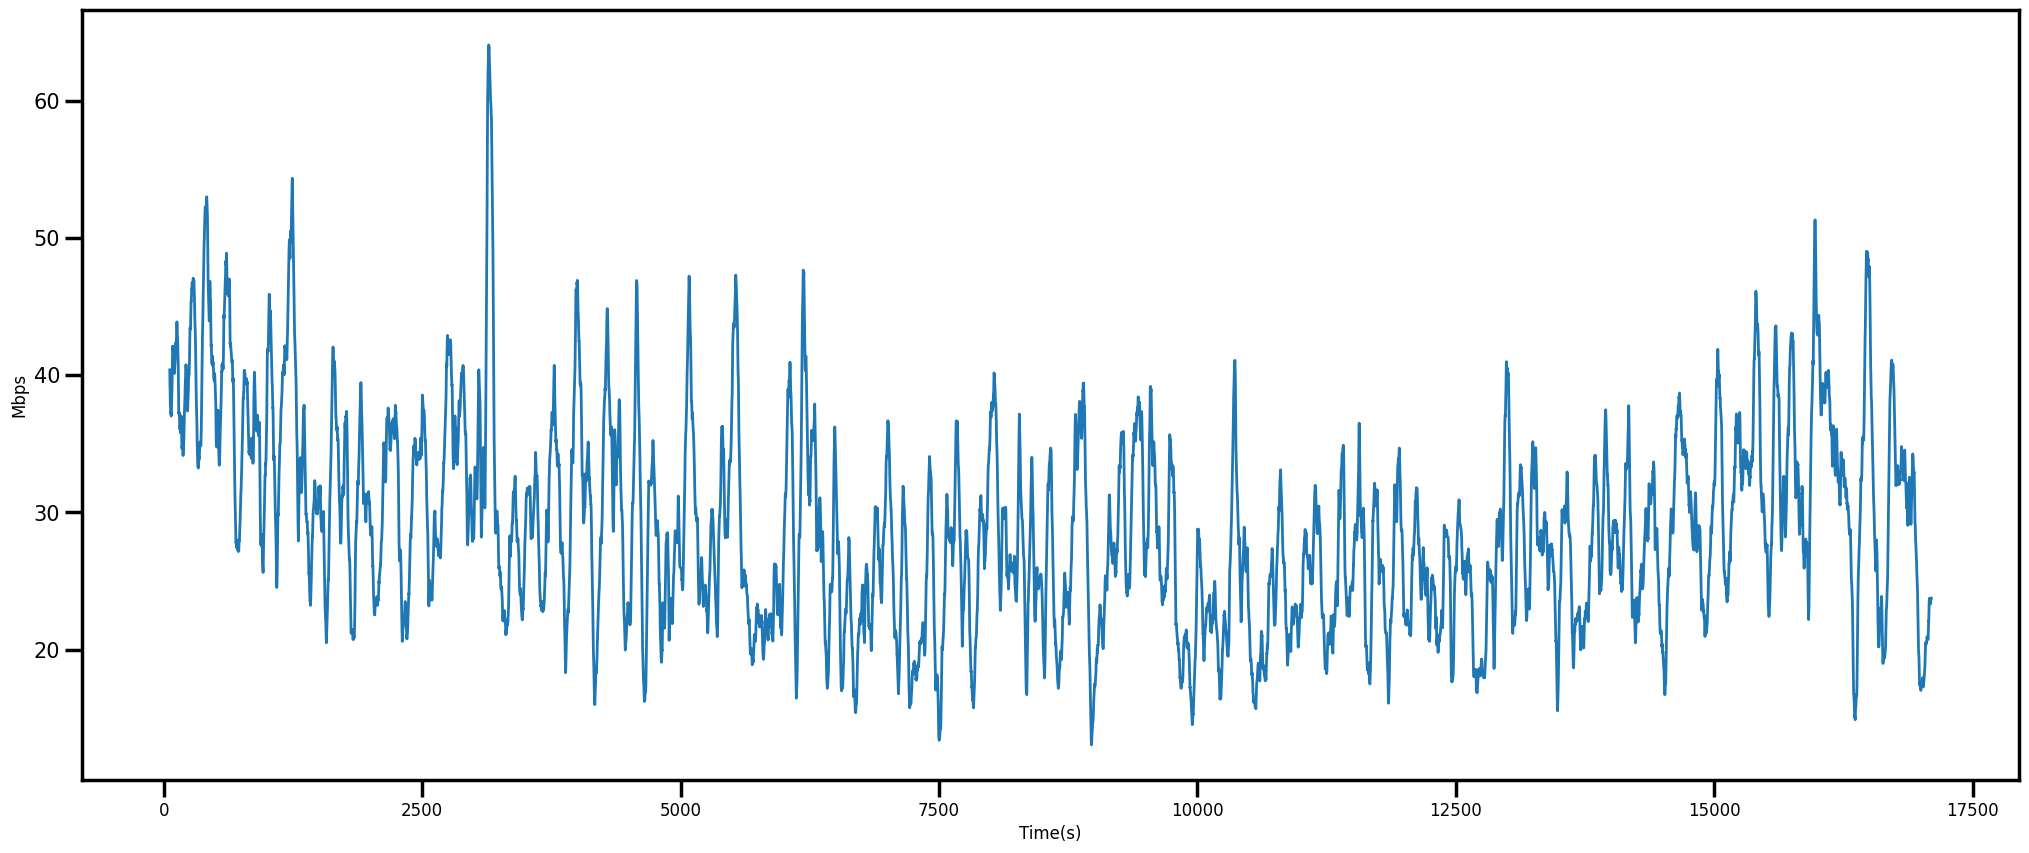

: 

In [ ]:
f=open("iperf-results-day.log")
lines=f.readlines()
time_series_map={}
for line in lines:
    line=line.strip()
    if "MBytes" in line:
        # [  6]   0.00-1.00   sec  10.5 MBytes  88.0 Mbits/sec
        raw = [i for i in line.split(" ") if "-" in i][0]
        ind = float(raw.split("-")[0])
        # print(line.split(" sec"))
        bytes_sent =  float(line.split(" sec")[-1].split("MBytes")[0].strip())
        time_series_map[ind] = bytes_sent*8
fig, axs = plt.subplots(figsize=(25,10))
# axs.plot(time_series_map.keys(), time_series_map.values())
df = pd.DataFrame.from_dict({"ts":[k for k in time_series_map.keys()], "val":[v for v in time_series_map.values()]})
roll_avg = df["val"].rolling(window=60).mean()
axs.plot(time_series_map.keys(), roll_avg)
axs.set_ylabel("Mbps")
axs.set_xlabel("Time(s)")

Exception: end it?

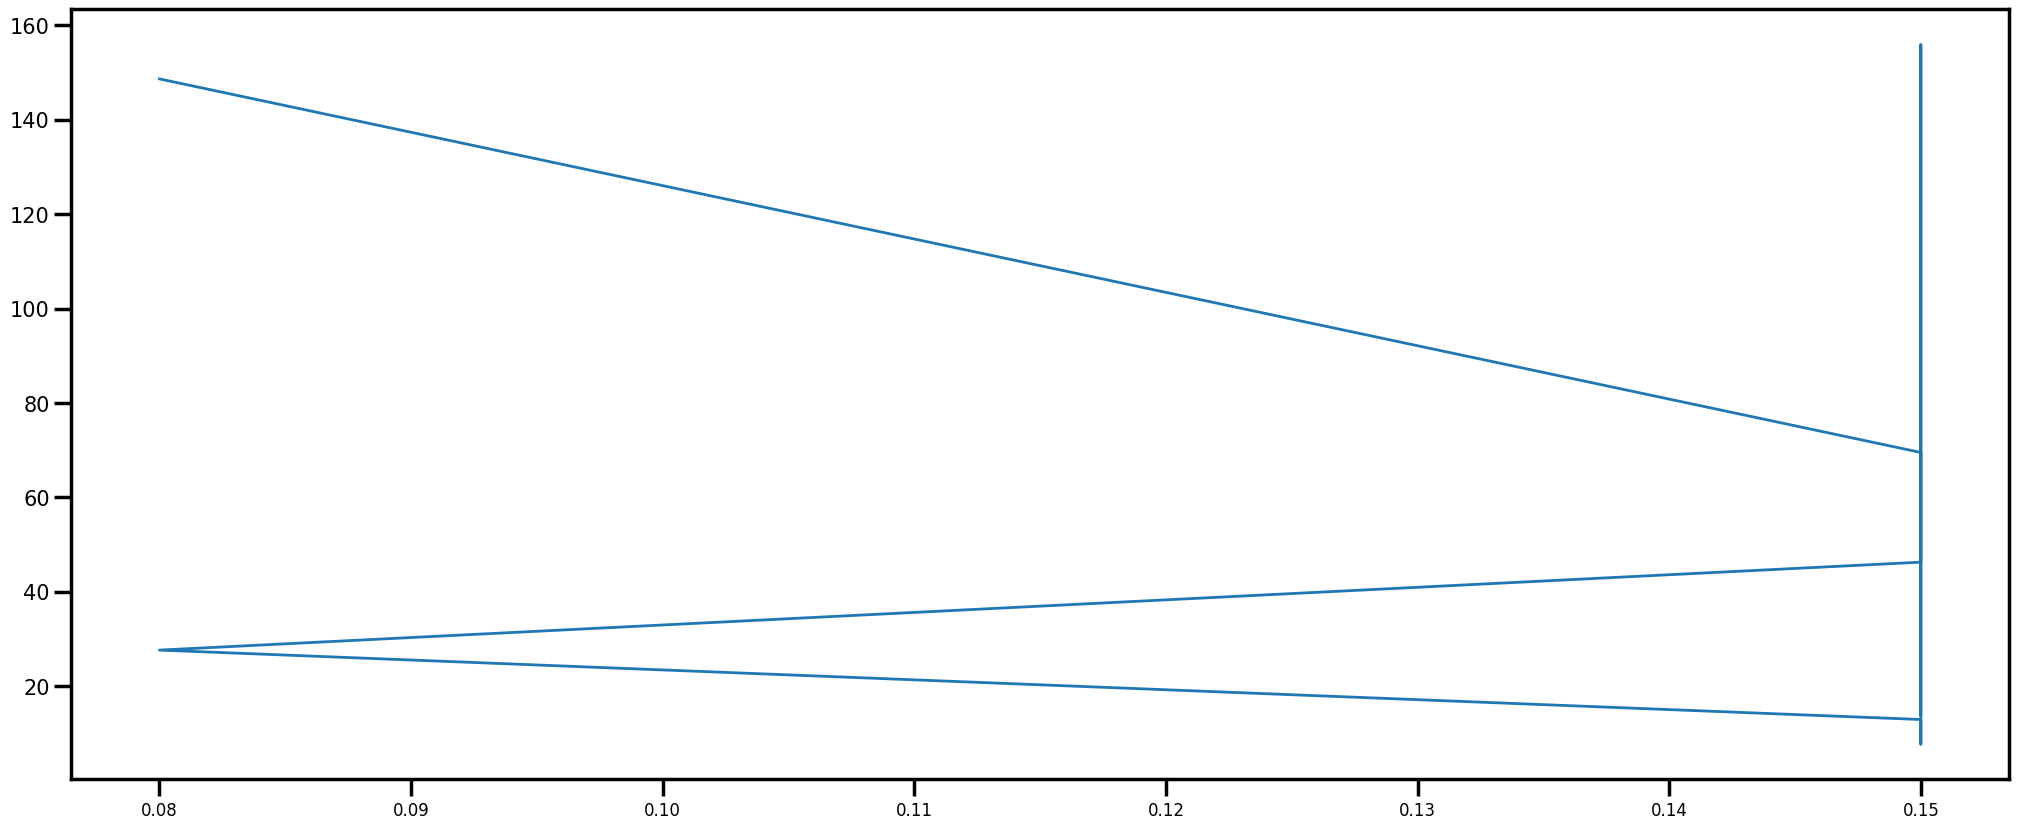

: 

In [ ]:
df = pd.read_csv("sim_vs_real.csv")
# df = pd.read_csv("sim_vs_real_azure.csv")
df = df[df["job_count"]!=6]
run_types = ["greedy", "only_best","only_best_limit", "only_comp", "only_comm", ]
# run_types = ["greedy", "only_best", "only_comp", "only_comm", ]
fig, evo_axs = plt.subplots(figsize=(25,10))
lats = df[(df["run_type"]==f"only_comp_real")&(df["arr_time"]==0.01)]["latency"].values
waits = df[(df["run_type"]==f"only_comp_real")&(df["arr_time"]==0.01)]["max_wait"].values
waits_and_arr = df[(df["run_type"]==f"only_comp_real")&(df["arr_time"]==0.01)]["max_wait_and_arr"].values
arr_t = [waits_and_arr[i] - waits[i] for i in range(len(waits))]

evo_axs.plot(arr_t, lats)
raise Exception("end it?")

fig, axs = plt.subplots(figsize=(25,10))
lats = df[df["run_type"]==f"only_best_real"]["latency"].values
thr = df[df["run_type"]==f"only_best_real"]["throughput"].values
waits = df[df["run_type"]==f"only_best_real"]["max_wait"].values
pair_wise = {lats[i]:thr[i] for i in range(len(thr))}
best_sorted_pair_wise = {k:v for k,v in sorted(pair_wise.items(), key=lambda x:x[0])}
best_lats = list(best_sorted_pair_wise.keys())
best_thr = list(best_sorted_pair_wise.values())
best_waits = [i for i in waits]





for r in run_types:
    # lats = df[df["run_type"]==f"{r}_sim"]["latency"].values
    # thr = df[df["run_type"]==f"{r}_sim"]["throughput"].values
    # pair_wise = {lats[i]:thr[i] for i in range(len(thr))}
    # sorted_pair_wise = {k:v for k,v in sorted(pair_wise.items(), key=lambda x:x[0])}
    # thr = sorted_pair_wise.keys()
    # lats = sorted_pair_wise.values()
    # if r=="greedy":
    #     axs.plot(lats, thr, marker="x", linestyle="--", color="blue")
    # elif r=="only_best":
    #     axs.plot(lats, thr, marker="^", linestyle="--", color="green")
    # else:
    #     axs.scatter(lats,thr, color="red", alpha=0.2)
    
    lats = df[df["run_type"]==f"{r}_real"]["latency"].values
    thr = df[df["run_type"]==f"{r}_real"]["throughput"].values
    waits = df[df["run_type"]==f"{r}_real"]["max_wait"].values
    waits_diff = [ abs(waits[i]-best_waits[i])/(best_waits[i] if best_waits[i]!=0 else 1) for i in range(len(waits))]
    pair_wise = {lats[i]:thr[i] for i in range(len(thr))}
    sorted_pair_wise = {k:v for k,v in sorted(pair_wise.items(), key=lambda x:x[0])}
    x = [abs(i-best_lats[ind])/best_lats[ind] for ind, i in enumerate(sorted_pair_wise.keys())]
    # x = [abs(i) for ind, i in enumerate(sorted_pair_wise.keys())]
    y = [abs(i-best_thr[ind])/best_thr[ind] for ind, i in enumerate(sorted_pair_wise.values())]
    print(round(np.mean(x)*100,2), round(np.mean(y)*100,2), round(np.mean(waits_diff)*100,2), np.mean(waits), np.max(waits), r)
    # y = [abs(i) for ind, i in enumerate(sorted_pair_wise.values())]
    # bar_axs.bar()
    if r=="greedy":
        # axs.plot(x, y, marker="x", linestyle="--", color="blue")
        axs.scatter(x, y, marker="x", linestyle="--", color="blue")
    elif r=="only_best":
        # axs.plot(x, y, marker="^", linestyle="--", color="green")
        axs.scatter(x, y, marker="^", linestyle="--", color="green")
    else:
        axs.scatter(x, y, color="red", alpha=0.5)
# axs.invert_yaxis()
# axs.invert_xaxis()
# axs.set_yscale("log")
# real_latencies = df[df["run_type"]=="greedy_real"]["latency"].values
# real_latencies_best = df[df["run_type"]=="only_best_real"]["latency"].values
# real_latencies_best_limited= df[df["run_type"]=="only_best_limited_real"]["latency"].values
# real_latencies_comp=df[df["run_type"]=="only_comp_real"]["latency"].values
# real_latencies_comm=df[df["run_type"]=="only_comm_real"]["latency"].values
# axs.plot()

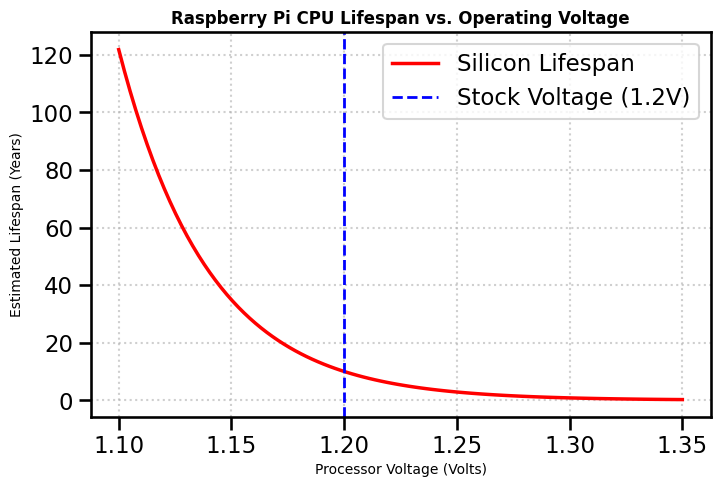

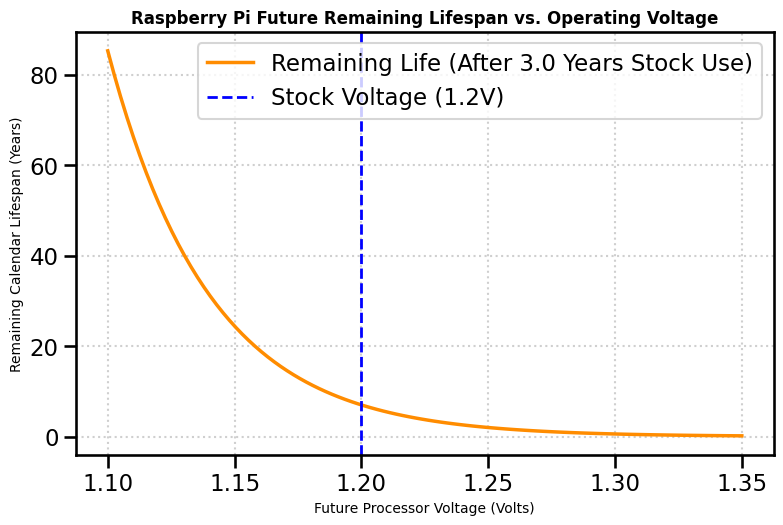

--- SILICON LIFE LOG ---
Phase 1: Ran 1.5 calendar years @ 1.20V. VAF:  1.00x. Added  1.50 wear-years.
Phase 2: Ran 0.5 calendar years @ 1.32V. VAF: 20.09x. Added 10.04 wear-years.
Phase 3: Ran 1.0 calendar years @ 1.15V. VAF:  0.29x. Added  0.29 wear-years.

--- CURRENT DEVICE STATUS ---
Total Calendar Age of Device: 3.0 years
Silicon Odometer (Total Wear): 11.83 out of 10.0 factory years
CRITICAL: The device has already exceeded its theoretical baseline life!


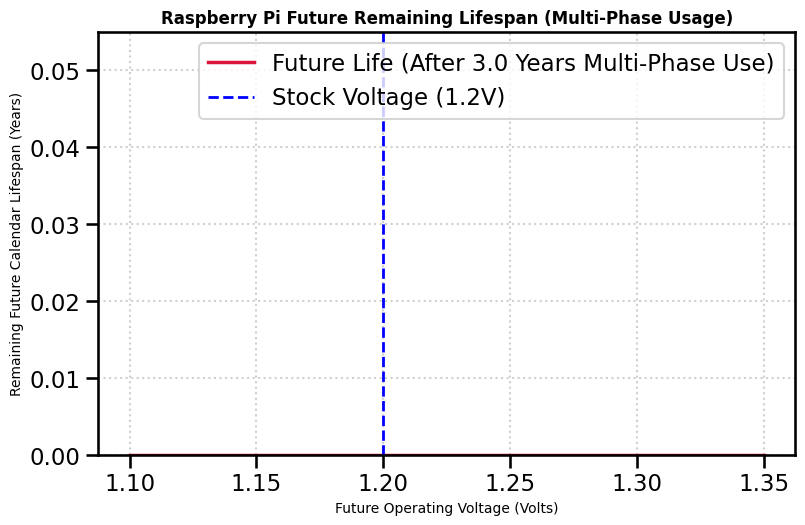

--- SILICON LIFE LOG ---
Phase 1: Ran 2.0 calendar years @ 1.20V. VAF:  1.00x. Added  2.00 wear-years.
Phase 2: Ran 0.1 calendar years @ 1.30V. VAF: 12.18x. Added  1.22 wear-years.
Phase 3: Ran 3.5 calendar years @ 1.15V. VAF:  0.29x. Added  1.00 wear-years.

--- CURRENT DEVICE STATUS ---
Total Calendar Age of Device: 5.6 years
Silicon Odometer (Total Wear): 4.22 out of 10.0 factory years
Remaining Health Budget:     5.78 standard years (57.8%)


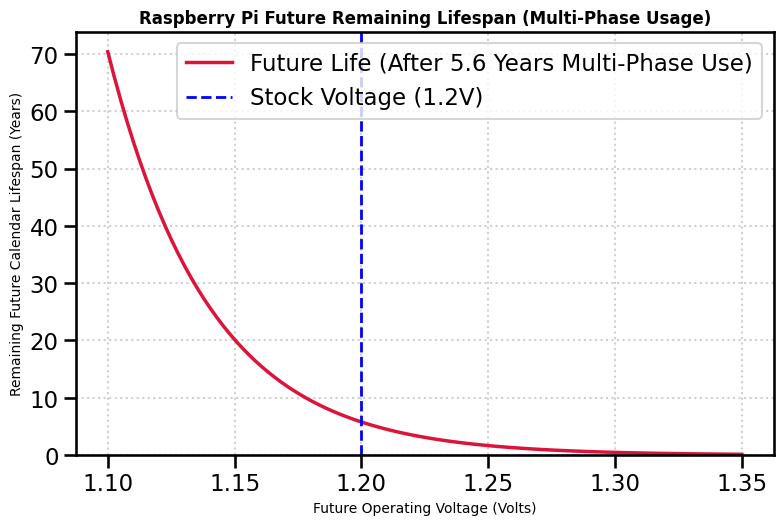

: 

In [ ]:
#silly sustainbility/aging cluster angle

import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the basic rules of our chip
V_use = 1.2 # Normal factory voltage
gamma = 25 # Silicon aging multiplier constant
baseline_years = 10.0 # Factory target lifespan

# 2. Create a smooth line of voltage points from 1.1V to 1.35V
voltages = np.linspace(1.1, 1.35, 100)

# 3. Calculate the Acceleration Factor and resulting lifespan
vaf = np.exp(gamma * (voltages - V_use))
lifespan = baseline_years / vaf

# 4. Draw the graph
plt.figure(figsize=(8, 5))
plt.plot(voltages, lifespan, color='red', linewidth=2.5, label='Silicon Lifespan')
plt.axvline(x=1.2, color='blue', linestyle='--', label='Stock Voltage (1.2V)')

# 5. Make the graph easy to read
plt.title('Raspberry Pi CPU Lifespan vs. Operating Voltage', fontsize=12, fontweight='bold')
plt.xlabel('Processor Voltage (Volts)', fontsize=10)
plt.ylabel('Estimated Lifespan (Years)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# 6. Show the final chart on your screen
plt.show()




import numpy as np
import matplotlib.pyplot as plt

# 1. Device Parameters
V_use = 1.2               # Stock factory voltage
gamma = 25                # Aging multiplier constant
baseline_lifespan = 10.0  # Total factory expected life (Years)

# 2. Historical Usage Input
years_already_used = 3.0  # CHANGE THIS: How many years the Pi has run at stock voltage

# Calculate remaining baseline life at stock voltage
remaining_baseline_life = baseline_lifespan - years_already_used

# 3. Generate Voltage Sweep (1.10V to 1.35V)
voltages = np.linspace(1.1, 1.35, 100)

# 4. Calculate VAF and Future Remaining Calendar Lifespan
# Remaining Lifespan = (Total Baseline Life - Past Standard Wear) / VAF
vaf = np.exp(gamma * (voltages - V_use))
remaining_lifespan = remaining_baseline_life / vaf

# Force remaining life to 0 if the math pushes it negative (device already dead)
remaining_lifespan = np.clip(remaining_lifespan, 0, None)

# 5. Plotting the Remaining Lifespan Curve
plt.figure(figsize=(9, 5.5))
plt.plot(voltages, remaining_lifespan, color='darkorange', linewidth=2.5, 
         label=f'Remaining Life (After {years_already_used} Years Stock Use)')
plt.axvline(x=1.2, color='blue', linestyle='--', label='Stock Voltage (1.2V)')

# 6. Formatting the Chart
plt.title('Raspberry Pi Future Remaining Lifespan vs. Operating Voltage', fontsize=12, fontweight='bold')
plt.xlabel('Future Processor Voltage (Volts)', fontsize=10)
plt.ylabel('Remaining Calendar Lifespan (Years)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Display the chart
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# 1. Device Core Parameters
V_use = 1.2               # Stock factory voltage (Volts)
gamma = 25                # Aging multiplier constant
baseline_lifespan = 10.0  # Factory expected life from day 0 (Years)

# 2. Historical Usage Phases (Timeline Input)
# Format: (Actual Years Run, Voltage Applied During Phase)
usage_history = [
    (1.5, 1.20),   # Phase 1: 1.5 years at stock voltage
    (0.5, 1.32),   # Phase 2: 0.5 years heavily overclocked
    (1.0, 1.15)    # Phase 3: 1.0 year heavily under-volted
]

# 3. Calculate Cumulative Damage (Odometer Reading)
total_equivalent_wear = 0.0
total_actual_years = 0.0

print("--- SILICON LIFE LOG ---")
for i, (years, voltage) in enumerate(usage_history, 1):
    # Calculate Voltage Acceleration Factor for this phase
    phase_vaf = np.exp(gamma * (voltage - V_use))
    # Calculate equivalent "wear hours" accumulated
    equivalent_wear = years * phase_vaf
    
    total_actual_years += years
    total_equivalent_wear += equivalent_wear
    
    print(f"Phase {i}: Ran {years:3.1f} calendar years @ {voltage:.2f}V. "
          f"VAF: {phase_vaf:5.2f}x. Added {equivalent_wear:5.2f} wear-years.")

# 4. Calculate Device Health Status Today
remaining_baseline_budget = baseline_lifespan - total_equivalent_wear

print("\n--- CURRENT DEVICE STATUS ---")
print(f"Total Calendar Age of Device: {total_actual_years:.1f} years")
print(f"Silicon Odometer (Total Wear): {total_equivalent_wear:.2f} out of {baseline_lifespan:.1f} factory years")

if remaining_baseline_budget <= 0:
    print("CRITICAL: The device has already exceeded its theoretical baseline life!")
    remaining_baseline_budget = 0.0
else:
    health_percentage = (remaining_baseline_budget / baseline_lifespan) * 100
    print(f"Remaining Health Budget:     {remaining_baseline_budget:.2f} standard years ({health_percentage:.1f}%)")

# 5. Predict Future Remaining Lifespan Sweep
voltages = np.linspace(1.1, 1.35, 100)
future_vaf = np.exp(gamma * (voltages - V_use))
future_remaining_lifespan = remaining_baseline_budget / future_vaf

# 6. Plotting the Multi-Phase Result
plt.figure(figsize=(9, 5.5))
plt.plot(voltages, future_remaining_lifespan, color='crimson', linewidth=2.5, 
         label=f'Future Life (After {total_actual_years:.1f} Years Multi-Phase Use)')
plt.axvline(x=1.2, color='blue', linestyle='--', label='Stock Voltage (1.2V)')

plt.title('Raspberry Pi Future Remaining Lifespan (Multi-Phase Usage)', fontsize=12, fontweight='bold')
plt.xlabel('Future Operating Voltage (Volts)', fontsize=10)
plt.ylabel('Remaining Future Calendar Lifespan (Years)', fontsize=10)
plt.ylim(bottom=0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()


import numpy as np
import matplotlib.pyplot as plt

# 1. Device Core Parameters
V_use = 1.2               # Stock factory voltage (Volts)
gamma = 25                # Aging multiplier constant
baseline_lifespan = 10.0  # Factory expected life from day 0 (Years)

# 2. FIXED Historical Usage Phases (Timeline Input)
# Total wear here equals ~4.25 years, leaving plenty of baseline life left!
usage_history = [
    (2.0, 1.20),   # Phase 1: 2.0 years at stock voltage (2.0 years wear)
    (0.1, 1.30),   # Phase 2: Only 0.1 years (approx 1 month) overclocked (1.2 years wear)
    (3.5, 1.15)    # Phase 3: 3.5 years heavily under-volted (~1.05 years wear)
]

# 3. Calculate Cumulative Damage (Odometer Reading)
total_equivalent_wear = 0.0
total_actual_years = 0.0

print("--- SILICON LIFE LOG ---")
for i, (years, voltage) in enumerate(usage_history, 1):
    phase_vaf = np.exp(gamma * (voltage - V_use))
    equivalent_wear = years * phase_vaf
    
    total_actual_years += years
    total_equivalent_wear += equivalent_wear
    
    print(f"Phase {i}: Ran {years:3.1f} calendar years @ {voltage:.2f}V. "
          f"VAF: {phase_vaf:5.2f}x. Added {equivalent_wear:5.2f} wear-years.")

# 4. Calculate Device Health Status Today
remaining_baseline_budget = baseline_lifespan - total_equivalent_wear

print("\n--- CURRENT DEVICE STATUS ---")
print(f"Total Calendar Age of Device: {total_actual_years:.1f} years")
print(f"Silicon Odometer (Total Wear): {total_equivalent_wear:.2f} out of {baseline_lifespan:.1f} factory years")

if remaining_baseline_budget <= 0:
    print("\n⚠️ WARNING: Remaining budget is negative. The plot will be FLAT AT ZERO.")
    remaining_baseline_budget = 0.0
else:
    health_percentage = (remaining_baseline_budget / baseline_lifespan) * 100
    print(f"Remaining Health Budget:     {remaining_baseline_budget:.2f} standard years ({health_percentage:.1f}%)")

# 5. Predict Future Remaining Lifespan Sweep
voltages = np.linspace(1.1, 1.35, 100)
future_vaf = np.exp(gamma * (voltages - V_use))
future_remaining_lifespan = remaining_baseline_budget / future_vaf

# 6. Plotting the Multi-Phase Result
plt.figure(figsize=(9, 5.5))
plt.plot(voltages, future_remaining_lifespan, color='crimson', linewidth=2.5, 
         label=f'Future Life (After {total_actual_years:.1f} Years Multi-Phase Use)')
plt.axvline(x=1.2, color='blue', linestyle='--', label='Stock Voltage (1.2V)')

plt.title('Raspberry Pi Future Remaining Lifespan (Multi-Phase Usage)', fontsize=12, fontweight='bold')
plt.xlabel('Future Operating Voltage (Volts)', fontsize=10)
plt.ylabel('Remaining Future Calendar Lifespan (Years)', fontsize=10)
plt.ylim(bottom=0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()



--- Corrected Wear Analysis (Analog Devices UG-311) ---
Formula Used:        VAF = exp[ 6.0 * (V_overclock - V_stock) ]
Overclock Voltage:   1.250V (over_voltage=2)
True Accel Factor:   Silicon degrades 1.35x faster under overclock.
-------------------------------------------------------
Total Silicon Wear Accumulated: 4.02 Wear-Years
True Calendar Time Remaining:   5.17 Years (if overclocked)


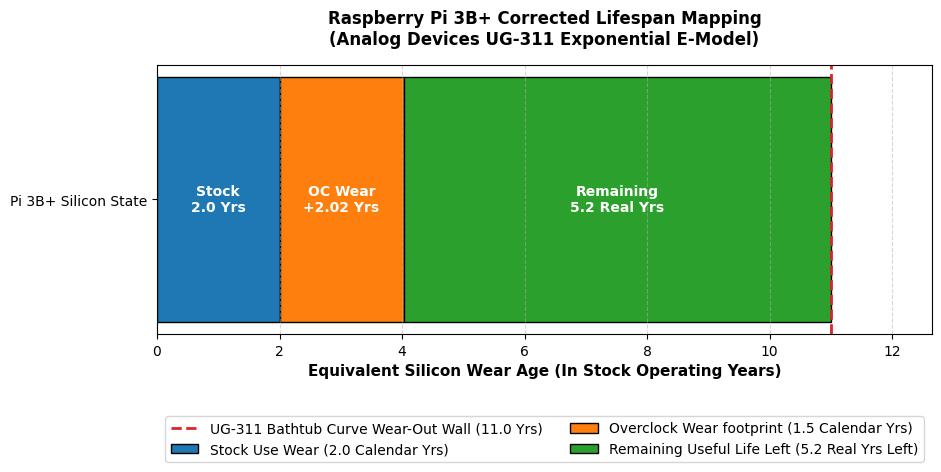

: 

In [ ]:
#maybe correct one?
import numpy as np
import matplotlib.pyplot as plt

def plot_ug311_bathtub_limit(
    years_stock_used=2.0,       # Calendar years run at stock 1.20V
    years_overclocked_used=1.5, # Calendar years run overvolted
    over_voltage_setting=2,    # config.txt over_voltage (+0.025V per step)
    design_life_wall_years=11.0,# Bathtub curve useful life limit (28nm node)
    gamma=6.0                   # VAF constant (γ) per semiconductor standards
):
    """
    Calculates remaining life using the exact Exponential Voltage Acceleration 
    formula sourced from Analog Devices Reliability Handbook (UG-311, Eq. 2).
    """
    v_stock = 1.25
    # 1. Calculate the exact target overclock core voltage 
    v_overclock = v_stock + (over_voltage_setting * 0.025)
    
    # 2. Apply UG-311 Formula: VAF = exp[ gamma * (V_test - V_use) ]
    vaf_overclock = np.exp(gamma * (v_overclock - v_stock))
    
    # 3. Translate real timeline into accumulated "Wear Footprint Years"
    wear_from_stock = years_stock_used * 1.0
    wear_from_overclock = years_overclocked_used * vaf_overclock
    total_wear_accumulated = wear_from_stock + wear_from_overclock
    
    # 4. Map against the physical bathtub wall boundary
    remaining_stock_wear_years = design_life_wall_years - total_wear_accumulated
    
    # If the user keeps the overclock active going forward, calculate remaining calendar time
    remaining_calendar_years_overclocked = max(0.0, remaining_stock_wear_years / vaf_overclock)
    
    # Print accurate math breakdown to console
    print(f"--- Corrected Wear Analysis (Analog Devices UG-311) ---")
    print(f"Formula Used:        VAF = exp[ {gamma} * (V_overclock - V_stock) ]")
    print(f"Overclock Voltage:   {v_overclock:.3f}V (over_voltage={over_voltage_setting})")
    print(f"True Accel Factor:   Silicon degrades {vaf_overclock:.2f}x faster under overclock.")
    print(f"-------------------------------------------------------")
    print(f"Total Silicon Wear Accumulated: {total_wear_accumulated:.2f} Wear-Years")
    print(f"True Calendar Time Remaining:   {remaining_calendar_years_overclocked:.2f} Years (if overclocked)")

    # 5. Visual Chart Generation
    fig, ax = plt.subplots(figsize=(10, 3.5))
    
    ax.barh('Pi 3B+ Silicon State', wear_from_stock, color='#1f77b4', edgecolor='black', 
            label=f'Stock Use Wear ({years_stock_used:.1f} Calendar Yrs)')
    ax.barh('Pi 3B+ Silicon State', wear_from_overclock, left=wear_from_stock, color='#ff7f0e', edgecolor='black', 
            label=f'Overclock Wear footprint ({years_overclocked_used:.1f} Calendar Yrs)')
    
    if remaining_stock_wear_years > 0:
        ax.barh('Pi 3B+ Silicon State', remaining_stock_wear_years, left=total_wear_accumulated, color='#2ca02c', edgecolor='black', 
                label=f'Remaining Useful Life Left ({remaining_calendar_years_overclocked:.1f} Real Yrs Left)')
        
    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=2, 
               label=f'UG-311 Bathtub Curve Wear-Out Wall ({design_life_wall_years:.1f} Yrs)')
    
    ax.set_xlabel('Equivalent Silicon Wear Age (In Stock Operating Years)', fontsize=11, fontweight='bold')
    ax.set_title('Raspberry Pi 3B+ Corrected Lifespan Mapping\n(Analog Devices UG-311 Exponential E-Model)', fontsize=12, pad=15, fontweight='bold')
    ax.set_xlim(0, design_life_wall_years * 1.15)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2, frameon=True)
    
    # Text overlays
    ax.text(wear_from_stock / 2, 0, f"Stock\n{years_stock_used:.1f} Yrs", ha='center', va='center', color='white', fontweight='bold')
    ax.text(wear_from_stock + (wear_from_overclock / 2), 0, f"OC Wear\n+{wear_from_overclock:.2f} Yrs", ha='center', va='center', color='white', fontweight='bold')
    if remaining_stock_wear_years > 0:
        ax.text(total_wear_accumulated + (remaining_stock_wear_years / 2), 0, f"Remaining\n{remaining_calendar_years_overclocked:.1f} Real Yrs", ha='center', va='center', color='white', fontweight='bold')
        
    # plt.tight_layout()
    plt.show()

# Run the correct formula simulation
plot_ug311_bathtub_limit()


--- Customized vcgencmd Lifespan Profiling ---
Base Stock Voltage:     1.310V
Overclock Target:       1.360V
Calculated Wear Rate:   Degrading 1.35x faster than your base baseline.
-----------------------------------------------
Calendar Years Left:    6.15 Years


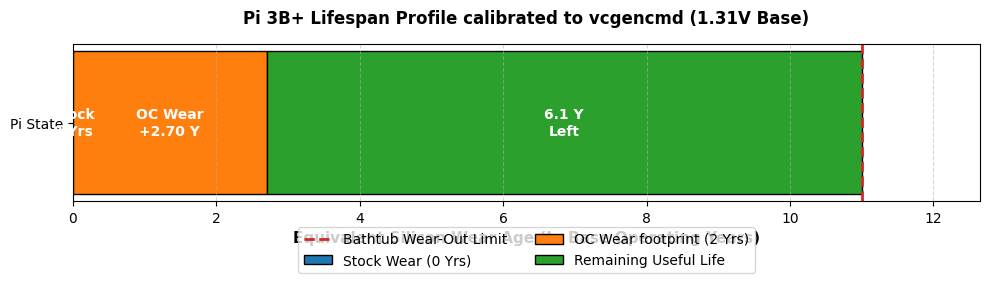

: 

In [ ]:
#might be final correct now?
import numpy as np
import matplotlib.pyplot as plt

def plot_custom_vcgencmd_limit(
    v_stock_read=1.306,         # Input what vcgencmd says WITHOUT overclocking
    over_voltage_setting=2,     # Your config.txt setting (+0.025V per step)
    years_stock_used=2.0,       # Past years run at standard stock setup
    years_overclocked_used=1.5, # Past years run with the overclock active
    design_life_wall_years=11.0,# Fixed Bathtub curve end-of-life wall for 28nm
    gamma=6.0                   # Sourced from Analog Devices UG-311
):
    """
    Maps remaining life against the 11-year bathtub curve limit using the
    exact core voltages returned by your device's vcgencmd interface.
    """
    # 1. Calculate actual overvolted setting based on your live stock baseline
    v_overclock_calc = v_stock_read + (over_voltage_setting * 0.025)
    
    # 2. Compute true UG-311 exponential acceleration factor
    vaf_overclock = np.exp(gamma * (v_overclock_calc - v_stock_read))
    
    # 3. Scale calendar hours into integrated degradation footprints
    wear_from_stock = years_stock_used * 1.0
    wear_from_overclock = years_overclocked_used * vaf_overclock
    total_wear_accumulated = wear_from_stock + wear_from_overclock
    
    # 4. Extract true remaining timeline values
    remaining_stock_wear_years = design_life_wall_years - total_wear_accumulated
    remaining_calendar_years_overclocked = max(0.0, remaining_stock_wear_years / vaf_overclock)
    
    # Text output confirmation
    print(f"--- Customized vcgencmd Lifespan Profiling ---")
    print(f"Base Stock Voltage:     {v_stock_read:.3f}V")
    print(f"Overclock Target:       {v_overclock_calc:.3f}V")
    print(f"Calculated Wear Rate:   Degrading {vaf_overclock:.2f}x faster than your base baseline.")
    print(f"-----------------------------------------------")
    print(f"Calendar Years Left:    {remaining_calendar_years_overclocked:.2f} Years")

    # 5. Graph rendering
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.barh('Pi State', wear_from_stock, color='#1f77b4', edgecolor='black', label=f'Stock Wear ({years_stock_used} Yrs)')
    ax.barh('Pi State', wear_from_overclock, left=wear_from_stock, color='#ff7f0e', edgecolor='black', label=f'OC Wear footprint ({years_overclocked_used} Yrs)')
    
    if remaining_stock_wear_years > 0:
        ax.barh('Pi State', remaining_stock_wear_years, left=total_wear_accumulated, color='#2ca02c', edgecolor='black', label='Remaining Useful Life')
        
    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=2, label='Bathtub Wear-Out Limit')
    
    ax.set_xlabel('Equivalent Silicon Wear Age (In Base Operating Years)', fontsize=11, fontweight='bold')
    ax.set_title(f'Pi 3B+ Lifespan Profile calibrated to vcgencmd ({v_stock_read}V Base)', fontsize=12, pad=15, fontweight='bold')
    ax.set_xlim(0, design_life_wall_years * 1.15)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2)
    
    ax.text(wear_from_stock / 2, 0, f"Stock\n{years_stock_used} Yrs", ha='center', va='center', color='white', fontweight='bold')
    ax.text(wear_from_stock + (wear_from_overclock / 2), 0, f"OC Wear\n+{wear_from_overclock:.2f} Y", ha='center', va='center', color='white', fontweight='bold')
    if remaining_stock_wear_years > 0:
        ax.text(total_wear_accumulated + (remaining_stock_wear_years / 2), 0, f"{remaining_calendar_years_overclocked:.1f} Y\nLeft", ha='center', va='center', color='white', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# Run the updated profile with your real world readings
plot_custom_vcgencmd_limit(v_stock_read=1.31, years_overclocked_used=2, years_stock_used=0)


--- Duty-Cycle Lifespan Analysis ---
Stock Baseline:     1.310V  | Overclock Target: 1.460V
Degradation Rate:   2.46x faster under overclock.
Usage per Day:      12.0 hours/day
Duty Cycle:         0.500
Stock-Equivalent Used: 2.84 years
True Time Left:     6.63 years remaining
Achieved Lifetime:  10.13 calendar years


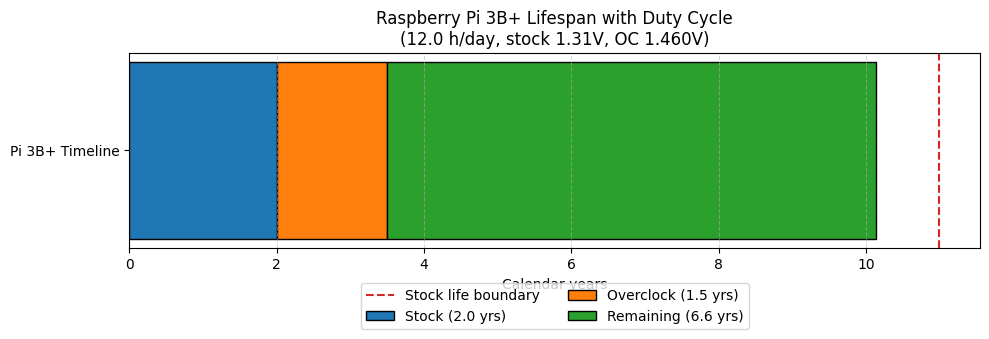

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_true_calendar_lifespan(
    years_stock_used=2.0,
    years_overclocked_used=1.5,
    usage_hours_per_day=24.0,
    over_voltage_setting=2,
    v_stock_read=1.31,
    design_life_wall_years=11.0,
    gamma=6.0
):
    v_overclock = v_stock_read + (over_voltage_setting * 0.025)
    vaf = np.exp(gamma * (v_overclock - v_stock_read))

    duty_cycle = np.clip(usage_hours_per_day / 24.0, 0.0, 1.0)

    stock_equiv_used = (
        years_stock_used * duty_cycle +
        years_overclocked_used * duty_cycle * vaf
    )

    remaining_stock_equiv = max(0.0, design_life_wall_years - stock_equiv_used)

    if years_overclocked_used > 0 and duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / (duty_cycle * vaf)
    elif duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / duty_cycle
    else:
        remaining_calendar_years_left = float('inf')

    achieved_calendar_lifespan = years_stock_used + years_overclocked_used + remaining_calendar_years_left
    end_of_life_reached = remaining_stock_equiv <= 0

    print("--- Duty-Cycle Lifespan Analysis ---")
    print(f"Stock Baseline:     {v_stock_read:.3f}V  | Overclock Target: {v_overclock:.3f}V")
    print(f"Degradation Rate:   {vaf:.2f}x faster under overclock.")
    print(f"Usage per Day:      {usage_hours_per_day:.1f} hours/day")
    print(f"Duty Cycle:         {duty_cycle:.3f}")
    print(f"Stock-Equivalent Used: {stock_equiv_used:.2f} years")

    if end_of_life_reached:
        print("Status:             End-of-life reached before the requested usage period finished.")
        print("True Time Left:     0.00 years remaining")
    else:
        if np.isfinite(remaining_calendar_years_left):
            print(f"True Time Left:     {remaining_calendar_years_left:.2f} years remaining")
        else:
            print("True Time Left:     undefined while fully idle")

    print(f"Achieved Lifetime:  {achieved_calendar_lifespan:.2f} calendar years")

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.barh('Pi 3B+ Timeline', years_stock_used, color='#1f77b4', edgecolor='black',
            label=f'Stock ({years_stock_used:.1f} yrs)')

    ax.barh('Pi 3B+ Timeline', years_overclocked_used, left=years_stock_used,
            color='#ff7f0e', edgecolor='black',
            label=f'Overclock ({years_overclocked_used:.1f} yrs)')

    if np.isfinite(remaining_calendar_years_left) and remaining_calendar_years_left > 0:
        ax.barh('Pi 3B+ Timeline', remaining_calendar_years_left,
                left=years_stock_used + years_overclocked_used,
                color='#2ca02c', edgecolor='black',
                label=f'Remaining ({remaining_calendar_years_left:.1f} yrs)')

    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=1.5,
               label='Stock life boundary')

    ax.set_xlabel('Calendar years')
    ax.set_title(
        f'Raspberry Pi 3B+ Lifespan with Duty Cycle\n'
        f'({usage_hours_per_day:.1f} h/day, stock {v_stock_read}V, OC {v_overclock:.3f}V)'
    )
    ax.set_xlim(0, max(design_life_wall_years * 1.05, years_stock_used + years_overclocked_used + 1))
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2)

    plt.tight_layout()
    plt.show()
plot_true_calendar_lifespan(usage_hours_per_day=12, over_voltage_setting=6)

--- Duty-Cycle Lifespan Analysis ---
Stock Baseline:     1.310V  | Overclock Target: 1.460V
Degradation Rate:   2.46x faster under overclock.
Usage per Minute:   5.0 seconds/minute
Duty Cycle:         0.083
Stock-Equivalent Used: 2.22 years
True Time Left:     42.85 years remaining
Achieved Lifetime:  54.85 calendar years


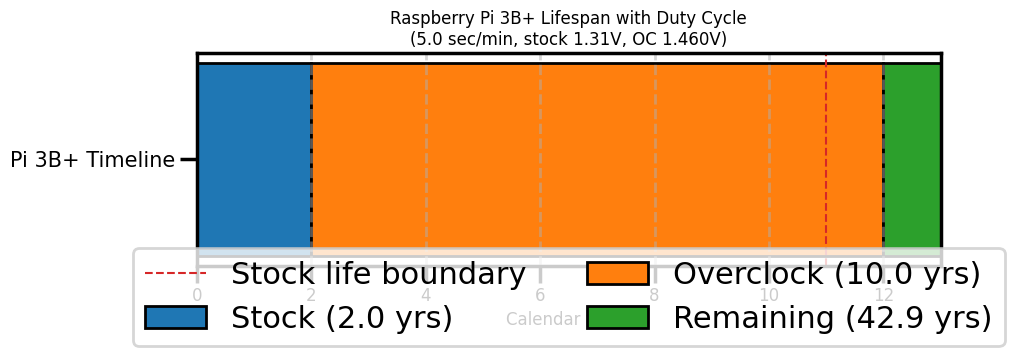

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_true_calendar_lifespan(
    years_stock_used=2.0,
    years_overclocked_used=1.5,
    seconds_used_per_minute=60.0,
    over_voltage_setting=2,
    v_stock_read=1.31,
    design_life_wall_years=11.0,
    gamma=6.0
):
    v_overclock = v_stock_read + (over_voltage_setting * 0.025)
    vaf = np.exp(gamma * (v_overclock - v_stock_read))

    duty_cycle = np.clip(seconds_used_per_minute / 60.0, 0.0, 1.0)
    # duty_cycle_s_per_day = (seconds_used_per_minute/60)
    # duty_cycle_s_per_year = duty_cycle_s_per_day*
    stock_equiv_used = (
        years_stock_used * duty_cycle +
        years_overclocked_used * duty_cycle * vaf
    )

    remaining_stock_equiv = max(0.0, design_life_wall_years - stock_equiv_used)

    if years_overclocked_used > 0 and duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / (duty_cycle * vaf)
    elif duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / duty_cycle
    else:
        remaining_calendar_years_left = float('inf')

    achieved_calendar_lifespan = years_stock_used + years_overclocked_used + remaining_calendar_years_left
    end_of_life_reached = remaining_stock_equiv <= 0

    print("--- Duty-Cycle Lifespan Analysis ---")
    print(f"Stock Baseline:     {v_stock_read:.3f}V  | Overclock Target: {v_overclock:.3f}V")
    print(f"Degradation Rate:   {vaf:.2f}x faster under overclock.")
    print(f"Usage per Minute:   {seconds_used_per_minute:.1f} seconds/minute")
    print(f"Duty Cycle:         {duty_cycle:.3f}")
    print(f"Stock-Equivalent Used: {stock_equiv_used:.2f} years")

    if end_of_life_reached:
        print("Status:             End-of-life reached before the requested usage period finished.")
        print("True Time Left:     0.00 years remaining")
    else:
        if np.isfinite(remaining_calendar_years_left):
            print(f"True Time Left:     {remaining_calendar_years_left:.2f} years remaining")
        else:
            print("True Time Left:     undefined while fully idle")

    print(f"Achieved Lifetime:  {achieved_calendar_lifespan:.2f} calendar years")

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.barh('Pi 3B+ Timeline', years_stock_used, color='#1f77b4', edgecolor='black',
            label=f'Stock ({years_stock_used:.1f} yrs)')

    ax.barh('Pi 3B+ Timeline', years_overclocked_used, left=years_stock_used,
            color='#ff7f0e', edgecolor='black',
            label=f'Overclock ({years_overclocked_used:.1f} yrs)')

    if np.isfinite(remaining_calendar_years_left) and remaining_calendar_years_left > 0:
        ax.barh('Pi 3B+ Timeline', remaining_calendar_years_left,
                left=years_stock_used + years_overclocked_used,
                color='#2ca02c', edgecolor='black',
                label=f'Remaining ({remaining_calendar_years_left:.1f} yrs)')

    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=1.5,
               label='Stock life boundary')

    ax.set_xlabel('Calendar years')
    ax.set_title(
        f'Raspberry Pi 3B+ Lifespan with Duty Cycle\n'
        f'({seconds_used_per_minute:.1f} sec/min, stock {v_stock_read}V, OC {v_overclock:.3f}V)'
    )
    ax.set_xlim(0, max(design_life_wall_years * 1.05, years_stock_used + years_overclocked_used + 1))
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2)

    plt.tight_layout()
    plt.show()


plot_true_calendar_lifespan(seconds_used_per_minute=5, over_voltage_setting=6, years_overclocked_used=10)

--- Duty-Cycle Lifespan Analysis ---
Stock Voltage:          1.310V
Overclock Voltage:      1.460V
Undervoltage Voltage:   1.200V
OC Degradation:         0.0000 vs 0.0000
UV Degradation:         0.5367 vs 0.8333
Overclock VAF:          1.82x faster.
Undervoltage VAF:       0.64x faster.
Usage per Minute:       5.0 seconds/minute
Duty Cycle:             0.083
Stock-Equivalent Used:  0.70 years
True Time Left:         123.56 years remaining
Achieved Lifetime:      135.56 calendar years


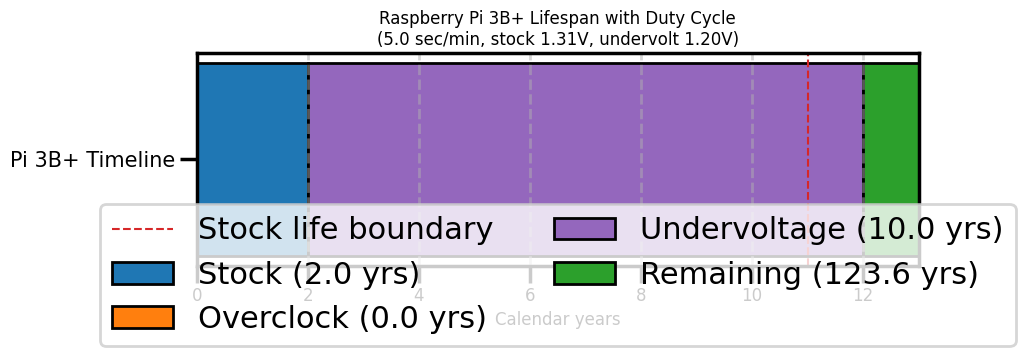

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_true_calendar_lifespan(
    years_stock_used=2.0,
    years_overclocked_used=1.5,
    years_undervolted_used=0.5,
    seconds_used_per_minute=60.0,
    over_voltage_setting=2,
    stock_voltage=1.31,
    undervoltage_voltage=1.20,
    voltage_gamma=4.0,
    design_life_wall_years=11.0
):
    v_overclock = stock_voltage + (over_voltage_setting * 0.025)

    oc_ratio = v_overclock - max(stock_voltage, 1e-9)
    # uv_ratio = stock_voltage / max(undervoltage_voltage, 1e-9)
    uv_ratio =(undervoltage_voltage -  max(stock_voltage, 1e-9))

    # vaf_oc = np.exp(voltage_gamma * max(0.0, oc_ratio))
    vaf_oc = np.exp(voltage_gamma * oc_ratio)
    # vaf_uv = np.exp(voltage_gamma * max(0.0, uv_ratio))
    vaf_uv = np.exp(voltage_gamma * uv_ratio)

    duty_cycle = np.clip(seconds_used_per_minute / 60.0, 0.0, 1.0)

    stock_equiv_used = (
        years_stock_used * duty_cycle +
        years_overclocked_used * duty_cycle * vaf_oc +
        years_undervolted_used * duty_cycle * vaf_uv
    )

    remaining_stock_equiv = max(0.0, design_life_wall_years - stock_equiv_used)

    if duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / duty_cycle
    else:
        remaining_calendar_years_left = float('inf')

    achieved_calendar_lifespan = (
        years_stock_used +
        years_overclocked_used +
        years_undervolted_used +
        (0 if not np.isfinite(remaining_calendar_years_left) else remaining_calendar_years_left)
    )

    end_of_life_reached = remaining_stock_equiv <= 0

    print("--- Duty-Cycle Lifespan Analysis ---")
    print(f"Stock Voltage:          {stock_voltage:.3f}V")
    print(f"Overclock Voltage:      {v_overclock:.3f}V")
    print(f"Undervoltage Voltage:   {undervoltage_voltage:.3f}V")
    print(f"OC Degradation:         {years_overclocked_used * duty_cycle * vaf_oc:.4f} vs {years_overclocked_used * duty_cycle:.4f}")
    print(f"UV Degradation:         {years_undervolted_used * duty_cycle * vaf_uv:.4f} vs {years_undervolted_used * duty_cycle :.4f}")
    print(f"Overclock VAF:          {vaf_oc:.2f}x faster.")
    print(f"Undervoltage VAF:       {vaf_uv:.2f}x faster.")
    print(f"Usage per Minute:       {seconds_used_per_minute:.1f} seconds/minute")
    print(f"Duty Cycle:             {duty_cycle:.3f}")
    print(f"Stock-Equivalent Used:  {stock_equiv_used:.2f} years")

    if end_of_life_reached:
        print("Status:                 End-of-life reached before the requested usage period finished.")
        print("True Time Left:         0.00 years remaining")
    else:
        if np.isfinite(remaining_calendar_years_left):
            print(f"True Time Left:         {remaining_calendar_years_left:.2f} years remaining")
        else:
            print("True Time Left:         undefined while fully idle")

    print(f"Achieved Lifetime:      {achieved_calendar_lifespan:.2f} calendar years")

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.barh('Pi 3B+ Timeline', years_stock_used, color='#1f77b4', edgecolor='black',
            label=f'Stock ({years_stock_used:.1f} yrs)')
    ax.barh('Pi 3B+ Timeline', years_overclocked_used, left=years_stock_used,
            color='#ff7f0e', edgecolor='black',
            label=f'Overclock ({years_overclocked_used:.1f} yrs)')
    ax.barh('Pi 3B+ Timeline', years_undervolted_used,
            left=years_stock_used + years_overclocked_used,
            color='#9467bd', edgecolor='black',
            label=f'Undervoltage ({years_undervolted_used:.1f} yrs)')

    if np.isfinite(remaining_calendar_years_left) and remaining_calendar_years_left > 0:
        ax.barh('Pi 3B+ Timeline', remaining_calendar_years_left,
                left=years_stock_used + years_overclocked_used + years_undervolted_used,
                color='#2ca02c', edgecolor='black',
                label=f'Remaining ({remaining_calendar_years_left:.1f} yrs)')

    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=1.5,
               label='Stock life boundary')

    ax.set_xlabel('Calendar years')
    ax.set_title(
        f'Raspberry Pi 3B+ Lifespan with Duty Cycle\n'
        f'({seconds_used_per_minute:.1f} sec/min, stock {stock_voltage:.2f}V, undervolt {undervoltage_voltage:.2f}V)'
    )
    ax.set_xlim(0, max(design_life_wall_years * 1.05,
                       years_stock_used + years_overclocked_used + years_undervolted_used + 1))
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2)

    plt.tight_layout()
    plt.show()
plot_true_calendar_lifespan(seconds_used_per_minute=5, years_undervolted_used=10, over_voltage_setting=6, years_overclocked_used=0)


: 

--- Lifespan Estimation Results ---
Total Predicted Useful Life: 154,321 standard hours (17.62 years)
Total Life Consumed So Far:  24,263 standard hours (2.77 years)
Estimated Remaining Life:    130,058 standard hours (14.85 years)


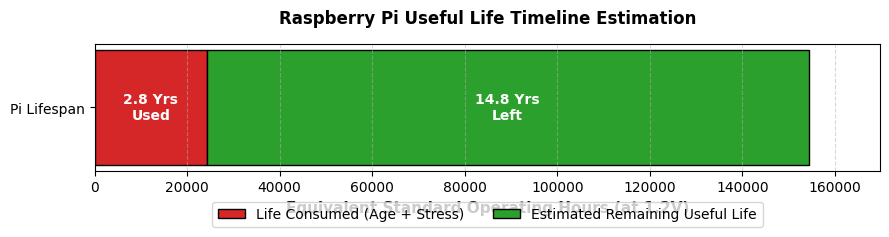

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_remaining_lifespan(
    v_use=1.2,                # Standard internal core voltage (Volts)
    v_stress=2.0,              # Lab testing voltage used to break test chips
    t_fail_stress=20000,       # How many hours test chips lasted at v_stress
    beta=4.0,                  # Material acceleration constant for silicon
    hours_normal_used=15000,   # Hours the Pi ran at standard v_use
    hours_overvolted_used=5000,# Hours the Pi ran at a higher custom voltage
    v_custom_overvolt=1.4      # The higher custom voltage used during life
):
    """
    Calculates and plots the remaining useful life of a semiconductor 
    based on historical voltage usage and accelerated life testing data.
    """
    # 1. Calculate Acceleration Factors (AF) using the Inverse Power Law
    af_lab_stress = (v_stress / v_use) ** beta
    af_user_overvolt = (v_custom_overvolt / v_use) ** beta
    
    # 2. Translate lab data to baseline maximum useful life hours
    max_useful_life_standard = t_fail_stress * af_lab_stress
    
    # 3. Calculate how much life has already been consumed (in standard hours)
    consumed_normal = hours_normal_used * 1.0
    consumed_overvolted = hours_overvolted_used * af_user_overvolt
    total_consumed_standard = consumed_normal + consumed_overvolted
    
    # 4. Calculate what is left
    remaining_life_standard = max_useful_life_standard - total_consumed_standard
    
    # Convert hours to years for more intuitive plotting text
    max_years = max_useful_life_standard / 8760
    consumed_years = total_consumed_standard / 8760
    remaining_years = max(0.0, remaining_life_standard / 8760)
    
    # Print numerical breakdown to console
    print(f"--- Lifespan Estimation Results ---")
    print(f"Total Predicted Useful Life: {max_useful_life_standard:,.0f} standard hours ({max_years:.2f} years)")
    print(f"Total Life Consumed So Far:  {total_consumed_standard:,.0f} standard hours ({consumed_years:.2f} years)")
    print(f"Estimated Remaining Life:    {max(0.0, remaining_life_standard):,.0f} standard hours ({remaining_years:.2f} years)")
    
    # 5. Generate the visualization plot
    plt.figure(figsize=(9, 3))
    
    # Draw horizontal stacked bar chart
    plt.barh('Pi Lifespan', total_consumed_standard, color='#d62728', edgecolor='black', label='Life Consumed (Age + Stress)')
    if remaining_life_standard > 0:
        plt.barh('Pi Lifespan', remaining_life_standard, left=total_consumed_standard, color='#2ca02c', edgecolor='black', label='Estimated Remaining Useful Life')
    else:
        print("⚠️ Warning: Calculations suggest the chip has exceeded its statistical useful life!")

    # Aesthetics and labels
    plt.xlabel('Equivalent Standard Operating Hours (at 1.2V)', fontsize=11, fontweight='bold')
    plt.title('Raspberry Pi Useful Life Timeline Estimation', fontsize=12, pad=15, fontweight='bold')
    plt.xlim(0, max_useful_life_standard * 1.1)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2, frameon=True)
    
    # Add data annotations inside the bars
    plt.text(total_consumed_standard / 2, 0, f"{consumed_years:.1f} Yrs\nUsed", ha='center', va='center', color='white', fontweight='bold')
    if remaining_life_standard > 0:
        plt.text(total_consumed_standard + (remaining_life_standard / 2), 0, f"{remaining_years:.1f} Yrs\nLeft", ha='center', va='center', color='white', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# Execute the function with sample user parameters
plot_remaining_lifespan()


--- Realistic Pi 3B+ Wear-Out Analysis ---
Stock Core Voltage:      1.20V
Overclock Core Voltage:  1.250V (over_voltage=2)
Acceleration Factor:     Silicon degrades 1.18x faster under overclock.
-------------------------------------------
Total Bathtub Useful Life Limit:   11.0 Equivalent Years
Total Equivalent Silicon Wear:     3.77 Years worn down
True Calendar Years Remaining:     6.14 Years (if kept overclocked)


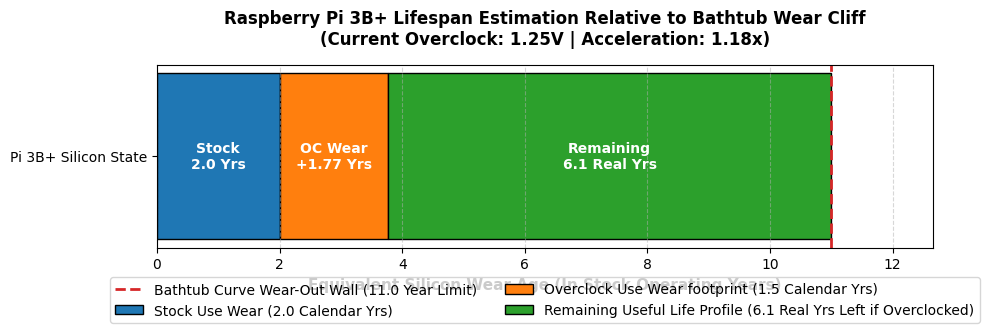

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_real_pi3bp_bathtub_limit(
    years_stock_used=2.0,       # Calendar years the Pi ran at standard stock settings
    years_overclocked_used=1.5, # Calendar years the Pi ran with the overclock active
    over_voltage_setting=2,    # config.txt 'over_voltage' setting (each step is 0.025V)
    design_life_wall_years=11.0,# The physical end of the useful life bathtub curve
    beta=4.0                    # Voltage acceleration exponent for 28nm semiconductor node
):
    """
    Calculates and plots remaining life by mapping accelerated wear against
    the semiconductor's finite physical bathtub curve wear-out wall.
    """
    v_stock = 1.20
    # 1. Calculate actual overvolted core voltage
    v_overclock = v_stock + (over_voltage_setting * 0.025)
    
    # 2. Calculate the Acceleration Factor (AF) using the Inverse Power Law
    # This measures the rate of degradation acceleration, NOT total life.
    af_overclock = (v_overclock / v_stock) ** beta
    
    # 3. Convert historical calendar usage into equivalent "Stock Wear Years"
    wear_from_stock = years_stock_used * 1.0
    wear_from_overclock = years_overclocked_used * af_overclock
    total_wear_accumulated = wear_from_stock + wear_from_overclock
    
    # 4. Calculate remaining life left before hitting the bathtub curve wall
    remaining_stock_wear_years = design_life_wall_years - total_wear_accumulated
    
    # If the user keeps the overclock active, time is consumed faster:
    remaining_calendar_years_overclocked = max(0.0, remaining_stock_wear_years / af_overclock)
    
    # Print a realistic breakdown to the console
    print(f"--- Realistic Pi 3B+ Wear-Out Analysis ---")
    print(f"Stock Core Voltage:      {v_stock:.2f}V")
    print(f"Overclock Core Voltage:  {v_overclock:.3f}V (over_voltage={over_voltage_setting})")
    print(f"Acceleration Factor:     Silicon degrades {af_overclock:.2f}x faster under overclock.")
    print(f"-------------------------------------------")
    print(f"Total Bathtub Useful Life Limit:   {design_life_wall_years:.1f} Equivalent Years")
    print(f"Total Equivalent Silicon Wear:     {total_wear_accumulated:.2f} Years worn down")
    print(f"True Calendar Years Remaining:     {remaining_calendar_years_overclocked:.2f} Years (if kept overclocked)")
    
    # 5. Generate the corrected visual chart
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot the stacked segments mapping out total accumulated wear
    ax.barh('Pi 3B+ Silicon State', wear_from_stock, color='#1f77b4', edgecolor='black', 
            label=f'Stock Use Wear ({years_stock_used:.1f} Calendar Yrs)')
    
    ax.barh('Pi 3B+ Silicon State', wear_from_overclock, left=wear_from_stock, color='#ff7f0e', edgecolor='black', 
            label=f'Overclock Use Wear footprint ({years_overclocked_used:.1f} Calendar Yrs)')
    
    if remaining_stock_wear_years > 0:
        ax.barh('Pi 3B+ Silicon State', remaining_stock_wear_years, left=total_wear_accumulated, color='#2ca02c', edgecolor='black', 
                label=f'Remaining Useful Life Profile ({remaining_calendar_years_overclocked:.1f} Real Yrs Left if Overclocked)')
    else:
        print("⚠️ Warning: Combined wear parameters exceed the targeted silicon design life wall!")

    # Draw the red vertical bathtub curve end-of-life boundary
    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=2, 
               label=f'Bathtub Curve Wear-Out Wall ({design_life_wall_years:.1f} Year Limit)')
    
    # Visual Polish
    ax.set_xlabel('Equivalent Silicon Wear Age (In Stock Operating Years)', fontsize=11, fontweight='bold')
    ax.set_title(f'Raspberry Pi 3B+ Lifespan Estimation Relative to Bathtub Wear Cliff\n(Current Overclock: {v_overclock}V | Acceleration: {af_overclock:.2f}x)', 
                 fontsize=12, pad=15, fontweight='bold')
    ax.set_xlim(0, design_life_wall_years * 1.15)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2, frameon=True)
    
    # Label Text Overlay inside the graph bars
    ax.text(wear_from_stock / 2, 0, f"Stock\n{years_stock_used:.1f} Yrs", ha='center', va='center', color='white', fontweight='bold')
    ax.text(wear_from_stock + (wear_from_overclock / 2), 0, f"OC Wear\n+{wear_from_overclock:.2f} Yrs", ha='center', va='center', color='white', fontweight='bold')
    if remaining_stock_wear_years > 0:
        ax.text(total_wear_accumulated + (remaining_stock_wear_years / 2), 0, f"Remaining\n{remaining_calendar_years_overclocked:.1f} Real Yrs", ha='center', va='center', color='white', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# Run with standard Pi 3B+ architecture limits
plot_real_pi3bp_bathtub_limit()


In [ ]:
# fig, f_axs = plt.subplots( 3 , len(range(1,5)), figsize=(25,10))
f_axs = []
for i in range(3):
    fig, axs = plt.subplots(len(range(1,5)), figsize=(25,40))
    f_axs.append(axs)
bws=[100, 50, 10]
c_map=["blue", "orange", "green", "red", "black", "pink"]
for bw_ind, bw in enumerate(bws):    
# for bw in [240]:    
    # f=open(f"exploration.dict.{bw}", "r")
    f=open(f"exploration.dict.{bw}.mean", "r")
    real_maps, pred_maps = f.readlines()
    real_maps = literal_eval(real_maps.strip())
    pred_maps = literal_eval(pred_maps.strip())
    t_flag="all"
    for inp_ind, inp in enumerate(real_maps):
        if inp_ind>1:
            break
        for m_ind, model in enumerate(real_maps[inp]):
            axs=f_axs[m_ind]
            # fig, axs = plt.subplots(len(real_maps[inp][model].keys()), figsize=(25,10))

            for w_ind, world in enumerate(real_maps[inp][model]):

                if t_flag=="c" or t_flag=="all":
                    x=sorted(list(real_maps[inp][model][world].keys()))
                    y = [real_maps[inp][model][world][bg][0][0] for bg in real_maps[inp][model][world]]
                    # y = [inp/i for i in y]
                    #bn_bs_c or nw
                    real_str = [f"{real_maps[inp][model][world][bg][0][1]}_{real_maps[inp][model][world][bg][0][2]}_{real_maps[inp][model][world][bg][0][3]}" for bg in  real_maps[inp][model][world]]
                    pred_y = [pred_maps[inp][model][world][bg][0][0] for bg in pred_maps[inp][model][world]]
                    # pred_y = [inp/p for p in pred_y]

                    pred_str = [f"{pred_maps[inp][model][world][bg][0][1]}_{pred_maps[inp][model][world][bg][0][2]}_{pred_maps[inp][model][world][bg][0][3]}" for bg in  real_maps[inp][model][world]]
                    
                    x = [ 100*round((i+world-1)/map_sub[subcluster],4) for i in x]
                    # axs[w_ind].plot(x,y, linestyle="--", marker=f"${world}$", markersize=20, alpha=0.2)
                    axs[w_ind].plot(x,y, linestyle="--", marker="x", markersize=20, color=c_map[bw_ind], label=f"compute_w_{bw}_{inp}")
                    axs[w_ind].set_xticks(x)
                    for i in range(len(x)):
                        axs[w_ind].text(x[i],y[i],real_str[i])
                    
                    # axs[w_ind].plot(x,pred_y, linestyle="--", marker=f"${world}$", markersize=20)
                    # for i in range(len(x)):
                    #     axs[w_ind].text(x[i],pred_y[i],pred_str[i])
                    print(f"rmse c {model}_{inp}_{world} { np.sqrt( np.mean([ (y[i]-pred_y[i])**2 for i in range(len(y)) ]) )}")
                    print(f"mae c {model}_{inp}_{world} { ( np.mean([ abs(y[i]-pred_y[i]) for i in range(len(y)) ]) )}")
                    print(f"mape c {model}_{inp}_{world} { 100*( np.mean([ abs(y[i]-pred_y[i])/y[i] for i in range(len(y)) ]) )}%")
                    print()

                if t_flag=="nw" or t_flag=="all":
                    x=sorted(list(real_maps[inp][model][world].keys()))
                    y = [real_maps[inp][model][world][bg][1][0] for bg in real_maps[inp][model][world]]
                    real_str = [f"{real_maps[inp][model][world][bg][1][1]}_{real_maps[inp][model][world][bg][1][2]}_{real_maps[inp][model][world][bg][1][3]}" for bg in  real_maps[inp][model][world]]
                    pred_y = [pred_maps[inp][model][world][bg][1][0] for bg in pred_maps[inp][model][world]]
                    pred_str = [f"{pred_maps[inp][model][world][bg][1][1]}_{pred_maps[inp][model][world][bg][1][2]}_{pred_maps[inp][model][world][bg][1][3]}" for bg in  real_maps[inp][model][world]]
                    
                    x = [ 100*round((i+world-1)/map_sub[subcluster],4) for i in x]

                    # axs[w_ind].plot(x,y, linestyle="--", marker=f"${world}$", markersize=20, alpha=0.2)
                    axs[w_ind].plot(x,y, linestyle="--", marker=".", markersize=20, color=c_map[bw_ind], label=f"nw_w_{bw}_{inp}")
                    # for i in range(len(x)):
                    #     axs[w_ind].text(x[i],y[i],real_str[i])
                    # axs[w_ind].plot(x,pred_y, linestyle="--", marker=f"${world}$", markersize=20)
                    # for i in range(len(x)):
                    #     axs[w_ind].text(x[i],pred_y[i],pred_str[i])
                    print(f"rmse nw {model}_{inp}_{world} { np.sqrt( np.mean([ (y[i]-pred_y[i])**2 for i in range(len(y)) ]) )}")
                    print(f"mae nw {model}_{inp}_{world} { ( np.mean([ abs(y[i]-pred_y[i]) for i in range(len(y)) ]) )}")
                    print(f"mape nw {model}_{inp}_{world} { 100*( np.mean([ abs(y[i]-pred_y[i])/y[i] for i in range(len(y)) ]) )}%")
                    print()
                
                axs[w_ind].set_title(f"{model}_{inp}_{bw}_{world}")    
                axs[w_ind].legend()
        #     break
        # break


: 

In [ ]:
def flop_comp(model, world, bw, bg):
    f=open(f"/Users/animeshnd/model_splitting/scheduler/{model}_splits_{world}_nw/meta.json")
    model_nw = json.load(f)
    f=open(f"/Users/animeshnd/model_splitting/scheduler/{model}_splits_{world}_c/meta.json")
    model_c = json.load(f)
    # print(f)
    c_flops = [r['actual_flops'] for r in model_c['splits']]
    nw_flops = [r['actual_flops'] for r in model_nw['splits']]
    real, std_val, pred, naive_rt, worst_dev_util = best_fit_reader("best_fit_max_2_6.csv", sub, cur_model, world, bg-world,
                1, 10, bw=bw, ty='c', col_flag="median", agg_flag="mean", nw_var=True)
    # real, std_val, pred, naive_pred = best_fit_reader("best_fit_max_2_6.csv", "bramble-2-4", model, world, bg, 1, 10, bw, ty='c', col_flag="max")
    print(f"comp flops: {c_flops}, {[round(100*i/sum(c_flops),2) for i in c_flops]}, comp nw:{[r['boundary_transfer_bytes']*8*10**-6 for r in model_c['splits']]}, time:{real}, {pred} ")
    real, std_val, pred, naive_rt, worst_dev_util = best_fit_reader("best_fit_max_2_6.csv", sub, cur_model, world, bg-world,
                1, 10, bw=bw, ty='nw', col_flag="median", agg_flag="mean", nw_var=True)
    # real, std_val, pred, naive_pred = best_fit_reader("best_fit_max_2_6.csv", "bramble-2-4", model, world, bg, 1, 10, bw, ty='nw', col_flag="max")
    print(f"nw flops: {nw_flops}, {[round(100*i/sum(nw_flops),2) for i in nw_flops]}, nw nw:{[r['boundary_transfer_bytes']*8*10**-6 for r in model_nw['splits']]}, time:{real}, {pred} ")

flop_comp("eff", 3, 240, bg=0)
# flop_comp("eff", 3, 240, bg=3)
print()
flop_comp("eff", 5, 240, bg=0)
# flop_comp("eff", 5, 240, bg=3)

comp flops: [499866436.0, 532799100.0, 576810872.0], [31.06, 33.1, 35.84], comp nw:[2.00704, 1.404928, 0.064], time:3.932, 2.731 
nw flops: [680578856.0, 723534256.0, 205363296.0], [42.29, 44.95, 12.76], nw nw:[1.00352, 0.602112, 0.064], time:4.692, 3.11 

comp flops: [338198308.0, 342380548.0, 352086680.0, 371447576.0, 205363296.0], [21.01, 21.27, 21.88, 23.08, 12.76], comp nw:[4.816896, 1.00352, 1.404928, 0.602112, 0.064], time:3.533, 2.766 
nw flops: [338198308.0, 342380548.0, 352086680.0, 371447576.0, 205363296.0], [21.01, 21.27, 21.88, 23.08, 12.76], nw nw:[4.816896, 1.00352, 1.404928, 0.602112, 0.064], time:3.41, 2.766 


In [ ]:
#third result -> rmse, mae, mape low when using the curve
#best trial and how close greedy is compared to only_compute or only_communicate


: 